# Wildfire Indicators Modeling for Alluri Seetaramaraju District (Andhra Pradesh, India)

**Replication of:** Sultan et al. (2025) — *Wildfire indicators modeling for reserved forest of Vellore district (Tamil Nadu, India)*, Frontiers in Remote Sensing, 6:1518539.

**Study Area:** Alluri Seetaramaraju District, Andhra Pradesh, India  
**Boundary:** Uploaded shapefile (`ASR_boundary.shp` / `ASR_district_boundary.geojson`)  
**Platform:** Google Earth Engine (GEE) Python API  
**Analysis Year:** 2023

> ⚠️ **Important:** Pre/post fire dates are NOT copied from the Vellore paper.
> Section 3 uses three independent sources to determine the actual ASR fire season.

---

## Indices Computed
| Index | Description | Source |
|-------|-------------|--------|
| NDVI  | Normalized Difference Vegetation Index | MODIS MOD13Q1 |
| NDMI  | Normalized Difference Moisture Index | Landsat 9 OLI |
| FDI   | Fuel Danger Index = NDVI + NDMI | Derived |
| ADI   | Activity Danger Index (roads + settlements) | gROADS + GHSL |
| WDI   | Weather Danger Index (T + RH + Wind) | ERA5-Land |
| TDI   | Topographic Danger Index (Slope + Aspect + Elevation) | SRTM DEM |
| NBR   | Normalized Burn Ratio (Pre & Post fire) | Landsat 9 |
| dNBR  | Differenced NBR — Fire Severity | Derived |


## 1. Setup & Authentication

In [1]:
# !pip install earthengine-api geemap folium matplotlib numpy pandas requests Pillow

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import requests
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

ee.Authenticate()   # <-- Uncomment and run ONCE on first use
ee.Initialize(project='seismic-envoy-485304-p9')
print('✅ Google Earth Engine initialized')



Successfully saved authorization token.
✅ Google Earth Engine initialized


## 2. Study Area — Alluri Seetaramaraju District

In [2]:
import json

# ─── ASR District boundary embedded from uploaded shapefile ──────────────────
# Source: ASR_district_boundary.geojson / ASR_boundary.shp (user-uploaded)
# Bounds : W=80.88°E  E=83.27°E  S=17.22°N  N=18.55°N
# Area   : ~12,251 km²  |  Vertices: 12,134 (rounded to 6 d.p.)
# Properties: Name='AlluriSitharama Raju District', Capital='Paderu'

ASR_GEOM_JSON = '{"type":"MultiPolygon","coordinates":[[[[83.238718,18.283945],[83.23786,18.284297],[83.237016,18.284644],[83.23512,18.285521],[83.23353,18.286493],[83.232474,18.287287],[83.23175,18.28783],[83.231647,18.287907],[83.230156,18.28901],[83.228564,18.289982],[83.228267,18.290187],[83.22727,18.290873],[83.227164,18.290946],[83.226877,18.291148],[83.225336,18.292464],[83.225217,18.292563],[83.225149,18.292619],[83.223914,18.293314],[83.222913,18.29373],[83.221724,18.294329],[83.220724,18.294836],[83.219205,18.295992],[83.219076,18.296088],[83.218214,18.297788],[83.218046,18.298113],[83.218024,18.298265],[83.217859,18.299357],[83.217964,18.300714],[83.217977,18.300884],[83.218199,18.301049],[83.218456,18.301241],[83.219293,18.301866],[83.219495,18.302019],[83.220052,18.302537],[83.220609,18.303057],[83.220628,18.304681],[83.22063,18.304692],[83.220639,18.304771],[83.220661,18.304971],[83.220785,18.306046],[83.220828,18.306421],[83.220846,18.306576],[83.221525,18.307099],[83.221965,18.307438],[83.222199,18.307825],[83.222218,18.307857],[83.222554,18.30841],[83.222568,18.308433],[83.222668,18.3086],[83.222695,18.308645],[83.222884,18.308958],[83.223305,18.310483],[83.223396,18.310621],[83.223905,18.311391],[83.224117,18.31171],[83.22412,18.311716],[83.224419,18.312123],[83.225444,18.313519],[83.225724,18.313809],[83.227206,18.315343],[83.227272,18.315413],[83.229098,18.317211],[83.229137,18.31753],[83.229195,18.317988],[83.229209,18.318105],[83.229263,18.318538],[83.22943,18.319882],[83.229234,18.321253],[83.229061,18.322465],[83.229058,18.322473],[83.2288,18.323116],[83.227829,18.325541],[83.22756,18.326216],[83.22739,18.326642],[83.226793,18.327767],[83.22672,18.327834],[83.225557,18.328908],[83.224764,18.329142],[83.224024,18.329359],[83.221743,18.329521],[83.220185,18.329383],[83.217697,18.329095],[83.216613,18.328974],[83.216569,18.328947],[83.21561,18.328369],[83.214131,18.327477],[83.213991,18.327395],[83.213705,18.32738],[83.210776,18.32725],[83.210699,18.327245],[83.210268,18.3272],[83.209456,18.327111],[83.208976,18.327059],[83.20783,18.326972],[83.206771,18.32689],[83.206729,18.326864],[83.205496,18.326063],[83.204448,18.325384],[83.203336,18.324725],[83.202228,18.324068],[83.202192,18.324063],[83.201281,18.323935],[83.200321,18.3238],[83.197814,18.323634],[83.195101,18.322992],[83.195091,18.322978],[83.193777,18.321189],[83.192496,18.319993],[83.191853,18.319394],[83.189029,18.317988],[83.189008,18.317987],[83.188203,18.317925],[83.186803,18.317818],[83.186774,18.317793],[83.185969,18.317087],[83.185186,18.316401],[83.183561,18.314504],[83.182712,18.313323],[83.181722,18.311945],[83.179994,18.309763],[83.178278,18.308634],[83.176559,18.308475],[83.176373,18.308458],[83.174569,18.308382],[83.174522,18.30838],[83.172361,18.308309],[83.170667,18.308706],[83.169778,18.309862],[83.169458,18.311137],[83.169394,18.311393],[83.169392,18.311434],[83.169314,18.312925],[83.169138,18.314931],[83.169249,18.316466],[83.169256,18.316557],[83.169256,18.316596],[83.169275,18.317987],[83.16939,18.319327],[83.169509,18.321043],[83.169525,18.322458],[83.169484,18.322956],[83.169463,18.323206],[83.169351,18.32456],[83.168764,18.325621],[83.167982,18.32744],[83.167207,18.328619],[83.167098,18.328787],[83.166991,18.329062],[83.166479,18.330344],[83.166372,18.330612],[83.166221,18.330994],[83.165842,18.332813],[83.16536,18.334442],[83.164096,18.335933],[83.163482,18.336657],[83.162118,18.337398],[83.160794,18.338116],[83.158503,18.339285],[83.157717,18.339533],[83.15631,18.339976],[83.154818,18.340276],[83.154472,18.340343],[83.154307,18.340376],[83.153547,18.340272],[83.153025,18.3402],[83.152258,18.340326],[83.151716,18.340414],[83.150782,18.340643],[83.149291,18.341383],[83.147757,18.342047],[83.146894,18.342439],[83.146112,18.342611],[83.144903,18.343222],[83.144044,18.343653],[83.142691,18.344469],[83.141699,18.344992],[83.140841,18.345495],[83.139249,18.3464],[83.137934,18.346999],[83.137034,18.347544],[83.135603,18.348414],[83.135401,18.34852],[83.134409,18.349035],[83.133722,18.349142],[83.133467,18.34918],[83.132372,18.34926],[83.132314,18.349264],[83.132189,18.349272],[83.132124,18.349275],[83.130995,18.349329],[83.129789,18.349386],[83.129629,18.349399],[83.129557,18.349405],[83.12765,18.349577],[83.127135,18.349616],[83.125905,18.349708],[83.124516,18.349734],[83.12451,18.349734],[83.123822,18.349727],[83.123099,18.349496],[83.122221,18.349194],[83.120323,18.348748],[83.11791,18.348045],[83.116625,18.347866],[83.11504,18.347671],[83.114177,18.347606],[83.113292,18.34771],[83.112727,18.348308],[83.111613,18.34948],[83.111708,18.349759],[83.111722,18.349799],[83.111798,18.350022],[83.111808,18.350049],[83.111878,18.350256],[83.111944,18.350454],[83.112084,18.350946],[83.112176,18.35127],[83.112343,18.351939],[83.111242,18.352082],[83.110762,18.352116],[83.110281,18.352149],[83.110205,18.35217],[83.110049,18.352213],[83.109476,18.352373],[83.108504,18.352644],[83.107768,18.352918],[83.107324,18.353265],[83.107077,18.354071],[83.106885,18.354702],[83.106735,18.355498],[83.106714,18.355602],[83.1064,18.356178],[83.106042,18.356355],[83.105681,18.356358],[83.10508,18.356197],[83.105067,18.356186],[83.104506,18.355759],[83.104108,18.355455],[83.104073,18.355451],[83.103296,18.355349],[83.10208,18.354969],[83.102056,18.354958],[83.101115,18.354509],[83.100806,18.354361],[83.100066,18.353903],[83.099758,18.353777],[83.09857,18.353286],[83.097089,18.352674],[83.096264,18.352337],[83.096245,18.352332],[83.095579,18.352115],[83.095461,18.352078],[83.095274,18.35153],[83.095282,18.351475],[83.095353,18.351009],[83.095396,18.350725],[83.095452,18.349815],[83.095342,18.348974],[83.09527,18.347887],[83.095145,18.347565],[83.094977,18.347132],[83.094663,18.346406],[83.0944,18.345525],[83.094252,18.345191],[83.094171,18.345008],[83.094071,18.344782],[83.093913,18.343313],[83.093762,18.342338],[83.093594,18.341635],[83.093233,18.341714],[83.092082,18.342432],[83.091593,18.342779],[83.091104,18.343126],[83.090323,18.343566],[83.089752,18.343886],[83.087555,18.344499],[83.08613,18.344747],[83.085099,18.344922],[83.084945,18.344963],[83.084015,18.34521],[83.082772,18.345461],[83.081491,18.345626],[83.08136,18.345689],[83.080681,18.346019],[83.080673,18.347567],[83.080423,18.348505],[83.079996,18.349524],[83.079859,18.350035],[83.079725,18.350538],[83.079489,18.350848],[83.079481,18.350882],[83.079393,18.35127],[83.079596,18.351571],[83.079901,18.35193],[83.080243,18.352102],[83.080339,18.352179],[83.080434,18.352255],[83.080688,18.35246],[83.080754,18.352955],[83.080404,18.353044],[83.080054,18.353133],[83.079997,18.353423],[83.079949,18.353666],[83.079792,18.354761],[83.079448,18.356243],[83.078979,18.357279],[83.078507,18.358143],[83.0773,18.359417],[83.07661,18.36034],[83.076609,18.360342],[83.076594,18.360371],[83.076216,18.361128],[83.076143,18.361471],[83.07601,18.362105],[83.076013,18.36244],[83.076021,18.363115],[83.076133,18.364127],[83.076196,18.364702],[83.076253,18.365711],[83.076304,18.366602],[83.076502,18.367704],[83.07664,18.368467],[83.076685,18.368714],[83.076915,18.369771],[83.077944,18.3719],[83.078093,18.372179],[83.078695,18.373308],[83.079548,18.374544],[83.07967,18.374721],[83.080792,18.376297],[83.080826,18.376344],[83.080923,18.376478],[83.081713,18.377428],[83.081911,18.377668],[83.082406,18.378262],[83.083802,18.379452],[83.085408,18.381386],[83.086855,18.38279],[83.087245,18.383206],[83.088134,18.384154],[83.089268,18.385195],[83.090328,18.38662],[83.09195,18.388285],[83.092959,18.389265],[83.092962,18.389269],[83.094111,18.38966],[83.094845,18.389811],[83.095131,18.38987],[83.095176,18.38988],[83.095274,18.39002],[83.095305,18.390065],[83.0954,18.390202],[83.095787,18.390753],[83.096256,18.391494],[83.096344,18.391634],[83.09645,18.391802],[83.096815,18.392199],[83.097545,18.392996],[83.097856,18.393854],[83.097959,18.394138],[83.098111,18.394499],[83.098422,18.395234],[83.098444,18.395309],[83.098643,18.396004],[83.098761,18.396183],[83.098824,18.39628],[83.099029,18.396593],[83.099344,18.397852],[83.09942,18.397982],[83.099598,18.398287],[83.100019,18.399012],[83.100296,18.399666],[83.100867,18.40101],[83.102495,18.404642],[83.103094,18.405866],[83.103345,18.406376],[83.103353,18.406393],[83.103361,18.406408],[83.104129,18.40765],[83.104333,18.407979],[83.104958,18.409865],[83.105191,18.411077],[83.105522,18.41201],[83.103359,18.412221],[83.102237,18.412308],[83.101631,18.412368],[83.100957,18.412436],[83.10015,18.412183],[83.099769,18.412064],[83.099273,18.411892],[83.09869,18.411689],[83.098219,18.411524],[83.098129,18.411508],[83.096651,18.411242],[83.096644,18.411241],[83.09664,18.411241],[83.093729,18.410982],[83.091688,18.410857],[83.089694,18.411108],[83.08948,18.411135],[83.089324,18.411209],[83.088427,18.411632],[83.088427,18.41102],[83.088425,18.411009],[83.088412,18.410922],[83.088413,18.41072],[83.088108,18.408702],[83.087818,18.407912],[83.087511,18.407079],[83.087008,18.40639],[83.085996,18.405496],[83.085966,18.405474],[83.084975,18.40473],[83.083371,18.403975],[83.083367,18.403973],[83.083342,18.403961],[83.081691,18.40325],[83.080243,18.40252],[83.080072,18.402434],[83.079111,18.402552],[83.078104,18.402834],[83.077955,18.402872],[83.077702,18.402944],[83.077061,18.403124],[83.077029,18.403101],[83.076905,18.403013],[83.076081,18.402201],[83.074358,18.400267],[83.07313,18.399162],[83.071866,18.397843],[83.071035,18.396895],[83.069803,18.396081],[83.06977,18.396072],[83.069238,18.395935],[83.069228,18.395926],[83.068643,18.395415],[83.068083,18.394874],[83.067397,18.394211],[83.066687,18.393517],[83.065579,18.392433],[83.063764,18.390615],[83.063489,18.390297],[83.06304,18.389777],[83.062412,18.389049],[83.062228,18.388836],[83.062178,18.387822],[83.061849,18.387146],[83.061088,18.386014],[83.06013,18.384974],[83.059857,18.384732],[83.059317,18.384271],[83.058932,18.383942],[83.05729,18.382542],[83.056872,18.382079],[83.05652,18.381689],[83.055889,18.380891],[83.055469,18.380537],[83.055081,18.38021],[83.055039,18.380196],[83.054446,18.380008],[83.054185,18.379925],[83.053544,18.379898],[83.052399,18.379848],[83.051834,18.379954],[83.051423,18.38003],[83.049655,18.380168],[83.049097,18.380177],[83.048842,18.380181],[83.04792,18.380042],[83.047886,18.380026],[83.047103,18.37966],[83.04595,18.379053],[83.045937,18.379053],[83.045491,18.379049],[83.045021,18.37914],[83.04451,18.379391],[83.044098,18.379475],[83.04406,18.379456],[83.043688,18.379266],[83.043675,18.379265],[83.043086,18.379253],[83.042686,18.379408],[83.042357,18.379779],[83.041696,18.380412],[83.041051,18.381199],[83.040326,18.382182],[83.039887,18.382682],[83.039494,18.383129],[83.038379,18.383387],[83.037498,18.38333],[83.03671,18.383158],[83.036124,18.383334],[83.035492,18.3833],[83.033711,18.383292],[83.032024,18.383413],[83.031664,18.38383],[83.031352,18.384191],[83.030223,18.38533],[83.029668,18.385889],[83.029138,18.386106],[83.028055,18.386292],[83.02583,18.386766],[83.02545,18.386904],[83.025095,18.387463],[83.024987,18.387658],[83.0248,18.388],[83.024506,18.388596],[83.02422,18.388843],[83.024094,18.388951],[83.023455,18.389814],[83.023202,18.390406],[83.022886,18.390887],[83.022337,18.39141],[83.021892,18.391603],[83.021444,18.391455],[83.021441,18.391452],[83.020773,18.390782],[83.020292,18.389688],[83.01998,18.388955],[83.019674,18.388526],[83.019634,18.388513],[83.019057,18.388327],[83.01818,18.388159],[83.018153,18.388146],[83.017877,18.388014],[83.017773,18.387596],[83.017354,18.387121],[83.016468,18.38648],[83.016445,18.386478],[83.015787,18.38641],[83.015067,18.386417],[83.014435,18.387149],[83.013363,18.387884],[83.012643,18.387891],[83.012202,18.387819],[83.012169,18.387804],[83.01176,18.387632],[83.011595,18.387137],[83.01155,18.386641],[83.011544,18.38603],[83.01138,18.385807],[83.011016,18.38531],[83.009771,18.384749],[83.009476,18.384485],[83.008843,18.383917],[83.008597,18.383755],[83.007594,18.383089],[83.006547,18.382411],[83.006519,18.382404],[83.005495,18.382139],[83.005264,18.38208],[83.004064,18.382015],[83.002746,18.382256],[83.00155,18.382611],[83.001258,18.382824],[83.000598,18.383307],[82.99949,18.384463],[82.998458,18.385312],[82.997583,18.385702],[82.996862,18.385633],[82.996851,18.385621],[82.996296,18.385027],[82.995969,18.384381],[82.99564,18.383468],[82.995509,18.3824],[82.995462,18.381713],[82.995138,18.381258],[82.995103,18.381249],[82.994576,18.38111],[82.994562,18.381102],[82.993973,18.380772],[82.993728,18.380278],[82.993242,18.37971],[82.992956,18.379063],[82.99239,18.378496],[82.992364,18.378494],[82.99183,18.378463],[82.991511,18.37858],[82.991235,18.379003],[82.991161,18.379576],[82.991168,18.380225],[82.990851,18.380534],[82.990493,18.38069],[82.99046,18.380673],[82.990131,18.380502],[82.989806,18.380047],[82.989482,18.37963],[82.989237,18.379098],[82.988873,18.378681],[82.988846,18.37868],[82.988272,18.378649],[82.987873,18.378729],[82.987555,18.378922],[82.987523,18.378905],[82.987354,18.37881],[82.987352,18.378619],[82.987789,18.378271],[82.988185,18.377886],[82.988179,18.377351],[82.987893,18.376743],[82.987858,18.376734],[82.987331,18.376605],[82.987319,18.376598],[82.986929,18.376332],[82.986686,18.376029],[82.98514,18.373446],[82.984121,18.371547],[82.983139,18.369341],[82.982718,18.368174],[82.982522,18.367629],[82.982437,18.367171],[82.982914,18.3669],[82.983432,18.366742],[82.983267,18.366247],[82.98323,18.366234],[82.982309,18.365927],[82.982306,18.365925],[82.981938,18.365644],[82.981266,18.365321],[82.980286,18.364791],[82.980256,18.364782],[82.979482,18.364531],[82.979468,18.364524],[82.979204,18.364404],[82.978575,18.364119],[82.978361,18.363977],[82.977676,18.363522],[82.976937,18.362793],[82.976296,18.362508],[82.976013,18.362382],[82.975989,18.362374],[82.974666,18.361934],[82.974445,18.361889],[82.973819,18.36176],[82.973801,18.36175],[82.972669,18.361119],[82.971517,18.360452],[82.97077,18.360063],[82.970745,18.360056],[82.969037,18.359557],[82.969024,18.35955],[82.968468,18.359261],[82.968152,18.359097],[82.968132,18.359092],[82.967282,18.35889],[82.966837,18.358774],[82.966541,18.35928],[82.965848,18.360102],[82.965392,18.360469],[82.964931,18.3607],[82.964707,18.360825],[82.964115,18.361157],[82.963847,18.361449],[82.96368,18.361633],[82.963587,18.36205],[82.963292,18.362753],[82.962719,18.36356],[82.961643,18.364221],[82.960977,18.364874],[82.960873,18.365034],[82.960574,18.365493],[82.960198,18.366147],[82.959846,18.366028],[82.959838,18.366025],[82.957924,18.365081],[82.957118,18.364705],[82.956051,18.364122],[82.955282,18.363459],[82.954515,18.362386],[82.954305,18.362037],[82.954143,18.361767],[82.953637,18.361312],[82.95361,18.361306],[82.952794,18.361128],[82.95193,18.360965],[82.950446,18.360921],[82.949346,18.361037],[82.948664,18.361014],[82.948652,18.361002],[82.948359,18.360717],[82.947918,18.360483],[82.947453,18.360144],[82.947434,18.360143],[82.946912,18.360111],[82.945931,18.360253],[82.944541,18.360402],[82.942263,18.360172],[82.941262,18.360313],[82.941086,18.360336],[82.940001,18.360478],[82.938904,18.360869],[82.937688,18.36155],[82.935881,18.362573],[82.935194,18.362955],[82.934739,18.363209],[82.934529,18.363326],[82.932945,18.364136],[82.931886,18.364567],[82.930934,18.364968],[82.930228,18.365366],[82.92973,18.365648],[82.928663,18.36625],[82.927942,18.366656],[82.927681,18.366822],[82.927384,18.366984],[82.926369,18.367718],[82.925918,18.368188],[82.925764,18.368535],[82.925024,18.370134],[82.924253,18.371748],[82.923404,18.373348],[82.922585,18.374873],[82.922413,18.374949],[82.922145,18.374967],[82.921437,18.374958],[82.919864,18.374972],[82.9187,18.374968],[82.918243,18.374957],[82.918236,18.374947],[82.917605,18.374061],[82.917031,18.373225],[82.916232,18.37206],[82.91563,18.371122],[82.914891,18.369999],[82.914109,18.36888],[82.913569,18.368359],[82.913299,18.368181],[82.913295,18.368186],[82.913082,18.368423],[82.912835,18.368951],[82.912682,18.369373],[82.912404,18.369946],[82.911402,18.372013],[82.911186,18.372481],[82.910872,18.372544],[82.910447,18.372563],[82.909771,18.372569],[82.907223,18.372637],[82.905415,18.372758],[82.904063,18.37292],[82.902949,18.37326],[82.902755,18.373354],[82.902151,18.373643],[82.901511,18.374205],[82.90109,18.374599],[82.900593,18.375219],[82.900345,18.375597],[82.899783,18.376128],[82.898208,18.377524],[82.897007,18.378646],[82.89473,18.380709],[82.89442,18.381178],[82.894298,18.381554],[82.894208,18.382066],[82.894201,18.382922],[82.894195,18.383299],[82.894181,18.384139],[82.894078,18.384891],[82.893773,18.385855],[82.893497,18.386639],[82.893172,18.387152],[82.892642,18.387683],[82.891517,18.388534],[82.890925,18.38908],[82.890738,18.389277],[82.89074,18.389442],[82.890885,18.389877],[82.891111,18.390415],[82.891413,18.390743],[82.891873,18.39116],[82.892332,18.391351],[82.892538,18.391545],[82.892776,18.391798],[82.89316,18.39244],[82.893447,18.392843],[82.89385,18.393816],[82.894061,18.3944],[82.894048,18.394731],[82.894113,18.394956],[82.894257,18.395195],[82.894464,18.395478],[82.895054,18.396269],[82.895979,18.398236],[82.897304,18.401056],[82.897624,18.401669],[82.897881,18.402208],[82.897933,18.402688],[82.897927,18.403619],[82.897865,18.404336],[82.897828,18.404762],[82.897634,18.405911],[82.897604,18.406086],[82.897441,18.407064],[82.896995,18.408179],[82.896719,18.408873],[82.896615,18.40952],[82.896637,18.410135],[82.896818,18.410975],[82.896839,18.411545],[82.896608,18.411998],[82.896266,18.412482],[82.896143,18.412768],[82.896132,18.413204],[82.896147,18.414826],[82.895949,18.415489],[82.895599,18.416664],[82.895441,18.418242],[82.895393,18.419502],[82.895265,18.422825],[82.895209,18.423487],[82.895036,18.423564],[82.894658,18.423552],[82.893934,18.423543],[82.893496,18.423547],[82.892723,18.423554],[82.891857,18.423562],[82.89129,18.423492],[82.891053,18.423434],[82.891041,18.423429],[82.890485,18.423198],[82.8902,18.423021],[82.890183,18.423015],[82.88802,18.422291],[82.886174,18.421674],[82.881979,18.420268],[82.880933,18.420167],[82.879255,18.420569],[82.877634,18.42086],[82.87665,18.421146],[82.876644,18.421137],[82.875592,18.419715],[82.874428,18.419283],[82.873321,18.418794],[82.872096,18.418085],[82.872089,18.418085],[82.871272,18.418065],[82.870413,18.418044],[82.86883,18.418659],[82.868165,18.418983],[82.867552,18.419282],[82.86667,18.41981],[82.865899,18.420272],[82.864818,18.42111],[82.863865,18.421551],[82.862906,18.421789],[82.861587,18.422125],[82.860166,18.422424],[82.858508,18.423011],[82.858286,18.423178],[82.857453,18.423805],[82.857037,18.424268],[82.856422,18.424904],[82.856411,18.424898],[82.855637,18.424509],[82.854572,18.423615],[82.854077,18.422973],[82.853647,18.422054],[82.853295,18.421053],[82.853173,18.420686],[82.852372,18.418741],[82.852365,18.418751],[82.851206,18.420473],[82.850857,18.420953],[82.850445,18.42152],[82.849911,18.421952],[82.849782,18.422056],[82.849477,18.422303],[82.848943,18.42277],[82.848746,18.422942],[82.848565,18.423304],[82.848391,18.423651],[82.848198,18.424476],[82.848187,18.425261],[82.848233,18.425892],[82.848162,18.426175],[82.848039,18.426672],[82.84785,18.427487],[82.847534,18.428206],[82.847399,18.428877],[82.847227,18.42972],[82.847154,18.430241],[82.847096,18.430658],[82.846814,18.43119],[82.846089,18.432284],[82.845558,18.432961],[82.844875,18.433174],[82.84403,18.433663],[82.84294,18.434204],[82.841608,18.435229],[82.840581,18.435975],[82.839492,18.436203],[82.838092,18.436539],[82.837627,18.436596],[82.836749,18.436704],[82.836288,18.436785],[82.836198,18.437721],[82.836006,18.438603],[82.8359,18.438773],[82.83578,18.438967],[82.834962,18.439716],[82.833992,18.440305],[82.832848,18.441],[82.831186,18.441841],[82.830306,18.442249],[82.829941,18.442309],[82.829688,18.442351],[82.829126,18.442488],[82.828527,18.442819],[82.828169,18.44288],[82.827828,18.442939],[82.827105,18.442888],[82.826261,18.442866],[82.825201,18.442774],[82.824602,18.442916],[82.824201,18.443012],[82.823264,18.443632],[82.822712,18.444535],[82.822539,18.445378],[82.822764,18.445873],[82.822984,18.446313],[82.823195,18.446986],[82.822732,18.447174],[82.822346,18.44733],[82.821048,18.44808],[82.820744,18.448257],[82.820183,18.44858],[82.819386,18.449083],[82.818446,18.44934],[82.818245,18.44943],[82.817858,18.449601],[82.817088,18.449829],[82.815912,18.450424],[82.814748,18.450346],[82.814745,18.450346],[82.813716,18.450113],[82.812319,18.450126],[82.811317,18.450069],[82.810394,18.450115],[82.808989,18.450163],[82.807734,18.449941],[82.807545,18.449908],[82.806202,18.449585],[82.805155,18.449431],[82.803668,18.449023],[82.803044,18.448779],[82.802713,18.448344],[82.802423,18.447561],[82.802218,18.446203],[82.801671,18.445711],[82.80044,18.44486],[82.799332,18.444201],[82.798204,18.443693],[82.79776,18.443372],[82.797541,18.443029],[82.797336,18.442051],[82.796603,18.440931],[82.795881,18.439732],[82.794954,18.439069],[82.794327,18.438443],[82.793279,18.437898],[82.792484,18.43761],[82.791195,18.436685],[82.790547,18.435987],[82.789585,18.434821],[82.789173,18.434556],[82.788885,18.434372],[82.788092,18.43401],[82.786627,18.433337],[82.785409,18.432477],[82.784299,18.431703],[82.783271,18.43106],[82.782996,18.430859],[82.782342,18.43038],[82.782393,18.429557],[82.782752,18.429153],[82.783026,18.428501],[82.782683,18.4277],[82.782212,18.426581],[82.782067,18.425797],[82.782335,18.425435],[82.782431,18.424957],[82.782479,18.424007],[82.782648,18.423536],[82.782769,18.423196],[82.782771,18.422678],[82.782846,18.422104],[82.783144,18.421834],[82.78377,18.421466],[82.783858,18.421019],[82.784434,18.420403],[82.784891,18.41996],[82.785331,18.419995],[82.785933,18.420009],[82.786374,18.419909],[82.786724,18.41955],[82.787129,18.419215],[82.787104,18.418679],[82.786901,18.418337],[82.786549,18.418011],[82.786492,18.417542],[82.78673,18.417195],[82.787169,18.417],[82.787548,18.416767],[82.787686,18.416575],[82.787419,18.415927],[82.787283,18.415362],[82.787188,18.414859],[82.787363,18.414245],[82.787634,18.413256],[82.787649,18.412683],[82.787442,18.412016],[82.786812,18.411421],[82.786614,18.411181],[82.78655,18.410837],[82.786745,18.410338],[82.787545,18.410051],[82.790186,18.409525],[82.792125,18.409109],[82.792567,18.409042],[82.794527,18.408745],[82.794709,18.408725],[82.795978,18.40858],[82.797446,18.407803],[82.798129,18.407357],[82.79846,18.407141],[82.799614,18.406179],[82.797206,18.40375],[82.795692,18.402501],[82.794103,18.401133],[82.793752,18.400777],[82.793947,18.400296],[82.794021,18.399646],[82.793793,18.398699],[82.793203,18.397881],[82.792513,18.397046],[82.791361,18.395889],[82.791752,18.394987],[82.792379,18.393548],[82.792764,18.392437],[82.792825,18.392265],[82.793673,18.389899],[82.793949,18.389009],[82.794117,18.388385],[82.794109,18.388385],[82.793655,18.388381],[82.793653,18.388379],[82.793394,18.388154],[82.793309,18.387735],[82.793305,18.387313],[82.79354,18.38702],[82.79368,18.386678],[82.793976,18.386276],[82.793871,18.385779],[82.793547,18.38538],[82.793005,18.385194],[82.7925,18.384967],[82.792496,18.384967],[82.791838,18.384917],[82.791349,18.384895],[82.791346,18.384893],[82.790853,18.384637],[82.79027,18.38447],[82.789849,18.384493],[82.789206,18.384364],[82.788622,18.383948],[82.788279,18.383432],[82.787618,18.382922],[82.787128,18.38266],[82.787124,18.38266],[82.786607,18.382665],[82.785527,18.382902],[82.785521,18.382901],[82.784662,18.382662],[82.783862,18.382219],[82.782587,18.38155],[82.783665,18.380987],[82.784362,18.38056],[82.784698,18.380099],[82.784995,18.379559],[82.785208,18.378832],[82.785277,18.378176],[82.785446,18.377892],[82.785743,18.377392],[82.786037,18.377094],[82.78647,18.376648],[82.786646,18.376092],[82.786815,18.37542],[82.786951,18.374609],[82.787048,18.374196],[82.787385,18.373773],[82.787803,18.373424],[82.787857,18.372946],[82.788013,18.37241],[82.788131,18.372007],[82.788308,18.371681],[82.788646,18.371296],[82.7889,18.370778],[82.789074,18.370203],[82.78919,18.369628],[82.789226,18.369206],[82.788941,18.368692],[82.788852,18.367833],[82.789105,18.367123],[82.789306,18.366841],[82.78944,18.36665],[82.789555,18.365755],[82.789792,18.364514],[82.789977,18.363826],[82.790252,18.363288],[82.790487,18.362752],[82.790041,18.362143],[82.78909,18.361079],[82.788727,18.360753],[82.788079,18.360171],[82.787472,18.359675],[82.787127,18.359392],[82.786726,18.359064],[82.786139,18.3584],[82.785636,18.357769],[82.785365,18.35727],[82.784998,18.356594],[82.784248,18.35547],[82.783699,18.35473],[82.78287,18.354008],[82.782164,18.353479],[82.781219,18.35301],[82.780283,18.352262],[82.77955,18.351816],[82.778437,18.351168],[82.77787,18.350618],[82.777224,18.350088],[82.776353,18.349044],[82.776007,18.348396],[82.775555,18.347404],[82.775142,18.346675],[82.774677,18.345715],[82.774204,18.34472],[82.773941,18.344019],[82.773761,18.343014],[82.773805,18.342394],[82.774081,18.3418],[82.774197,18.341358],[82.774192,18.340861],[82.774166,18.340287],[82.774184,18.34],[82.774039,18.339619],[82.773424,18.339256],[82.773416,18.339254],[82.772954,18.33917],[82.772951,18.339168],[82.77219,18.338754],[82.771625,18.338395],[82.77156,18.33786],[82.771573,18.337172],[82.771169,18.336735],[82.771162,18.336736],[82.770609,18.336796],[82.769708,18.336899],[82.768729,18.337137],[82.767986,18.337029],[82.767982,18.337027],[82.766941,18.336616],[82.766317,18.336296],[82.765672,18.336033],[82.764786,18.335563],[82.764782,18.335564],[82.764171,18.335594],[82.763867,18.335819],[82.76361,18.336318],[82.763397,18.337047],[82.763222,18.337622],[82.763007,18.338198],[82.762549,18.338488],[82.761828,18.338589],[82.761066,18.338575],[82.760407,18.338658],[82.759868,18.33891],[82.759307,18.338896],[82.759304,18.338894],[82.758783,18.338538],[82.758376,18.337929],[82.758349,18.337259],[82.758664,18.336549],[82.758859,18.335917],[82.759187,18.334602],[82.7595,18.333643],[82.759416,18.3333],[82.759135,18.333207],[82.759131,18.333207],[82.758594,18.333153],[82.758091,18.33308],[82.75741,18.333068],[82.756606,18.332939],[82.756102,18.332535],[82.755776,18.331926],[82.755668,18.331199],[82.755561,18.330416],[82.755436,18.329843],[82.755092,18.329502],[82.754689,18.329391],[82.75393,18.329416],[82.753169,18.329518],[82.75251,18.329752],[82.751892,18.330044],[82.751193,18.33026],[82.750371,18.330191],[82.750368,18.330189],[82.749466,18.329834],[82.748739,18.329247],[82.747961,18.328831],[82.747956,18.328831],[82.747231,18.328762],[82.746551,18.328883],[82.745731,18.329003],[82.744773,18.329374],[82.743914,18.329726],[82.743017,18.329847],[82.742552,18.329775],[82.742046,18.329262],[82.741721,18.328672],[82.741421,18.328361],[82.740837,18.328095],[82.740028,18.327893],[82.739166,18.327698],[82.738257,18.327327],[82.737979,18.32695],[82.738043,18.326498],[82.738382,18.326098],[82.738689,18.325741],[82.739267,18.325485],[82.739665,18.325157],[82.739849,18.324834],[82.740261,18.324483],[82.740644,18.324215],[82.740975,18.323694],[82.741089,18.323139],[82.740905,18.322604],[82.740401,18.322188],[82.740394,18.322187],[82.739799,18.322115],[82.739075,18.32214],[82.738338,18.322433],[82.737539,18.322746],[82.73668,18.323001],[82.736209,18.323061],[82.736205,18.32306],[82.735779,18.32289],[82.735536,18.32278],[82.735252,18.32238],[82.734903,18.321447],[82.734878,18.321257],[82.734831,18.320878],[82.734483,18.320302],[82.73421,18.320075],[82.734203,18.320074],[82.733769,18.320003],[82.733208,18.320027],[82.732549,18.320357],[82.732034,18.320621],[82.731331,18.320767],[82.72993,18.321104],[82.729403,18.321361],[82.729013,18.32155],[82.728055,18.32198],[82.727316,18.322176],[82.726456,18.322355],[82.725461,18.323013],[82.724905,18.323648],[82.724683,18.324365],[82.72468,18.324363],[82.723562,18.323495],[82.722595,18.322929],[82.722591,18.322929],[82.721874,18.322954],[82.721113,18.323036],[82.720272,18.323138],[82.719695,18.32323],[82.719109,18.322956],[82.718507,18.32278],[82.718022,18.32264],[82.717405,18.322746],[82.716924,18.322839],[82.716482,18.322881],[82.715939,18.322684],[82.715131,18.32239],[82.714213,18.322057],[82.71395,18.321734],[82.713788,18.32129],[82.713192,18.320995],[82.712657,18.320732],[82.712094,18.320506],[82.711697,18.320311],[82.711083,18.319558],[82.710312,18.318423],[82.709704,18.317473],[82.708587,18.315952],[82.70834,18.31558],[82.70812,18.315248],[82.708195,18.314674],[82.708453,18.314289],[82.70871,18.313924],[82.708965,18.313405],[82.709119,18.31283],[82.708056,18.312586],[82.70615,18.312257],[82.704181,18.311544],[82.702953,18.311019],[82.702346,18.31061],[82.701513,18.310393],[82.701346,18.31035],[82.699563,18.310472],[82.698723,18.310612],[82.697865,18.310924],[82.696943,18.311043],[82.695902,18.311054],[82.69572,18.311136],[82.695343,18.311306],[82.694793,18.311644],[82.694186,18.311871],[82.693861,18.311414],[82.69319,18.310329],[82.692438,18.309168],[82.691909,18.308117],[82.6917,18.307219],[82.691257,18.306859],[82.689908,18.306202],[82.689746,18.306089],[82.689202,18.30571],[82.687331,18.30471],[82.685902,18.303976],[82.684213,18.303223],[82.682508,18.30295],[82.681443,18.302709],[82.680322,18.302736],[82.679684,18.303106],[82.679168,18.303568],[82.678773,18.304183],[82.678336,18.304721],[82.677783,18.305322],[82.677182,18.305687],[82.676505,18.306095],[82.676005,18.306193],[82.675603,18.306005],[82.674796,18.305419],[82.673509,18.304782],[82.67288,18.303946],[82.672571,18.303011],[82.672402,18.302439],[82.6722,18.301751],[82.671838,18.30164],[82.671194,18.301216],[82.670244,18.300343],[82.669738,18.299678],[82.669273,18.299127],[82.668705,18.298518],[82.667919,18.298046],[82.667085,18.297812],[82.666593,18.297674],[82.665192,18.297742],[82.664007,18.297945],[82.663553,18.298023],[82.662491,18.297992],[82.661206,18.297657],[82.660502,18.297204],[82.659494,18.2966],[82.658447,18.296053],[82.657704,18.295829],[82.656822,18.295759],[82.655983,18.295956],[82.655085,18.296355],[82.654367,18.296848],[82.653873,18.297502],[82.653378,18.298271],[82.652288,18.299581],[82.651873,18.30028],[82.651478,18.300934],[82.651081,18.301318],[82.65046,18.301496],[82.649927,18.301527],[82.64972,18.301539],[82.648579,18.301644],[82.64736,18.301901],[82.646085,18.302199],[82.644318,18.30221],[82.643474,18.301987],[82.64271,18.301668],[82.642152,18.301313],[82.642146,18.301309],[82.641779,18.300623],[82.641491,18.299726],[82.641339,18.298461],[82.640849,18.297433],[82.640714,18.296856],[82.640398,18.296021],[82.64045,18.295216],[82.640786,18.294794],[82.641043,18.294282],[82.641394,18.293171],[82.642199,18.291978],[82.642604,18.291613],[82.642958,18.290921],[82.643091,18.290176],[82.643307,18.289148],[82.643278,18.288459],[82.64347,18.287656],[82.644047,18.287192],[82.644844,18.286613],[82.645359,18.28594],[82.645515,18.285537],[82.645732,18.285171],[82.6463,18.284839],[82.646786,18.284586],[82.646937,18.284507],[82.647706,18.284105],[82.649502,18.283383],[82.650581,18.282859],[82.65155,18.282054],[82.651811,18.281564],[82.651926,18.281069],[82.651811,18.280136],[82.65147,18.279234],[82.651333,18.278871],[82.651081,18.278204],[82.650878,18.277653],[82.650342,18.276202],[82.65002,18.27522],[82.64991,18.274885],[82.649442,18.274144],[82.648997,18.273573],[82.648512,18.273022],[82.648307,18.272469],[82.647721,18.272014],[82.64722,18.271904],[82.645673,18.271341],[82.644069,18.270946],[82.642587,18.271077],[82.641955,18.269762],[82.641619,18.267974],[82.641682,18.265985],[82.641931,18.264683],[82.641959,18.263298],[82.642778,18.263044],[82.643515,18.262674],[82.644174,18.26246],[82.644897,18.262484],[82.645228,18.262504],[82.645576,18.262525],[82.646136,18.262348],[82.646794,18.26198],[82.647306,18.260963],[82.647616,18.259813],[82.648195,18.258892],[82.648184,18.258268],[82.648985,18.258301],[82.6493,18.257609],[82.649534,18.25686],[82.649625,18.255808],[82.649489,18.254056],[82.649403,18.253445],[82.649178,18.252837],[82.649052,18.252301],[82.648967,18.251498],[82.648858,18.2506],[82.648594,18.250166],[82.648289,18.249633],[82.648025,18.249061],[82.647842,18.24873],[82.64775,18.248561],[82.647658,18.248396],[82.647394,18.2479],[82.647007,18.24729],[82.646622,18.246797],[82.646257,18.246439],[82.645774,18.245981],[82.645389,18.245448],[82.645222,18.244589],[82.645431,18.243323],[82.645086,18.24289],[82.644364,18.241922],[82.643851,18.241236],[82.64304,18.240095],[82.641931,18.239127],[82.640519,18.238048],[82.639853,18.237557],[82.639575,18.237351],[82.639108,18.237007],[82.638867,18.236842],[82.63792,18.236194],[82.637361,18.236369],[82.636823,18.236584],[82.636618,18.236763],[82.636404,18.23695],[82.635825,18.237089],[82.635365,18.237188],[82.634967,18.237496],[82.634332,18.237466],[82.63421,18.238],[82.633934,18.238384],[82.633436,18.238752],[82.632836,18.238832],[82.632363,18.238737],[82.631812,18.238733],[82.631512,18.239054],[82.631416,18.239156],[82.631161,18.239656],[82.630504,18.24008],[82.630009,18.240869],[82.629732,18.241368],[82.629097,18.241889],[82.628533,18.242862],[82.628149,18.243445],[82.627256,18.244301],[82.626377,18.244672],[82.6257,18.245117],[82.624862,18.245486],[82.624044,18.245721],[82.623271,18.246053],[82.623086,18.246348],[82.622651,18.247079],[82.622118,18.247867],[82.621401,18.248388],[82.620722,18.248565],[82.620165,18.248932],[82.619688,18.249414],[82.619493,18.249989],[82.619178,18.250584],[82.618763,18.251365],[82.618547,18.251843],[82.618251,18.252362],[82.617777,18.253073],[82.617281,18.253728],[82.616972,18.254991],[82.616654,18.255465],[82.616157,18.255819],[82.614904,18.256862],[82.614309,18.257345],[82.61365,18.257877],[82.61329,18.257996],[82.612992,18.258093],[82.612375,18.258537],[82.611298,18.259215],[82.610221,18.259681],[82.609833,18.259901],[82.609141,18.260292],[82.608849,18.260304],[82.608647,18.260312],[82.607784,18.260346],[82.606859,18.260903],[82.606691,18.260994],[82.606544,18.261074],[82.606029,18.261353],[82.605515,18.262122],[82.604783,18.263294],[82.604528,18.263636],[82.604142,18.264016],[82.60375,18.264105],[82.602867,18.264054],[82.601843,18.263502],[82.601479,18.263307],[82.600559,18.263362],[82.599599,18.2636],[82.599113,18.26367],[82.598479,18.263761],[82.597336,18.264032],[82.597104,18.264308],[82.596693,18.264483],[82.59669,18.264485],[82.596581,18.264336],[82.596575,18.264328],[82.596383,18.264627],[82.59622,18.264987],[82.596272,18.265679],[82.596548,18.26661],[82.596787,18.267495],[82.596984,18.267989],[82.596874,18.268583],[82.596706,18.268949],[82.596508,18.269381],[82.596287,18.269907],[82.59635,18.270365],[82.596511,18.270777],[82.596347,18.271169],[82.595979,18.271812],[82.595824,18.272084],[82.595767,18.272505],[82.596011,18.27281],[82.596413,18.273093],[82.596479,18.273529],[82.596439,18.273896],[82.596002,18.274029],[82.595376,18.274064],[82.594072,18.273912],[82.592733,18.273791],[82.591974,18.273948],[82.591362,18.274065],[82.591135,18.274107],[82.590176,18.274364],[82.589076,18.274601],[82.588364,18.274975],[82.587601,18.275449],[82.587382,18.27576],[82.587365,18.276143],[82.587528,18.276543],[82.587811,18.276866],[82.588096,18.277341],[82.588161,18.277934],[82.588085,18.278188],[82.587966,18.278586],[82.587882,18.279038],[82.587852,18.279199],[82.587734,18.279696],[82.587817,18.279983],[82.58812,18.280209],[82.588123,18.28021],[82.588562,18.280245],[82.589002,18.280242],[82.589294,18.280213],[82.589822,18.280161],[82.590684,18.280116],[82.591344,18.280035],[82.591604,18.279975],[82.591614,18.279981],[82.591867,18.280146],[82.592059,18.280335],[82.592214,18.280487],[82.592233,18.280861],[82.592258,18.281627],[82.592268,18.281899],[82.592285,18.282352],[82.59246,18.282899],[82.592511,18.283059],[82.592776,18.283496],[82.59318,18.283933],[82.593543,18.284313],[82.593888,18.284865],[82.593974,18.285553],[82.593959,18.285764],[82.59392,18.286261],[82.593646,18.286895],[82.59307,18.287626],[82.592454,18.288128],[82.591954,18.288299],[82.591039,18.28888],[82.590799,18.289149],[82.590831,18.289693],[82.591268,18.290203],[82.591883,18.290573],[82.592539,18.290969],[82.593441,18.291215],[82.594021,18.291098],[82.594741,18.291129],[82.594744,18.291134],[82.594987,18.291758],[82.595155,18.292481],[82.595102,18.293376],[82.595108,18.294196],[82.595221,18.295593],[82.595102,18.296109],[82.594908,18.296627],[82.594551,18.297013],[82.594354,18.297434],[82.594356,18.297651],[82.594359,18.297913],[82.594642,18.298274],[82.594966,18.298693],[82.595772,18.299337],[82.596481,18.300293],[82.596628,18.301075],[82.596892,18.301513],[82.597399,18.30214],[82.597864,18.302672],[82.598402,18.303517],[82.598315,18.303874],[82.598059,18.304297],[82.59752,18.304663],[82.596988,18.305202],[82.596405,18.305544],[82.596109,18.306063],[82.596135,18.306712],[82.596067,18.307377],[82.595923,18.307804],[82.595927,18.308301],[82.596052,18.308912],[82.596036,18.30941],[82.595631,18.30985],[82.595175,18.310051],[82.594701,18.310203],[82.594005,18.310282],[82.593801,18.310305],[82.59302,18.31033],[82.59257,18.310111],[82.592557,18.310104],[82.592162,18.309643],[82.591936,18.309159],[82.591745,18.30881],[82.591504,18.308375],[82.591502,18.308372],[82.591181,18.308278],[82.59074,18.308359],[82.589817,18.308307],[82.588977,18.30839],[82.588234,18.308376],[82.587587,18.308064],[82.585786,18.307856],[82.585286,18.30792],[82.584907,18.308095],[82.584571,18.308536],[82.584333,18.308948],[82.584078,18.309952],[82.583806,18.310538],[82.583619,18.310781],[82.58339,18.311077],[82.582702,18.311623],[82.582396,18.31204],[82.58226,18.312557],[82.581705,18.313289],[82.581083,18.314206],[82.580977,18.315574],[82.581333,18.316527],[82.581758,18.317251],[82.582245,18.317975],[82.583157,18.319135],[82.583761,18.319455],[82.584481,18.31945],[82.585019,18.319197],[82.585617,18.318792],[82.586294,18.318384],[82.586635,18.317975],[82.58709,18.317691],[82.58763,18.317475],[82.588171,18.31753],[82.588175,18.317537],[82.588435,18.317968],[82.588723,18.318654],[82.588928,18.319438],[82.58925,18.320239],[82.589403,18.320993],[82.589871,18.32185],[82.590396,18.322536],[82.591053,18.32348],[82.59194,18.324819],[82.592469,18.325828],[82.593059,18.32701],[82.593626,18.327734],[82.594273,18.328341],[82.594287,18.328347],[82.594856,18.328604],[82.595476,18.328485],[82.595895,18.32817],[82.596476,18.327281],[82.59716,18.326349],[82.598277,18.32571],[82.599496,18.325204],[82.601316,18.32485],[82.603377,18.324697],[82.604582,18.325052],[82.604594,18.325058],[82.605589,18.3256],[82.606473,18.325764],[82.607737,18.326004],[82.607746,18.32601],[82.608105,18.326253],[82.608463,18.326496],[82.608546,18.326877],[82.608509,18.327338],[82.608616,18.328025],[82.608961,18.328482],[82.609387,18.328937],[82.609548,18.329372],[82.609836,18.330173],[82.610343,18.330935],[82.610843,18.331551],[82.610911,18.331988],[82.610997,18.332556],[82.610961,18.333053],[82.610665,18.333495],[82.610211,18.334167],[82.609734,18.334553],[82.609695,18.334898],[82.60982,18.33549],[82.609665,18.336422],[82.60897,18.338319],[82.608215,18.339573],[82.607238,18.340575],[82.606403,18.341303],[82.605286,18.341904],[82.603927,18.342372],[82.602887,18.34311],[82.602466,18.344041],[82.602046,18.344991],[82.60183,18.345489],[82.601794,18.345967],[82.602038,18.346367],[82.602358,18.346672],[82.602623,18.34686],[82.602684,18.347069],[82.602579,18.347449],[82.602313,18.348029],[82.602075,18.348451],[82.601823,18.349238],[82.60177,18.350187],[82.601634,18.350741],[82.60162,18.351373],[82.601745,18.352022],[82.602147,18.352286],[82.602154,18.352288],[82.60248,18.352357],[82.60267,18.352398],[82.602931,18.352405],[82.603251,18.352413],[82.604152,18.352253],[82.605092,18.352093],[82.60567,18.351764],[82.606205,18.35109],[82.606783,18.350608],[82.607643,18.350412],[82.608704,18.350326],[82.610707,18.350274],[82.612162,18.350215],[82.613753,18.350271],[82.614416,18.350552],[82.614901,18.351084],[82.615188,18.35179],[82.615581,18.352719],[82.61659,18.354093],[82.617547,18.355136],[82.618352,18.35607],[82.618877,18.356582],[82.618892,18.356589],[82.619521,18.356883],[82.620426,18.357278],[82.620428,18.35728],[82.62098,18.357686],[82.621009,18.358212],[82.621038,18.35869],[82.621024,18.3593],[82.620727,18.359685],[82.620231,18.36034],[82.619513,18.360758],[82.618732,18.360858],[82.617811,18.360808],[82.617028,18.360719],[82.616409,18.360972],[82.615871,18.361243],[82.614843,18.361751],[82.613294,18.362418],[82.609867,18.363583],[82.60709,18.364483],[82.605951,18.365274],[82.605427,18.365768],[82.605416,18.367044],[82.605584,18.367832],[82.605604,18.368642],[82.605499,18.369383],[82.605122,18.369789],[82.604306,18.370316],[82.603227,18.370987],[82.602833,18.371677],[82.602839,18.37248],[82.603336,18.373263],[82.603933,18.373906],[82.604638,18.374303],[82.605262,18.374605],[82.605584,18.374755],[82.605707,18.375118],[82.605653,18.376029],[82.605565,18.377291],[82.605438,18.379013],[82.605288,18.380123],[82.605135,18.380928],[82.604819,18.381656],[82.604461,18.381946],[82.604082,18.382082],[82.603699,18.381875],[82.603293,18.381246],[82.602401,18.379971],[82.601494,18.379102],[82.601492,18.3791],[82.600866,18.378844],[82.600367,18.378725],[82.599787,18.378901],[82.599189,18.379326],[82.598572,18.379771],[82.598036,18.38029],[82.597105,18.381191],[82.596582,18.381621],[82.596182,18.382245],[82.595808,18.383297],[82.59544,18.38522],[82.595178,18.386374],[82.59515,18.387441],[82.594959,18.388376],[82.594679,18.388883],[82.594118,18.388962],[82.5936,18.388853],[82.593597,18.388852],[82.593235,18.388673],[82.593214,18.388663],[82.592532,18.388592],[82.592074,18.388844],[82.591537,18.389326],[82.590362,18.390194],[82.589505,18.390813],[82.588626,18.391336],[82.588136,18.391264],[82.588125,18.391263],[82.587722,18.390978],[82.586996,18.390353],[82.586004,18.389233],[82.584786,18.38729],[82.584195,18.386358],[82.584193,18.386355],[82.583834,18.386226],[82.583535,18.386344],[82.582858,18.386846],[82.582029,18.387588],[82.581229,18.388575],[82.579802,18.390573],[82.57869,18.391977],[82.577204,18.393911],[82.576195,18.395371],[82.575558,18.395893],[82.574938,18.396031],[82.574396,18.396016],[82.573912,18.395791],[82.573491,18.395487],[82.572905,18.394975],[82.572403,18.394241],[82.572397,18.394232],[82.571695,18.394124],[82.570958,18.394247],[82.569056,18.394984],[82.567997,18.395373],[82.567112,18.395926],[82.565639,18.396455],[82.564923,18.396964],[82.564396,18.39767],[82.563852,18.398565],[82.562979,18.39933],[82.562379,18.399545],[82.561898,18.399586],[82.561103,18.399385],[82.561095,18.399382],[82.56029,18.398966],[82.558979,18.398077],[82.558173,18.39747],[82.557284,18.396559],[82.556758,18.396103],[82.556333,18.395533],[82.556232,18.394755],[82.555851,18.393808],[82.555695,18.393491],[82.555408,18.393257],[82.555393,18.393245],[82.554919,18.393232],[82.553895,18.39381],[82.553418,18.394386],[82.553024,18.395289],[82.552675,18.396536],[82.552297,18.397189],[82.551839,18.397535],[82.551359,18.397615],[82.55088,18.397594],[82.549836,18.397493],[82.548672,18.397443],[82.54755,18.397412],[82.546935,18.397578],[82.546478,18.397814],[82.545662,18.398024],[82.54441,18.398257],[82.543087,18.398304],[82.542066,18.398407],[82.541206,18.398682],[82.540546,18.398992],[82.539931,18.399551],[82.539168,18.400504],[82.538604,18.401548],[82.537871,18.402586],[82.536579,18.40408],[82.535387,18.405392],[82.535142,18.405738],[82.534911,18.406064],[82.535016,18.40656],[82.53544,18.406834],[82.535473,18.406848],[82.536441,18.407267],[82.538761,18.408484],[82.540732,18.409389],[82.542502,18.410198],[82.544353,18.411028],[82.544359,18.41103],[82.54584,18.411556],[82.545849,18.411562],[82.546723,18.412143],[82.547176,18.413076],[82.54706,18.413594],[82.546623,18.413902],[82.545962,18.413984],[82.545358,18.41372],[82.544753,18.413285],[82.54405,18.412845],[82.544026,18.412831],[82.543486,18.412834],[82.543028,18.413201],[82.542791,18.413854],[82.542659,18.414753],[82.542344,18.416365],[82.541903,18.417951],[82.541478,18.419277],[82.541138,18.419983],[82.540946,18.420922],[82.540969,18.42138],[82.541272,18.421665],[82.541303,18.421676],[82.541835,18.421872],[82.542415,18.421791],[82.543301,18.421536],[82.544156,18.421396],[82.544719,18.421564],[82.545042,18.421658],[82.545047,18.421664],[82.545225,18.421887],[82.545328,18.422324],[82.54527,18.422788],[82.545081,18.424051],[82.544901,18.425623],[82.545055,18.426539],[82.545386,18.42711],[82.54599,18.427373],[82.547053,18.427443],[82.548151,18.427377],[82.549277,18.427471],[82.550394,18.427565],[82.551203,18.427616],[82.551219,18.42763],[82.551646,18.427976],[82.551852,18.428529],[82.551878,18.42918],[82.551761,18.429677],[82.551416,18.430096],[82.550965,18.430408],[82.550549,18.430966],[82.550394,18.431504],[82.550137,18.432098],[82.550062,18.432748],[82.550366,18.433167],[82.55065,18.433546],[82.550973,18.433824],[82.551,18.433832],[82.551777,18.434067],[82.552498,18.434236],[82.552514,18.434246],[82.553265,18.434726],[82.554055,18.435424],[82.554621,18.436036],[82.555814,18.437461],[82.55626,18.438013],[82.556845,18.438526],[82.557551,18.439017],[82.557895,18.43934],[82.557837,18.439639],[82.557499,18.439986],[82.556915,18.440411],[82.556522,18.440701],[82.556244,18.441046],[82.556028,18.441564],[82.556012,18.442004],[82.556179,18.442634],[82.556603,18.443185],[82.556637,18.443198],[82.557247,18.443429],[82.559176,18.443894],[82.559202,18.443906],[82.560521,18.444542],[82.561016,18.44536],[82.561237,18.446062],[82.561223,18.44679],[82.561071,18.447612],[82.560834,18.448359],[82.560439,18.448861],[82.559778,18.44894],[82.558957,18.448966],[82.558133,18.448857],[82.557152,18.44894],[82.556331,18.449176],[82.555874,18.449638],[82.55575,18.450429],[82.555352,18.451491],[82.554909,18.45299],[82.554366,18.453983],[82.553706,18.454346],[82.553125,18.454412],[82.552164,18.454495],[82.551173,18.454152],[82.551139,18.45414],[82.550632,18.453511],[82.549765,18.452867],[82.549032,18.452489],[82.549,18.452472],[82.548039,18.452574],[82.547377,18.45286],[82.547232,18.452941],[82.546602,18.453292],[82.545864,18.453946],[82.54549,18.454638],[82.545115,18.455291],[82.544777,18.455829],[82.544059,18.456349],[82.543402,18.456832],[82.542502,18.457049],[82.542066,18.456979],[82.54204,18.456975],[82.541656,18.456611],[82.541251,18.456117],[82.540867,18.454998],[82.540998,18.453725],[82.541104,18.452848],[82.54148,18.452311],[82.542037,18.451775],[82.542837,18.45099],[82.543529,18.450302],[82.543964,18.449534],[82.544099,18.448903],[82.543953,18.44833],[82.543411,18.447612],[82.542933,18.446965],[82.542111,18.445857],[82.541643,18.445171],[82.540896,18.444412],[82.540327,18.443652],[82.53985,18.443277],[82.53984,18.443268],[82.539324,18.44312],[82.538383,18.443628],[82.537907,18.444223],[82.53733,18.444706],[82.536995,18.445415],[82.536661,18.446202],[82.536486,18.446909],[82.536313,18.447715],[82.536277,18.448369],[82.536011,18.448878],[82.535803,18.449283],[82.535266,18.449958],[82.535052,18.450802],[82.535079,18.451528],[82.535066,18.452408],[82.534831,18.453232],[82.534566,18.454033],[82.534123,18.454882],[82.534028,18.455532],[82.533771,18.456031],[82.533587,18.456784],[82.533203,18.457622],[82.532946,18.45814],[82.532588,18.458507],[82.53213,18.458757],[82.531349,18.458821],[82.530707,18.458748],[82.529932,18.458633],[82.529344,18.458585],[82.5285,18.458515],[82.527478,18.458676],[82.526998,18.458966],[82.526764,18.459585],[82.526832,18.460469],[82.527118,18.461298],[82.527543,18.461792],[82.527855,18.462185],[82.528113,18.462897],[82.528058,18.463433],[82.527931,18.463741],[82.527421,18.463861],[82.526909,18.463752],[82.526898,18.46375],[82.526402,18.463506],[82.526372,18.463491],[82.525691,18.463338],[82.524827,18.463115],[82.523622,18.462912],[82.522643,18.463263],[82.521887,18.463753],[82.521045,18.46404],[82.520425,18.46414],[82.519827,18.464476],[82.519167,18.464914],[82.51888,18.465294],[82.518694,18.465759],[82.518758,18.466198],[82.518962,18.466655],[82.519292,18.46695],[82.519334,18.466967],[82.52019,18.467316],[82.520197,18.467319],[82.520915,18.467656],[82.521429,18.468068],[82.522484,18.468638],[82.523371,18.469206],[82.524019,18.469909],[82.524065,18.470617],[82.524189,18.471036],[82.524472,18.471321],[82.524507,18.471331],[82.525014,18.471471],[82.525546,18.471526],[82.526639,18.471496],[82.527763,18.471585],[82.528747,18.47175],[82.529424,18.471913],[82.529447,18.471926],[82.530053,18.472269],[82.5307,18.472896],[82.531286,18.473485],[82.531813,18.474188],[82.532488,18.474869],[82.533048,18.475766],[82.533518,18.476699],[82.533866,18.477519],[82.533648,18.478094],[82.533332,18.478459],[82.5329,18.479022],[82.532398,18.4795],[82.531258,18.480024],[82.530317,18.480089],[82.529633,18.479962],[82.529614,18.479959],[82.528989,18.479592],[82.528969,18.479581],[82.528306,18.479395],[82.527767,18.479627],[82.527429,18.479994],[82.527335,18.480626],[82.52734,18.481244],[82.527404,18.481894],[82.527688,18.482351],[82.528274,18.482921],[82.529699,18.484243],[82.531008,18.485226],[82.531827,18.48584],[82.532193,18.486134],[82.532512,18.48639],[82.532761,18.487212],[82.532767,18.4878],[82.532611,18.48855],[82.532378,18.489489],[82.532105,18.490371],[82.531931,18.491079],[82.531635,18.491826],[82.531156,18.492154],[82.530419,18.492596],[82.52933,18.492895],[82.528255,18.492993],[82.527754,18.493114],[82.52729,18.493378],[82.526459,18.494096],[82.526185,18.494826],[82.52615,18.495571],[82.526214,18.496068],[82.526809,18.497074],[82.527405,18.497929],[82.528467,18.499379],[82.529204,18.500006],[82.529431,18.500199],[82.529499,18.500442],[82.529543,18.500672],[82.529417,18.501135],[82.528981,18.50212],[82.528714,18.502585],[82.528236,18.503049],[82.527279,18.503743],[82.526641,18.50434],[82.526525,18.504838],[82.526629,18.505215],[82.527237,18.505943],[82.527985,18.506605],[82.52887,18.507022],[82.528897,18.507032],[82.529876,18.507393],[82.529884,18.507398],[82.530681,18.507885],[82.531409,18.508626],[82.531932,18.509649],[82.532124,18.510246],[82.531656,18.510544],[82.530595,18.5109],[82.529817,18.51114],[82.529453,18.511475],[82.52919,18.511929],[82.528511,18.512959],[82.527862,18.513805],[82.526686,18.514922],[82.52573,18.515712],[82.524891,18.516043],[82.52429,18.516009],[82.523265,18.515767],[82.522521,18.515659],[82.52217,18.515842],[82.52188,18.516137],[82.521406,18.516621],[82.521007,18.516835],[82.520507,18.517011],[82.519559,18.516997],[82.518376,18.516885],[82.517497,18.516841],[82.516987,18.516942],[82.516403,18.517113],[82.515964,18.517242],[82.515187,18.517538],[82.513234,18.517777],[82.512172,18.517596],[82.510859,18.517213],[82.510838,18.517207],[82.509257,18.516429],[82.507549,18.515295],[82.506426,18.514277],[82.505778,18.513536],[82.505113,18.512984],[82.505092,18.512967],[82.504598,18.512904],[82.504324,18.513086],[82.504032,18.51328],[82.503337,18.514145],[82.502701,18.514839],[82.502025,18.515608],[82.50151,18.516414],[82.500956,18.517317],[82.500059,18.51826],[82.499481,18.518569],[82.498781,18.518919],[82.497883,18.519526],[82.496527,18.520414],[82.49585,18.520917],[82.495315,18.521528],[82.494838,18.522281],[82.494423,18.523125],[82.493866,18.523779],[82.49321,18.524434],[82.492333,18.52507],[82.491292,18.525669],[82.49001,18.526185],[82.488773,18.526367],[82.487531,18.526548],[82.48671,18.526764],[82.48623,18.527092],[82.485874,18.527534],[82.485818,18.52807],[82.486143,18.528734],[82.486589,18.529193],[82.486995,18.529936],[82.487445,18.531119],[82.487432,18.531972],[82.486275,18.532789],[82.484779,18.533787],[82.483824,18.534729],[82.48293,18.535808],[82.482276,18.536901],[82.481773,18.537895],[82.481207,18.538823],[82.481093,18.539571],[82.481157,18.539991],[82.481442,18.540544],[82.482029,18.541209],[82.482701,18.541964],[82.483382,18.542442],[82.484207,18.542819],[82.484214,18.542819],[82.485092,18.542832],[82.485872,18.542655],[82.486593,18.54244],[82.487993,18.542048],[82.488931,18.541525],[82.489992,18.541232],[82.490973,18.540996],[82.491734,18.54099],[82.492359,18.541158],[82.492376,18.541171],[82.493186,18.541745],[82.493351,18.542337],[82.493277,18.543237],[82.492909,18.544148],[82.492592,18.545138],[82.49186,18.546728],[82.491404,18.547344],[82.490944,18.547538],[82.490483,18.547637],[82.489763,18.547948],[82.488967,18.548547],[82.487887,18.548994],[82.487006,18.549134],[82.485981,18.549007],[82.484874,18.548594],[82.483549,18.548276],[82.482773,18.548168],[82.482764,18.548167],[82.481939,18.54779],[82.481113,18.547154],[82.480384,18.546279],[82.479594,18.545252],[82.478667,18.544741],[82.477942,18.544383],[82.476975,18.543779],[82.475645,18.542984],[82.474478,18.542513],[82.473709,18.542209],[82.473652,18.542186],[82.472866,18.541638],[82.472218,18.540858],[82.47159,18.540078],[82.470922,18.539261],[82.470213,18.538406],[82.469303,18.53691],[82.468603,18.535113],[82.468579,18.534519],[82.468133,18.533935],[82.468114,18.53391],[82.466951,18.533937],[82.466102,18.533773],[82.466085,18.53377],[82.46528,18.533374],[82.46407,18.532503],[82.463552,18.531729],[82.463047,18.530001],[82.462392,18.529114],[82.462052,18.528268],[82.461922,18.527102],[82.461554,18.52611],[82.460871,18.525116],[82.460722,18.5249],[82.460282,18.524501],[82.460108,18.524425],[82.460055,18.524402],[82.459515,18.524315],[82.458983,18.524348],[82.458816,18.524358],[82.458813,18.524358],[82.458291,18.524131],[82.457865,18.523715],[82.456978,18.522865],[82.456162,18.52164],[82.455252,18.520385],[82.454485,18.519671],[82.453512,18.518993],[82.45261,18.518363],[82.451903,18.517623],[82.451756,18.517492],[82.450933,18.516749],[82.449982,18.516154],[82.449967,18.516144],[82.449572,18.516013],[82.448579,18.515679],[82.446839,18.515004],[82.446788,18.514984],[82.445237,18.514133],[82.444923,18.513795],[82.444125,18.512936],[82.443717,18.512174],[82.443454,18.51139],[82.443262,18.510207],[82.443234,18.508999],[82.442866,18.50816],[82.44232,18.50757],[82.4414,18.507037],[82.441373,18.507022],[82.440449,18.506772],[82.439217,18.506499],[82.439199,18.506495],[82.438281,18.506044],[82.438075,18.505868],[82.43765,18.505394],[82.437404,18.504764],[82.437138,18.503886],[82.437051,18.503027],[82.437083,18.502071],[82.436951,18.501054],[82.436669,18.50028],[82.436225,18.499824],[82.435835,18.499648],[82.43536,18.499433],[82.434795,18.499198],[82.434251,18.498847],[82.434003,18.498534],[82.433888,18.49839],[82.43342,18.497609],[82.433295,18.496998],[82.433493,18.496481],[82.43405,18.496057],[82.434712,18.495977],[82.435177,18.496117],[82.435774,18.496065],[82.436454,18.49585],[82.437054,18.495414],[82.437385,18.494912],[82.437509,18.494723],[82.437426,18.493824],[82.437056,18.493214],[82.436645,18.492768],[82.43639,18.492492],[82.435676,18.492157],[82.435665,18.492152],[82.434879,18.491838],[82.434837,18.491821],[82.434016,18.491456],[82.43349,18.490809],[82.433081,18.489895],[82.432622,18.488306],[82.432165,18.487318],[82.431196,18.486085],[82.429388,18.484168],[82.428154,18.482684],[82.427443,18.482006],[82.425825,18.481203],[82.424528,18.480274],[82.423456,18.479088],[82.422706,18.478098],[82.422473,18.477844],[82.421395,18.476663],[82.419647,18.475303],[82.418337,18.474705],[82.418289,18.474683],[82.417663,18.474533],[82.417024,18.47438],[82.41588,18.474233],[82.414871,18.474],[82.414836,18.473992],[82.414111,18.473499],[82.412598,18.472247],[82.410393,18.470233],[82.408907,18.468936],[82.407481,18.467639],[82.406313,18.466526],[82.405166,18.465524],[82.404049,18.464549],[82.403048,18.46345],[82.402819,18.462819],[82.402776,18.462083],[82.402432,18.461276],[82.400768,18.459088],[82.398566,18.456063],[82.396887,18.454086],[82.3963,18.45322],[82.396071,18.452694],[82.395847,18.452122],[82.395804,18.451798],[82.396021,18.451414],[82.396299,18.450876],[82.395992,18.450133],[82.395764,18.44912],[82.39576,18.448528],[82.395382,18.448315],[82.395357,18.448301],[82.394935,18.44817],[82.393851,18.448158],[82.392708,18.448012],[82.39142,18.447572],[82.391388,18.447561],[82.39003,18.44688],[82.388923,18.446262],[82.387638,18.445543],[82.386671,18.444804],[82.386167,18.44431],[82.385942,18.44368],[82.385897,18.443088],[82.385912,18.442456],[82.385908,18.441711],[82.385501,18.440928],[82.384766,18.439422],[82.384138,18.43839],[82.383633,18.437823],[82.382827,18.437251],[82.382616,18.435971],[82.38257,18.434938],[82.382397,18.433353],[82.382122,18.432585],[82.381705,18.431886],[82.38083,18.431355],[82.380805,18.431339],[82.378227,18.430601],[82.378219,18.430599],[82.375823,18.429547],[82.374423,18.428581],[82.37298,18.427147],[82.37297,18.427137],[82.371741,18.426766],[82.370876,18.426471],[82.370833,18.426456],[82.370124,18.426024],[82.369285,18.425035],[82.368176,18.423788],[82.367026,18.422897],[82.366245,18.422261],[82.365333,18.421759],[82.363703,18.420795],[82.364859,18.419851],[82.365874,18.41879],[82.365993,18.418657],[82.366321,18.418292],[82.36689,18.417657],[82.367047,18.417481],[82.367891,18.416546],[82.369354,18.414924],[82.370136,18.414152],[82.371414,18.411618],[82.37182,18.41064],[82.372162,18.409815],[82.372855,18.408492],[82.373472,18.407915],[82.373907,18.407051],[82.374181,18.406619],[82.374675,18.405842],[82.375655,18.404937],[82.376534,18.404319],[82.377293,18.404008],[82.377486,18.403953],[82.378172,18.403759],[82.378793,18.40364],[82.37929,18.403044],[82.379492,18.402293],[82.379583,18.401953],[82.379899,18.401358],[82.379914,18.400688],[82.38009,18.400038],[82.380328,18.399673],[82.380172,18.397393],[82.380182,18.396112],[82.380314,18.395116],[82.380413,18.394398],[82.380504,18.393735],[82.380736,18.392491],[82.380786,18.392084],[82.380963,18.390634],[82.381071,18.388913],[82.381588,18.388286],[82.382225,18.387823],[82.382959,18.387378],[82.384424,18.386515],[82.384757,18.386271],[82.385776,18.385525],[82.384769,18.384806],[82.384167,18.384264],[82.383739,18.383855],[82.383577,18.383531],[82.383787,18.382244],[82.384059,18.381076],[82.384287,18.379468],[82.384462,18.37853],[82.384613,18.377343],[82.384801,18.376945],[82.385187,18.376135],[82.385036,18.374707],[82.384797,18.37224],[82.384305,18.370732],[82.384116,18.369568],[82.38415,18.368745],[82.384446,18.368012],[82.384898,18.367302],[82.385119,18.366956],[82.384915,18.366345],[82.384438,18.365611],[82.38353,18.364661],[82.383196,18.364311],[82.381219,18.362521],[82.379327,18.361252],[82.377836,18.360157],[82.37703,18.359565],[82.376783,18.359411],[82.375404,18.358558],[82.375379,18.358543],[82.373391,18.358038],[82.372067,18.357722],[82.370565,18.357694],[82.369514,18.357736],[82.369461,18.357738],[82.369449,18.356012],[82.369323,18.355095],[82.368676,18.354201],[82.367712,18.353143],[82.367706,18.353135],[82.36599,18.352562],[82.36483,18.352205],[82.364162,18.352042],[82.36411,18.352029],[82.363968,18.351298],[82.363671,18.349817],[82.363236,18.347473],[82.362836,18.344875],[82.362629,18.3439],[82.362401,18.343388],[82.361759,18.342796],[82.360511,18.341827],[82.359624,18.341126],[82.357487,18.339445],[82.355393,18.337813],[82.354906,18.337167],[82.354175,18.335679],[82.353144,18.334443],[82.352393,18.333186],[82.350821,18.331742],[82.349188,18.330375],[82.34672,18.328407],[82.346688,18.328381],[82.346168,18.328441],[82.34551,18.328809],[82.344553,18.329599],[82.343667,18.330132],[82.343656,18.330139],[82.343153,18.32978],[82.342548,18.329286],[82.34154,18.328412],[82.341056,18.328172],[82.340475,18.327884],[82.340435,18.327865],[82.339469,18.327602],[82.339049,18.327514],[82.338587,18.327418],[82.337821,18.327422],[82.337766,18.327422],[82.337781,18.326619],[82.338052,18.325305],[82.338704,18.324021],[82.339077,18.323119],[82.339275,18.32264],[82.339892,18.321948],[82.34083,18.32133],[82.341745,18.32051],[82.342441,18.319798],[82.343461,18.319466],[82.344681,18.31923],[82.345358,18.318824],[82.346088,18.318286],[82.346653,18.317707],[82.34723,18.317245],[82.34763,18.317032],[82.34803,18.316914],[82.348308,18.316588],[82.348365,18.316338],[82.348405,18.316166],[82.348583,18.315763],[82.348903,18.315665],[82.349417,18.315657],[82.350046,18.315773],[82.350077,18.315792],[82.350538,18.316069],[82.35128,18.316514],[82.351304,18.31652],[82.351714,18.316625],[82.352114,18.316431],[82.352352,18.31616],[82.352844,18.316215],[82.352885,18.316236],[82.353125,18.31636],[82.353143,18.316365],[82.353542,18.316481],[82.353918,18.316591],[82.354217,18.316419],[82.354495,18.316185],[82.354855,18.315877],[82.355271,18.315339],[82.355671,18.315242],[82.356113,18.315334],[82.357035,18.315444],[82.358018,18.315724],[82.358043,18.315738],[82.359166,18.316406],[82.359185,18.316409],[82.359786,18.316517],[82.359825,18.316537],[82.360271,18.316763],[82.360525,18.317158],[82.360938,18.317486],[82.360968,18.317493],[82.361459,18.317597],[82.361919,18.317659],[82.36262,18.317609],[82.363523,18.317756],[82.363545,18.317773],[82.363986,18.318117],[82.364432,18.318806],[82.364942,18.319575],[82.365744,18.320232],[82.366328,18.320572],[82.36673,18.320896],[82.367034,18.321277],[82.366856,18.321659],[82.36676,18.322158],[82.366946,18.322844],[82.36745,18.323357],[82.368215,18.323717],[82.369019,18.32419],[82.369483,18.324684],[82.369928,18.32514],[82.370272,18.325578],[82.370674,18.325938],[82.3707,18.325938],[82.371221,18.325939],[82.371798,18.326104],[82.371838,18.326123],[82.372146,18.326267],[82.373044,18.326689],[82.373053,18.326692],[82.373647,18.326857],[82.373672,18.326872],[82.374068,18.327102],[82.374331,18.327464],[82.374475,18.327808],[82.374694,18.327985],[82.374723,18.32799],[82.374977,18.328035],[82.375287,18.327845],[82.375754,18.327519],[82.377057,18.326588],[82.37765,18.326468],[82.377852,18.326544],[82.377859,18.326549],[82.377992,18.326658],[82.378377,18.32721],[82.378782,18.327685],[82.379366,18.328123],[82.379386,18.328122],[82.379907,18.328119],[82.380327,18.328116],[82.381248,18.328091],[82.38215,18.328161],[82.382178,18.32818],[82.382694,18.328541],[82.383337,18.328823],[82.38334,18.328825],[82.383819,18.329011],[82.384541,18.329103],[82.385183,18.328927],[82.38574,18.328541],[82.386098,18.328136],[82.386519,18.328058],[82.387282,18.328146],[82.388061,18.328104],[82.388701,18.327968],[82.389078,18.327582],[82.389256,18.327046],[82.389311,18.326491],[82.38979,18.32622],[82.390451,18.326082],[82.391169,18.326123],[82.391872,18.325978],[82.392266,18.325633],[82.392588,18.325189],[82.392663,18.324578],[82.392774,18.323394],[82.392565,18.322114],[82.392741,18.321502],[82.392975,18.32083],[82.39311,18.319854],[82.393384,18.319011],[82.393727,18.317962],[82.393774,18.316952],[82.393822,18.315918],[82.394298,18.315245],[82.394717,18.314955],[82.394535,18.314477],[82.394365,18.314292],[82.393949,18.313928],[82.393518,18.313267],[82.392974,18.312431],[82.392225,18.311308],[82.392044,18.311021],[82.391212,18.309707],[82.391107,18.309116],[82.391234,18.308686],[82.391322,18.308387],[82.39143,18.308091],[82.391623,18.307562],[82.391632,18.307182],[82.391678,18.305054],[82.391723,18.302931],[82.391744,18.302631],[82.391772,18.302214],[82.391849,18.301082],[82.391912,18.298729],[82.391937,18.297592],[82.391943,18.297333],[82.391317,18.296783],[82.389987,18.295671],[82.388193,18.294229],[82.386762,18.292898],[82.38575,18.291509],[82.385201,18.290422],[82.385337,18.289619],[82.384794,18.289305],[82.383806,18.288699],[82.383644,18.288423],[82.383181,18.287637],[82.383177,18.287632],[82.382388,18.287361],[82.382354,18.287349],[82.381669,18.286799],[82.380919,18.285732],[82.380456,18.284805],[82.380453,18.284799],[82.379302,18.284408],[82.379289,18.284404],[82.37876,18.284144],[82.378022,18.283781],[82.377877,18.283151],[82.377328,18.28205],[82.37711,18.281628],[82.376345,18.280148],[82.376332,18.280124],[82.375338,18.280291],[82.374492,18.280498],[82.372571,18.279747],[82.371558,18.279351],[82.371243,18.279248],[82.369783,18.278773],[82.369772,18.278769],[82.367932,18.277867],[82.367923,18.277862],[82.36729,18.277587],[82.366536,18.277258],[82.365694,18.276996],[82.364891,18.276887],[82.364625,18.277317],[82.364294,18.277632],[82.363746,18.278161],[82.362884,18.27906],[82.361806,18.27964],[82.36005,18.280436],[82.35871,18.280807],[82.356946,18.280742],[82.356043,18.280489],[82.355776,18.280414],[82.355742,18.280405],[82.355164,18.279897],[82.355137,18.279874],[82.353917,18.280072],[82.352076,18.280255],[82.351095,18.280194],[82.349853,18.280116],[82.348522,18.280075],[82.346225,18.280004],[82.34418,18.280016],[82.344143,18.280016],[82.343116,18.277991],[82.341904,18.275122],[82.341707,18.274743],[82.340014,18.271481],[82.340103,18.269763],[82.340187,18.267449],[82.340075,18.265766],[82.339838,18.263516],[82.339753,18.262637],[82.339646,18.261757],[82.339226,18.261506],[82.339204,18.261493],[82.338165,18.26118],[82.337459,18.261001],[82.336875,18.260856],[82.335877,18.260639],[82.335716,18.260604],[82.335672,18.260595],[82.335384,18.259601],[82.335197,18.258629],[82.335191,18.257614],[82.335022,18.256468],[82.334496,18.255771],[82.333988,18.254493],[82.333497,18.253299],[82.33281,18.252233],[82.331981,18.251128],[82.331899,18.250777],[82.33195,18.250603],[82.332015,18.250382],[82.332593,18.25005],[82.333112,18.249721],[82.333971,18.249276],[82.335107,18.248658],[82.335562,18.247889],[82.335975,18.246739],[82.335989,18.246052],[82.336005,18.245301],[82.336036,18.245029],[82.336179,18.24377],[82.336362,18.24216],[82.336472,18.240632],[82.336269,18.240194],[82.335915,18.239933],[82.334499,18.239019],[82.33279,18.237989],[82.330983,18.236832],[82.330816,18.236725],[82.33019,18.236398],[82.330154,18.236379],[82.329112,18.236213],[82.328446,18.236147],[82.32801,18.236104],[82.326587,18.235853],[82.326546,18.235846],[82.32622,18.234987],[82.325508,18.233556],[82.324818,18.232069],[82.324287,18.230753],[82.325365,18.229777],[82.326576,18.228711],[82.328142,18.227564],[82.329026,18.226829],[82.3302,18.225713],[82.331647,18.224429],[82.332715,18.224259],[82.333588,18.22414],[82.334134,18.224065],[82.336934,18.2238],[82.336931,18.223797],[82.336348,18.223213],[82.334777,18.22164],[82.333607,18.220499],[82.332702,18.219872],[82.331451,18.218542],[82.329947,18.217254],[82.329698,18.217041],[82.328447,18.215745],[82.328221,18.215356],[82.32705,18.213343],[82.326759,18.212912],[82.32543,18.210943],[82.3248,18.20998],[82.323989,18.209392],[82.323979,18.209385],[82.322262,18.208748],[82.322253,18.208744],[82.318914,18.207132],[82.318881,18.207117],[82.317531,18.206599],[82.316368,18.206377],[82.314663,18.205813],[82.313383,18.205383],[82.313378,18.205381],[82.312131,18.204791],[82.310782,18.203538],[82.31145,18.201716],[82.311933,18.200258],[82.312511,18.19888],[82.312926,18.198108],[82.313462,18.197168],[82.313536,18.196358],[82.313463,18.195904],[82.313368,18.195313],[82.31282,18.194246],[82.312428,18.192718],[82.312398,18.191245],[82.312646,18.190032],[82.312951,18.188811],[82.31346,18.187457],[82.313839,18.186448],[82.314495,18.184825],[82.315526,18.183436],[82.31664,18.182624],[82.317487,18.182256],[82.318558,18.182075],[82.319029,18.181998],[82.319399,18.181851],[82.320478,18.181424],[82.322037,18.180745],[82.323432,18.179895],[82.324088,18.179261],[82.32442,18.178993],[82.324806,18.178682],[82.325642,18.178103],[82.325798,18.177731],[82.326035,18.177221],[82.326607,18.176808],[82.327417,18.176513],[82.327829,18.176356],[82.328768,18.175997],[82.331004,18.174827],[82.331234,18.174707],[82.332134,18.174254],[82.333255,18.173689],[82.333777,18.173269],[82.334872,18.172651],[82.33538,18.172481],[82.33633,18.172164],[82.337069,18.171718],[82.337588,18.171677],[82.339091,18.171823],[82.339376,18.17185],[82.340269,18.172033],[82.342216,18.172261],[82.343299,18.172464],[82.344841,18.172493],[82.346381,18.17235],[82.348113,18.172183],[82.350311,18.172148],[82.352433,18.171448],[82.352808,18.171281],[82.353508,18.170968],[82.353996,18.170322],[82.354151,18.169859],[82.354188,18.169247],[82.354404,18.168686],[82.354721,18.168283],[82.354847,18.168105],[82.355156,18.167669],[82.355571,18.166714],[82.356225,18.165944],[82.357892,18.163787],[82.358823,18.162363],[82.359558,18.161631],[82.360579,18.16068],[82.362082,18.159573],[82.363578,18.158459],[82.364275,18.157861],[82.365208,18.156823],[82.36638,18.155282],[82.367384,18.154033],[82.367708,18.153629],[82.367845,18.153092],[82.368122,18.152671],[82.368388,18.152463],[82.368719,18.152208],[82.368975,18.151873],[82.36969,18.150939],[82.370757,18.14956],[82.371614,18.148493],[82.372168,18.147687],[82.372104,18.147247],[82.371641,18.146625],[82.371338,18.146219],[82.3703,18.145202],[82.369642,18.144278],[82.368954,18.143136],[82.368609,18.142507],[82.368385,18.141827],[82.368233,18.141013],[82.36821,18.140333],[82.368196,18.139906],[82.368184,18.139086],[82.367897,18.138227],[82.367876,18.137554],[82.36787,18.137382],[82.367466,18.136619],[82.36656,18.135917],[82.365634,18.135292],[82.365077,18.135012],[82.36499,18.134968],[82.364961,18.134954],[82.364202,18.134481],[82.364183,18.13447],[82.363344,18.134234],[82.362424,18.134336],[82.361764,18.134416],[82.360548,18.134959],[82.359632,18.135623],[82.358997,18.136277],[82.358537,18.136938],[82.357606,18.137985],[82.356832,18.138854],[82.355947,18.140086],[82.355364,18.140703],[82.355069,18.141508],[82.354473,18.142104],[82.354067,18.142329],[82.353115,18.142854],[82.351741,18.143518],[82.350579,18.143991],[82.350405,18.144062],[82.349016,18.144783],[82.347969,18.145167],[82.346835,18.145769],[82.345,18.146906],[82.342771,18.148812],[82.341879,18.149443],[82.341257,18.149683],[82.340698,18.149897],[82.340119,18.150122],[82.340099,18.15013],[82.339816,18.149634],[82.339364,18.148394],[82.339137,18.147512],[82.338712,18.146531],[82.33867,18.145414],[82.338709,18.143898],[82.338786,18.143085],[82.339023,18.142532],[82.339479,18.142137],[82.340317,18.141262],[82.340733,18.140667],[82.340871,18.140145],[82.341224,18.139344],[82.341467,18.13861],[82.341713,18.137887],[82.342107,18.137061],[82.342071,18.136432],[82.341537,18.135551],[82.340769,18.134579],[82.340124,18.133799],[82.33966,18.133438],[82.33885,18.132163],[82.33806,18.130924],[82.337152,18.129706],[82.336431,18.128842],[82.33582,18.12811],[82.334853,18.127314],[82.334266,18.126399],[82.334883,18.125821],[82.33558,18.125435],[82.335704,18.125233],[82.336024,18.12471],[82.336007,18.123424],[82.335737,18.122074],[82.33499,18.121199],[82.334404,18.120476],[82.334019,18.119657],[82.333674,18.118854],[82.333847,18.118088],[82.334142,18.117495],[82.335028,18.115096],[82.335471,18.113543],[82.335688,18.112214],[82.335725,18.110961],[82.335832,18.108696],[82.335604,18.107217],[82.335527,18.106453],[82.335642,18.105727],[82.335948,18.104853],[82.336979,18.102513],[82.33747,18.101018],[82.337939,18.09955],[82.337996,18.099426],[82.338302,18.098763],[82.338712,18.098473],[82.339232,18.098396],[82.340036,18.098309],[82.340415,18.098268],[82.342592,18.098194],[82.343833,18.098252],[82.345128,18.098173],[82.346075,18.098115],[82.346633,18.097901],[82.347072,18.097688],[82.347153,18.097468],[82.347115,18.096906],[82.347,18.096359],[82.346858,18.095689],[82.34691,18.094712],[82.347065,18.094018],[82.347447,18.093158],[82.347793,18.092243],[82.348163,18.090665],[82.348438,18.08988],[82.348909,18.088672],[82.349233,18.087998],[82.349508,18.086522],[82.349528,18.086227],[82.349569,18.085615],[82.349402,18.08484],[82.349223,18.084078],[82.348489,18.083124],[82.347865,18.082401],[82.347702,18.081777],[82.347352,18.08085],[82.347207,18.080048],[82.347282,18.079435],[82.34766,18.079013],[82.348556,18.078299],[82.349172,18.077798],[82.34997,18.077291],[82.350366,18.077108],[82.350856,18.076884],[82.351251,18.076639],[82.351583,18.076425],[82.351703,18.076001],[82.351638,18.0755],[82.351454,18.075137],[82.351361,18.074633],[82.350965,18.07384],[82.350157,18.072774],[82.349492,18.071936],[82.348287,18.070733],[82.347818,18.070436],[82.347363,18.069772],[82.347013,18.069033],[82.346763,18.068395],[82.34667,18.067591],[82.346328,18.066312],[82.345832,18.065026],[82.345129,18.063638],[82.344833,18.062441],[82.344531,18.060983],[82.344216,18.059523],[82.34412,18.05916],[82.344041,18.058555],[82.344034,18.058496],[82.34403,18.058076],[82.343748,18.057751],[82.343085,18.057411],[82.342619,18.057193],[82.342603,18.057185],[82.3421,18.056807],[82.341574,18.055986],[82.341289,18.055327],[82.341066,18.054717],[82.340635,18.05425],[82.340628,18.054243],[82.340141,18.054089],[82.339616,18.053796],[82.339598,18.053786],[82.339015,18.053484],[82.338254,18.05308],[82.338232,18.053068],[82.337935,18.052697],[82.337545,18.052212],[82.336908,18.051723],[82.336901,18.051718],[82.336139,18.051373],[82.335254,18.051041],[82.334375,18.050853],[82.333377,18.051108],[82.332756,18.05137],[82.332454,18.051546],[82.332241,18.051671],[82.332102,18.051996],[82.332091,18.052294],[82.332085,18.052455],[82.332254,18.052843],[82.332412,18.053375],[82.332438,18.053724],[82.332457,18.053967],[82.332261,18.054562],[82.332044,18.055023],[82.331432,18.055782],[82.331034,18.056425],[82.330538,18.057156],[82.33008,18.057616],[82.329587,18.058013],[82.329265,18.058273],[82.328327,18.058584],[82.327194,18.058747],[82.326865,18.058827],[82.326169,18.058995],[82.32535,18.059195],[82.324472,18.059468],[82.323913,18.059529],[82.323053,18.059592],[82.322372,18.059519],[82.32184,18.059278],[82.32183,18.059273],[82.321367,18.059009],[82.320803,18.058533],[82.319856,18.057602],[82.319394,18.057241],[82.319132,18.056975],[82.318938,18.056574],[82.318946,18.056249],[82.319213,18.055786],[82.319473,18.05549],[82.319832,18.055085],[82.320216,18.054749],[82.320487,18.053957],[82.320527,18.053274],[82.320481,18.05251],[82.320614,18.051418],[82.320707,18.050461],[82.320964,18.050059],[82.321621,18.049461],[82.321901,18.049183],[82.322089,18.048995],[82.322325,18.0484],[82.322261,18.047788],[82.32204,18.047245],[82.321472,18.046589],[82.321147,18.046093],[82.320963,18.04551],[82.320719,18.044929],[82.320304,18.044444],[82.320296,18.044434],[82.319772,18.044308],[82.319456,18.044478],[82.319231,18.044783],[82.319119,18.045187],[82.318883,18.045687],[82.318627,18.046147],[82.31831,18.046384],[82.318149,18.046505],[82.317761,18.04675],[82.317302,18.046875],[82.316621,18.046891],[82.316072,18.046836],[82.31539,18.046682],[82.314476,18.046311],[82.313463,18.04591],[82.313057,18.045696],[82.312419,18.045362],[82.311585,18.044931],[82.310814,18.044626],[82.310314,18.044456],[82.309692,18.04444],[82.308715,18.044442],[82.307913,18.044605],[82.307456,18.045065],[82.307401,18.04562],[82.307387,18.046089],[82.307368,18.046742],[82.307484,18.047845],[82.307306,18.048389],[82.307224,18.049133],[82.307369,18.049822],[82.307712,18.05024],[82.308024,18.050515],[82.308316,18.050771],[82.308858,18.051131],[82.309361,18.051531],[82.309955,18.05203],[82.310181,18.052372],[82.310329,18.052596],[82.310552,18.053191],[82.310395,18.053556],[82.309986,18.053854],[82.309148,18.054107],[82.308461,18.054409],[82.308013,18.054785],[82.307333,18.054921],[82.306566,18.055262],[82.305775,18.055315],[82.305065,18.055157],[82.304022,18.054629],[82.302807,18.054317],[82.301717,18.054219],[82.300737,18.054108],[82.299696,18.054193],[82.299057,18.054465],[82.298778,18.054752],[82.298682,18.055098],[82.298685,18.055538],[82.298868,18.056035],[82.299202,18.056479],[82.299557,18.057235],[82.299715,18.0579],[82.299914,18.058432],[82.300037,18.058948],[82.300121,18.059464],[82.300256,18.059959],[82.30047,18.060686],[82.300214,18.061299],[82.300029,18.062026],[82.300094,18.062715],[82.300516,18.063263],[82.300921,18.063494],[82.30094,18.063503],[82.301663,18.063853],[82.302225,18.06407],[82.30225,18.064084],[82.302867,18.064412],[82.30287,18.064413],[82.303528,18.064641],[82.303535,18.064649],[82.304013,18.06515],[82.304165,18.065407],[82.304418,18.065836],[82.304561,18.066333],[82.304726,18.066857],[82.30471,18.067422],[82.304453,18.067845],[82.304113,18.068037],[82.303712,18.068213],[82.302946,18.068444],[82.302371,18.068629],[82.301794,18.068814],[82.301138,18.068936],[82.300485,18.06877],[82.300476,18.068768],[82.300218,18.06861],[82.299793,18.06835],[82.299491,18.067742],[82.299291,18.06757],[82.298963,18.067289],[82.298518,18.066909],[82.298396,18.066803],[82.298382,18.066791],[82.297561,18.066641],[82.2966,18.066566],[82.29557,18.066664],[82.294523,18.066888],[82.294058,18.067082],[82.293019,18.067516],[82.291982,18.068067],[82.291719,18.068249],[82.291545,18.068369],[82.29153,18.06838],[82.291145,18.067751],[82.290571,18.066645],[82.290388,18.066363],[82.28961,18.065164],[82.288472,18.063027],[82.288036,18.06243],[82.288027,18.062418],[82.287446,18.062326],[82.28649,18.062836],[82.286025,18.063041],[82.285379,18.063327],[82.283986,18.063942],[82.283111,18.063794],[82.283101,18.063793],[82.282255,18.063239],[82.280753,18.062204],[82.279497,18.061319],[82.278651,18.060521],[82.278144,18.059664],[82.277598,18.058635],[82.277069,18.05775],[82.276624,18.057391],[82.276608,18.057378],[82.275847,18.057213],[82.274046,18.057091],[82.273285,18.057018],[82.272689,18.056747],[82.272662,18.056735],[82.272059,18.056299],[82.271676,18.055746],[82.271512,18.055268],[82.271409,18.054714],[82.271002,18.053607],[82.270555,18.052749],[82.26996,18.052027],[82.269606,18.051423],[82.269439,18.05041],[82.269475,18.049358],[82.269527,18.048498],[82.26946,18.047637],[82.269305,18.046958],[82.269259,18.04606],[82.269024,18.044746],[82.268102,18.044005],[82.268095,18.043999],[82.266814,18.043462],[82.266792,18.043452],[82.266088,18.042959],[82.26543,18.0426],[82.26499,18.04236],[82.264964,18.042346],[82.264431,18.042166],[82.263791,18.042074],[82.262699,18.041785],[82.262168,18.04172],[82.261715,18.041578],[82.261688,18.041569],[82.261516,18.041332],[82.261504,18.04113],[82.261613,18.040948],[82.262249,18.040352],[82.263126,18.039868],[82.263872,18.039356],[82.264669,18.038759],[82.265774,18.037826],[82.266057,18.037483],[82.266326,18.037156],[82.26702,18.036158],[82.267558,18.035402],[82.268223,18.034796],[82.26858,18.034334],[82.268658,18.034152],[82.268778,18.033874],[82.269135,18.033298],[82.269299,18.032446],[82.269333,18.031547],[82.269451,18.030268],[82.269661,18.029641],[82.269871,18.029012],[82.270547,18.027619],[82.271291,18.026224],[82.271892,18.025392],[82.272622,18.023911],[82.273147,18.022348],[82.273505,18.021363],[82.273678,18.020271],[82.273549,18.01901],[82.273175,18.016793],[82.272936,18.01559],[82.272542,18.013584],[82.272099,18.011576],[82.271984,18.011133],[82.271458,18.009103],[82.271036,18.007749],[82.270849,18.007151],[82.270461,18.005593],[82.269785,18.003568],[82.269254,18.001794],[82.26908,18.001245],[82.268916,18.000729],[82.268038,17.999579],[82.266868,17.998171],[82.265498,17.996631],[82.264611,17.995648],[82.263952,17.995264],[82.263928,17.99525],[82.262867,17.99497],[82.261566,17.994939],[82.261196,17.994897],[82.260426,17.994811],[82.259193,17.99467],[82.257603,17.994513],[82.2558,17.994065],[82.253819,17.993751],[82.251697,17.993496],[82.249272,17.992993],[82.248052,17.993057],[82.246035,17.993367],[82.244176,17.993435],[82.243856,17.993474],[82.243483,17.994605],[82.242854,17.996178],[82.242063,17.99742],[82.241289,17.998501],[82.240512,17.999193],[82.239513,18.00019],[82.239222,18.000694],[82.238085,18.001487],[82.237063,18.001878],[82.236311,18.002125],[82.235632,18.002129],[82.23475,18.001981],[82.234294,18.001839],[82.233908,18.001718],[82.232907,18.001494],[82.231888,18.001345],[82.230592,18.001344],[82.228883,18.001211],[82.228141,18.001145],[82.227263,18.001067],[82.226045,18.001188],[82.225305,18.001173],[82.22465,18.001078],[82.223687,18.000749],[82.222801,18.000749],[82.222381,18.000871],[82.221844,18.001269],[82.221367,18.001719],[82.22049,18.002311],[82.219321,18.002899],[82.218079,18.003612],[82.217276,18.00401],[82.216166,18.004827],[82.214948,18.005581],[82.214269,18.006169],[82.213619,18.006906],[82.212834,18.007669],[82.211686,18.008088],[82.210786,18.00815],[82.210147,18.008096],[82.209728,18.008385],[82.208954,18.009136],[82.206842,18.01157],[82.205338,18.013214],[82.205007,18.013708],[82.204785,18.014288],[82.20469,18.015112],[82.204779,18.015895],[82.205039,18.016505],[82.205404,18.017117],[82.205626,18.017746],[82.205548,18.018014],[82.205168,18.018021],[82.204548,18.018025],[82.203987,18.017931],[82.203087,18.017822],[82.202165,18.01752],[82.200803,18.01724],[82.199561,18.016885],[82.198659,18.016647],[82.198141,18.016797],[82.197418,18.01692],[82.197409,18.016921],[82.196568,18.016357],[82.196546,18.016342],[82.193609,18.015552],[82.191282,18.014961],[82.188963,18.01432],[82.187561,18.014213],[82.186843,18.014581],[82.186161,18.015153],[82.184874,18.016429],[82.183644,18.017813],[82.182866,18.018198],[82.182029,18.018604],[82.180911,18.019066],[82.180494,18.019155],[82.179682,18.019328],[82.178453,18.019714],[82.178154,18.019849],[82.178521,18.020375],[82.179682,18.021753],[82.180839,18.023389],[82.181786,18.024866],[82.182898,18.026407],[82.183543,18.027245],[82.184006,18.027855],[82.183493,18.028732],[82.183015,18.029449],[82.182323,18.030448],[82.181646,18.031482],[82.180936,18.03244],[82.180484,18.033052],[82.179343,18.034016],[82.178728,18.034728],[82.177828,18.035718],[82.177102,18.036682],[82.176088,18.038031],[82.174783,18.040016],[82.173847,18.041355],[82.17258,18.043896],[82.17088,18.047011],[82.17017,18.048407],[82.169397,18.049539],[82.168626,18.050873],[82.168466,18.051132],[82.168186,18.051229],[82.167686,18.051155],[82.166804,18.050872],[82.165415,18.050607],[82.164461,18.050346],[82.162958,18.050017],[82.161874,18.049598],[82.160768,18.049557],[82.159874,18.049551],[82.159054,18.049651],[82.157832,18.049468],[82.156612,18.048996],[82.156609,18.048995],[82.156227,18.048812],[82.155345,18.048389],[82.153543,18.047265],[82.152962,18.046937],[82.152915,18.046911],[82.152278,18.047545],[82.150398,18.049102],[82.14987,18.049539],[82.147898,18.050877],[82.14684,18.051418],[82.146441,18.051419],[82.14642,18.051419],[82.146179,18.05123],[82.145248,18.04936],[82.144604,18.047864],[82.144598,18.047852],[82.142999,18.04745],[82.142989,18.047448],[82.141928,18.046896],[82.141911,18.046887],[82.140793,18.046388],[82.140766,18.046376],[82.139663,18.045828],[82.13874,18.045201],[82.137854,18.044231],[82.136909,18.042974],[82.136865,18.042916],[82.136592,18.044026],[82.136497,18.045347],[82.136474,18.047681],[82.136405,18.049421],[82.13619,18.050485],[82.13572,18.051961],[82.135678,18.052133],[82.135012,18.054891],[82.134945,18.055198],[82.134646,18.056553],[82.134314,18.058029],[82.134122,18.058274],[82.133819,18.058662],[82.133205,18.058987],[82.132581,18.059147],[82.13156,18.059018],[82.130479,18.058851],[82.129536,18.058727],[82.128938,18.058648],[82.12801,18.058653],[82.126791,18.058659],[82.126495,18.058661],[82.125615,18.058684],[82.124675,18.058727],[82.123963,18.059916],[82.123212,18.060826],[82.122353,18.061723],[82.121417,18.062569],[82.120347,18.063432],[82.120343,18.063436],[82.119941,18.063209],[82.118736,18.062564],[82.11746,18.0618],[82.11731,18.06171],[82.116144,18.061123],[82.116106,18.061104],[82.114842,18.060613],[82.114081,18.060369],[82.113161,18.060316],[82.112521,18.060396],[82.111903,18.060667],[82.111305,18.061184],[82.110408,18.061688],[82.109231,18.06219],[82.108289,18.062233],[82.107464,18.062182],[82.107449,18.062181],[82.106586,18.061668],[82.105581,18.060928],[82.104375,18.060073],[82.103557,18.059502],[82.103532,18.059484],[82.10263,18.059221],[82.10167,18.059265],[82.100593,18.059671],[82.099201,18.060586],[82.097999,18.061291],[82.097321,18.061619],[82.096563,18.062043],[82.096026,18.062581],[82.095871,18.063389],[82.095859,18.064939],[82.095791,18.066641],[82.09479,18.066684],[82.093689,18.066809],[82.092349,18.066792],[82.09073,18.066991],[82.088735,18.06746],[82.087575,18.067785],[82.087142,18.067976],[82.085797,18.068571],[82.084499,18.069225],[82.083401,18.069813],[82.081712,18.070915],[82.079711,18.072231],[82.07905,18.072665],[82.078279,18.073178],[82.077023,18.073929],[82.076385,18.074277],[82.0762,18.074311],[82.076166,18.074317],[82.075814,18.073911],[82.074393,18.072278],[82.073164,18.070998],[82.072211,18.070125],[82.071897,18.069837],[82.071234,18.069171],[82.070547,18.068084],[82.069879,18.066883],[82.069354,18.065765],[82.068913,18.064921],[82.068726,18.064562],[82.06836,18.063551],[82.068177,18.062882],[82.067652,18.062196],[82.067409,18.061604],[82.067265,18.060821],[82.06722,18.059789],[82.067253,18.058617],[82.067044,18.057107],[82.06662,18.056381],[82.065995,18.055658],[82.065329,18.055326],[82.065273,18.055298],[82.064171,18.055093],[82.06329,18.054982],[82.062487,18.05468],[82.061346,18.054494],[82.060287,18.054539],[82.059408,18.054695],[82.058047,18.054931],[82.056945,18.055287],[82.056012,18.055648],[82.055535,18.05583],[82.055068,18.056008],[82.054992,18.056037],[82.053894,18.056481],[82.052456,18.056794],[82.051297,18.05701],[82.050018,18.05715],[82.048955,18.057059],[82.047755,18.056987],[82.046634,18.056858],[82.045531,18.05654],[82.04453,18.056391],[82.043469,18.056224],[82.042008,18.055944],[82.040667,18.056008],[82.040089,18.05624],[82.039615,18.056776],[82.039296,18.057661],[82.039166,18.059049],[82.039144,18.059287],[82.03913,18.06032],[82.039155,18.061065],[82.03894,18.06187],[82.038485,18.06302],[82.038132,18.064032],[82.037496,18.065465],[82.036948,18.066381],[82.035866,18.067273],[82.034891,18.067967],[82.034091,18.068199],[82.032772,18.068416],[82.031862,18.068199],[82.03183,18.068191],[82.031048,18.067698],[82.030495,18.067071],[82.030356,18.066914],[82.029978,18.065969],[82.029432,18.065015],[82.028887,18.064403],[82.028686,18.064178],[82.027803,18.063512],[82.027021,18.063114],[82.026044,18.062654],[82.025977,18.062623],[82.024115,18.062268],[82.023114,18.061966],[82.022473,18.061892],[82.021932,18.06199],[82.021034,18.062282],[82.020137,18.062461],[82.019546,18.06233],[82.019533,18.062327],[82.01897,18.062042],[82.018228,18.061567],[82.017464,18.061016],[82.016533,18.060337],[82.016501,18.060313],[82.016056,18.060214],[82.015607,18.060113],[82.015579,18.060107],[82.014937,18.059727],[82.013733,18.058834],[82.012222,18.057962],[82.012187,18.057942],[82.010903,18.057508],[82.009882,18.057187],[82.008774,18.056895],[82.008739,18.056886],[82.007956,18.056393],[82.007192,18.055554],[82.006786,18.054576],[82.006117,18.052915],[82.005848,18.051291],[82.005822,18.049991],[82.006055,18.048819],[82.006151,18.048131],[82.006267,18.046895],[82.006279,18.045968],[82.006199,18.044929],[82.006409,18.043901],[82.007083,18.042636],[82.0078,18.041132],[82.008684,18.03927],[82.009258,18.038264],[82.010011,18.036659],[82.010626,18.035758],[82.011047,18.035063],[82.011258,18.034282],[82.01107,18.032944],[82.010683,18.031644],[82.010326,18.030987],[82.009916,18.030233],[82.009071,18.029192],[82.008009,18.028442],[82.007966,18.028411],[82.006686,18.028343],[82.005517,18.028543],[82.00515,18.028606],[82.004847,18.028657],[82.004007,18.028717],[82.002389,18.028918],[82.001888,18.029109],[82.001706,18.029068],[82.001467,18.029015],[82.000765,18.028694],[82.000011,18.028271],[81.999994,18.028261],[81.998821,18.027765],[81.997359,18.027389],[81.996498,18.027279],[81.995537,18.027148],[81.99451,18.026874],[81.994463,18.026861],[81.993547,18.026113],[81.993066,18.025331],[81.99278,18.0243],[81.992815,18.023286],[81.992889,18.022042],[81.992847,18.02113],[81.99242,18.020308],[81.991711,18.019495],[81.99094,18.018815],[81.990223,18.018353],[81.989539,18.017936],[81.989498,18.017911],[81.988568,18.017674],[81.987339,18.017741],[81.985364,18.018076],[81.984111,18.017984],[81.982564,18.017482],[81.982516,18.017467],[81.981792,18.016948],[81.981282,18.016288],[81.979772,18.014439],[81.979328,18.014089],[81.979073,18.013712],[81.979093,18.013701],[81.979053,18.013655],[81.978123,18.012568],[81.976887,18.010895],[81.975428,18.009422],[81.97423,18.008369],[81.973242,18.007844],[81.972364,18.007344],[81.971542,18.006985],[81.970578,18.006504],[81.969696,18.006088],[81.968994,18.00567],[81.968291,18.005061],[81.967607,18.004357],[81.967063,18.003652],[81.966505,18.002809],[81.965828,18.001786],[81.965204,18.000844],[81.964748,18.000155],[81.964041,17.999477],[81.963253,17.998906],[81.962452,17.998417],[81.961621,17.998216],[81.960372,17.99804],[81.959057,17.998076],[81.957904,17.998132],[81.95663,17.997983],[81.955813,17.997777],[81.955149,17.997663],[81.954408,17.997342],[81.953023,17.996545],[81.952342,17.996082],[81.951619,17.995646],[81.950817,17.995439],[81.950057,17.995406],[81.948237,17.995356],[81.946961,17.995384],[81.946056,17.99529],[81.944658,17.994584],[81.943254,17.993585],[81.942283,17.99284],[81.940797,17.991775],[81.939692,17.9909],[81.938288,17.9902],[81.936926,17.98969],[81.935265,17.989495],[81.934024,17.989378],[81.932883,17.989249],[81.931642,17.989084],[81.930201,17.988899],[81.928681,17.989052],[81.927382,17.98937],[81.926253,17.989746],[81.925106,17.989975],[81.922668,17.990425],[81.92129,17.99068],[81.920049,17.990592],[81.918631,17.990142],[81.917394,17.989517],[81.916031,17.988691],[81.915915,17.988621],[81.914778,17.987538],[81.913312,17.986493],[81.912024,17.985739],[81.910639,17.984904],[81.909235,17.983915],[81.908612,17.98344],[81.907996,17.982497],[81.907219,17.980672],[81.906363,17.978778],[81.905983,17.977697],[81.905298,17.976801],[81.904196,17.976271],[81.903073,17.975779],[81.900671,17.975361],[81.898351,17.975275],[81.897131,17.975442],[81.895893,17.975676],[81.894734,17.975874],[81.893666,17.975758],[81.892812,17.975385],[81.891685,17.974261],[81.890982,17.973381],[81.889958,17.972602],[81.888173,17.971633],[81.886307,17.970628],[81.884885,17.969984],[81.883722,17.969262],[81.882378,17.968618],[81.880272,17.967498],[81.878102,17.966807],[81.875205,17.965933],[81.872541,17.965026],[81.870055,17.963947],[81.867091,17.962873],[81.864647,17.962177],[81.861048,17.96139],[81.858162,17.960809],[81.854998,17.960136],[81.853097,17.959744],[81.851354,17.95935],[81.849712,17.958649],[81.846955,17.957466],[81.845902,17.957212],[81.84507,17.956907],[81.844163,17.956726],[81.843049,17.956424],[81.841751,17.956246],[81.839241,17.95625],[81.837483,17.95652],[81.836285,17.956812],[81.835226,17.957199],[81.833488,17.957551],[81.832168,17.957652],[81.830846,17.95733],[81.829726,17.957051],[81.828755,17.956731],[81.827299,17.956273],[81.825941,17.95553],[81.825256,17.955004],[81.82436,17.954366],[81.822889,17.953516],[81.821927,17.952712],[81.820884,17.951949],[81.819782,17.95136],[81.8187,17.951002],[81.817618,17.950701],[81.816558,17.950705],[81.8153,17.951111],[81.814452,17.951436],[81.813722,17.951501],[81.812883,17.951542],[81.812022,17.951411],[81.81133,17.951074],[81.810473,17.950734],[81.809741,17.950269],[81.809114,17.949702],[81.80849,17.948786],[81.807668,17.948259],[81.806525,17.947456],[81.805321,17.946585],[81.804035,17.945471],[81.803119,17.944485],[81.801786,17.943118],[81.800559,17.941592],[81.799674,17.940417],[81.798567,17.938833],[81.797529,17.937341],[81.796734,17.936148],[81.795644,17.934618],[81.79517,17.933577],[81.795069,17.933351],[81.794408,17.931897],[81.794142,17.930328],[81.793983,17.928901],[81.794105,17.927517],[81.794183,17.926731],[81.793838,17.925889],[81.793418,17.924993],[81.792892,17.924269],[81.792198,17.923021],[81.791574,17.922124],[81.791326,17.921733],[81.791184,17.921507],[81.791152,17.921456],[81.79014,17.920338],[81.788912,17.919485],[81.788089,17.919015],[81.787851,17.918922],[81.787228,17.918674],[81.785999,17.918066],[81.785614,17.917867],[81.785201,17.917654],[81.784435,17.917197],[81.784278,17.917104],[81.783887,17.916799],[81.783096,17.916181],[81.782752,17.915904],[81.782336,17.915569],[81.781472,17.914443],[81.780447,17.913486],[81.779257,17.912811],[81.778075,17.912271],[81.777181,17.911821],[81.77592,17.911596],[81.77523,17.911673],[81.774861,17.911715],[81.774283,17.911921],[81.774102,17.911986],[81.772874,17.912232],[81.771657,17.912107],[81.771146,17.911872],[81.770922,17.911769],[81.770279,17.910919],[81.769743,17.909242],[81.769636,17.908908],[81.769271,17.907784],[81.769176,17.9076],[81.768888,17.907035],[81.76856,17.906392],[81.768386,17.906051],[81.76802,17.905654],[81.76784,17.905457],[81.767495,17.905084],[81.767285,17.904916],[81.766495,17.904286],[81.765676,17.903631],[81.764525,17.90276],[81.763383,17.902156],[81.763019,17.901922],[81.762582,17.901549],[81.761839,17.900954],[81.761726,17.90088],[81.761661,17.90085],[81.761534,17.900775],[81.760657,17.900302],[81.759916,17.899854],[81.759331,17.899509],[81.758273,17.898731],[81.757008,17.897713],[81.756123,17.897009],[81.755429,17.896591],[81.754419,17.89607],[81.75364,17.895602],[81.75255,17.894839],[81.751586,17.894195],[81.750908,17.893656],[81.749928,17.892847],[81.749634,17.892609],[81.748833,17.891906],[81.747992,17.89143],[81.74727,17.891052],[81.746551,17.890648],[81.745547,17.889988],[81.744544,17.889419],[81.743612,17.888864],[81.742725,17.888429],[81.741323,17.887612],[81.740461,17.887099],[81.739419,17.886606],[81.738416,17.885979],[81.737454,17.885467],[81.736734,17.885031],[81.735911,17.884555],[81.73521,17.884158],[81.734369,17.883798],[81.733422,17.883173],[81.732641,17.882719],[81.73176,17.882129],[81.730897,17.88154],[81.730075,17.881046],[81.728692,17.880115],[81.72799,17.879602],[81.727167,17.87909],[81.726406,17.878519],[81.725284,17.878064],[81.724363,17.877628],[81.72327,17.877415],[81.722333,17.877028],[81.721413,17.876612],[81.720552,17.876443],[81.719578,17.876347],[81.718772,17.876041],[81.718188,17.875665],[81.717379,17.875226],[81.716327,17.874505],[81.715304,17.873838],[81.714443,17.873314],[81.71366,17.872888],[81.7127,17.872491],[81.711898,17.872151],[81.711498,17.871938],[81.710898,17.871619],[81.710156,17.87124],[81.709714,17.871165],[81.709411,17.871283],[81.709291,17.871329],[81.70822,17.87228],[81.707234,17.873385],[81.707227,17.873393],[81.706819,17.87386],[81.706385,17.874356],[81.705852,17.875033],[81.705576,17.875358],[81.705107,17.875811],[81.704819,17.876211],[81.704603,17.876628],[81.704527,17.876865],[81.704148,17.877572],[81.704057,17.878401],[81.704024,17.878659],[81.703953,17.87921],[81.704034,17.880181],[81.70438,17.881045],[81.704381,17.881465],[81.704209,17.881796],[81.703653,17.882687],[81.703152,17.883651],[81.702952,17.884027],[81.702752,17.884288],[81.702311,17.884994],[81.70214,17.885223],[81.701662,17.885972],[81.701345,17.886451],[81.701187,17.887044],[81.701069,17.887619],[81.701071,17.888173],[81.701275,17.889034],[81.701621,17.890149],[81.701944,17.891388],[81.70221,17.892394],[81.702577,17.893178],[81.702577,17.89397],[81.702439,17.894914],[81.702245,17.895827],[81.701956,17.896845],[81.701712,17.897601],[81.701508,17.898065],[81.701215,17.898604],[81.700824,17.899378],[81.700077,17.899986],[81.699662,17.900196],[81.699354,17.900355],[81.698847,17.900444],[81.698485,17.900428],[81.698014,17.900361],[81.697523,17.90019],[81.697104,17.900019],[81.696269,17.899469],[81.695632,17.898727],[81.69481,17.897537],[81.694733,17.897352],[81.693853,17.89526],[81.693359,17.894328],[81.692373,17.892652],[81.691642,17.891548],[81.69064,17.89008],[81.689929,17.889133],[81.68884,17.887535],[81.68809,17.886309],[81.687817,17.885826],[81.687775,17.885784],[81.687053,17.885049],[81.686689,17.884688],[81.686252,17.884466],[81.685853,17.88433],[81.685455,17.884244],[81.684947,17.884177],[81.684385,17.884164],[81.684022,17.884217],[81.683461,17.88441],[81.682937,17.884603],[81.682502,17.884762],[81.681615,17.885009],[81.681128,17.885272],[81.680435,17.88567],[81.680158,17.885772],[81.679553,17.885955],[81.67825,17.886308],[81.677364,17.886589],[81.676874,17.88673],[81.675988,17.887046],[81.675155,17.887345],[81.674594,17.887451],[81.674106,17.887381],[81.673689,17.887278],[81.672709,17.887006],[81.672329,17.88687],[81.67202,17.88675],[81.671367,17.886546],[81.670985,17.886357],[81.670712,17.886203],[81.670548,17.886082],[81.670239,17.885823],[81.669948,17.885652],[81.669897,17.885604],[81.669712,17.885429],[81.669421,17.885153],[81.668566,17.884447],[81.668221,17.88412],[81.667747,17.883724],[81.667384,17.883553],[81.666985,17.883329],[81.666022,17.882832],[81.665132,17.88249],[81.664715,17.882318],[81.664443,17.882181],[81.664134,17.882027],[81.663698,17.881805],[81.663208,17.881564],[81.66288,17.881393],[81.662152,17.880687],[81.661988,17.880393],[81.661432,17.879308],[81.660885,17.878202],[81.660173,17.876976],[81.659899,17.876493],[81.65937,17.875594],[81.658529,17.874005],[81.658109,17.873193],[81.657853,17.872761],[81.656937,17.871524],[81.656771,17.871212],[81.656026,17.870418],[81.655643,17.87004],[81.654952,17.869177],[81.654678,17.868866],[81.654538,17.868607],[81.654258,17.86809],[81.654166,17.867813],[81.654019,17.867294],[81.654,17.866913],[81.653981,17.866619],[81.653998,17.86629],[81.654014,17.865978],[81.654173,17.864955],[81.65431,17.86384],[81.654312,17.863822],[81.654334,17.863721],[81.654329,17.863629],[81.654307,17.862499],[81.654142,17.861842],[81.653829,17.860665],[81.653204,17.85904],[81.65282,17.857916],[81.65271,17.857572],[81.65234,17.856402],[81.651845,17.855037],[81.650843,17.85376],[81.650442,17.853106],[81.650429,17.85308],[81.650325,17.852868],[81.65016,17.852647],[81.650059,17.852482],[81.64922,17.851308],[81.648362,17.850522],[81.647178,17.849019],[81.646167,17.848012],[81.646159,17.848004],[81.646059,17.847908],[81.645778,17.847641],[81.64554,17.847211],[81.645267,17.846727],[81.644859,17.845615],[81.644772,17.845378],[81.64415,17.844116],[81.644016,17.843881],[81.643975,17.843789],[81.643804,17.843404],[81.643589,17.843138],[81.643449,17.842895],[81.64252,17.841601],[81.642174,17.841082],[81.641555,17.840272],[81.64059,17.83915],[81.640263,17.838874],[81.64005,17.838649],[81.639825,17.838409],[81.639819,17.838405],[81.639226,17.838048],[81.637856,17.837369],[81.637093,17.836939],[81.63633,17.836406],[81.635857,17.835993],[81.635476,17.835822],[81.634676,17.83515],[81.634258,17.834824],[81.633111,17.833583],[81.632329,17.832772],[81.632003,17.832548],[81.630985,17.831981],[81.630276,17.831534],[81.629446,17.831445],[81.629102,17.831533],[81.628777,17.831709],[81.627999,17.832094],[81.626534,17.832811],[81.625032,17.833286],[81.623927,17.833413],[81.623511,17.833397],[81.623113,17.833278],[81.622494,17.8329],[81.622203,17.832676],[81.621677,17.832262],[81.621403,17.831986],[81.620943,17.830916],[81.620743,17.830239],[81.620707,17.830089],[81.620538,17.829217],[81.620377,17.828637],[81.619924,17.82651],[81.619446,17.825006],[81.619043,17.823847],[81.618787,17.823225],[81.618383,17.822702],[81.618123,17.82231],[81.61805,17.822271],[81.61804,17.822258],[81.617549,17.821896],[81.617112,17.821699],[81.617095,17.821692],[81.61666,17.821521],[81.615965,17.821514],[81.615737,17.821512],[81.615732,17.821512],[81.615554,17.821558],[81.615065,17.821733],[81.614972,17.821778],[81.614915,17.82179],[81.614203,17.822074],[81.613978,17.822164],[81.613599,17.82226],[81.612597,17.822675],[81.61248,17.822718],[81.611937,17.823008],[81.611583,17.823199],[81.611505,17.823245],[81.610761,17.823643],[81.609242,17.824377],[81.607835,17.824898],[81.607153,17.825347],[81.606643,17.825683],[81.605848,17.826172],[81.605476,17.826442],[81.604674,17.827028],[81.604647,17.827045],[81.603211,17.827988],[81.602055,17.828704],[81.600355,17.829612],[81.598981,17.830502],[81.596777,17.832036],[81.596605,17.832128],[81.596284,17.832356],[81.595734,17.83271],[81.595564,17.832818],[81.595117,17.833072],[81.594266,17.83358],[81.594089,17.833601],[81.593673,17.833673],[81.593239,17.833761],[81.59275,17.83385],[81.592477,17.833869],[81.592169,17.83387],[81.591807,17.833889],[81.591602,17.83389],[81.591445,17.833891],[81.59092,17.833876],[81.589706,17.833933],[81.589,17.834006],[81.588277,17.834286],[81.587733,17.834531],[81.586774,17.834882],[81.586449,17.83496],[81.586177,17.835024],[81.585326,17.835132],[81.583423,17.835663],[81.583299,17.835697],[81.582268,17.835893],[81.581797,17.836016],[81.580892,17.836297],[81.580169,17.836492],[81.579046,17.836618],[81.577578,17.836729],[81.57593,17.836736],[81.57495,17.836655],[81.5749,17.836645],[81.574298,17.836536],[81.573156,17.836281],[81.572811,17.836127],[81.571696,17.835516],[81.571133,17.835206],[81.570641,17.834863],[81.570368,17.834431],[81.569946,17.833974],[81.569706,17.833665],[81.569333,17.833215],[81.569104,17.83294],[81.568498,17.832209],[81.568366,17.831914],[81.568199,17.831414],[81.567796,17.830569],[81.567173,17.829079],[81.566468,17.827954],[81.565919,17.826973],[81.565804,17.826769],[81.565221,17.825953],[81.565005,17.825819],[81.564768,17.825595],[81.564205,17.825268],[81.563517,17.825169],[81.561994,17.825158],[81.561818,17.825145],[81.560985,17.825084],[81.559082,17.824945],[81.557668,17.824794],[81.556414,17.824654],[81.556205,17.824624],[81.555226,17.824608],[81.555158,17.82461],[81.554624,17.824601],[81.552776,17.824593],[81.551144,17.824568],[81.549933,17.824436],[81.549524,17.8244],[81.548017,17.824245],[81.54673,17.824044],[81.545864,17.823934],[81.545256,17.82382],[81.545178,17.8238],[81.544103,17.823519],[81.544095,17.823517],[81.543155,17.823165],[81.542486,17.822867],[81.541143,17.822233],[81.541136,17.822229],[81.540794,17.822056],[81.539831,17.821519],[81.539771,17.821485],[81.539596,17.821428],[81.539545,17.821391],[81.539296,17.82133],[81.538791,17.821164],[81.538634,17.821169],[81.538567,17.821152],[81.538168,17.82112],[81.536655,17.821297],[81.536543,17.821333],[81.536195,17.821385],[81.535672,17.821605],[81.535477,17.821667],[81.534811,17.821867],[81.533776,17.822176],[81.533114,17.822287],[81.532075,17.822461],[81.531424,17.822491],[81.531182,17.822493],[81.530353,17.822348],[81.529627,17.822057],[81.528992,17.82173],[81.528756,17.821577],[81.527833,17.820941],[81.527178,17.8204],[81.526397,17.819657],[81.525741,17.819104],[81.525222,17.818665],[81.525178,17.818628],[81.52359,17.817542],[81.522434,17.81684],[81.521475,17.81646],[81.521236,17.816395],[81.519401,17.815898],[81.519298,17.81589],[81.519174,17.815856],[81.518774,17.815772],[81.51814,17.815689],[81.517778,17.815673],[81.517289,17.815728],[81.517216,17.815726],[81.517055,17.815714],[81.516674,17.815715],[81.516577,17.815715],[81.515695,17.815698],[81.515331,17.815723],[81.514843,17.815729],[81.513838,17.815744],[81.512319,17.81566],[81.511241,17.815637],[81.510261,17.815545],[81.509381,17.815509],[81.508502,17.815512],[81.50713,17.815565],[81.505893,17.815635],[81.505033,17.815562],[81.504216,17.815467],[81.503194,17.815226],[81.502271,17.815155],[81.501353,17.814865],[81.500492,17.814046],[81.499803,17.813635],[81.499472,17.813438],[81.498371,17.813039],[81.497578,17.812603],[81.496753,17.812247],[81.496418,17.812102],[81.496251,17.81203],[81.495829,17.811848],[81.495509,17.811709],[81.494526,17.811541],[81.493507,17.811525],[81.492088,17.811662],[81.491189,17.811761],[81.490043,17.811842],[81.489024,17.811979],[81.487746,17.812423],[81.486769,17.813019],[81.486191,17.813499],[81.486171,17.813723],[81.486094,17.814532],[81.486107,17.814835],[81.486124,17.815226],[81.486108,17.815579],[81.486094,17.81571],[81.486089,17.815759],[81.485902,17.817509],[81.485881,17.817994],[81.485669,17.818948],[81.485332,17.819848],[81.484635,17.820558],[81.48401,17.821006],[81.483185,17.821552],[81.48309,17.821608],[81.482085,17.822092],[81.481782,17.822433],[81.481409,17.822852],[81.481111,17.823721],[81.481134,17.824019],[81.481124,17.824356],[81.481192,17.824826],[81.481199,17.82485],[81.481225,17.82518],[81.48122,17.826228],[81.481219,17.826303],[81.481089,17.827133],[81.480897,17.827811],[81.480891,17.827827],[81.480607,17.828581],[81.479975,17.830199],[81.478901,17.832208],[81.4787,17.83265],[81.478272,17.833311],[81.477707,17.834312],[81.476812,17.835631],[81.476293,17.836263],[81.475535,17.83682],[81.475243,17.836898],[81.474438,17.837112],[81.473677,17.836884],[81.473056,17.836216],[81.472355,17.835587],[81.472223,17.835516],[81.472026,17.835338],[81.471774,17.83525],[81.471717,17.835245],[81.471614,17.835188],[81.470953,17.835152],[81.470294,17.835402],[81.47006,17.835445],[81.46987,17.835479],[81.469636,17.83552],[81.468674,17.834998],[81.468625,17.834961],[81.467714,17.834148],[81.466431,17.833177],[81.46573,17.83249],[81.464988,17.831843],[81.464123,17.830892],[81.463091,17.830226],[81.463062,17.830207],[81.46226,17.829751],[81.4614,17.829294],[81.460399,17.828762],[81.459624,17.828573],[81.459,17.828421],[81.457986,17.828358],[81.457539,17.828331],[81.456339,17.828085],[81.4552,17.827745],[81.45404,17.827653],[81.45282,17.827388],[81.451261,17.827163],[81.451034,17.827081],[81.450155,17.826697],[81.449726,17.826467],[81.448867,17.826042],[81.448783,17.825997],[81.448088,17.825624],[81.446867,17.825112],[81.445827,17.824693],[81.444605,17.824238],[81.44327,17.824196],[81.442948,17.824185],[81.442168,17.824253],[81.441589,17.824304],[81.440629,17.824855],[81.440551,17.8249],[81.439914,17.825628],[81.439177,17.826663],[81.438563,17.828005],[81.437906,17.829211],[81.437278,17.830265],[81.437246,17.830298],[81.436579,17.830974],[81.436053,17.831186],[81.436046,17.831187],[81.435002,17.831304],[81.434212,17.831091],[81.434146,17.831073],[81.434022,17.83104],[81.433022,17.830526],[81.431998,17.830207],[81.431561,17.830071],[81.43084,17.829462],[81.430139,17.828891],[81.429698,17.828355],[81.429096,17.827496],[81.428535,17.826675],[81.428072,17.82597],[81.42769,17.824804],[81.427226,17.823639],[81.427,17.82297],[81.426964,17.822833],[81.42663,17.822161],[81.426611,17.822136],[81.426502,17.821912],[81.426451,17.821842],[81.4259,17.821091],[81.424439,17.820273],[81.423935,17.820076],[81.423319,17.819835],[81.422778,17.81934],[81.421557,17.818405],[81.420895,17.817682],[81.420213,17.816841],[81.419688,17.816226],[81.419432,17.815926],[81.419027,17.815348],[81.418931,17.815212],[81.418829,17.815066],[81.4182,17.814423],[81.417318,17.813564],[81.415999,17.812821],[81.415506,17.812656],[81.414977,17.81248],[81.414278,17.812655],[81.41372,17.813077],[81.413603,17.813278],[81.413263,17.813862],[81.413019,17.814292],[81.412666,17.814858],[81.412637,17.814918],[81.41201,17.815855],[81.411234,17.817025],[81.410456,17.817772],[81.409118,17.818024],[81.409108,17.818024],[81.408099,17.817989],[81.407517,17.818407],[81.406923,17.818833],[81.405577,17.819397],[81.404246,17.819339],[81.40293,17.819974],[81.40155,17.820302],[81.399812,17.820173],[81.398653,17.8201],[81.397172,17.819759],[81.39659,17.819465],[81.395932,17.819132],[81.394298,17.817684],[81.394076,17.817429],[81.394024,17.81737],[81.392894,17.815825],[81.392798,17.815719],[81.392552,17.815448],[81.391914,17.814747],[81.392483,17.81246],[81.392507,17.811788],[81.392584,17.810521],[81.392797,17.80931],[81.393177,17.807742],[81.393166,17.806937],[81.393183,17.806698],[81.393157,17.806426],[81.393154,17.806276],[81.392983,17.804394],[81.392979,17.802824],[81.39301,17.8006],[81.393015,17.800294],[81.39309,17.799229],[81.393017,17.79788],[81.392643,17.796648],[81.392678,17.794678],[81.392645,17.793795],[81.392644,17.793767],[81.392635,17.793526],[81.391375,17.79359],[81.391139,17.793602],[81.391036,17.793608],[81.390238,17.793744],[81.38937,17.793929],[81.387961,17.794151],[81.387646,17.794176],[81.387347,17.794305],[81.387085,17.794305],[81.386724,17.794368],[81.386694,17.79438],[81.386528,17.794433],[81.386502,17.794734],[81.3865,17.794758],[81.386463,17.794833],[81.386441,17.794848],[81.386187,17.795322],[81.386055,17.79562],[81.385973,17.795806],[81.38596,17.795834],[81.385789,17.796223],[81.385553,17.79741],[81.385187,17.798175],[81.384648,17.798195],[81.383907,17.798084],[81.38373,17.798186],[81.383508,17.798314],[81.383308,17.798812],[81.383065,17.799181],[81.382999,17.799282],[81.382513,17.799865],[81.381617,17.800786],[81.38088,17.801458],[81.380792,17.801542],[81.379902,17.802398],[81.378426,17.803128],[81.377229,17.803762],[81.37595,17.804282],[81.374673,17.804801],[81.373077,17.805419],[81.371823,17.806031],[81.370585,17.806569],[81.369738,17.806801],[81.369387,17.806897],[81.368229,17.807168],[81.36705,17.807323],[81.366318,17.807472],[81.365613,17.807615],[81.364926,17.807639],[81.364434,17.807656],[81.363116,17.80785],[81.362296,17.807872],[81.361118,17.808123],[81.36018,17.808432],[81.359261,17.808682],[81.357982,17.809049],[81.357005,17.809568],[81.35555,17.8107],[81.354884,17.81125],[81.35404,17.81165],[81.353991,17.811638],[81.353058,17.811405],[81.352465,17.811256],[81.351646,17.811029],[81.350327,17.811222],[81.349435,17.811456],[81.349316,17.811457],[81.349168,17.811458],[81.349136,17.811458],[81.348708,17.811459],[81.34845,17.811377],[81.348069,17.81098],[81.346827,17.809874],[81.346503,17.8097],[81.34555,17.809623],[81.345388,17.80961],[81.344489,17.809727],[81.34355,17.809806],[81.342152,17.810096],[81.340853,17.810309],[81.339715,17.810618],[81.338616,17.810736],[81.337299,17.811007],[81.335827,17.811316],[81.33455,17.811549],[81.333471,17.811781],[81.332794,17.811998],[81.332233,17.812177],[81.331175,17.812341],[81.330035,17.812741],[81.328958,17.813111],[81.328161,17.813199],[81.328105,17.813205],[81.32788,17.81323],[81.32688,17.813289],[81.326021,17.813272],[81.325159,17.813252],[81.323343,17.813069],[81.322904,17.81299],[81.322131,17.812851],[81.321245,17.812721],[81.320477,17.812417],[81.319728,17.81212],[81.318608,17.811988],[81.317613,17.811911],[81.316154,17.811726],[81.315286,17.811483],[81.314423,17.811227],[81.313531,17.810857],[81.312251,17.810397],[81.311331,17.809941],[81.310351,17.809541],[81.30955,17.809123],[81.3087,17.808801],[81.307187,17.808305],[81.30663,17.808187],[81.3063,17.808117],[81.306029,17.80806],[81.305848,17.808022],[81.305663,17.808015],[81.305553,17.80801],[81.305542,17.80801],[81.305306,17.808001],[81.305149,17.807995],[81.304428,17.807968],[81.303129,17.807894],[81.301651,17.807975],[81.30102,17.808013],[81.300372,17.808053],[81.299986,17.808074],[81.299827,17.808083],[81.299024,17.808128],[81.298594,17.808152],[81.297927,17.808294],[81.296677,17.80856],[81.296124,17.808603],[81.295438,17.808657],[81.295204,17.808669],[81.294576,17.808701],[81.294259,17.808717],[81.294081,17.808721],[81.293828,17.808726],[81.29324,17.808739],[81.292181,17.808645],[81.291968,17.808663],[81.290463,17.80879],[81.290241,17.808783],[81.289739,17.808768],[81.289068,17.808749],[81.288148,17.808712],[81.28615,17.808621],[81.285191,17.80847],[81.283711,17.808282],[81.282413,17.808132],[81.282073,17.80812],[81.2814,17.808096],[81.281082,17.808085],[81.280854,17.808077],[81.279256,17.808406],[81.278058,17.80862],[81.276579,17.808737],[81.275562,17.808681],[81.275209,17.808662],[81.274333,17.808536],[81.273487,17.808447],[81.273425,17.80844],[81.272898,17.808447],[81.271567,17.808462],[81.27012,17.808596],[81.269266,17.808621],[81.269119,17.808626],[81.267817,17.80867],[81.266458,17.808793],[81.266422,17.808803],[81.265482,17.809049],[81.265076,17.809155],[81.26372,17.809692],[81.263497,17.80978],[81.262398,17.81035],[81.261491,17.810726],[81.26066,17.811168],[81.259705,17.811729],[81.258725,17.812122],[81.258585,17.812184],[81.257847,17.812508],[81.256948,17.812777],[81.255813,17.812965],[81.255672,17.812993],[81.255604,17.813008],[81.254693,17.813195],[81.253388,17.813669],[81.252075,17.814215],[81.250954,17.814835],[81.249856,17.815317],[81.249016,17.81572],[81.248179,17.816563],[81.248016,17.816699],[81.247512,17.817122],[81.246802,17.817848],[81.246441,17.818266],[81.246214,17.81847],[81.245905,17.818911],[81.245752,17.819382],[81.245687,17.819533],[81.245349,17.820199],[81.24523,17.820351],[81.244593,17.820712],[81.244267,17.82084],[81.243206,17.821196],[81.242847,17.821387],[81.242429,17.821573],[81.242287,17.821686],[81.242047,17.821814],[81.241507,17.822307],[81.241468,17.822337],[81.241456,17.822352],[81.24081,17.822941],[81.240609,17.82344],[81.239927,17.824271],[81.239836,17.8248],[81.239804,17.825209],[81.239706,17.825398],[81.239662,17.825483],[81.239609,17.825584],[81.239395,17.825708],[81.239367,17.825713],[81.23905,17.825714],[81.238405,17.825738],[81.23834,17.825744],[81.238201,17.825765],[81.237769,17.825773],[81.237609,17.825801],[81.23653,17.825991],[81.235131,17.826472],[81.234765,17.82665],[81.23448,17.826788],[81.234366,17.826843],[81.234359,17.826846],[81.233987,17.827026],[81.23357,17.827229],[81.231693,17.828256],[81.231655,17.828282],[81.231132,17.828657],[81.230002,17.829622],[81.229974,17.829646],[81.229539,17.829954],[81.229218,17.830077],[81.228768,17.83014],[81.228329,17.830191],[81.228092,17.830218],[81.228007,17.830229],[81.227389,17.830306],[81.227271,17.830321],[81.226965,17.830359],[81.226037,17.830684],[81.226032,17.830686],[81.226011,17.830693],[81.225196,17.830979],[81.225087,17.831015],[81.222997,17.831697],[81.222299,17.831967],[81.221932,17.832109],[81.221919,17.832114],[81.221294,17.832306],[81.220809,17.832455],[81.220182,17.83261],[81.21912,17.832766],[81.219097,17.832771],[81.217913,17.83297],[81.21698,17.83331],[81.216348,17.833553],[81.216218,17.83359],[81.216148,17.833611],[81.21505,17.834206],[81.214272,17.834743],[81.214269,17.834745],[81.213693,17.835337],[81.213465,17.835524],[81.212806,17.836028],[81.212402,17.836275],[81.212304,17.836336],[81.211886,17.836642],[81.211334,17.837047],[81.21117,17.837151],[81.210335,17.83768],[81.210019,17.838033],[81.21001,17.838043],[81.209594,17.838399],[81.209567,17.838409],[81.209559,17.838413],[81.20866,17.83877],[81.208436,17.838888],[81.208344,17.838925],[81.208164,17.839032],[81.207985,17.839126],[81.20792,17.839176],[81.207561,17.839388],[81.207328,17.839627],[81.207198,17.839727],[81.206329,17.840469],[81.205381,17.841193],[81.205158,17.841339],[81.204247,17.841918],[81.203947,17.842224],[81.2035,17.842613],[81.202751,17.843298],[81.20263,17.843401],[81.202231,17.84374],[81.201431,17.844313],[81.200936,17.844712],[81.200744,17.844867],[81.200364,17.845339],[81.200194,17.84555],[81.199538,17.846103],[81.199525,17.846109],[81.198272,17.846668],[81.197368,17.847039],[81.19655,17.847231],[81.19567,17.847558],[81.194248,17.848071],[81.19407,17.848095],[81.193304,17.848168],[81.192496,17.848289],[81.191916,17.848362],[81.191789,17.848376],[81.191604,17.848397],[81.191528,17.848411],[81.191442,17.848423],[81.190216,17.8486],[81.188298,17.849005],[81.186919,17.849313],[81.186732,17.849358],[81.185649,17.84956],[81.185474,17.849593],[81.184197,17.84995],[81.183977,17.850011],[81.182986,17.850526],[81.182248,17.850794],[81.18163,17.851179],[81.181388,17.851294],[81.181011,17.851458],[81.180715,17.851578],[81.179876,17.851847],[81.178937,17.852039],[81.177909,17.852361],[81.177293,17.852526],[81.177257,17.852536],[81.176687,17.852714],[81.176065,17.852908],[81.175427,17.853077],[81.174424,17.853342],[81.173153,17.853759],[81.172758,17.853881],[81.171984,17.854078],[81.170466,17.854514],[81.170048,17.85463],[81.169474,17.854737],[81.169227,17.854783],[81.169212,17.854785],[81.169004,17.854815],[81.168459,17.854891],[81.167976,17.855077],[81.167413,17.855416],[81.167287,17.855556],[81.167115,17.855655],[81.166576,17.856326],[81.166031,17.856907],[81.165661,17.856908],[81.165307,17.856845],[81.165158,17.856818],[81.165065,17.856759],[81.164276,17.85619],[81.163957,17.855928],[81.162956,17.855087],[81.162889,17.855028],[81.162886,17.855026],[81.162624,17.854793],[81.162096,17.854325],[81.161375,17.853561],[81.160812,17.853057],[81.160092,17.852294],[81.160026,17.852223],[81.159463,17.851618],[81.158368,17.850865],[81.15835,17.850854],[81.158053,17.850602],[81.157393,17.85021],[81.156724,17.84976],[81.156004,17.849334],[81.15553,17.849053],[81.155404,17.848977],[81.154003,17.848273],[81.152505,17.847427],[81.152473,17.847409],[81.152007,17.847121],[81.151992,17.847111],[81.151495,17.846861],[81.151175,17.846682],[81.150767,17.84646],[81.150573,17.846348],[81.149732,17.845892],[81.149384,17.845722],[81.148599,17.845328],[81.147884,17.844908],[81.14727,17.844568],[81.146665,17.844232],[81.146068,17.843875],[81.144506,17.842829],[81.143714,17.842246],[81.143207,17.84187],[81.143157,17.841833],[81.143071,17.84177],[81.142224,17.841188],[81.142202,17.841172],[81.142177,17.841152],[81.141748,17.840804],[81.14117,17.840309],[81.140877,17.839967],[81.140602,17.83962],[81.140504,17.839531],[81.140358,17.839361],[81.139487,17.838591],[81.13945,17.838559],[81.139021,17.838188],[81.138101,17.837233],[81.137802,17.836897],[81.13736,17.836348],[81.137019,17.835907],[81.136589,17.835349],[81.136466,17.83519],[81.136079,17.834559],[81.135837,17.834282],[81.135287,17.833653],[81.134585,17.832716],[81.13458,17.832711],[81.134361,17.832411],[81.133781,17.83174],[81.133143,17.830999],[81.132338,17.830309],[81.131908,17.829913],[81.131872,17.82988],[81.131748,17.829767],[81.131324,17.829355],[81.131218,17.829278],[81.130984,17.829064],[81.130552,17.828741],[81.1286,17.827281],[81.128245,17.827026],[81.127846,17.826737],[81.127343,17.826321],[81.126103,17.8255],[81.12586,17.82539],[81.12501,17.825003],[81.124533,17.824677],[81.124353,17.824554],[81.123888,17.824274],[81.123543,17.824032],[81.123225,17.823875],[81.123079,17.823787],[81.122921,17.823725],[81.122567,17.82355],[81.122192,17.823488],[81.121762,17.8234],[81.120666,17.823175],[81.118701,17.822548],[81.116641,17.821965],[81.115642,17.821782],[81.114279,17.821532],[81.11277,17.821048],[81.112572,17.820963],[81.112547,17.820951],[81.111458,17.820339],[81.111316,17.820259],[81.110776,17.819937],[81.110712,17.819895],[81.110513,17.819779],[81.109993,17.819469],[81.109592,17.81923],[81.108321,17.818447],[81.107448,17.817968],[81.106933,17.817644],[81.106133,17.817281],[81.105944,17.817205],[81.1052,17.816845],[81.104771,17.816637],[81.104687,17.816595],[81.103723,17.816266],[81.103394,17.816112],[81.102613,17.815813],[81.102351,17.815692],[81.101521,17.815029],[81.100894,17.814529],[81.100886,17.814524],[81.099474,17.813492],[81.099034,17.813172],[81.098137,17.812489],[81.098126,17.81248],[81.09744,17.811957],[81.096839,17.81148],[81.095893,17.810727],[81.095418,17.81034],[81.09439,17.809502],[81.093809,17.808934],[81.093294,17.808103],[81.093168,17.807819],[81.092873,17.80712],[81.092552,17.80624],[81.092112,17.805361],[81.09177,17.80475],[81.091735,17.804676],[81.091633,17.804456],[81.091343,17.803846],[81.091294,17.803743],[81.09107,17.803163],[81.09049,17.802303],[81.090068,17.801813],[81.089676,17.801309],[81.089239,17.800753],[81.089047,17.800508],[81.088469,17.800094],[81.087857,17.799833],[81.08752,17.799743],[81.086636,17.799348],[81.086456,17.799189],[81.086303,17.799004],[81.08599,17.798414],[81.085487,17.797761],[81.0852,17.797343],[81.084996,17.797107],[81.084629,17.796599],[81.08377,17.795854],[81.08301,17.795319],[81.082932,17.795266],[81.082231,17.794734],[81.08189,17.794474],[81.08177,17.794383],[81.082416,17.793728],[81.083042,17.793323],[81.087539,17.789362],[81.091211,17.783048],[81.093533,17.777349],[81.093999,17.775948],[81.095767,17.775169],[81.085365,17.775004],[81.082232,17.773857],[81.084722,17.760178],[81.075053,17.760048],[81.075509,17.756882],[81.077418,17.751939],[81.079084,17.749215],[81.079638,17.74735],[81.082042,17.742376],[81.083121,17.740689],[81.085956,17.734649],[81.089386,17.734759],[81.089184,17.72219],[81.089152,17.72154],[81.08578,17.718203],[81.082011,17.718417],[81.081998,17.718581],[81.081677,17.7225],[81.077479,17.726057],[81.074421,17.726979],[81.067106,17.732938],[81.064383,17.730103],[81.063238,17.728211],[81.064134,17.728565],[81.065123,17.728652],[81.066111,17.72794],[81.066357,17.727082],[81.065985,17.725752],[81.064438,17.72395],[81.065143,17.719808],[81.066036,17.716671],[81.06656,17.715516],[81.07298,17.710684],[81.073721,17.710268],[81.075454,17.712691],[81.078374,17.71411],[81.078546,17.714194],[81.078911,17.710081],[81.078879,17.70881],[81.077483,17.704553],[81.07743,17.704504],[81.07504,17.702338],[81.073179,17.696544],[81.072345,17.696338],[81.066197,17.696231],[81.061662,17.701593],[81.059009,17.704762],[81.058549,17.708312],[81.057965,17.71068],[81.057504,17.712692],[81.057381,17.713432],[81.060286,17.715223],[81.058406,17.714916],[81.056231,17.715861],[81.054266,17.716133],[81.050687,17.716743],[81.049144,17.717216],[81.047811,17.717823],[81.047531,17.718697],[81.044372,17.717896],[81.041737,17.717228],[81.037282,17.717236],[81.034756,17.717844],[81.030062,17.718975],[81.030036,17.71898],[81.025353,17.71974],[81.021773,17.719813],[81.019553,17.720242],[81.037528,17.726201],[81.04003,17.727016],[81.0424,17.727201],[81.041874,17.728462],[81.042336,17.729596],[81.042181,17.730244],[81.04214,17.730415],[81.041087,17.730984],[81.040561,17.731111],[81.040365,17.732875],[81.040958,17.733568],[81.040564,17.734387],[81.039841,17.735649],[81.038987,17.737225],[81.038264,17.738172],[81.037475,17.738803],[81.036752,17.739308],[81.035962,17.739877],[81.035569,17.741011],[81.036031,17.74246],[81.036032,17.743216],[81.035375,17.74454],[81.034453,17.744857],[81.033795,17.744858],[81.032874,17.745048],[81.032084,17.745302],[81.031097,17.745303],[81.030044,17.745809],[81.02756,17.747629],[81.027545,17.74764],[81.026426,17.748209],[81.025176,17.748841],[81.022279,17.748656],[81.016021,17.74394],[81.00977,17.745714],[81.006174,17.746598],[81.004678,17.746965],[81.003583,17.747235],[81.000891,17.747888],[80.999883,17.748132],[80.999879,17.748133],[80.992023,17.749928],[80.990905,17.750464],[80.990426,17.750905],[80.989888,17.751518],[80.98869,17.75236],[80.986831,17.753735],[80.986095,17.754325],[80.985462,17.754834],[80.984457,17.755156],[80.983679,17.755769],[80.98348,17.756496],[80.983161,17.757434],[80.982542,17.758697],[80.98151,17.761204],[80.981408,17.761451],[80.981266,17.761798],[80.97985,17.765626],[80.97907,17.768098],[80.978793,17.768975],[80.978552,17.769787],[80.977776,17.772401],[80.977538,17.77328],[80.977101,17.774888],[80.977038,17.77512],[80.976739,17.775923],[80.976181,17.77709],[80.975694,17.777611],[80.97492,17.777827],[80.974495,17.777983],[80.974096,17.778246],[80.973979,17.778424],[80.973859,17.778605],[80.973622,17.779012],[80.973398,17.779335],[80.973086,17.77955],[80.972973,17.779538],[80.972848,17.779299],[80.972773,17.779024],[80.972736,17.778725],[80.972711,17.778354],[80.972598,17.777876],[80.972361,17.777493],[80.972148,17.777314],[80.971836,17.77735],[80.971362,17.777434],[80.97056,17.777621],[80.970033,17.777777],[80.96898,17.777778],[80.968278,17.77786],[80.967467,17.778105],[80.966918,17.778405],[80.966207,17.778991],[80.966113,17.779042],[80.965683,17.779278],[80.965383,17.779254],[80.964958,17.778704],[80.964259,17.777891],[80.963784,17.777294],[80.963356,17.777056],[80.962787,17.776739],[80.962052,17.776514],[80.961013,17.776481],[80.959964,17.776267],[80.959639,17.775788],[80.959375,17.775192],[80.959364,17.775167],[80.959325,17.775127],[80.95879,17.774593],[80.957941,17.77433],[80.956992,17.774258],[80.955819,17.774283],[80.955244,17.774235],[80.954995,17.774044],[80.95482,17.773757],[80.954894,17.773183],[80.954994,17.772752],[80.954934,17.772267],[80.954415,17.771596],[80.954185,17.771298],[80.954006,17.771014],[80.953759,17.770623],[80.953675,17.77049],[80.950941,17.766781],[80.949679,17.765119],[80.948984,17.764101],[80.948789,17.763817],[80.947942,17.762814],[80.947421,17.762197],[80.946765,17.7614],[80.945664,17.760038],[80.935987,17.760679],[80.927891,17.76125],[80.927824,17.761255],[80.926323,17.758761],[80.925306,17.75885],[80.923835,17.758148],[80.923467,17.757532],[80.922271,17.757445],[80.920892,17.757095],[80.919237,17.75648],[80.918041,17.755074],[80.917581,17.753402],[80.917304,17.751642],[80.91712,17.750498],[80.915832,17.749531],[80.913736,17.74997],[80.913718,17.749974],[80.912062,17.749095],[80.910867,17.748392],[80.908568,17.748395],[80.907097,17.748484],[80.907016,17.748381],[80.906269,17.747429],[80.905625,17.746285],[80.904706,17.74611],[80.902407,17.745848],[80.901028,17.745938],[80.898914,17.747612],[80.897368,17.749616],[80.895305,17.745933],[80.893925,17.74369],[80.891718,17.741118],[80.891709,17.741109],[80.889856,17.73914],[80.889583,17.738851],[80.888708,17.737926],[80.888109,17.737292],[80.886614,17.73571],[80.885881,17.734939],[80.885866,17.734923],[80.88599,17.733691],[80.885928,17.732286],[80.885928,17.730163],[80.88624,17.728459],[80.887363,17.725708],[80.888361,17.72209],[80.888638,17.721105],[80.888891,17.720206],[80.889796,17.717933],[80.890014,17.716857],[80.889764,17.715511],[80.889764,17.714565],[80.889764,17.714405],[80.890201,17.713478],[80.891074,17.71276],[80.891293,17.711684],[80.891417,17.710249],[80.891489,17.709991],[80.891792,17.708903],[80.892475,17.70792],[80.892915,17.707288],[80.893102,17.706571],[80.893133,17.705434],[80.893195,17.703401],[80.893132,17.701577],[80.893086,17.700943],[80.892883,17.698169],[80.893132,17.696135],[80.892912,17.694184],[80.892882,17.693923],[80.892863,17.693859],[80.892164,17.69156],[80.891422,17.689508],[80.891353,17.689318],[80.890979,17.687195],[80.890126,17.685685],[80.889949,17.685371],[80.889936,17.685358],[80.889677,17.685095],[80.889505,17.684922],[80.888265,17.683667],[80.887829,17.683271],[80.887017,17.68253],[80.886112,17.681305],[80.885555,17.680308],[80.885176,17.67963],[80.884809,17.678868],[80.884473,17.678169],[80.884223,17.677779],[80.884066,17.677533],[80.883806,17.677203],[80.88359,17.676927],[80.8833,17.676592],[80.88316,17.676372],[80.88304,17.676181],[80.882961,17.676018],[80.88303,17.675932],[80.88311,17.675913],[80.883278,17.67587],[80.883938,17.676049],[80.884358,17.676183],[80.885049,17.676259],[80.885196,17.676309],[80.885464,17.6764],[80.885823,17.676522],[80.88637,17.676708],[80.886789,17.67685],[80.889124,17.677172],[80.889348,17.677194],[80.892626,17.677516],[80.894953,17.677838],[80.896997,17.678155],[80.898447,17.67846],[80.899553,17.678215],[80.901972,17.67768],[80.903154,17.677138],[80.905519,17.675775],[80.909066,17.673871],[80.910858,17.671655],[80.913803,17.670584],[80.913803,17.670576],[80.91513,17.668798],[80.915,17.668026],[80.914382,17.666594],[80.914382,17.665565],[80.913771,17.663727],[80.912947,17.662702],[80.911947,17.661478],[80.9111,17.66045],[80.910284,17.659429],[80.909666,17.658403],[80.910283,17.656354],[80.910695,17.655742],[80.911305,17.655126],[80.912327,17.653281],[80.912327,17.651641],[80.912326,17.650206],[80.912326,17.650006],[80.91254,17.648775],[80.912539,17.646932],[80.912119,17.645498],[80.911929,17.644824],[80.911715,17.644068],[80.910486,17.641407],[80.909652,17.6399],[80.909149,17.638234],[80.91092,17.637921],[80.913166,17.637203],[80.915361,17.636533],[80.917008,17.636533],[80.918205,17.636006],[80.919752,17.635192],[80.921797,17.634235],[80.923693,17.633852],[80.927036,17.633325],[80.932275,17.632845],[80.935419,17.632701],[80.937864,17.632987],[80.940309,17.633321],[80.941856,17.633703],[80.942892,17.634292],[80.944551,17.635234],[80.946048,17.635616],[80.947474,17.635826],[80.947994,17.635902],[80.95019,17.636332],[80.951836,17.637001],[80.952835,17.637432],[80.954033,17.638388],[80.95573,17.639966],[80.958026,17.64231],[80.960146,17.643742],[80.964365,17.646087],[80.96701,17.647282],[80.969206,17.647998],[80.9726,17.648906],[80.975445,17.650244],[80.978839,17.651295],[80.982275,17.652079],[80.983231,17.652298],[80.985926,17.65287],[80.989169,17.653012],[80.991365,17.652963],[80.994209,17.652387],[80.994273,17.652372],[80.997301,17.651652],[80.999249,17.651188],[81.000745,17.650757],[81.003838,17.649511],[81.005285,17.648553],[81.007629,17.646686],[81.009025,17.644676],[81.009174,17.643384],[81.009123,17.641614],[81.008622,17.639318],[81.008622,17.639311],[81.008671,17.637547],[81.008669,17.635394],[81.008567,17.632332],[81.007917,17.630036],[81.007716,17.627692],[81.007064,17.622765],[81.006976,17.620187],[81.006911,17.618267],[81.00676,17.615684],[81.006758,17.612765],[81.006755,17.608842],[81.0071,17.605846],[81.007152,17.605397],[81.007899,17.603579],[81.008647,17.602286],[81.009843,17.601137],[81.011339,17.600084],[81.012636,17.599222],[81.014132,17.598455],[81.016127,17.598167],[81.018322,17.598118],[81.020218,17.598068],[81.022912,17.598162],[81.024358,17.597874],[81.027152,17.597298],[81.030793,17.596865],[81.033936,17.59691],[81.03673,17.597195],[81.039424,17.597624],[81.040921,17.598006],[81.042369,17.598531],[81.044265,17.599295],[81.045613,17.600059],[81.046961,17.601158],[81.049456,17.602783],[81.050804,17.603691],[81.052352,17.604742],[81.054797,17.605841],[81.057592,17.607178],[81.060437,17.608132],[81.062782,17.608513],[81.069069,17.60913],[81.072113,17.609175],[81.077052,17.609218],[81.079946,17.609741],[81.081593,17.610218],[81.082991,17.610743],[81.084188,17.611173],[81.085686,17.611889],[81.087433,17.612796],[81.090029,17.613942],[81.092924,17.615231],[81.094821,17.616186],[81.096345,17.616848],[81.098115,17.617617],[81.104204,17.619429],[81.107348,17.620048],[81.109893,17.620332],[81.11139,17.620139],[81.112637,17.619898],[81.115031,17.618795],[81.116227,17.617598],[81.11645,17.617244],[81.117073,17.616257],[81.11757,17.614391],[81.118117,17.612811],[81.11926,17.609413],[81.120603,17.606493],[81.122693,17.602184],[81.125034,17.59888],[81.127475,17.596246],[81.128122,17.594858],[81.128319,17.593422],[81.128168,17.592179],[81.127923,17.591434],[81.127617,17.590505],[81.127066,17.588496],[81.127065,17.587539],[81.127413,17.586916],[81.130004,17.584713],[81.133743,17.582603],[81.137232,17.580924],[81.144014,17.578667],[81.148252,17.577322],[81.151144,17.57684],[81.15269,17.576694],[81.155102,17.576652],[81.158676,17.576591],[81.162965,17.576058],[81.166007,17.575241],[81.168101,17.574712],[81.170246,17.574374],[81.17254,17.574179],[81.174934,17.574176],[81.177927,17.573741],[81.18012,17.572973],[81.184308,17.571244],[81.187,17.570762],[81.190791,17.570278],[81.194232,17.570033],[81.197225,17.570412],[81.200718,17.570885],[81.205357,17.57126],[81.209049,17.571207],[81.21194,17.570198],[81.213882,17.568328],[81.216422,17.566028],[81.219961,17.564635],[81.222504,17.5642],[81.22455,17.564484],[81.226097,17.564864],[81.227843,17.565435],[81.230039,17.565766],[81.232782,17.565905],[81.234928,17.566093],[81.236524,17.56633],[81.237323,17.56652],[81.23877,17.567187],[81.240418,17.56795],[81.242864,17.569142],[81.246207,17.569567],[81.247204,17.56923],[81.248948,17.568318],[81.250394,17.567789],[81.252788,17.567593],[81.255034,17.568259],[81.256332,17.569118],[81.258529,17.569975],[81.259376,17.569782],[81.260721,17.568775],[81.260976,17.568596],[81.263311,17.566952],[81.265253,17.565035],[81.267043,17.562448],[81.269233,17.5601],[81.270328,17.559141],[81.271424,17.558469],[81.274415,17.557267],[81.27566,17.556404],[81.276705,17.555349],[81.277551,17.554295],[81.278745,17.552809],[81.278892,17.551613],[81.27869,17.550417],[81.278489,17.549556],[81.278636,17.548551],[81.279083,17.547641],[81.280128,17.546156],[81.281122,17.544384],[81.281567,17.5429],[81.281964,17.541799],[81.28261,17.54084],[81.283457,17.539978],[81.284901,17.53897],[81.285796,17.53782],[81.28689,17.536191],[81.287137,17.535282],[81.287783,17.533941],[81.28848,17.533317],[81.289375,17.532359],[81.290171,17.531257],[81.290866,17.529581],[81.291612,17.52867],[81.292358,17.527807],[81.292805,17.526945],[81.293052,17.525892],[81.293095,17.52283],[81.292795,17.522113],[81.292492,17.520582],[81.29249,17.519386],[81.293382,17.516849],[81.293778,17.515365],[81.294123,17.513785],[81.294121,17.512445],[81.293869,17.511585],[81.293419,17.510676],[81.293018,17.509912],[81.292218,17.508717],[81.291118,17.507379],[81.290816,17.506184],[81.290863,17.504892],[81.291657,17.502833],[81.292302,17.501588],[81.293146,17.499816],[81.294934,17.496463],[81.296377,17.494833],[81.298966,17.493106],[81.302253,17.491329],[81.307484,17.489404],[81.310921,17.48801],[81.313811,17.487238],[81.31441,17.487237],[81.316305,17.487377],[81.317901,17.487804],[81.319448,17.488279],[81.321992,17.488992],[81.325036,17.490133],[81.32868,17.491609],[81.331924,17.492942],[81.333621,17.493704],[81.335517,17.494226],[81.337911,17.494604],[81.340505,17.495124],[81.343051,17.496123],[81.347744,17.498697],[81.349691,17.499649],[81.350838,17.499838],[81.353531,17.499976],[81.357968,17.499679],[81.36076,17.499385],[81.364099,17.498756],[81.366938,17.497649],[81.370225,17.49611],[81.375158,17.494567],[81.381434,17.492064],[81.383426,17.491246],[81.38457,17.490143],[81.385065,17.488515],[81.385262,17.487606],[81.385458,17.486313],[81.385804,17.485068],[81.386547,17.4832],[81.386841,17.481477],[81.387237,17.480232],[81.387782,17.479083],[81.388424,17.476737],[81.389316,17.474677],[81.390259,17.472952],[81.392349,17.471512],[81.394391,17.470645],[81.396234,17.469923],[81.398227,17.469392],[81.400368,17.468478],[81.404251,17.466124],[81.407835,17.464296],[81.409281,17.464245],[81.411026,17.46448],[81.414616,17.464614],[81.415713,17.464707],[81.417608,17.464989],[81.418705,17.464987],[81.420948,17.464885],[81.426081,17.464059],[81.436645,17.462213],[81.442925,17.461766],[81.445717,17.461615],[81.447462,17.461945],[81.449208,17.462323],[81.4541,17.464224],[81.460489,17.466981],[81.463533,17.467978],[81.465179,17.468212],[81.467871,17.467918],[81.471208,17.467],[81.472903,17.467043],[81.475148,17.467467],[81.476296,17.467799],[81.477543,17.468226],[81.478392,17.46851],[81.47969,17.469129],[81.481039,17.470034],[81.481889,17.470702],[81.482589,17.471417],[81.483288,17.471942],[81.484438,17.472943],[81.485638,17.473944],[81.486988,17.475089],[81.488737,17.476519],[81.490736,17.478045],[81.492535,17.479427],[81.495581,17.480854],[81.497577,17.481326],[81.498738,17.480874],[81.500375,17.480176],[81.501941,17.479508],[81.504111,17.478581],[81.504334,17.478486],[81.504652,17.47835],[81.505081,17.478167],[81.505312,17.478044],[81.505654,17.477861],[81.505852,17.477755],[81.506122,17.477573],[81.506511,17.477311],[81.506793,17.477121],[81.507051,17.476963],[81.507345,17.476785],[81.507767,17.476528],[81.507923,17.476433],[81.508243,17.476222],[81.508478,17.476066],[81.508644,17.475957],[81.508794,17.47585],[81.509165,17.475576],[81.509577,17.475272],[81.510004,17.474967],[81.510282,17.474771],[81.510451,17.474627],[81.510743,17.474306],[81.51094,17.474091],[81.511093,17.473912],[81.51136,17.47358],[81.511495,17.473413],[81.511611,17.47327],[81.511876,17.472988],[81.512187,17.472659],[81.512398,17.472436],[81.512515,17.47229],[81.512643,17.472027],[81.512784,17.471735],[81.512879,17.471539],[81.513001,17.47137],[81.513139,17.471177],[81.513269,17.470997],[81.513366,17.470825],[81.51345,17.470485],[81.513508,17.470252],[81.513642,17.469828],[81.513718,17.46959],[81.513772,17.469424],[81.513799,17.469182],[81.513829,17.46893],[81.513854,17.46871],[81.513911,17.468439],[81.513983,17.468105],[81.514034,17.467861],[81.51408,17.46764],[81.514176,17.467189],[81.51424,17.466886],[81.514294,17.466636],[81.514353,17.466394],[81.51442,17.466129],[81.514481,17.465895],[81.514618,17.465362],[81.514709,17.464987],[81.514781,17.464686],[81.514843,17.464429],[81.514938,17.46404],[81.515011,17.463737],[81.515055,17.463555],[81.515092,17.463251],[81.515117,17.462986],[81.515136,17.462788],[81.515152,17.462613],[81.515165,17.462363],[81.515174,17.46219],[81.51519,17.461907],[81.515203,17.461636],[81.515256,17.461274],[81.515338,17.460744],[81.515394,17.460381],[81.515496,17.460076],[81.515555,17.459909],[81.515719,17.459451],[81.515859,17.459057],[81.515924,17.458885],[81.516307,17.458104],[81.516536,17.457636],[81.516841,17.456963],[81.517047,17.45651],[81.517326,17.456045],[81.517492,17.455768],[81.517594,17.455598],[81.51782,17.45522],[81.518045,17.454845],[81.518134,17.454696],[81.518432,17.454405],[81.518748,17.454099],[81.51902,17.453841],[81.51918,17.453691],[81.519383,17.453502],[81.519614,17.453285],[81.519751,17.453157],[81.519955,17.452995],[81.520298,17.452722],[81.520577,17.4525],[81.52072,17.452385],[81.520841,17.452154],[81.520974,17.4519],[81.521094,17.451671],[81.521199,17.451537],[81.521295,17.451414],[81.521404,17.451273],[81.521852,17.4507],[81.521961,17.450562],[81.522092,17.45036],[81.522189,17.450186],[81.522308,17.449971],[81.522435,17.449744],[81.522575,17.449492],[81.522666,17.449328],[81.522862,17.449074],[81.523003,17.448892],[81.523154,17.448697],[81.523181,17.448662],[81.523281,17.448534],[81.523543,17.448332],[81.523692,17.448226],[81.523869,17.448102],[81.524077,17.447956],[81.524251,17.447833],[81.524372,17.447702],[81.524652,17.447399],[81.524833,17.447203],[81.524962,17.447064],[81.525111,17.446933],[81.525473,17.446616],[81.525608,17.446482],[81.5257,17.446315],[81.525858,17.446031],[81.525949,17.445869],[81.526099,17.445663],[81.526317,17.445415],[81.526557,17.445141],[81.526839,17.44464],[81.52704,17.444289],[81.527262,17.443846],[81.527471,17.443427],[81.527712,17.442976],[81.527846,17.442726],[81.527969,17.442557],[81.528172,17.442353],[81.528414,17.442109],[81.528552,17.44197],[81.529113,17.441527],[81.529422,17.4413],[81.52972,17.441088],[81.52978,17.441045],[81.529885,17.440969],[81.530111,17.440778],[81.530439,17.440483],[81.53065,17.440296],[81.530786,17.440181],[81.53099,17.440034],[81.531274,17.439831],[81.531574,17.439616],[81.53191,17.439396],[81.532188,17.439217],[81.532442,17.439054],[81.532631,17.438932],[81.532814,17.438835],[81.53309,17.438694],[81.53338,17.438545],[81.533577,17.438444],[81.534015,17.438238],[81.534227,17.43814],[81.534419,17.43805],[81.534659,17.437951],[81.534886,17.437865],[81.53514,17.437769],[81.535418,17.437664],[81.535684,17.437564],[81.535911,17.437477],[81.536108,17.437395],[81.536709,17.437147],[81.536982,17.437076],[81.537522,17.436936],[81.538087,17.436785],[81.538395,17.436703],[81.538708,17.436676],[81.539286,17.436625],[81.539852,17.436577],[81.540051,17.43656],[81.540682,17.436509],[81.540978,17.436485],[81.541157,17.436481],[81.54155,17.436531],[81.542037,17.436595],[81.542338,17.436635],[81.542591,17.436687],[81.543207,17.436816],[81.543511,17.436878],[81.543864,17.437016],[81.544275,17.437175],[81.544632,17.437314],[81.544961,17.437457],[81.545519,17.437694],[81.546259,17.438018],[81.546519,17.43813],[81.546869,17.438245],[81.547291,17.438384],[81.547685,17.438569],[81.547951,17.438701],[81.548122,17.438785],[81.548343,17.438857],[81.548714,17.438957],[81.548979,17.43903],[81.549181,17.439078],[81.549572,17.439174],[81.550095,17.439301],[81.550735,17.439456],[81.551096,17.439544],[81.551743,17.439662],[81.551928,17.439696],[81.552335,17.439747],[81.55266,17.439785],[81.552897,17.439813],[81.553487,17.43986],[81.553512,17.439862],[81.553897,17.439892],[81.5545,17.439932],[81.554986,17.439965],[81.55561,17.44001],[81.556155,17.440049],[81.556883,17.440116],[81.557547,17.440177],[81.557727,17.440193],[81.557962,17.440204],[81.558523,17.440163],[81.558941,17.440134],[81.559218,17.440142],[81.559532,17.440159],[81.560038,17.440187],[81.560579,17.440217],[81.560795,17.440229],[81.561143,17.440191],[81.561575,17.440145],[81.561963,17.440103],[81.562335,17.440063],[81.562732,17.439991],[81.563274,17.439881],[81.563505,17.439834],[81.563677,17.43976],[81.564147,17.439384],[81.564425,17.439161],[81.564679,17.438939],[81.565053,17.438592],[81.565403,17.438268],[81.565768,17.43793],[81.565929,17.437782],[81.566151,17.437535],[81.566333,17.437325],[81.566609,17.437008],[81.566768,17.436823],[81.567082,17.436566],[81.567439,17.436275],[81.567665,17.43609],[81.567908,17.435935],[81.568284,17.435705],[81.568642,17.435487],[81.568883,17.435347],[81.569283,17.435133],[81.569539,17.434995],[81.569885,17.43483],[81.570325,17.43462],[81.570738,17.43441],[81.570938,17.434309],[81.571238,17.434231],[81.571514,17.434159],[81.571701,17.434112],[81.572142,17.434051],[81.572702,17.433972],[81.57288,17.433948],[81.573329,17.433826],[81.573574,17.43376],[81.573907,17.43367],[81.574408,17.433576],[81.574681,17.433524],[81.574929,17.433398],[81.575174,17.433207],[81.575392,17.433039],[81.575622,17.432769],[81.575744,17.432575],[81.576007,17.432164],[81.576188,17.43188],[81.576269,17.431664],[81.576352,17.431443],[81.576529,17.430973],[81.576587,17.430743],[81.576708,17.430262],[81.576796,17.429914],[81.576888,17.429696],[81.576983,17.429477],[81.577115,17.429168],[81.577243,17.428865],[81.577314,17.428656],[81.577442,17.428088],[81.57753,17.427695],[81.577564,17.427302],[81.5776,17.426666],[81.577662,17.425957],[81.577688,17.425663],[81.577713,17.425383],[81.577727,17.425115],[81.577758,17.424497],[81.577805,17.423984],[81.57784,17.423594],[81.577858,17.423394],[81.577889,17.423216],[81.577939,17.422929],[81.578066,17.422197],[81.578097,17.422019],[81.578214,17.421436],[81.578296,17.421026],[81.578362,17.420691],[81.578451,17.420242],[81.578644,17.419265],[81.578711,17.418928],[81.578772,17.418615],[81.57885,17.418284],[81.578967,17.417783],[81.579039,17.417481],[81.579095,17.41724],[81.579204,17.416813],[81.579291,17.416472],[81.579349,17.416241],[81.579461,17.415898],[81.579542,17.415663],[81.579606,17.415481],[81.579672,17.415292],[81.57975,17.415065],[81.579862,17.41478],[81.579977,17.414501],[81.580166,17.414042],[81.580248,17.413843],[81.580411,17.413479],[81.580525,17.413222],[81.58068,17.412873],[81.580797,17.41261],[81.581014,17.412156],[81.581149,17.411874],[81.58127,17.411619],[81.581441,17.411382],[81.581583,17.411184],[81.581819,17.410854],[81.581966,17.41065],[81.582115,17.410443],[81.58224,17.410268],[81.582442,17.409949],[81.582599,17.409699],[81.582717,17.409513],[81.582904,17.409216],[81.583004,17.409057],[81.583102,17.408903],[81.583321,17.40856],[81.583533,17.408228],[81.583719,17.407936],[81.583897,17.407688],[81.584198,17.407283],[81.584417,17.406988],[81.584721,17.406694],[81.585025,17.406398],[81.585363,17.406082],[81.585632,17.405835],[81.585795,17.405685],[81.586023,17.405601],[81.586237,17.405534],[81.58651,17.405447],[81.586814,17.405351],[81.587041,17.405279],[81.587455,17.405268],[81.587852,17.405258],[81.588242,17.405248],[81.588745,17.405289],[81.58918,17.405328],[81.589469,17.405353],[81.589797,17.405423],[81.59002,17.405472],[81.590221,17.405516],[81.59047,17.405569],[81.590863,17.405715],[81.591061,17.405789],[81.591312,17.405882],[81.591582,17.405981],[81.591858,17.406084],[81.592056,17.406175],[81.592267,17.406284],[81.592507,17.406408],[81.592888,17.406604],[81.593177,17.406754],[81.593416,17.406877],[81.593583,17.406998],[81.593588,17.407003],[81.593723,17.407127],[81.594057,17.407433],[81.594498,17.407837],[81.594971,17.408269],[81.595502,17.408776],[81.595942,17.409195],[81.596088,17.409334],[81.596104,17.409345],[81.596351,17.409504],[81.596855,17.40983],[81.597019,17.409922],[81.59747,17.41007],[81.597788,17.410174],[81.598147,17.410287],[81.598579,17.41042],[81.598982,17.410544],[81.599071,17.410576],[81.599412,17.410695],[81.599751,17.410817],[81.600301,17.411016],[81.600713,17.411083],[81.601114,17.411145],[81.601542,17.411211],[81.601995,17.411239],[81.602364,17.411258],[81.602805,17.411276],[81.603132,17.411288],[81.603502,17.411302],[81.603781,17.411313],[81.60412,17.41126],[81.604413,17.411215],[81.604728,17.411165],[81.605087,17.41112],[81.60556,17.41107],[81.605832,17.411041],[81.606264,17.410981],[81.606518,17.410942],[81.606763,17.410905],[81.607024,17.410866],[81.607595,17.410727],[81.607914,17.410648],[81.608112,17.410576],[81.608661,17.41038],[81.608898,17.410268],[81.609255,17.410048],[81.609678,17.409788],[81.610039,17.409564],[81.61022,17.409451],[81.610591,17.40922],[81.610972,17.408984],[81.611587,17.408606],[81.611914,17.408405],[81.612051,17.408294],[81.612365,17.408042],[81.61277,17.407715],[81.612939,17.407579],[81.613137,17.407421],[81.613304,17.407288],[81.613472,17.407154],[81.613719,17.406957],[81.613897,17.406816],[81.614014,17.40665],[81.614159,17.406442],[81.614295,17.406249],[81.614407,17.406088],[81.614514,17.405791],[81.614587,17.405591],[81.61468,17.405329],[81.614752,17.405064],[81.614806,17.404757],[81.614868,17.4044],[81.614898,17.404228],[81.614921,17.404],[81.614954,17.403691],[81.614996,17.40328],[81.615081,17.403013],[81.61527,17.402636],[81.615358,17.402462],[81.615456,17.402267],[81.615622,17.401871],[81.615731,17.401578],[81.615799,17.4014],[81.615912,17.4011],[81.615929,17.400871],[81.615893,17.400532],[81.615863,17.400244],[81.615722,17.400124],[81.615369,17.399937],[81.614929,17.3997],[81.614667,17.399557],[81.614441,17.399448],[81.61413,17.399336],[81.613936,17.399267],[81.613733,17.399194],[81.613509,17.399127],[81.613096,17.39902],[81.612789,17.39894],[81.612527,17.398874],[81.612243,17.398807],[81.61197,17.398741],[81.611702,17.398679],[81.611422,17.398612],[81.611172,17.398448],[81.610978,17.398321],[81.610697,17.398136],[81.610465,17.397983],[81.610304,17.397878],[81.610012,17.397645],[81.609788,17.397452],[81.609776,17.397442],[81.609637,17.397312],[81.609526,17.397056],[81.60944,17.396856],[81.60926,17.396444],[81.609191,17.396252],[81.60909,17.395958],[81.608987,17.395659],[81.60891,17.395434],[81.608832,17.395207],[81.608775,17.395041],[81.608701,17.394781],[81.608567,17.394277],[81.608491,17.393987],[81.608368,17.393644],[81.608234,17.39327],[81.608126,17.392972],[81.608048,17.392701],[81.608047,17.392698],[81.607926,17.392186],[81.607826,17.391767],[81.60775,17.391507],[81.607656,17.391184],[81.607542,17.390791],[81.607463,17.390519],[81.607375,17.39023],[81.607275,17.389901],[81.607178,17.389584],[81.60712,17.389379],[81.607067,17.389126],[81.607024,17.388922],[81.606975,17.388692],[81.606924,17.388455],[81.606898,17.388258],[81.606876,17.388041],[81.606854,17.387837],[81.606831,17.387607],[81.606809,17.387397],[81.60679,17.387216],[81.606788,17.387012],[81.606809,17.38665],[81.606826,17.386369],[81.606843,17.38607],[81.60686,17.385775],[81.606812,17.385502],[81.606773,17.385323],[81.606722,17.385089],[81.606682,17.384902],[81.606641,17.384714],[81.60664,17.384712],[81.606582,17.384503],[81.606522,17.384296],[81.606418,17.383944],[81.606349,17.383708],[81.606294,17.383521],[81.606205,17.383303],[81.606116,17.383097],[81.606017,17.382867],[81.60594,17.382689],[81.605839,17.382471],[81.605753,17.382304],[81.605657,17.382118],[81.605538,17.381887],[81.605449,17.381712],[81.605336,17.38147],[81.605214,17.381207],[81.605098,17.380957],[81.605048,17.380763],[81.604985,17.38052],[81.604984,17.380515],[81.604909,17.380217],[81.604832,17.379865],[81.604777,17.379572],[81.60473,17.379329],[81.604694,17.379136],[81.604627,17.378776],[81.604539,17.378312],[81.604483,17.378009],[81.604441,17.377759],[81.60438,17.377337],[81.604325,17.376962],[81.604302,17.376767],[81.604293,17.376579],[81.60428,17.376332],[81.604264,17.376],[81.604253,17.375799],[81.604245,17.375613],[81.604274,17.375434],[81.604327,17.375124],[81.604362,17.374918],[81.604403,17.374675],[81.604452,17.374388],[81.604486,17.374166],[81.604548,17.373773],[81.604605,17.373424],[81.604643,17.373185],[81.60469,17.372937],[81.604724,17.372766],[81.604763,17.372564],[81.604806,17.372344],[81.604851,17.372113],[81.604899,17.371864],[81.604989,17.37151],[81.605082,17.37114],[81.605143,17.370903],[81.605217,17.370657],[81.605343,17.370347],[81.605444,17.370101],[81.605681,17.369516],[81.605756,17.369333],[81.605887,17.369054],[81.606031,17.36875],[81.606261,17.36826],[81.606358,17.368053],[81.606543,17.367664],[81.606721,17.367287],[81.606813,17.367093],[81.606938,17.366825],[81.607048,17.366584],[81.607176,17.366305],[81.607286,17.366068],[81.607421,17.365775],[81.607515,17.365572],[81.607593,17.365416],[81.607694,17.365222],[81.607833,17.364951],[81.608031,17.364566],[81.608175,17.364288],[81.608316,17.364],[81.608471,17.363681],[81.608636,17.363337],[81.608763,17.363074],[81.608875,17.36287],[81.609005,17.36266],[81.609121,17.362472],[81.609216,17.362315],[81.609336,17.362119],[81.609426,17.361966],[81.609539,17.361768],[81.609698,17.361494],[81.609845,17.361242],[81.609988,17.360996],[81.610121,17.360771],[81.610323,17.360427],[81.610436,17.360235],[81.610618,17.359905],[81.610722,17.359711],[81.610833,17.359506],[81.61094,17.359307],[81.611024,17.359152],[81.61121,17.358818],[81.611384,17.358508],[81.611489,17.358321],[81.611593,17.358135],[81.611701,17.357985],[81.61182,17.357823],[81.612004,17.357572],[81.612144,17.357379],[81.612258,17.357224],[81.612415,17.356875],[81.61256,17.356542],[81.612643,17.356349],[81.612727,17.356129],[81.612807,17.355918],[81.612878,17.355733],[81.612963,17.35551],[81.613052,17.355278],[81.613125,17.355086],[81.613227,17.354823],[81.613341,17.354529],[81.613414,17.35434],[81.61355,17.353994],[81.61365,17.353731],[81.613793,17.35335],[81.613853,17.353191],[81.613968,17.352887],[81.614067,17.352624],[81.614143,17.352423],[81.614212,17.35205],[81.614311,17.351517],[81.614328,17.351275],[81.614347,17.351011],[81.614384,17.35049],[81.614409,17.350145],[81.614404,17.34993],[81.614403,17.349927],[81.614348,17.34976],[81.614216,17.349361],[81.614139,17.349129],[81.614136,17.349121],[81.613998,17.348874],[81.613725,17.348406],[81.613548,17.348099],[81.613311,17.347759],[81.613132,17.347508],[81.612925,17.347216],[81.612809,17.347059],[81.612563,17.346726],[81.612336,17.346418],[81.612179,17.346204],[81.612057,17.346008],[81.611904,17.345764],[81.611802,17.3456],[81.611633,17.345328],[81.611473,17.345084],[81.611375,17.344936],[81.611138,17.344575],[81.610935,17.344182],[81.610858,17.344014],[81.610778,17.343839],[81.610688,17.34364],[81.610684,17.343632],[81.610718,17.343338],[81.610739,17.343166],[81.610761,17.342968],[81.61079,17.342731],[81.610818,17.342493],[81.610834,17.342318],[81.610866,17.341943],[81.610902,17.341526],[81.610936,17.341136],[81.610955,17.340914],[81.610989,17.340632],[81.611033,17.340307],[81.611092,17.33985],[81.611126,17.339593],[81.611207,17.339079],[81.61126,17.338739],[81.611299,17.338484],[81.611369,17.338173],[81.611436,17.33795],[81.611493,17.337759],[81.611547,17.337575],[81.611597,17.337405],[81.611668,17.337167],[81.61177,17.336788],[81.611871,17.336401],[81.611962,17.336055],[81.61205,17.335719],[81.612124,17.335503],[81.612211,17.335309],[81.612339,17.33502],[81.612497,17.334663],[81.61259,17.334455],[81.612679,17.334259],[81.612819,17.33395],[81.612978,17.333602],[81.613141,17.333242],[81.613227,17.333053],[81.613352,17.332886],[81.613469,17.332731],[81.613642,17.3325],[81.613791,17.332302],[81.613938,17.332025],[81.614086,17.331662],[81.614183,17.331423],[81.614281,17.331222],[81.614386,17.33107],[81.614563,17.330817],[81.614768,17.330525],[81.614898,17.330339],[81.615188,17.329951],[81.615458,17.329593],[81.615604,17.329397],[81.615722,17.32924],[81.615893,17.329039],[81.616108,17.328786],[81.616297,17.328562],[81.61651,17.328365],[81.616727,17.328199],[81.617042,17.327954],[81.61722,17.327823],[81.617439,17.327661],[81.617706,17.327466],[81.61793,17.327303],[81.618169,17.327191],[81.618422,17.327122],[81.61871,17.327043],[81.618964,17.326958],[81.619225,17.326861],[81.61965,17.326703],[81.620066,17.326557],[81.620639,17.326361],[81.620843,17.326291],[81.621064,17.326253],[81.621431,17.326189],[81.621853,17.326116],[81.622458,17.32598],[81.623034,17.325847],[81.623232,17.325801],[81.623539,17.325713],[81.623829,17.325628],[81.6242,17.325521],[81.62426,17.325504],[81.624815,17.325337],[81.625206,17.325219],[81.625639,17.325076],[81.626083,17.324924],[81.626538,17.324778],[81.626826,17.324685],[81.627175,17.324662],[81.627488,17.32466],[81.627753,17.324658],[81.627952,17.324656],[81.628274,17.32475],[81.628641,17.324857],[81.628957,17.324949],[81.629199,17.325042],[81.629387,17.325129],[81.629673,17.325262],[81.629948,17.32539],[81.630125,17.325472],[81.630498,17.325567],[81.630805,17.325647],[81.631069,17.325715],[81.631394,17.325781],[81.63179,17.325861],[81.632125,17.32593],[81.632324,17.325937],[81.632651,17.32595],[81.632937,17.32596],[81.63324,17.325971],[81.633497,17.325981],[81.633879,17.325871],[81.634302,17.325749],[81.634772,17.325614],[81.635119,17.325514],[81.635569,17.325381],[81.63585,17.325299],[81.636132,17.325215],[81.636552,17.325053],[81.636949,17.324899],[81.637308,17.324767],[81.637798,17.32459],[81.638058,17.324495],[81.638445,17.324356],[81.638634,17.324327],[81.638934,17.32428],[81.63924,17.324234],[81.639599,17.32419],[81.639934,17.324158],[81.640323,17.324121],[81.640581,17.324096],[81.641153,17.324049],[81.641428,17.324026],[81.641644,17.323975],[81.642195,17.323769],[81.642381,17.323699],[81.642815,17.323366],[81.643059,17.323177],[81.643216,17.323062],[81.643534,17.322829],[81.643732,17.322686],[81.643882,17.322575],[81.643891,17.322568],[81.644094,17.322448],[81.644362,17.322328],[81.644726,17.322166],[81.644919,17.322081],[81.645061,17.321975],[81.645187,17.321833],[81.64541,17.321583],[81.645621,17.321347],[81.64578,17.321203],[81.646109,17.320995],[81.646296,17.320876],[81.646306,17.32087],[81.646493,17.320757],[81.646931,17.320529],[81.647216,17.320383],[81.647515,17.320228],[81.647676,17.320145],[81.647962,17.320014],[81.648074,17.319962],[81.648184,17.319912],[81.648403,17.319812],[81.648582,17.31973],[81.648897,17.3196],[81.649076,17.319531],[81.649262,17.319461],[81.649562,17.319345],[81.649875,17.319224],[81.650066,17.319152],[81.65007,17.31915],[81.650399,17.318956],[81.650671,17.318794],[81.651012,17.318593],[81.651203,17.31848],[81.65143,17.318346],[81.651675,17.318201],[81.651859,17.318099],[81.652065,17.317992],[81.6527,17.317661],[81.652855,17.31758],[81.652862,17.317577],[81.653244,17.317436],[81.653627,17.317295],[81.653948,17.317177],[81.653956,17.317174],[81.654146,17.317068],[81.654413,17.316851],[81.654571,17.316723],[81.654761,17.31657],[81.654929,17.316433],[81.655106,17.316303],[81.655394,17.316149],[81.655663,17.316006],[81.655883,17.315888],[81.656178,17.315695],[81.65636,17.315576],[81.656616,17.315409],[81.656782,17.3153],[81.656961,17.315177],[81.657208,17.315001],[81.657433,17.314842],[81.657623,17.314701],[81.657941,17.314462],[81.658142,17.31431],[81.658354,17.31415],[81.658627,17.314061],[81.658789,17.314007],[81.659186,17.313877],[81.659365,17.313816],[81.659591,17.313742],[81.659973,17.313608],[81.660219,17.313524],[81.660522,17.313417],[81.660791,17.313324],[81.661035,17.313236],[81.661294,17.313133],[81.661562,17.313024],[81.661858,17.312904],[81.662224,17.312754],[81.662447,17.312648],[81.662646,17.312555],[81.662891,17.312439],[81.663179,17.312302],[81.663382,17.312206],[81.663611,17.312098],[81.663863,17.311967],[81.664123,17.311828],[81.66439,17.311687],[81.664619,17.311567],[81.664828,17.311455],[81.665052,17.311331],[81.665253,17.311219],[81.665583,17.311035],[81.66578,17.310925],[81.665997,17.310804],[81.666195,17.310694],[81.666559,17.310507],[81.666874,17.310344],[81.667064,17.310247],[81.667334,17.310088],[81.667499,17.309988],[81.667674,17.309882],[81.667836,17.309782],[81.668008,17.309671],[81.66818,17.30956],[81.668521,17.30934],[81.66873,17.309214],[81.668917,17.309111],[81.66909,17.309016],[81.669315,17.308892],[81.669474,17.308805],[81.669678,17.308692],[81.669859,17.308596],[81.67002,17.308511],[81.670247,17.308391],[81.670477,17.308269],[81.670698,17.308152],[81.6709,17.308046],[81.671155,17.307892],[81.671468,17.307699],[81.671795,17.307497],[81.671963,17.307393],[81.672282,17.307195],[81.672434,17.307101],[81.672657,17.306925],[81.672912,17.306723],[81.67317,17.306518],[81.673463,17.306285],[81.673633,17.306171],[81.673967,17.305984],[81.674179,17.305866],[81.674435,17.305722],[81.674547,17.30566],[81.67473,17.305557],[81.674905,17.305447],[81.675049,17.305343],[81.675389,17.305099],[81.675606,17.304944],[81.675819,17.304775],[81.675958,17.304655],[81.676163,17.304479],[81.676331,17.304335],[81.676479,17.304208],[81.676692,17.303927],[81.676928,17.303615],[81.677046,17.303458],[81.677237,17.303153],[81.67734,17.302975],[81.677465,17.302759],[81.677594,17.302535],[81.677687,17.302375],[81.677793,17.302166],[81.677883,17.301949],[81.67797,17.301736],[81.678077,17.301474],[81.678071,17.301256],[81.678035,17.301014],[81.678006,17.300814],[81.677977,17.30061],[81.678002,17.300426],[81.678032,17.300206],[81.67808,17.299848],[81.678157,17.299487],[81.678221,17.299205],[81.678295,17.298882],[81.678433,17.298392],[81.678572,17.297917],[81.678634,17.297644],[81.678684,17.297389],[81.678766,17.296975],[81.678827,17.296664],[81.678878,17.296405],[81.67898,17.29598],[81.67908,17.295588],[81.67915,17.295314],[81.679207,17.294892],[81.679255,17.294512],[81.679296,17.294194],[81.679321,17.293718],[81.679344,17.293288],[81.679366,17.29288],[81.679366,17.29264],[81.679342,17.292426],[81.679311,17.292162],[81.679286,17.291942],[81.679211,17.291651],[81.679148,17.291406],[81.679085,17.291159],[81.679,17.290955],[81.678824,17.290668],[81.678724,17.290506],[81.678562,17.290245],[81.678425,17.290061],[81.678184,17.289844],[81.678053,17.289725],[81.67785,17.28957],[81.677492,17.289369],[81.677305,17.289264],[81.677111,17.289202],[81.676813,17.289107],[81.676635,17.28905],[81.67641,17.289017],[81.676131,17.289013],[81.675847,17.289007],[81.675632,17.289002],[81.675368,17.288997],[81.674991,17.289007],[81.674692,17.289015],[81.67443,17.289021],[81.674115,17.289029],[81.674097,17.28903],[81.673921,17.289037],[81.673688,17.289047],[81.673404,17.289059],[81.673147,17.28907],[81.67288,17.289081],[81.672685,17.28909],[81.6725,17.289033],[81.672223,17.288947],[81.671923,17.288854],[81.671695,17.288784],[81.671455,17.28864],[81.67115,17.288421],[81.670989,17.288306],[81.670802,17.288171],[81.670636,17.288053],[81.670425,17.287903],[81.670196,17.287756],[81.669898,17.287568],[81.669497,17.287313],[81.66931,17.287193],[81.669119,17.287052],[81.668776,17.2868],[81.6685,17.286595],[81.668164,17.286348],[81.668005,17.286234],[81.667658,17.285986],[81.667425,17.285819],[81.667148,17.28562],[81.666688,17.285309],[81.666593,17.285246],[81.666477,17.285169],[81.666248,17.285018],[81.666027,17.284871],[81.665789,17.28471],[81.665473,17.284493],[81.66527,17.284354],[81.665027,17.284188],[81.664872,17.284081],[81.664537,17.283964],[81.66418,17.283838],[81.663925,17.283749],[81.663749,17.283687],[81.663449,17.283581],[81.663247,17.283469],[81.663055,17.283301],[81.662625,17.282925],[81.662411,17.282738],[81.662168,17.282477],[81.662023,17.282294],[81.66186,17.282089],[81.661711,17.281901],[81.661627,17.281736],[81.661524,17.281453],[81.661319,17.280885],[81.661064,17.280301],[81.66076,17.279604],[81.660445,17.278832],[81.660339,17.27857],[81.660283,17.278403],[81.66019,17.278123],[81.660068,17.277756],[81.659979,17.277493],[81.659837,17.277214],[81.659629,17.276832],[81.659478,17.276502],[81.659187,17.275831],[81.659087,17.275498],[81.65895,17.275044],[81.658841,17.274681],[81.658723,17.274354],[81.658437,17.273557],[81.658293,17.273071],[81.658191,17.27272],[81.658047,17.272228],[81.657781,17.27145],[81.657745,17.271346],[81.6578,17.271305],[81.658473,17.269511],[81.658763,17.268162],[81.660189,17.26948],[81.664597,17.269222],[81.668358,17.266759],[81.673287,17.264295],[81.673974,17.264295],[81.674248,17.263677],[81.674485,17.263127],[81.674585,17.262808],[81.674326,17.262694],[81.672495,17.262056],[81.672183,17.262056],[81.671862,17.2622],[81.669512,17.263416],[81.665484,17.264835],[81.663722,17.265471],[81.663172,17.265731],[81.662913,17.265645],[81.661785,17.26492],[81.661549,17.264602],[81.661549,17.264226],[81.663517,17.261794],[81.664914,17.260346],[81.665869,17.259188],[81.666067,17.258812],[81.665838,17.258493],[81.664824,17.257886],[81.664595,17.257653],[81.664626,17.257247],[81.665115,17.256206],[81.665954,17.255308],[81.667115,17.254612],[81.668098,17.254092],[81.671546,17.252617],[81.672622,17.252297],[81.673515,17.252154],[81.67427,17.252356],[81.674644,17.252501],[81.675109,17.252587],[81.675917,17.252385],[81.676329,17.252413],[81.676932,17.252502],[81.677481,17.252732],[81.677946,17.253081],[81.678007,17.25363],[81.6778,17.254441],[81.677601,17.255078],[81.676701,17.256757],[81.676495,17.257163],[81.67638,17.258235],[81.676585,17.258698],[81.677126,17.259329],[81.677859,17.259682],[81.678172,17.259625],[81.679454,17.258639],[81.679911,17.258207],[81.680117,17.257945],[81.679797,17.256786],[81.679218,17.254992],[81.679044,17.254327],[81.679022,17.25337],[81.679045,17.252906],[81.679427,17.252068],[81.679847,17.251122],[81.67987,17.250729],[81.681105,17.250561],[81.681388,17.25023],[81.681891,17.24973],[81.682365,17.249159],[81.682815,17.248779],[81.683387,17.248493],[81.683707,17.248392],[81.684561,17.248432],[81.685271,17.248337],[81.685987,17.248314],[81.686583,17.248362],[81.686918,17.248427],[81.686941,17.24828],[81.686995,17.247889],[81.68696,17.242699],[81.687587,17.239542],[81.68761,17.239437],[81.68687,17.239299],[81.685665,17.238719],[81.685269,17.23823],[81.684956,17.237655],[81.684605,17.237076],[81.684186,17.236694],[81.68363,17.236308],[81.683111,17.236041],[81.682638,17.235701],[81.682074,17.23548],[81.681495,17.235229],[81.681174,17.234696],[81.680862,17.234164],[81.68077,17.233543],[81.681335,17.232965],[81.681885,17.232582],[81.682488,17.232374],[81.683182,17.232198],[81.683807,17.232095],[81.684409,17.231799],[81.685066,17.231473],[81.685775,17.231015],[81.686424,17.230823],[81.687042,17.230705],[81.687743,17.230484],[81.688065,17.230572],[81.688598,17.230513],[81.689453,17.230394],[81.689834,17.230323],[81.689918,17.230307],[81.690726,17.230262],[81.691215,17.230202],[81.691985,17.229716],[81.692381,17.229537],[81.693289,17.229537],[81.693701,17.229642],[81.694746,17.229761],[81.695059,17.229895],[81.695684,17.230293],[81.69608,17.230619],[81.696744,17.231092],[81.696995,17.231239],[81.697857,17.231283],[81.698384,17.23121],[81.699185,17.231269],[81.699627,17.231298],[81.700527,17.231389],[81.700947,17.231417],[81.701801,17.231522],[81.70219,17.231463],[81.702366,17.231255],[81.702808,17.230561],[81.70306,17.230145],[81.703564,17.229349],[81.703755,17.229054],[81.704449,17.228491],[81.704762,17.228254],[81.705411,17.227618],[81.705663,17.227338],[81.706387,17.226629],[81.706686,17.226303],[81.70738,17.225815],[81.7076,17.225625],[81.708341,17.225047],[81.708715,17.224721],[81.709462,17.224412],[81.709852,17.224234],[81.710637,17.223865],[81.710988,17.223657],[81.711859,17.223465],[81.712186,17.223318],[81.713208,17.222992],[81.713537,17.222904],[81.714536,17.222697],[81.714894,17.222594],[81.715779,17.222519],[81.716183,17.222446],[81.717152,17.222358],[81.717572,17.222327],[81.718312,17.222181],[81.718815,17.222107],[81.719365,17.221983],[81.71954,17.221945],[81.719655,17.222135],[81.720013,17.222373],[81.719807,17.222883],[81.719486,17.223775],[81.719248,17.225405],[81.719011,17.226294],[81.718477,17.226945],[81.7175,17.228516],[81.716873,17.229879],[81.716904,17.230234],[81.717285,17.230473],[81.71788,17.23074],[81.718475,17.23139],[81.718475,17.231716],[81.718001,17.232427],[81.717407,17.233079],[81.716307,17.234976],[81.715978,17.236101],[81.715978,17.236872],[81.71613,17.237197],[81.716694,17.237495],[81.717518,17.23779],[81.717846,17.237761],[81.718319,17.237613],[81.719089,17.237139],[81.719624,17.236309],[81.720517,17.235629],[81.721554,17.235273],[81.722736,17.234946],[81.723744,17.234919],[81.724902,17.234947],[81.726535,17.234741],[81.727833,17.234534],[81.7289,17.234149],[81.729854,17.233942],[81.730533,17.234208],[81.731158,17.234712],[81.731173,17.234727],[81.731539,17.235097],[81.731623,17.235234],[81.733469,17.234413],[81.734429,17.234695],[81.735581,17.23486],[81.736474,17.234976],[81.737244,17.235352],[81.737899,17.23554],[81.738961,17.23561],[81.739799,17.235423],[81.741256,17.235329],[81.742103,17.23587],[81.742545,17.236243],[81.743132,17.237088],[81.743512,17.237582],[81.744047,17.238566],[81.74458,17.238409],[81.745518,17.238152],[81.746228,17.237871],[81.74667,17.237964],[81.746694,17.238246],[81.746883,17.238574],[81.747371,17.238622],[81.747936,17.238458],[81.748547,17.238246],[81.74944,17.237614],[81.75024,17.237215],[81.750729,17.236887],[81.751225,17.236371],[81.751644,17.235713],[81.75179,17.234775],[81.752401,17.233979],[81.753301,17.233645],[81.753476,17.23358],[81.754415,17.233416],[81.755475,17.233721],[81.755703,17.2352],[81.755703,17.236066],[81.756572,17.236981],[81.757227,17.237005],[81.758241,17.237403],[81.758333,17.238364],[81.758165,17.239209],[81.757249,17.240616],[81.757278,17.241577],[81.758659,17.242117],[81.759948,17.243032],[81.76132,17.244167],[81.762281,17.244776],[81.76334,17.246044],[81.764819,17.247098],[81.765688,17.248387],[81.766016,17.249396],[81.766527,17.249819],[81.767824,17.249726],[81.768876,17.249531],[81.769487,17.249422],[81.773652,17.248126],[81.774094,17.24775],[81.774895,17.247259],[81.775384,17.247115],[81.775689,17.247024],[81.776726,17.246883],[81.777687,17.247095],[81.778511,17.247118],[81.77935,17.247213],[81.780288,17.247165],[81.78102,17.247307],[81.78179,17.248151],[81.782591,17.248292],[81.783109,17.248246],[81.783575,17.248082],[81.783811,17.247916],[81.784003,17.247565],[81.784353,17.247048],[81.784727,17.246534],[81.785475,17.246158],[81.786231,17.245689],[81.787406,17.245432],[81.788909,17.245151],[81.790503,17.244729],[81.792401,17.244541],[81.793622,17.244519],[81.794461,17.24435],[81.794561,17.24433],[81.795362,17.243439],[81.796696,17.243417],[81.797093,17.244028],[81.796879,17.244744],[81.797886,17.244767],[81.798427,17.245213],[81.79948,17.244719],[81.800442,17.244697],[81.80112,17.244744],[81.801196,17.245308],[81.802835,17.245658],[81.803468,17.245754],[81.804582,17.24592],[81.80565,17.246082],[81.806428,17.246176],[81.806588,17.247043],[81.80661,17.248075],[81.807364,17.250281],[81.807524,17.250818],[81.807668,17.251898],[81.80769,17.253423],[81.807263,17.253963],[81.80724,17.254313],[81.807263,17.254737],[81.80743,17.255274],[81.807499,17.255791],[81.807497,17.256823],[81.807405,17.258676],[81.807413,17.258735],[81.807519,17.259896],[81.807733,17.259978],[81.808252,17.259978],[81.810342,17.258899],[81.810953,17.258925],[81.813133,17.258971],[81.81453,17.25935],[81.815589,17.259514],[81.816879,17.259444],[81.81864,17.259326],[81.819907,17.259304],[81.821387,17.259352],[81.822394,17.259141],[81.823308,17.259024],[81.824689,17.259],[81.825704,17.258437],[81.82636,17.258285],[81.826619,17.258225],[81.826665,17.25907],[81.827014,17.261463],[81.827082,17.263761],[81.826753,17.265826],[81.826942,17.267631],[81.827011,17.269804],[81.827041,17.270281],[81.827222,17.272899],[81.826961,17.275572],[81.826915,17.276745],[81.826396,17.27827],[81.825952,17.280239],[81.825593,17.282059],[81.824913,17.283113],[81.824654,17.283793],[81.823783,17.285059],[81.823249,17.285575],[81.82299,17.286622],[81.822821,17.28731],[81.822753,17.288342],[81.823102,17.289187],[81.823575,17.290172],[81.823826,17.290899],[81.824276,17.292417],[81.824535,17.293236],[81.824748,17.293589],[81.825029,17.2942],[81.825221,17.294878],[81.825944,17.296732],[81.826035,17.297882],[81.826034,17.298983],[81.826225,17.300179],[81.826224,17.300625],[81.82585,17.301071],[81.825331,17.302196],[81.825002,17.303041],[81.824369,17.304085],[81.824467,17.304836],[81.825077,17.306501],[81.825405,17.307017],[81.825892,17.307533],[81.827044,17.308494],[81.828103,17.309152],[81.828828,17.309457],[81.829674,17.309245],[81.830491,17.308825],[81.831338,17.308448],[81.833283,17.307746],[81.834085,17.307558],[81.835396,17.307769],[81.836219,17.30819],[81.838379,17.30838],[81.839157,17.308708],[81.838896,17.309364],[81.839506,17.309834],[81.841032,17.309881],[81.841802,17.30946],[81.842672,17.308943],[81.84326,17.308334],[81.844031,17.307748],[81.844152,17.308053],[81.844412,17.30689],[81.844542,17.306503],[81.844589,17.305879],[81.844528,17.304645],[81.844292,17.303891],[81.844315,17.303247],[81.844529,17.302688],[81.844681,17.302343],[81.845132,17.301311],[81.8453,17.300968],[81.845346,17.300537],[81.846033,17.300194],[81.846574,17.300301],[81.847108,17.300237],[81.847757,17.300021],[81.848291,17.299226],[81.849092,17.298754],[81.849718,17.298431],[81.850062,17.298237],[81.850557,17.297958],[81.851113,17.298024],[81.851648,17.298024],[81.852487,17.298087],[81.853586,17.298174],[81.853822,17.298169],[81.854729,17.298152],[81.856461,17.297191],[81.856697,17.296891],[81.857682,17.295643],[81.858247,17.293903],[81.858157,17.292592],[81.858142,17.292096],[81.859127,17.290934],[81.859066,17.290033],[81.858914,17.289386],[81.858998,17.289161],[81.85909,17.288937],[81.859494,17.288591],[81.860203,17.288526],[81.860638,17.288656],[81.861019,17.289087],[81.861384,17.289667],[81.861713,17.290184],[81.861972,17.290634],[81.862117,17.290893],[81.862482,17.291237],[81.863299,17.291559],[81.86365,17.291408],[81.864016,17.291001],[81.864359,17.290356],[81.864856,17.289411],[81.866024,17.288036],[81.867084,17.287841],[81.867571,17.288252],[81.868929,17.289369],[81.869942,17.291112],[81.870324,17.291843],[81.87091,17.29253],[81.871261,17.292703],[81.871788,17.29296],[81.872367,17.293284],[81.872885,17.293456],[81.873808,17.293542],[81.874502,17.293542],[81.874998,17.293305],[81.875319,17.293134],[81.875723,17.293135],[81.876822,17.293283],[81.878355,17.293111],[81.878186,17.293857],[81.878552,17.294481],[81.878956,17.294632],[81.879414,17.294782],[81.879994,17.295447],[81.880229,17.296459],[81.880503,17.296825],[81.881022,17.296609],[81.881472,17.296201],[81.881777,17.296331],[81.881907,17.29717],[81.88167,17.298243],[81.881577,17.299318],[81.881218,17.300867],[81.881195,17.302093],[81.881087,17.303318],[81.881041,17.304158],[81.880736,17.304737],[81.879964,17.30574],[81.878866,17.306298],[81.878668,17.306707],[81.8783,17.308148],[81.87843,17.308729],[81.878453,17.30887],[81.878521,17.309418],[81.879032,17.310363],[81.879658,17.311137],[81.879443,17.312254],[81.879374,17.31275],[81.879413,17.31287],[81.879443,17.312986],[81.879976,17.31333],[81.88067,17.313652],[81.882012,17.314047],[81.882355,17.314175],[81.883042,17.314606],[81.883728,17.314864],[81.884613,17.314843],[81.88597,17.31495],[81.886741,17.315272],[81.888487,17.316197],[81.889456,17.316629],[81.889966,17.317015],[81.890118,17.317402],[81.890744,17.31794],[81.891698,17.317006],[81.892667,17.316124],[81.893888,17.314812],[81.895292,17.313243],[81.896864,17.312534],[81.898802,17.311418],[81.899001,17.311357],[81.899763,17.311116],[81.900885,17.31075],[81.901403,17.311008],[81.901663,17.310836],[81.901702,17.310278],[81.901717,17.309544],[81.902488,17.309564],[81.903158,17.309565],[81.903975,17.309544],[81.906019,17.309264],[81.90669,17.309121],[81.906728,17.309114],[81.907499,17.308685],[81.908384,17.308039],[81.908858,17.307481],[81.909697,17.306428],[81.90991,17.30574],[81.910299,17.305159],[81.910689,17.30475],[81.911269,17.304385],[81.911673,17.304083],[81.911933,17.30402],[81.912474,17.304234],[81.913221,17.304337],[81.913679,17.304646],[81.914198,17.304884],[81.915319,17.305622],[81.916843,17.306788],[81.918147,17.307549],[81.919101,17.308192],[81.919574,17.308644],[81.920023,17.309047],[81.92048,17.3095],[81.92093,17.310071],[81.92157,17.310856],[81.921829,17.311237],[81.922333,17.311879],[81.922668,17.312189],[81.92295,17.312402],[81.923202,17.312559],[81.923263,17.312593],[81.923949,17.313045],[81.924208,17.313379],[81.924666,17.313166],[81.925047,17.31295],[81.925567,17.312641],[81.92588,17.312403],[81.926094,17.312071],[81.925856,17.311881],[81.925567,17.311524],[81.925262,17.31112],[81.925072,17.310738],[81.924927,17.310404],[81.924714,17.309929],[81.924523,17.309501],[81.924333,17.309217],[81.92402,17.308858],[81.923974,17.308526],[81.923975,17.308193],[81.923883,17.307883],[81.923525,17.307597],[81.923143,17.307454],[81.922861,17.307361],[81.922526,17.30717],[81.922244,17.306955],[81.922053,17.306693],[81.921954,17.306362],[81.921931,17.305981],[81.921932,17.305671],[81.921932,17.305219],[81.921932,17.304863],[81.921933,17.304553],[81.921932,17.304268],[81.921864,17.303816],[81.921742,17.303555],[81.921429,17.303364],[81.921026,17.303102],[81.920408,17.302793],[81.919912,17.302555],[81.919462,17.302317],[81.91915,17.302197],[81.919104,17.301913],[81.919105,17.301627],[81.919104,17.301436],[81.919028,17.301104],[81.91915,17.300771],[81.918945,17.300483],[81.919219,17.299747],[81.919578,17.298654],[81.919868,17.298035],[81.920151,17.29744],[81.92022,17.297318],[81.920342,17.297108],[81.920433,17.296823],[81.920434,17.296536],[81.920365,17.296132],[81.920221,17.295706],[81.919939,17.295301],[81.91958,17.294897],[81.919222,17.294729],[81.918848,17.294538],[81.918277,17.294134],[81.917751,17.293802],[81.917727,17.293819],[81.917659,17.293498],[81.917652,17.29303],[81.917637,17.292189],[81.917552,17.291983],[81.917515,17.291718],[81.917493,17.291495],[81.91811,17.29147],[81.91866,17.291519],[81.919087,17.29178],[81.919414,17.291995],[81.919773,17.291922],[81.919773,17.291661],[81.919582,17.291257],[81.919224,17.290448],[81.919026,17.290073],[81.918988,17.289996],[81.917799,17.288354],[81.916884,17.28677],[81.916564,17.286213],[81.91626,17.285571],[81.916114,17.284976],[81.916092,17.28424],[81.916047,17.283598],[81.916093,17.283145],[81.916185,17.282526],[81.916429,17.28216],[81.916757,17.281812],[81.916879,17.281527],[81.916734,17.281313],[81.916308,17.280743],[81.915568,17.27972],[81.914882,17.278672],[81.914357,17.277816],[81.914265,17.27758],[81.914052,17.277294],[81.913907,17.276985],[81.914235,17.276865],[81.915097,17.276677],[81.916524,17.276391],[81.918378,17.276178],[81.920284,17.276058],[81.92271,17.275915],[81.923664,17.275725],[81.9238,17.275892],[81.923877,17.276249],[81.923945,17.277344],[81.924066,17.278674],[81.924065,17.279437],[81.924065,17.279936],[81.924088,17.280268],[81.924393,17.280245],[81.924919,17.280198],[81.926705,17.280126],[81.929199,17.280269],[81.930602,17.280246],[81.932891,17.280343],[81.934981,17.280318],[81.937596,17.280391],[81.938382,17.280391],[81.939099,17.280391],[81.939718,17.280296],[81.940213,17.280249],[81.940853,17.280367],[81.941479,17.280676],[81.942806,17.281175],[81.943568,17.281391],[81.944095,17.281605],[81.944521,17.281914],[81.94459,17.282247],[81.94478,17.282652],[81.944887,17.282895],[81.944994,17.282888],[81.945107,17.284326],[81.945787,17.284945],[81.947838,17.285194],[81.949508,17.285194],[81.951271,17.284542],[81.951491,17.284888],[81.952109,17.286077],[81.952772,17.287433],[81.953267,17.288362],[81.953602,17.288957],[81.953961,17.289457],[81.954319,17.290074],[81.954578,17.290503],[81.954745,17.291051],[81.954837,17.29155],[81.954936,17.291834],[81.954974,17.291828],[81.955577,17.291739],[81.956194,17.291738],[81.957811,17.291787],[81.959619,17.291787],[81.960832,17.291764],[81.962098,17.29186],[81.962875,17.29186],[81.963639,17.29186],[81.96402,17.291908],[81.96431,17.292004],[81.964332,17.292408],[81.964232,17.293383],[81.963995,17.294881],[81.96385,17.296023],[81.963612,17.29714],[81.963476,17.29779],[81.963209,17.298472],[81.962948,17.299494],[81.963207,17.299637],[81.96349,17.299722],[81.964588,17.300042],[81.966587,17.300447],[81.968584,17.300899],[81.969796,17.30128],[81.970345,17.301423],[81.971032,17.301567],[81.971917,17.301615],[81.972482,17.301708],[81.973725,17.301828],[81.974411,17.302067],[81.974938,17.302281],[81.975623,17.302447],[81.97605,17.302661],[81.976073,17.303066],[81.975859,17.303732],[81.975622,17.305183],[81.975216,17.307346],[81.97488,17.309227],[81.974475,17.310986],[81.974124,17.312937],[81.973909,17.313531],[81.973909,17.314149],[81.973931,17.314839],[81.974023,17.314814],[81.974123,17.314792],[81.974382,17.314696],[81.974908,17.314436],[81.975259,17.314268],[81.975426,17.314149],[81.97545,17.313841],[81.975572,17.313579],[81.975931,17.313484],[81.976312,17.313389],[81.976831,17.313411],[81.977311,17.313412],[81.977784,17.313221],[81.978448,17.312889],[81.979211,17.312604],[81.980447,17.312603],[81.981142,17.31227],[81.981713,17.312057],[81.982545,17.311819],[81.9833,17.31151],[81.983681,17.31132],[81.984208,17.311179],[81.984802,17.311036],[81.985543,17.311202],[81.987014,17.311772],[81.987868,17.312179],[81.98873,17.312392],[81.989509,17.312488],[81.990271,17.312487],[81.991507,17.312225],[81.992056,17.311941],[81.992675,17.311632],[81.993223,17.311417],[81.994177,17.311085],[81.995077,17.310704],[81.99584,17.310466],[81.996747,17.31023],[81.997054,17.310087],[81.997885,17.309563],[81.998434,17.309207],[81.998481,17.308921],[81.998717,17.308849],[81.999288,17.309088],[82.000455,17.309753],[82.001599,17.310635],[82.002903,17.311466],[82.00407,17.312086],[82.00519,17.312727],[82.006212,17.313182],[82.007379,17.313727],[82.00824,17.314033],[82.008851,17.314252],[82.009445,17.314347],[82.009918,17.314347],[82.010209,17.314346],[82.010399,17.314061],[82.010468,17.313774],[82.010491,17.313443],[82.010545,17.313062],[82.010637,17.31254],[82.010683,17.31211],[82.010728,17.311754],[82.010759,17.311398],[82.010782,17.311016],[82.010783,17.310469],[82.010783,17.310089],[82.010783,17.309612],[82.010898,17.309161],[82.010974,17.308994],[82.011493,17.309234],[82.012705,17.310208],[82.013322,17.31078],[82.013703,17.311064],[82.01397,17.311207],[82.014352,17.311089],[82.015466,17.310589],[82.016656,17.310327],[82.017777,17.310114],[82.018608,17.309971],[82.019486,17.309923],[82.020081,17.309924],[82.020744,17.310139],[82.02137,17.310282],[82.022201,17.310471],[82.023391,17.310735],[82.023673,17.310923],[82.024245,17.311187],[82.024413,17.311138],[82.024649,17.310758],[82.025077,17.310258],[82.025527,17.309687],[82.026389,17.308689],[82.027289,17.307808],[82.028008,17.307261],[82.029243,17.306644],[82.030357,17.306145],[82.0316,17.305668],[82.031883,17.305526],[82.032432,17.305216],[82.032532,17.30518],[82.032791,17.305051],[82.033172,17.30498],[82.033645,17.304981],[82.034217,17.305337],[82.034545,17.305693],[82.034857,17.30598],[82.03514,17.306026],[82.035429,17.305837],[82.03562,17.305621],[82.035476,17.305312],[82.035476,17.304743],[82.035645,17.3041],[82.03598,17.303292],[82.036599,17.301911],[82.037568,17.300176],[82.03814,17.299009],[82.038309,17.298557],[82.038264,17.297679],[82.038074,17.296702],[82.03786,17.295681],[82.037953,17.294942],[82.041483,17.295608],[82.045235,17.296418],[82.049499,17.297323],[82.05409,17.298347],[82.057819,17.299226],[82.058239,17.299206],[82.058278,17.299204],[82.058323,17.299036],[82.058392,17.298823],[82.058393,17.2983],[82.058537,17.297181],[82.058706,17.295778],[82.058967,17.294636],[82.059111,17.294399],[82.059393,17.294542],[82.05979,17.294983],[82.060277,17.295532],[82.06056,17.295851],[82.061704,17.296873],[82.062177,17.297112],[82.063343,17.297373],[82.064105,17.297612],[82.065387,17.298039],[82.066486,17.298563],[82.066737,17.298742],[82.069017,17.300358],[82.07093,17.302131],[82.071289,17.302131],[82.071639,17.302109],[82.071975,17.301988],[82.074546,17.30111],[82.07704,17.300443],[82.080496,17.299922],[82.082349,17.299613],[82.086607,17.298424],[82.088773,17.297877],[82.089269,17.297829],[82.089536,17.297617],[82.089772,17.297283],[82.090009,17.296831],[82.090346,17.29615],[82.090566,17.296507],[82.090734,17.296774],[82.09094,17.297576],[82.090939,17.297983],[82.090939,17.298172],[82.090938,17.29863],[82.090939,17.298707],[82.090046,17.299094],[82.089795,17.299211],[82.08939,17.299392],[82.088918,17.299689],[82.088764,17.29978],[82.088383,17.300015],[82.088268,17.30009],[82.087909,17.300342],[82.087238,17.300992],[82.086185,17.302038],[82.085345,17.302496],[82.083103,17.302285],[82.08228,17.30197],[82.081212,17.30159],[82.080465,17.301578],[82.079275,17.301525],[82.077963,17.30167],[82.077704,17.301721],[82.076719,17.301917],[82.076018,17.3021],[82.074996,17.302374],[82.073172,17.302694],[82.072516,17.303066],[82.071769,17.30342],[82.070334,17.304204],[82.069831,17.304353],[82.069045,17.304446],[82.068152,17.30439],[82.066207,17.303942],[82.064529,17.303474],[82.063867,17.303424],[82.063806,17.303419],[82.062813,17.304165],[82.061264,17.30575],[82.06044,17.306831],[82.06037,17.307466],[82.060462,17.309312],[82.060682,17.310188],[82.060567,17.310486],[82.060049,17.311039],[82.059995,17.311102],[82.058873,17.311784],[82.057957,17.312568],[82.056172,17.313967],[82.054356,17.315496],[82.053646,17.316093],[82.054058,17.316969],[82.054896,17.318256],[82.05604,17.320047],[82.056703,17.320844],[82.057167,17.32187],[82.057876,17.322429],[82.058638,17.323623],[82.058805,17.325701],[82.058713,17.327156],[82.058957,17.328423],[82.059345,17.328945],[82.060763,17.330065],[82.062067,17.331333],[82.062196,17.332266],[82.061975,17.332546],[82.061715,17.332994],[82.061227,17.333629],[82.060815,17.334262],[82.060616,17.335065],[82.060279,17.335922],[82.059722,17.337036],[82.059165,17.337687],[82.058532,17.338639],[82.058119,17.34],[82.057371,17.340671],[82.056571,17.340839],[82.055601,17.34166],[82.055074,17.343132],[82.05489,17.344606],[82.055431,17.346915],[82.055636,17.347791],[82.056078,17.348856],[82.056253,17.349264],[82.057183,17.351577],[82.058043,17.353387],[82.058652,17.354771],[82.059087,17.355736],[82.059551,17.356894],[82.060352,17.357431],[82.060992,17.358084],[82.06161,17.358853],[82.061961,17.359449],[82.062014,17.35995],[82.062051,17.360636],[82.061899,17.361803],[82.061563,17.363296],[82.061371,17.363982],[82.061089,17.364465],[82.060586,17.364954],[82.060081,17.365048],[82.059396,17.364907],[82.058823,17.364756],[82.057413,17.364487],[82.056329,17.364685],[82.055238,17.365186],[82.054261,17.365908],[82.053559,17.366736],[82.053201,17.367413],[82.053001,17.367962],[82.052917,17.369628],[82.052855,17.371107],[82.052412,17.37302],[82.051862,17.373895],[82.05155,17.374501],[82.05151,17.3751],[82.052365,17.375527],[82.052868,17.375883],[82.053402,17.375557],[82.053639,17.375482],[82.054058,17.375348],[82.054416,17.375915],[82.054561,17.376224],[82.054683,17.376479],[82.054889,17.376956],[82.055041,17.37721],[82.055247,17.377549],[82.055957,17.377877],[82.056284,17.378144],[82.056673,17.378308],[82.056848,17.378382],[82.056848,17.379036],[82.056878,17.379601],[82.056794,17.380285],[82.056694,17.380796],[82.056938,17.381711],[82.057601,17.382808],[82.058958,17.383695],[82.060148,17.383969],[82.061033,17.383969],[82.061704,17.384457],[82.064411,17.384458],[82.064319,17.386071],[82.064273,17.387057],[82.064426,17.387303],[82.064562,17.387522],[82.064669,17.38769],[82.065097,17.387958],[82.065996,17.388783],[82.067704,17.390154],[82.068673,17.390184],[82.069314,17.389911],[82.068879,17.388572],[82.068796,17.38837],[82.068255,17.386584],[82.068117,17.386144],[82.068721,17.386101],[82.06975,17.386026],[82.069934,17.38564],[82.069987,17.384955],[82.070025,17.384543],[82.070049,17.384241],[82.070141,17.384078],[82.070186,17.383994],[82.070201,17.383975],[82.070368,17.384],[82.07136,17.384153],[82.073184,17.38447],[82.073588,17.38454],[82.074183,17.384595],[82.074373,17.384612],[82.074869,17.384658],[82.075197,17.385402],[82.075608,17.386651],[82.075577,17.386737],[82.075676,17.387082],[82.076233,17.388377],[82.076529,17.388942],[82.076636,17.389265],[82.076712,17.389506],[82.076949,17.390108],[82.077276,17.390696],[82.077482,17.390962],[82.077657,17.391201],[82.077795,17.391185],[82.077924,17.39117],[82.077986,17.390963],[82.078077,17.390665],[82.078107,17.390593],[82.078169,17.390457],[82.078703,17.390457],[82.079329,17.390547],[82.079442,17.390595],[82.079763,17.390723],[82.079923,17.390785],[82.08019,17.390994],[82.080487,17.391381],[82.080753,17.391886],[82.080898,17.39248],[82.080989,17.393222],[82.08108,17.394591],[82.081026,17.395209],[82.080866,17.395781],[82.080599,17.39572],[82.080272,17.395453],[82.079936,17.395211],[82.079859,17.395156],[82.079356,17.394769],[82.078907,17.39462],[82.078609,17.394619],[82.078402,17.394768],[82.078281,17.395065],[82.07822,17.395159],[82.077899,17.395632],[82.07754,17.395909],[82.077357,17.396047],[82.076853,17.396404],[82.076289,17.396642],[82.075663,17.396819],[82.074977,17.396939],[82.074298,17.396998],[82.074214,17.396983],[82.073048,17.396759],[82.072452,17.3967],[82.071949,17.396818],[82.071857,17.396906],[82.071797,17.396967],[82.071347,17.397087],[82.071231,17.397116],[82.071323,17.397652],[82.071468,17.398156],[82.07165,17.398603],[82.072093,17.398602],[82.072421,17.398531],[82.072635,17.398497],[82.072924,17.399018],[82.073198,17.399613],[82.073495,17.40015],[82.073793,17.400773],[82.073998,17.401308],[82.07425,17.401719],[82.07499,17.401668],[82.075043,17.401463],[82.075044,17.400747],[82.076318,17.400835],[82.077622,17.400875],[82.078186,17.400895],[82.078781,17.401012],[82.078819,17.401231],[82.078842,17.401399],[82.078903,17.401697],[82.079025,17.402054],[82.079169,17.40223],[82.079467,17.402223],[82.080153,17.402202],[82.080291,17.402237],[82.080504,17.40229],[82.080626,17.402321],[82.08116,17.402441],[82.081816,17.40259],[82.08206,17.40259],[82.082174,17.40259],[82.081907,17.402292],[82.081877,17.402262],[82.0818,17.402091],[82.081641,17.401727],[82.081405,17.401043],[82.081374,17.400389],[82.081429,17.399615],[82.081315,17.39902],[82.081315,17.398397],[82.081338,17.397777],[82.081345,17.397713],[82.081452,17.397749],[82.081879,17.397892],[82.083306,17.398159],[82.08377,17.398268],[82.083992,17.398319],[82.084076,17.398338],[82.084495,17.397239],[82.084939,17.396018],[82.085596,17.394146],[82.086376,17.391738],[82.086375,17.391631],[82.086704,17.390728],[82.087392,17.388452],[82.08762,17.388044],[82.088573,17.388825],[82.088681,17.388901],[82.088863,17.389039],[82.089138,17.389241],[82.089762,17.389567],[82.090266,17.389746],[82.09038,17.389767],[82.090922,17.389865],[82.091609,17.389955],[82.091845,17.390163],[82.091959,17.39046],[82.091997,17.390555],[82.092379,17.391619],[82.093034,17.392809],[82.093445,17.39394],[82.093895,17.394919],[82.09407,17.395545],[82.094306,17.395812],[82.09458,17.395991],[82.094877,17.395961],[82.095054,17.395902],[82.095175,17.395397],[82.09532,17.39501],[82.095443,17.394772],[82.095557,17.394654],[82.095793,17.394743],[82.095915,17.395069],[82.095946,17.395397],[82.095679,17.395723],[82.095351,17.39605],[82.094847,17.396467],[82.094252,17.396913],[82.093954,17.397269],[82.093892,17.397448],[82.093893,17.397686],[82.093893,17.397864],[82.094129,17.398072],[82.094282,17.39825],[82.094251,17.398666],[82.094007,17.399082],[82.093862,17.3995],[82.094158,17.400065],[82.094517,17.400224],[82.094555,17.400296],[82.095195,17.400553],[82.095806,17.400731],[82.096087,17.400732],[82.096446,17.400474],[82.097164,17.400425],[82.097675,17.400502],[82.098468,17.400757],[82.098727,17.400626],[82.099322,17.400219],[82.100535,17.399263],[82.100872,17.398834],[82.101482,17.398344],[82.101361,17.397885],[82.10101,17.397623],[82.100735,17.39773],[82.100414,17.397821],[82.100269,17.397869],[82.099918,17.397791],[82.099491,17.397592],[82.098989,17.397438],[82.098706,17.397423],[82.098751,17.397087],[82.099125,17.396824],[82.098951,17.396318],[82.098562,17.395636],[82.098371,17.395445],[82.098265,17.395338],[82.098326,17.39507],[82.098502,17.394766],[82.098768,17.394297],[82.099334,17.393584],[82.099753,17.393256],[82.100852,17.393465],[82.102164,17.393614],[82.102461,17.393613],[82.102964,17.393614],[82.103353,17.393586],[82.103346,17.393561],[82.103322,17.393139],[82.103323,17.392396],[82.103293,17.391534],[82.103057,17.391236],[82.102973,17.391189],[82.102363,17.391188],[82.101714,17.391204],[82.10112,17.391218],[82.100487,17.391249],[82.099251,17.391371],[82.098648,17.391447],[82.098342,17.391446],[82.097794,17.391157],[82.097611,17.390513],[82.097588,17.389623],[82.097734,17.388964],[82.098055,17.388429],[82.099375,17.387754],[82.100122,17.387386],[82.100816,17.387264],[82.101168,17.387265],[82.101015,17.386436],[82.100756,17.385609],[82.100878,17.385609],[82.101442,17.385442],[82.101763,17.384797],[82.101992,17.385196],[82.102106,17.385303],[82.103327,17.38511],[82.104631,17.384934],[82.105272,17.384817],[82.105326,17.384839],[82.105737,17.385141],[82.106149,17.385616],[82.106774,17.38627],[82.107033,17.386484],[82.107278,17.386688],[82.107574,17.387134],[82.107635,17.387847],[82.107756,17.389292],[82.108069,17.38941],[82.108237,17.389441],[82.108389,17.389688],[82.108541,17.390667],[82.109197,17.391097],[82.109937,17.391281],[82.110951,17.391604],[82.111973,17.391649],[82.112355,17.39173],[82.113583,17.391898],[82.114482,17.391929],[82.115039,17.391929],[82.115589,17.391928],[82.115787,17.391961],[82.116237,17.392007],[82.116252,17.391838],[82.116222,17.391655],[82.116123,17.391316],[82.116047,17.390995],[82.115956,17.390857],[82.116344,17.390688],[82.116802,17.390474],[82.117397,17.390213],[82.117725,17.389923],[82.117954,17.389233],[82.117894,17.388665],[82.117673,17.388129],[82.1172,17.3877],[82.11688,17.387455],[82.116591,17.387134],[82.116217,17.386627],[82.115988,17.386322],[82.116019,17.385923],[82.116393,17.385371],[82.116484,17.385048],[82.116439,17.384716],[82.116066,17.384241],[82.115989,17.384026],[82.116348,17.383858],[82.116623,17.383782],[82.11676,17.383827],[82.116928,17.384011],[82.11714,17.384318],[82.117278,17.384624],[82.1174,17.384947],[82.117507,17.385206],[82.117881,17.384962],[82.11814,17.384914],[82.11846,17.385084],[82.11881,17.385298],[82.119611,17.38576],[82.119993,17.385913],[82.120375,17.385942],[82.120717,17.385973],[82.12084,17.385974],[82.12087,17.385575],[82.120763,17.385146],[82.120405,17.3851],[82.120146,17.385069],[82.119749,17.384839],[82.119598,17.384258],[82.119567,17.383843],[82.119461,17.382846],[82.119582,17.382265],[82.119842,17.381942],[82.120026,17.38162],[82.120223,17.381407],[82.120583,17.381085],[82.121177,17.380702],[82.121498,17.380365],[82.121666,17.380196],[82.121987,17.379614],[82.121987,17.379215],[82.121987,17.379062],[82.121712,17.378986],[82.121057,17.378956],[82.120332,17.378847],[82.119279,17.378709],[82.118417,17.378417],[82.117571,17.378018],[82.117098,17.378003],[82.116534,17.378325],[82.116198,17.378556],[82.115778,17.378709],[82.115459,17.37883],[82.114879,17.378878],[82.114757,17.378371],[82.114817,17.378033],[82.115092,17.377957],[82.115459,17.377896],[82.116153,17.377683],[82.115565,17.37716],[82.115016,17.376624],[82.114475,17.376456],[82.113812,17.376524],[82.113255,17.376324],[82.112706,17.376065],[82.11237,17.375743],[82.111631,17.374946],[82.111372,17.374639],[82.111403,17.374256],[82.111846,17.373765],[82.112387,17.373796],[82.112646,17.373797],[82.112676,17.373689],[82.112524,17.373075],[82.11225,17.372585],[82.11151,17.372562],[82.11148,17.371659],[82.11148,17.371229],[82.111496,17.370632],[82.112846,17.370786],[82.113265,17.370938],[82.113388,17.369682],[82.113297,17.369375],[82.111703,17.369052],[82.112054,17.367704],[82.112092,17.367594],[82.112345,17.366846],[82.112375,17.366463],[82.112299,17.36625],[82.112208,17.366004],[82.111842,17.365666],[82.111392,17.364961],[82.110736,17.364225],[82.110538,17.364133],[82.109951,17.363631],[82.109494,17.363632],[82.108693,17.363616],[82.108067,17.363417],[82.10719,17.363402],[82.10658,17.363402],[82.106191,17.363402],[82.105932,17.362956],[82.105779,17.361562],[82.105491,17.360229],[82.105171,17.35911],[82.10492,17.357838],[82.104829,17.357546],[82.103326,17.356704],[82.101946,17.355936],[82.100757,17.355401],[82.099667,17.354886],[82.09917,17.35486],[82.098606,17.354959],[82.098362,17.355131],[82.09753,17.355693],[82.09692,17.355693],[82.0965,17.355693],[82.095913,17.355374],[82.095547,17.355302],[82.09496,17.354494],[82.094861,17.353882],[82.094908,17.353221],[82.094542,17.352631],[82.094199,17.351431],[82.093879,17.350304],[82.092873,17.34876],[82.091997,17.347609],[82.091578,17.346972],[82.091601,17.346262],[82.091899,17.345308],[82.09238,17.344579],[82.092662,17.343824],[82.093029,17.343071],[82.09309,17.34264],[82.093113,17.342015],[82.09322,17.341174],[82.093762,17.340442],[82.094053,17.340436],[82.095013,17.340419],[82.096653,17.340227],[82.097905,17.339947],[82.098568,17.339904],[82.100169,17.339882],[82.101161,17.339882],[82.101741,17.339904],[82.102389,17.339968],[82.102778,17.33971],[82.103205,17.34014],[82.103464,17.340745],[82.103853,17.341067],[82.10435,17.341067],[82.104974,17.340616],[82.105212,17.339948],[82.105364,17.339128],[82.105563,17.338869],[82.105799,17.338827],[82.106334,17.338848],[82.106814,17.338849],[82.107394,17.338893],[82.107714,17.338848],[82.107783,17.338029],[82.107821,17.337253],[82.107501,17.336069],[82.107136,17.33555],[82.105931,17.334366],[82.105344,17.333805],[82.104552,17.333029],[82.104033,17.332598],[82.102875,17.330608],[82.102844,17.330493],[82.102548,17.329898],[82.102197,17.329452],[82.101869,17.329155],[82.101411,17.328826],[82.101243,17.328708],[82.100793,17.328233],[82.099932,17.327223],[82.099612,17.326656],[82.099513,17.326433],[82.099315,17.325973],[82.099315,17.325666],[82.099316,17.325617],[82.099483,17.325575],[82.100146,17.325407],[82.100314,17.325383],[82.10049,17.325356],[82.101337,17.32523],[82.10184,17.325081],[82.102047,17.325023],[82.102764,17.324902],[82.103388,17.325082],[82.10345,17.325177],[82.103717,17.325557],[82.104425,17.326123],[82.104876,17.32639],[82.105081,17.326508],[82.10544,17.326509],[82.106744,17.326629],[82.10811,17.326719],[82.108453,17.32678],[82.108712,17.326827],[82.108765,17.326837],[82.110641,17.327402],[82.112128,17.327797],[82.113105,17.328057],[82.114416,17.328502],[82.114805,17.328682],[82.115019,17.328777],[82.115072,17.3288],[82.115049,17.328751],[82.114889,17.328326],[82.114745,17.32779],[82.114562,17.327313],[82.114295,17.326571],[82.114181,17.326184],[82.114181,17.326123],[82.114181,17.325798],[82.11528,17.325292],[82.115807,17.325084],[82.116562,17.324788],[82.117835,17.32431],[82.119056,17.323837],[82.120102,17.323331],[82.120383,17.323244],[82.12078,17.323123],[82.121344,17.323004],[82.122085,17.322829],[82.122199,17.322833],[82.122611,17.322852],[82.122687,17.322855],[82.123015,17.323035],[82.123038,17.323124],[82.123129,17.323411],[82.122924,17.324247],[82.122679,17.324893],[82.122427,17.325626],[82.122182,17.326466],[82.121755,17.327006],[82.121557,17.327694],[82.122226,17.328363],[82.122265,17.329515],[82.122264,17.330824],[82.122233,17.332133],[82.122118,17.333499],[82.122025,17.334659],[82.122055,17.335344],[82.122086,17.335966],[82.122086,17.336533],[82.122085,17.337067],[82.122145,17.337662],[82.122168,17.338346],[82.122382,17.33891],[82.12274,17.339416],[82.123151,17.340011],[82.123571,17.340457],[82.123807,17.340695],[82.123921,17.340962],[82.124105,17.34132],[82.124135,17.341706],[82.124195,17.342301],[82.124195,17.342335],[82.124279,17.342924],[82.124339,17.34343],[82.124492,17.344174],[82.124636,17.34453],[82.124789,17.344827],[82.125025,17.345037],[82.125262,17.345215],[82.125529,17.345453],[82.125765,17.345512],[82.126062,17.34563],[82.12636,17.34563],[82.126596,17.345571],[82.126672,17.345552],[82.126925,17.345482],[82.127001,17.345431],[82.127191,17.345304],[82.127549,17.345066],[82.127749,17.344935],[82.128,17.344769],[82.128298,17.344858],[82.128893,17.345157],[82.128999,17.345223],[82.129228,17.345343],[82.129624,17.345549],[82.129816,17.345644],[82.130441,17.345862],[82.130997,17.346034],[82.131432,17.346012],[82.132293,17.345603],[82.133278,17.345022],[82.134789,17.344374],[82.135376,17.34403],[82.136055,17.343819],[82.136353,17.343642],[82.1362,17.343434],[82.136178,17.343403],[82.136178,17.343195],[82.136506,17.342988],[82.136521,17.34298],[82.136765,17.342862],[82.137009,17.34275],[82.137033,17.342759],[82.137368,17.342928],[82.137573,17.343225],[82.137902,17.343642],[82.138312,17.344058],[82.138907,17.344384],[82.139502,17.344653],[82.140158,17.344594],[82.140921,17.344261],[82.141585,17.343969],[82.142661,17.343464],[82.143256,17.343018],[82.143043,17.342543],[82.142746,17.341858],[82.142654,17.341649],[82.142945,17.341808],[82.143867,17.342236],[82.144965,17.342761],[82.146056,17.343379],[82.147222,17.343901],[82.148366,17.344617],[82.149433,17.345187],[82.150577,17.345734],[82.151714,17.346424],[82.152552,17.346756],[82.152735,17.347116],[82.153474,17.347708],[82.153665,17.348067],[82.154138,17.348827],[82.154137,17.349326],[82.153474,17.349956],[82.153069,17.350195],[82.152474,17.350623],[82.152046,17.350741],[82.151193,17.35086],[82.150857,17.350907],[82.150216,17.351075],[82.149812,17.35117],[82.148408,17.351383],[82.146981,17.351621],[82.146096,17.35181],[82.14512,17.352033],[82.145052,17.352048],[82.144983,17.352143],[82.14515,17.353619],[82.145096,17.354949],[82.145118,17.356069],[82.145361,17.357352],[82.145903,17.35859],[82.146192,17.359376],[82.146573,17.35985],[82.147214,17.36042],[82.147259,17.360897],[82.147258,17.361705],[82.14828,17.362396],[82.148738,17.362587],[82.149447,17.363062],[82.148211,17.363443],[82.146685,17.363917],[82.145404,17.363417],[82.145206,17.363326],[82.144741,17.363108],[82.143452,17.363038],[82.141743,17.363203],[82.141476,17.364179],[82.141239,17.364679],[82.140003,17.364654],[82.138982,17.364653],[82.138958,17.364987],[82.139094,17.366604],[82.139979,17.366722],[82.140575,17.366795],[82.140642,17.367651],[82.141786,17.367699],[82.143022,17.367674],[82.144189,17.367699],[82.145402,17.367795],[82.146546,17.367891],[82.147401,17.367175],[82.148468,17.368699],[82.149398,17.369817],[82.150588,17.36989],[82.151297,17.369864],[82.150541,17.371173],[82.149824,17.372054],[82.150967,17.372576],[82.151776,17.372814],[82.152944,17.371673],[82.153104,17.371363],[82.154057,17.371911],[82.153773,17.373623],[82.154651,17.3741],[82.155818,17.374623],[82.156084,17.374711],[82.156984,17.375004],[82.157884,17.375622],[82.158052,17.375765],[82.15905,17.376717],[82.159981,17.376455],[82.161308,17.376242],[82.162598,17.376028],[82.163475,17.375885],[82.164191,17.377194],[82.164923,17.378335],[82.165617,17.379572],[82.16776,17.379264],[82.168256,17.379098],[82.16911,17.379929],[82.169972,17.380429],[82.170055,17.380353],[82.170894,17.37962],[82.169942,17.378765],[82.168973,17.378026],[82.170042,17.377075],[82.171132,17.376219],[82.172162,17.376789],[82.173207,17.377553],[82.174297,17.378289],[82.175319,17.37898],[82.176372,17.379645],[82.177149,17.380169],[82.177584,17.380217],[82.178629,17.380456],[82.179102,17.380574],[82.179697,17.381049],[82.179909,17.381383],[82.180718,17.382311],[82.181693,17.383215],[82.182433,17.383406],[82.182815,17.383406],[82.1836,17.384285],[82.184118,17.384998],[82.18517,17.386212],[82.185597,17.386735],[82.18726,17.386189],[82.18845,17.385761],[82.189785,17.38531],[82.19109,17.384858],[82.191998,17.384477],[82.192539,17.384382],[82.192562,17.38439],[82.193508,17.383576],[82.195805,17.381809],[82.198065,17.379201],[82.199078,17.379659],[82.200627,17.3807],[82.201724,17.381503],[82.202678,17.382157],[82.203837,17.3829],[82.204965,17.383615],[82.206238,17.384299],[82.206894,17.384596],[82.207427,17.384774],[82.208084,17.384982],[82.20874,17.38531],[82.209899,17.385846],[82.210555,17.386142],[82.211149,17.38632],[82.211684,17.386528],[82.212483,17.386826],[82.213467,17.387183],[82.214657,17.387719],[82.21552,17.388076],[82.216473,17.388432],[82.217037,17.388671],[82.217685,17.388969],[82.218012,17.389207],[82.218249,17.389533],[82.218279,17.39001],[82.217927,17.391197],[82.217477,17.392446],[82.217363,17.3931],[82.21727,17.393546],[82.217179,17.394141],[82.217034,17.394736],[82.217033,17.395361],[82.217033,17.395926],[82.217086,17.39658],[82.217177,17.396908],[82.21736,17.397116],[82.21813,17.39759],[82.218931,17.398007],[82.22009,17.39875],[82.221165,17.399465],[82.222172,17.400327],[82.223155,17.401071],[82.223689,17.401518],[82.224787,17.40238],[82.225382,17.402795],[82.225915,17.403182],[82.22651,17.403569],[82.227105,17.404044],[82.227638,17.4044],[82.228294,17.404906],[82.22892,17.405353],[82.229453,17.40574],[82.230079,17.406215],[82.230703,17.406632],[82.231146,17.40693],[82.231596,17.407256],[82.232221,17.407732],[82.232632,17.408089],[82.233555,17.408833],[82.233822,17.409069],[82.23415,17.409236],[82.234837,17.409547],[82.235225,17.409902],[82.235308,17.410259],[82.23534,17.410529],[82.235492,17.410765],[82.235788,17.411301],[82.236025,17.411747],[82.236467,17.41237],[82.236856,17.412817],[82.237275,17.413262],[82.237809,17.413769],[82.238282,17.414125],[82.238907,17.414691],[82.239348,17.415048],[82.239593,17.415373],[82.239859,17.415612],[82.24024,17.415732],[82.240896,17.415999],[82.24143,17.416267],[82.241941,17.416623],[82.242681,17.417128],[82.243131,17.417547],[82.243573,17.418142],[82.244259,17.418914],[82.244938,17.419837],[82.245387,17.420401],[82.246218,17.421412],[82.246988,17.422482],[82.247613,17.423404],[82.248001,17.423969],[82.248116,17.424564],[82.248092,17.425069],[82.248092,17.425546],[82.24836,17.425844],[82.249251,17.426646],[82.250257,17.427478],[82.250615,17.427864],[82.251005,17.428429],[82.251416,17.429024],[82.251896,17.42947],[82.252194,17.429858],[82.252514,17.430391],[82.253169,17.430986],[82.25397,17.431492],[82.254595,17.43182],[82.255015,17.432266],[82.255549,17.43274],[82.255938,17.433158],[82.256318,17.433574],[82.256768,17.433961],[82.257065,17.434228],[82.257423,17.434466],[82.257896,17.434733],[82.258369,17.434942],[82.258941,17.435061],[82.259589,17.43512],[82.260276,17.43509],[82.260932,17.43515],[82.261214,17.435175],[82.261611,17.43521],[82.26203,17.43527],[82.262534,17.435537],[82.263396,17.435953],[82.264523,17.436461],[82.26521,17.436697],[82.265866,17.437025],[82.26643,17.437292],[82.266872,17.437589],[82.267322,17.437798],[82.26765,17.437859],[82.268184,17.437859],[82.269466,17.437918],[82.270709,17.437977],[82.272021,17.438096],[82.272585,17.438095],[82.273241,17.438096],[82.27389,17.438096],[82.27437,17.438304],[82.275026,17.438573],[82.275674,17.43884],[82.276238,17.438988],[82.277284,17.439703],[82.278503,17.440625],[82.279449,17.441308],[82.280493,17.442172],[82.281416,17.443034],[82.282338,17.443985],[82.282986,17.444491],[82.283642,17.445145],[82.284297,17.445651],[82.28474,17.445979],[82.284923,17.446395],[82.285037,17.447436],[82.285302,17.448743],[82.285599,17.449992],[82.285843,17.451092],[82.28614,17.4524],[82.286345,17.4535],[82.28649,17.454154],[82.286734,17.454749],[82.286939,17.455462],[82.287061,17.455818],[82.287115,17.456058],[82.287145,17.456355],[82.286969,17.457039],[82.286976,17.457165],[82.286999,17.457336],[82.287113,17.457662],[82.287143,17.458257],[82.287204,17.459537],[82.287135,17.460126],[82.287058,17.460845],[82.286966,17.46135],[82.286906,17.461974],[82.286844,17.462599],[82.286759,17.463163],[82.286637,17.463936],[82.286576,17.464471],[82.286575,17.465007],[82.286514,17.465542],[82.286514,17.465899],[82.286513,17.466345],[82.286635,17.467148],[82.286696,17.467771],[82.286872,17.468367],[82.287077,17.469079],[82.28723,17.469585],[82.287373,17.47027],[82.287557,17.470805],[82.287732,17.4714],[82.287915,17.471875],[82.288265,17.472529],[82.288448,17.473034],[82.288684,17.47366],[82.288745,17.474194],[82.288859,17.474996],[82.28892,17.475652],[82.288919,17.476305],[82.288919,17.476632],[82.289071,17.477078],[82.289307,17.477583],[82.290199,17.478683],[82.290825,17.479458],[82.291297,17.480082],[82.29177,17.480438],[82.292189,17.480766],[82.292723,17.481064],[82.293226,17.48133],[82.293676,17.481539],[82.294088,17.481806],[82.294331,17.481925],[82.29501,17.482164],[82.295605,17.482401],[82.296169,17.482639],[82.296825,17.483116],[82.297718,17.483858],[82.298639,17.484662],[82.299113,17.485227],[82.299562,17.485822],[82.299943,17.486238],[82.300484,17.486595],[82.301193,17.486922],[82.301758,17.487071],[82.302475,17.487369],[82.302978,17.487547],[82.303695,17.487902],[82.30429,17.488083],[82.304762,17.488172],[82.305358,17.488646],[82.305777,17.489004],[82.306341,17.489539],[82.306691,17.490075],[82.306989,17.490372],[82.307409,17.490789],[82.308178,17.491442],[82.309635,17.492453],[82.310473,17.492989],[82.311068,17.493464],[82.311358,17.493613],[82.311716,17.493761],[82.312197,17.494],[82.312638,17.494298],[82.313058,17.494685],[82.313531,17.49516],[82.313919,17.495665],[82.314247,17.496171],[82.314575,17.496765],[82.314811,17.497242],[82.314987,17.497776],[82.315138,17.498283],[82.315405,17.499442],[82.315519,17.500155],[82.315755,17.500512],[82.316083,17.500661],[82.316624,17.500661],[82.316945,17.500841],[82.317303,17.501048],[82.317807,17.501374],[82.318493,17.501731],[82.318882,17.50209],[82.319416,17.502475],[82.319888,17.503011],[82.320247,17.503397],[82.320666,17.503814],[82.321138,17.504111],[82.321497,17.504408],[82.322091,17.504855],[82.323075,17.505419],[82.324318,17.506222],[82.325362,17.506997],[82.326697,17.508215],[82.32765,17.509107],[82.328389,17.509821],[82.328839,17.510237],[82.329464,17.510654],[82.330029,17.510891],[82.3316,17.51107],[82.333506,17.511011],[82.333585,17.511009],[82.333584,17.511019],[82.333562,17.511355],[82.333063,17.511641],[82.332833,17.512558],[82.332649,17.514588],[82.332611,17.515014],[82.332444,17.51637],[82.332346,17.51718],[82.332437,17.517718],[82.33244,17.517722],[82.332676,17.518005],[82.333202,17.518637],[82.333581,17.519082],[82.334405,17.520043],[82.334946,17.520583],[82.335236,17.520871],[82.335391,17.521045],[82.33646,17.522236],[82.337334,17.52323],[82.337286,17.523502],[82.337189,17.52404],[82.336599,17.526487],[82.33638,17.527622],[82.336286,17.528111],[82.33625,17.529466],[82.336169,17.530019],[82.336138,17.530228],[82.3346,17.532149],[82.333962,17.533061],[82.332895,17.534605],[82.332391,17.535587],[82.33222,17.535921],[82.33207,17.536137],[82.331771,17.536569],[82.331554,17.536882],[82.331439,17.537075],[82.330819,17.538117],[82.330565,17.538878],[82.330489,17.539107],[82.330167,17.540074],[82.330091,17.540681],[82.329818,17.542827],[82.329771,17.543182],[82.329412,17.545831],[82.329386,17.546028],[82.329386,17.546033],[82.329228,17.54826],[82.329207,17.548771],[82.329206,17.548794],[82.329188,17.549212],[82.329173,17.549568],[82.329153,17.550049],[82.329099,17.551343],[82.329102,17.553046],[82.329074,17.553399],[82.330687,17.552982],[82.337289,17.5503],[82.348235,17.546367],[82.355939,17.545244],[82.35597,17.545294],[82.358132,17.544194],[82.360145,17.545319],[82.359328,17.545836],[82.358739,17.546208],[82.358302,17.546842],[82.357673,17.547979],[82.35681,17.548724],[82.356114,17.54907],[82.355297,17.549303],[82.354341,17.549999],[82.353813,17.550651],[82.353416,17.550905],[82.353756,17.552462],[82.353753,17.553368],[82.353827,17.55439],[82.353567,17.555063],[82.353146,17.555714],[82.352473,17.556198],[82.351975,17.556886],[82.351723,17.557219],[82.352875,17.55722],[82.353844,17.557543],[82.354637,17.558063],[82.356077,17.559324],[82.357546,17.560554],[82.358575,17.561522],[82.359207,17.562084],[82.360061,17.562616],[82.360899,17.563387],[82.361486,17.563857],[82.362545,17.565126],[82.363632,17.566542],[82.364225,17.567637],[82.364635,17.56873],[82.365091,17.56971],[82.365357,17.570294],[82.366172,17.571397],[82.366391,17.572063],[82.366825,17.572937],[82.367127,17.573908],[82.367844,17.574429],[82.369193,17.575095],[82.370475,17.575792],[82.371054,17.576043],[82.371702,17.576376],[82.372709,17.576834],[82.374066,17.577377],[82.375194,17.577824],[82.376141,17.57821],[82.377475,17.578815],[82.378017,17.579087],[82.379564,17.579815],[82.381021,17.580462],[82.382477,17.580951],[82.384277,17.581514],[82.38562,17.581982],[82.386627,17.582337],[82.38787,17.582859],[82.38903,17.583223],[82.390676,17.583836],[82.392561,17.584587],[82.393621,17.585024],[82.394802,17.585464],[82.396001,17.585932],[82.397717,17.586484],[82.398899,17.586807],[82.400112,17.587246],[82.401286,17.587632],[82.402384,17.58809],[82.404077,17.588579],[82.405458,17.589016],[82.406763,17.589382],[82.408342,17.589904],[82.409447,17.590205],[82.41111,17.590736],[82.41288,17.591185],[82.414399,17.591602],[82.416115,17.591967],[82.417,17.592114],[82.418595,17.592404],[82.419404,17.592667],[82.421013,17.593031],[82.422341,17.593302],[82.423371,17.593532],[82.424233,17.593698],[82.423964,17.594664],[82.423802,17.595224],[82.423503,17.596128],[82.42331,17.596801],[82.42321,17.597447],[82.423644,17.597576],[82.424301,17.597748],[82.424903,17.59785],[82.425521,17.597993],[82.426726,17.598324],[82.427917,17.598553],[82.429091,17.598928],[82.430213,17.599272],[82.431532,17.59963],[82.432761,17.59999],[82.434455,17.600393],[82.435789,17.600765],[82.437536,17.601225],[82.438711,17.601598],[82.439901,17.601944],[82.441122,17.60226],[82.442297,17.602605],[82.442884,17.602806],[82.444073,17.603193],[82.445813,17.603654],[82.447041,17.604013],[82.448896,17.604342],[82.45004,17.6045],[82.451307,17.604702],[82.452527,17.604875],[82.453816,17.605048],[82.454977,17.605235],[82.456945,17.605537],[82.457457,17.605594],[82.457945,17.605665],[82.458762,17.605737],[82.459998,17.605925],[82.461059,17.606068],[82.461875,17.606183],[82.461428,17.607902],[82.460785,17.608543],[82.459792,17.609419],[82.45979,17.610299],[82.460308,17.610539],[82.462063,17.610499],[82.462498,17.610659],[82.462856,17.611138],[82.463214,17.612016],[82.463455,17.613255],[82.463811,17.614532],[82.464007,17.61553],[82.464523,17.616689],[82.464484,17.617289],[82.464078,17.618127],[82.46348,17.618846],[82.4637,17.620026],[82.46239,17.622066],[82.462543,17.6251],[82.463889,17.627859],[82.464329,17.628775],[82.463853,17.630213],[82.462927,17.631491],[82.461489,17.63213],[82.461044,17.633088],[82.460364,17.633885],[82.459087,17.635043],[82.457774,17.634923],[82.456599,17.634816],[82.45518,17.634683],[82.451582,17.63588],[82.449863,17.636358],[82.448588,17.636478],[82.447906,17.637636],[82.447103,17.638394],[82.445584,17.637995],[82.444484,17.638642],[82.441593,17.637675],[82.44016,17.636875],[82.438122,17.637035],[82.436764,17.637034],[82.436689,17.635795],[82.435889,17.635237],[82.434375,17.636754],[82.43361,17.637234],[82.432655,17.637792],[82.432248,17.63899],[82.432489,17.640507],[82.431646,17.641666],[82.431002,17.642902],[82.431921,17.645378],[82.432352,17.647257],[82.432793,17.648254],[82.431347,17.649515],[82.430827,17.64997],[82.429585,17.652046],[82.429509,17.652167],[82.426794,17.650929],[82.425119,17.649211],[82.422733,17.647732],[82.420614,17.646494],[82.418181,17.645096],[82.415872,17.643658],[82.414517,17.642483],[82.412869,17.642027],[82.412136,17.641767],[82.41132,17.641553],[82.410649,17.641339],[82.409901,17.641186],[82.408985,17.64108],[82.408207,17.640929],[82.407505,17.640928],[82.406627,17.641002],[82.40623,17.641048],[82.405313,17.641063],[82.404809,17.641155],[82.404093,17.641017],[82.403697,17.64053],[82.403393,17.640056],[82.403073,17.639586],[82.40292,17.639341],[82.402104,17.639523],[82.401339,17.639842],[82.400499,17.640194],[82.399904,17.640269],[82.399279,17.639949],[82.39879,17.639675],[82.39818,17.639432],[82.397502,17.63905],[82.396876,17.639049],[82.396036,17.639034],[82.395671,17.638835],[82.395413,17.638043],[82.395246,17.637523],[82.394957,17.637037],[82.394132,17.637326],[82.39375,17.637479],[82.393376,17.637508],[82.392796,17.637388],[82.391849,17.637402],[82.391804,17.637388],[82.391484,17.637021],[82.391043,17.636593],[82.390829,17.636106],[82.390341,17.636014],[82.389944,17.63603],[82.389592,17.636182],[82.389303,17.636471],[82.389302,17.63673],[82.389514,17.637173],[82.389635,17.63769],[82.389802,17.63827],[82.389664,17.638438],[82.389053,17.638665],[82.388466,17.638665],[82.387778,17.638665],[82.387092,17.638361],[82.386451,17.638177],[82.385948,17.63801],[82.385322,17.638025],[82.384742,17.637979],[82.384269,17.637887],[82.38368,17.637902],[82.383025,17.637902],[82.382399,17.637796],[82.381697,17.637505],[82.38101,17.637399],[82.380111,17.637017],[82.378532,17.636589],[82.377066,17.636271],[82.375907,17.635903],[82.374961,17.635567],[82.374328,17.635552],[82.372785,17.635995],[82.37199,17.636192],[82.371472,17.636315],[82.370922,17.636465],[82.370311,17.636648],[82.369616,17.636618],[82.369051,17.636618],[82.368456,17.636663],[82.367966,17.636816],[82.367112,17.637106],[82.366622,17.637501],[82.366071,17.637898],[82.365482,17.638264],[82.365009,17.638386],[82.364505,17.638386],[82.364064,17.638233],[82.363667,17.637989],[82.363286,17.637668],[82.362538,17.637653],[82.362294,17.637805],[82.362049,17.637912],[82.361378,17.637364],[82.360731,17.636478],[82.360321,17.635884],[82.360032,17.635395],[82.358281,17.636214],[82.356944,17.637303],[82.356117,17.637972],[82.354198,17.639822],[82.3526,17.640965],[82.350644,17.641842],[82.34785,17.642281],[82.346954,17.643477],[82.346935,17.644661],[82.346756,17.646396],[82.346471,17.647615],[82.346096,17.64844],[82.345674,17.648978],[82.344704,17.649701],[82.344313,17.650118],[82.344206,17.650401],[82.344282,17.650674],[82.34454,17.650902],[82.346072,17.652265],[82.347108,17.653164],[82.347076,17.653805],[82.34728,17.654668],[82.347561,17.655602],[82.348215,17.656223],[82.349177,17.656707],[82.34994,17.656947],[82.350802,17.656913],[82.351281,17.657468],[82.351112,17.658088],[82.350797,17.658744],[82.351276,17.659678],[82.351969,17.660749],[82.352014,17.660869],[82.351402,17.66193],[82.351363,17.662006],[82.35079,17.662023],[82.349508,17.662023],[82.349379,17.661969],[82.349164,17.662266],[82.349163,17.662999],[82.349283,17.664219],[82.349036,17.664953],[82.348241,17.66538],[82.347691,17.666052],[82.347323,17.666541],[82.346399,17.66654],[82.345055,17.667151],[82.344564,17.668066],[82.345168,17.670817],[82.346565,17.674544],[82.347112,17.675887],[82.346982,17.675826],[82.347043,17.675935],[82.347614,17.676265],[82.34753,17.676782],[82.349729,17.676105],[82.353356,17.675236],[82.354212,17.675236],[82.355961,17.675006],[82.356876,17.675143],[82.358165,17.675835],[82.358539,17.675606],[82.359317,17.675605],[82.359599,17.675652],[82.35979,17.675988],[82.3605,17.679341],[82.361335,17.681258],[82.361434,17.681254],[82.363533,17.68118],[82.36529,17.68102],[82.366687,17.68089],[82.36792,17.682459],[82.36904,17.683461],[82.369383,17.683764],[82.369381,17.684495],[82.37035,17.685049],[82.374674,17.686616],[82.376652,17.686294],[82.377118,17.686049],[82.378493,17.685326],[82.38325,17.681092],[82.383906,17.681302],[82.384106,17.680555],[82.384445,17.679329],[82.38486,17.678033],[82.38503,17.67754],[82.386334,17.677925],[82.386852,17.678124],[82.387278,17.678736],[82.387589,17.67968],[82.3879,17.68056],[82.388196,17.681107],[82.388264,17.681637],[82.388927,17.682119],[82.389872,17.682714],[82.391229,17.683627],[82.391824,17.683925],[82.392488,17.6839],[82.393435,17.683901],[82.393808,17.683813],[82.395007,17.683499],[82.395879,17.682941],[82.397019,17.682235],[82.39708,17.682198],[82.397667,17.682199],[82.398728,17.6822],[82.398972,17.682199],[82.399231,17.682721],[82.399238,17.682766],[82.399298,17.68357],[82.399364,17.684482],[82.399682,17.685461],[82.400138,17.686374],[82.401572,17.686963],[82.403267,17.686898],[82.404503,17.686759],[82.40503,17.686701],[82.406596,17.686702],[82.408358,17.68729],[82.409393,17.688398],[82.410697,17.689116],[82.411741,17.689834],[82.412718,17.689898],[82.414214,17.689899],[82.415457,17.690293],[82.416433,17.691009],[82.419427,17.693359],[82.423727,17.696164],[82.424113,17.697664],[82.426455,17.701513],[82.428142,17.704651],[82.428587,17.706797],[82.428585,17.708168],[82.428262,17.709276],[82.427413,17.710059],[82.425579,17.710905],[82.424472,17.711362],[82.424407,17.712732],[82.424922,17.714297],[82.426683,17.715471],[82.427698,17.715825],[82.431564,17.717169],[82.43228,17.717952],[82.435273,17.721344],[82.437034,17.72252],[82.438466,17.723497],[82.440947,17.723824],[82.442115,17.723824],[82.443291,17.723759],[82.44362,17.722977],[82.443951,17.721868],[82.447273,17.721021],[82.451249,17.721349],[82.454114,17.723762],[82.455027,17.724742],[82.454239,17.725719],[82.454232,17.725759],[82.453786,17.727089],[82.453712,17.729437],[82.45436,17.733285],[82.454658,17.733341],[82.455787,17.733546],[82.458654,17.734591],[82.46192,17.73531],[82.463416,17.735243],[82.46994,17.732833],[82.474707,17.731204],[82.480125,17.728335],[82.482869,17.726574],[82.486003,17.724815],[82.495859,17.720382],[82.496217,17.720664],[82.497686,17.719128],[82.497625,17.718998],[82.497565,17.718605],[82.497719,17.718112],[82.498072,17.717],[82.498662,17.716235],[82.499977,17.715028],[82.501589,17.714193],[82.502085,17.714764],[82.502577,17.716029],[82.503606,17.716973],[82.504459,17.718004],[82.504984,17.719063],[82.505533,17.719304],[82.506371,17.719447],[82.507515,17.719978],[82.508613,17.720765],[82.509664,17.721597],[82.510855,17.722012],[82.511282,17.72216],[82.512364,17.722468],[82.512694,17.721981],[82.512696,17.721332],[82.512201,17.720302],[82.511348,17.719372],[82.511296,17.719146],[82.511061,17.718284],[82.510742,17.717673],[82.510377,17.716975],[82.509128,17.71537],[82.507498,17.713882],[82.50727,17.713658],[82.506607,17.713038],[82.5065,17.712939],[82.505563,17.712466],[82.504823,17.712289],[82.503793,17.712172],[82.503351,17.711671],[82.502902,17.711224],[82.502062,17.710876],[82.501529,17.71067],[82.501133,17.7102],[82.501033,17.71008],[82.499952,17.709192],[82.499326,17.70894],[82.498502,17.708636],[82.497618,17.708383],[82.497473,17.708341],[82.49655,17.707964],[82.49641,17.705704],[82.496357,17.705309],[82.495977,17.704994],[82.495604,17.704532],[82.495284,17.704091],[82.495271,17.703356],[82.495356,17.702454],[82.495481,17.701592],[82.495673,17.700963],[82.495926,17.700437],[82.496202,17.699913],[82.496623,17.699325],[82.496913,17.698779],[82.496854,17.69815],[82.497062,17.697352],[82.498011,17.696092],[82.498914,17.695442],[82.499212,17.695064],[82.499,17.694328],[82.49833,17.693635],[82.498041,17.693237],[82.497828,17.692628],[82.497844,17.692508],[82.498788,17.693044],[82.499384,17.693535],[82.499917,17.69397],[82.500384,17.693172],[82.502491,17.69298],[82.504567,17.693306],[82.505963,17.693558],[82.508023,17.694072],[82.508815,17.694583],[82.509448,17.694994],[82.510377,17.695591],[82.511865,17.696063],[82.512719,17.696416],[82.513542,17.697095],[82.514075,17.697831],[82.515516,17.698362],[82.515958,17.699009],[82.516659,17.699569],[82.517635,17.699541],[82.518544,17.6996],[82.519093,17.700067],[82.519268,17.700219],[82.519504,17.700501],[82.520836,17.702102],[82.521392,17.702485],[82.521567,17.702607],[82.52272,17.702987],[82.523926,17.702516],[82.524966,17.702077],[82.526103,17.701839],[82.52711,17.70237],[82.528787,17.703019],[82.529031,17.703819],[82.530372,17.704787],[82.53105,17.705288],[82.531017,17.706612],[82.530982,17.708526],[82.531598,17.709205],[82.532186,17.709322],[82.533247,17.708999],[82.534133,17.708999],[82.535422,17.709323],[82.536923,17.71062],[82.54036,17.713212],[82.541099,17.713891],[82.542395,17.714597],[82.543446,17.715391],[82.545048,17.716034],[82.545419,17.717484],[82.545713,17.718839],[82.547119,17.72199],[82.547703,17.723434],[82.548243,17.724308],[82.548998,17.724905],[82.549431,17.725614],[82.548286,17.726173],[82.547575,17.726261],[82.547666,17.727026],[82.548426,17.728176],[82.548867,17.728884],[82.549575,17.729559],[82.550452,17.73009],[82.550986,17.730443],[82.551096,17.732654],[82.55133,17.733595],[82.552007,17.734538],[82.552846,17.735097],[82.553268,17.736983],[82.553411,17.738603],[82.553909,17.740694],[82.554273,17.741587],[82.554592,17.742713],[82.554367,17.743933],[82.553954,17.744935],[82.553992,17.745166],[82.554074,17.745759],[82.555105,17.745759],[82.556249,17.745707],[82.557105,17.745606],[82.558243,17.745469],[82.559494,17.745202],[82.560052,17.745201],[82.560662,17.745555],[82.561958,17.746163],[82.562065,17.746214],[82.56175,17.746827],[82.561834,17.747374],[82.562099,17.74802],[82.562082,17.748798],[82.561913,17.749594],[82.561713,17.750239],[82.561811,17.750637],[82.561795,17.751035],[82.561686,17.751606],[82.561343,17.751756],[82.560953,17.75186],[82.560678,17.751894],[82.560526,17.75203],[82.56054,17.752251],[82.560845,17.752352],[82.560898,17.752522],[82.560829,17.752879],[82.561102,17.753304],[82.561102,17.753915],[82.561009,17.754272],[82.561008,17.754918],[82.560991,17.755513],[82.561165,17.756192],[82.561294,17.756855],[82.561262,17.757211],[82.56097,17.757908],[82.561022,17.758504],[82.561189,17.759114],[82.561592,17.759796],[82.561965,17.760459],[82.562574,17.761393],[82.56251,17.762327],[82.562524,17.763142],[82.562607,17.76379],[82.562964,17.764383],[82.56303,17.765217],[82.562975,17.766355],[82.563073,17.766915],[82.563292,17.767647],[82.563459,17.768206],[82.563703,17.768701],[82.563898,17.769206],[82.563952,17.769346],[82.564191,17.769339],[82.564579,17.769329],[82.565258,17.769398],[82.566265,17.769482],[82.56725,17.769534],[82.568082,17.769534],[82.568792,17.769534],[82.569555,17.769652],[82.570242,17.769688],[82.570486,17.769758],[82.570532,17.769764],[82.570966,17.769824],[82.571195,17.769823],[82.571325,17.769823],[82.571455,17.769835],[82.572677,17.769738],[82.572989,17.769672],[82.573692,17.769423],[82.57435,17.76928],[82.575037,17.76915],[82.575716,17.769118],[82.576639,17.76913],[82.577227,17.769357],[82.577578,17.769495],[82.578912,17.770021],[82.579988,17.770502],[82.58091,17.770893],[82.581566,17.771296],[82.582999,17.7721],[82.58357,17.772448],[82.584539,17.772882],[82.585057,17.772991],[82.585661,17.772982],[82.586287,17.772927],[82.586845,17.772895],[82.587859,17.7727],[82.58831,17.772645],[82.588746,17.772536],[82.589479,17.772536],[82.5898,17.772525],[82.590585,17.772525],[82.59128,17.772493],[82.592104,17.772504],[82.592715,17.77244],[82.592357,17.772167],[82.591869,17.771808],[82.591359,17.771481],[82.590581,17.770939],[82.589644,17.770154],[82.589103,17.76971],[82.588646,17.769416],[82.588036,17.768828],[82.587572,17.768393],[82.587313,17.768174],[82.586727,17.767653],[82.586453,17.767121],[82.586431,17.766424],[82.586569,17.765945],[82.586722,17.765771],[82.587166,17.765521],[82.587525,17.765272],[82.588113,17.765075],[82.58848,17.764868],[82.588709,17.764772],[82.588939,17.764674],[82.589344,17.764271],[82.589933,17.764021],[82.590482,17.764075],[82.591015,17.764402],[82.591571,17.764708],[82.592265,17.765185],[82.59273,17.765543],[82.593271,17.765871],[82.593935,17.766317],[82.594765,17.766774],[82.595329,17.766959],[82.596024,17.766905],[82.596437,17.766839],[82.596712,17.766709],[82.596956,17.766665],[82.596995,17.766665],[82.597338,17.766589],[82.597674,17.766612],[82.598735,17.766557],[82.600177,17.766624],[82.600841,17.766733],[82.601452,17.766722],[82.602376,17.766645],[82.603429,17.766743],[82.604192,17.766787],[82.604933,17.766925],[82.605512,17.767058],[82.606535,17.767409],[82.607701,17.76782],[82.608524,17.768245],[82.608647,17.768398],[82.608547,17.76878],[82.608416,17.769224],[82.608262,17.769682],[82.607987,17.76979],[82.60714,17.769965],[82.606788,17.770041],[82.606337,17.770159],[82.605726,17.770246],[82.604941,17.770267],[82.604574,17.770311],[82.603696,17.770452],[82.60307,17.770517],[82.602443,17.770701],[82.601954,17.770963],[82.601481,17.77118],[82.601038,17.771442],[82.600266,17.771951],[82.599806,17.772257],[82.599226,17.772507],[82.598324,17.772832],[82.59753,17.772985],[82.597072,17.773104],[82.596995,17.77318],[82.596957,17.77332],[82.596902,17.773876],[82.596626,17.77442],[82.596197,17.775072],[82.595654,17.776073],[82.595309,17.776726],[82.594956,17.777573],[82.594931,17.778149],[82.594931,17.77852],[82.59503,17.778661],[82.595434,17.778878],[82.596173,17.779412],[82.59676,17.779826],[82.597308,17.780162],[82.597865,17.78062],[82.598528,17.781141],[82.598986,17.781142],[82.599436,17.781065],[82.599917,17.78088],[82.600361,17.780663],[82.600407,17.780642],[82.600857,17.780367],[82.601744,17.779858],[82.602225,17.779508],[82.602585,17.779323],[82.603601,17.778987],[82.604281,17.77865],[82.605022,17.77828],[82.60587,17.777868],[82.60619,17.778031],[82.606305,17.778129],[82.606556,17.778389],[82.60683,17.778694],[82.607371,17.779107],[82.607844,17.779662],[82.608148,17.779949],[82.608353,17.780151],[82.608811,17.78061],[82.609504,17.781392],[82.610311,17.782066],[82.610845,17.782502],[82.61137,17.782925],[82.611972,17.783384],[82.6123,17.783872],[82.613275,17.784775],[82.613633,17.78507],[82.614066,17.785614],[82.614867,17.786091],[82.615431,17.786517],[82.616223,17.787006],[82.616955,17.787582],[82.616957,17.786908],[82.616828,17.786397],[82.616791,17.785723],[82.616732,17.785015],[82.61658,17.784493],[82.616382,17.784112],[82.616116,17.783362],[82.615767,17.782764],[82.615287,17.78222],[82.615266,17.781372],[82.615307,17.780328],[82.615315,17.779828],[82.615316,17.779306],[82.615264,17.778761],[82.61596,17.778491],[82.616494,17.77837],[82.617006,17.778318],[82.617463,17.778295],[82.618372,17.778121],[82.619152,17.777718],[82.619702,17.77761],[82.620588,17.77736],[82.621062,17.777111],[82.621749,17.776904],[82.622414,17.776567],[82.62327,17.776099],[82.623744,17.77572],[82.624523,17.775328],[82.625516,17.774882],[82.626052,17.774577],[82.626541,17.774241],[82.626671,17.774142],[82.626976,17.773915],[82.627543,17.773544],[82.628116,17.773],[82.628543,17.772827],[82.62888,17.772415],[82.629132,17.772316],[82.62975,17.772284],[82.630461,17.772339],[82.631064,17.772405],[82.631614,17.772416],[82.632651,17.772567],[82.633239,17.772654],[82.633819,17.772708],[82.634176,17.773134],[82.634701,17.773699],[82.635251,17.774146],[82.635768,17.774929],[82.636118,17.775494],[82.636506,17.776049],[82.636909,17.776658],[82.636893,17.77706],[82.636885,17.777202],[82.636808,17.777376],[82.63673,17.777788],[82.636685,17.77817],[82.636775,17.778441],[82.637018,17.779114],[82.637216,17.779582],[82.637184,17.780214],[82.63719,17.780791],[82.637089,17.781399],[82.637089,17.781541],[82.637111,17.782053],[82.637202,17.782368],[82.637338,17.78265],[82.637391,17.783085],[82.637345,17.783575],[82.637357,17.784576],[82.637379,17.785467],[82.637323,17.785988],[82.637178,17.786446],[82.637207,17.786772],[82.637382,17.787032],[82.638023,17.787491],[82.638533,17.787925],[82.638922,17.788044],[82.639281,17.788068],[82.639632,17.788144],[82.639936,17.788382],[82.64021,17.788752],[82.64076,17.788894],[82.641264,17.789068],[82.641544,17.789557],[82.641582,17.790036],[82.641779,17.790874],[82.642005,17.791547],[82.642164,17.792483],[82.642292,17.793189],[82.642353,17.793429],[82.642474,17.794018],[82.642481,17.79405],[82.642228,17.794603],[82.642121,17.794985],[82.641814,17.795418],[82.641285,17.796267],[82.640757,17.796964],[82.640075,17.798312],[82.639484,17.799376],[82.639033,17.800323],[82.638352,17.800572],[82.638192,17.800931],[82.637547,17.802367],[82.637468,17.803478],[82.637436,17.804304],[82.63739,17.804646],[82.637343,17.80501],[82.637318,17.805716],[82.637157,17.806501],[82.637049,17.806892],[82.637032,17.807239],[82.636763,17.808121],[82.636686,17.808772],[82.636554,17.80948],[82.636232,17.810219],[82.635741,17.811144],[82.635458,17.811709],[82.634998,17.812547],[82.634171,17.813721],[82.633443,17.81484],[82.632908,17.815602],[82.632303,17.816679],[82.632018,17.817332],[82.631513,17.817928],[82.631122,17.818596],[82.631077,17.818667],[82.630678,17.819462],[82.63041,17.82007],[82.630164,17.820572],[82.62965,17.821561],[82.629199,17.822333],[82.628592,17.823594],[82.628125,17.82455],[82.627505,17.825507],[82.62742,17.825801],[82.62735,17.82603],[82.626968,17.826692],[82.626615,17.827486],[82.625995,17.828433],[82.62542,17.829423],[82.624983,17.830109],[82.624577,17.8309],[82.623651,17.83212],[82.623444,17.832467],[82.622931,17.833031],[82.622579,17.833696],[82.622234,17.83424],[82.621852,17.834772],[82.621721,17.835033],[82.621552,17.835325],[82.621001,17.836045],[82.620617,17.836772],[82.620082,17.837566],[82.621024,17.839212],[82.621892,17.840432],[82.62244,17.841023],[82.623151,17.840984],[82.623465,17.840629],[82.623779,17.840117],[82.623582,17.83925],[82.623308,17.838582],[82.623273,17.837441],[82.624062,17.836219],[82.624971,17.835434],[82.62714,17.834645],[82.629578,17.83378],[82.631786,17.832916],[82.632933,17.831891],[82.634384,17.831813],[82.635328,17.83272],[82.636151,17.833389],[82.637493,17.833862],[82.639264,17.834256],[82.640759,17.834334],[82.642254,17.834965],[82.643627,17.835635],[82.644571,17.836462],[82.646178,17.838352],[82.648144,17.839572],[82.649875,17.840715],[82.651369,17.841425],[82.652665,17.842329],[82.653807,17.843354],[82.655141,17.844182],[82.657071,17.84485],[82.658756,17.845599],[82.660961,17.846151],[82.661747,17.846347],[82.663791,17.84686],[82.665316,17.847436],[82.665682,17.847574],[82.665881,17.847648],[82.668198,17.848946],[82.671026,17.850603],[82.673542,17.8521],[82.676509,17.8536],[82.67791,17.854777],[82.680312,17.855758],[82.682117,17.854267],[82.683973,17.853992],[82.684563,17.853085],[82.68543,17.85037],[82.687091,17.848637],[82.687726,17.848088],[82.68961,17.848638],[82.690609,17.848785],[82.69122,17.848874],[82.693311,17.848757],[82.694174,17.849191],[82.695193,17.85049],[82.695937,17.852184],[82.696446,17.853207],[82.696643,17.854192],[82.696641,17.854743],[82.696641,17.855215],[82.697111,17.856672],[82.697779,17.858324],[82.697914,17.859531],[82.697929,17.859664],[82.697611,17.861476],[82.697655,17.86274],[82.698828,17.863877],[82.700911,17.864074],[82.702721,17.863917],[82.705111,17.863277],[82.708117,17.863564],[82.708369,17.863584],[82.710431,17.863749],[82.712605,17.86392],[82.714252,17.864746],[82.715905,17.866165],[82.716301,17.866787],[82.716765,17.867502],[82.716999,17.868527],[82.716997,17.869287],[82.716996,17.869787],[82.716719,17.871166],[82.71613,17.871833],[82.713335,17.872029],[82.711181,17.872626],[82.708447,17.873169],[82.707035,17.873799],[82.706086,17.874705],[82.706282,17.87565],[82.706068,17.875835],[82.705442,17.87637],[82.7036,17.87738],[82.702415,17.87809],[82.701703,17.878798],[82.701389,17.879625],[82.701937,17.880295],[82.702607,17.880766],[82.703514,17.881515],[82.704063,17.882026],[82.703663,17.883208],[82.702838,17.8836],[82.701799,17.88396],[82.699163,17.88511],[82.697612,17.885833],[82.696603,17.886302],[82.696297,17.886867],[82.696095,17.887891],[82.696018,17.888403],[82.696001,17.888401],[82.694682,17.888285],[82.693652,17.888244],[82.692712,17.888914],[82.691999,17.89037],[82.691798,17.891236],[82.690773,17.892337],[82.690061,17.893244],[82.689548,17.893992],[82.6886,17.89474],[82.687372,17.894474],[82.686119,17.894963],[82.685292,17.896077],[82.684627,17.896548],[82.683841,17.896667],[82.683169,17.896666],[82.68246,17.896368],[82.681949,17.896154],[82.681124,17.896076],[82.680413,17.896784],[82.679075,17.897847],[82.678477,17.898832],[82.677926,17.899381],[82.676782,17.899658],[82.675681,17.899853],[82.674582,17.900365],[82.672963,17.90009],[82.672102,17.899856],[82.670919,17.899419],[82.669508,17.899262],[82.668523,17.899262],[82.667499,17.899577],[82.666666,17.900166],[82.666276,17.900599],[82.666191,17.900953],[82.666275,17.901101],[82.666023,17.901369],[82.665875,17.902078],[82.665706,17.902914],[82.665713,17.903646],[82.665954,17.904623],[82.666442,17.905266],[82.667272,17.90578],[82.668859,17.905935],[82.669952,17.90538],[82.670403,17.905149],[82.67211,17.902975],[82.672477,17.902504],[82.672958,17.902531],[82.674102,17.902728],[82.675086,17.903358],[82.675795,17.903948],[82.67713,17.904066],[82.678626,17.903909],[82.680275,17.903909],[82.681695,17.904264],[82.683281,17.90468],[82.684961,17.904383],[82.685406,17.903353],[82.685713,17.902613],[82.686622,17.902376],[82.688071,17.902846],[82.690041,17.903007],[82.691812,17.902652],[82.693742,17.902653],[82.694216,17.902653],[82.694529,17.902653],[82.694691,17.901708],[82.694732,17.900449],[82.695223,17.899271],[82.695875,17.898403],[82.695943,17.898393],[82.697531,17.898166],[82.699302,17.898127],[82.699546,17.898127],[82.7006,17.898127],[82.702019,17.898404],[82.703115,17.899743],[82.703693,17.900686],[82.70437,17.90179],[82.706022,17.903837],[82.707042,17.905138],[82.708686,17.907146],[82.709714,17.90821],[82.710064,17.908786],[82.710338,17.909233],[82.710769,17.910926],[82.711314,17.913013],[82.71135,17.913761],[82.710402,17.914705],[82.709064,17.915887],[82.708115,17.916909],[82.706975,17.918189],[82.705989,17.919034],[82.705437,17.920017],[82.706268,17.920582],[82.707204,17.921595],[82.708538,17.92254],[82.709285,17.922972],[82.71061,17.924191],[82.711601,17.924861],[82.712661,17.925375],[82.714042,17.925728],[82.716027,17.925842],[82.718093,17.926482],[82.720184,17.927145],[82.722029,17.928291],[82.723088,17.928646],[82.72462,17.929511],[82.725718,17.930337],[82.726114,17.930655],[82.72615,17.931914],[82.726303,17.934983],[82.726299,17.936598],[82.726297,17.937702],[82.726485,17.938961],[82.724995,17.939944],[82.723451,17.94085],[82.722188,17.94203],[82.720537,17.943218],[82.718167,17.944903],[82.717068,17.945098],[82.7149,17.94506],[82.711794,17.944941],[82.710611,17.945138],[82.709785,17.945374],[82.7088,17.945373],[82.710095,17.946986],[82.712183,17.948169],[82.714936,17.949745],[82.715049,17.950217],[82.715121,17.952145],[82.715202,17.953366],[82.717922,17.952383],[82.721107,17.951439],[82.724812,17.949669],[82.727572,17.947818],[82.73021,17.945891],[82.731946,17.944669],[82.734501,17.945104],[82.737103,17.94597],[82.740483,17.946523],[82.742611,17.946877],[82.745243,17.947666],[82.74643,17.946366],[82.74718,17.94554],[82.745839,17.944359],[82.744231,17.942626],[82.742586,17.941012],[82.741955,17.940144],[82.742118,17.939003],[82.742745,17.938059],[82.744281,17.937744],[82.74539,17.936525],[82.747125,17.935503],[82.74885,17.935581],[82.749866,17.935354],[82.751765,17.935701],[82.753953,17.937128],[82.754875,17.93763],[82.75593,17.937402],[82.756327,17.937314],[82.757983,17.937276],[82.759281,17.937277],[82.760265,17.93704],[82.761012,17.937788],[82.759902,17.939167],[82.758526,17.940348],[82.758164,17.941252],[82.758208,17.942472],[82.758984,17.943732],[82.75876,17.94468],[82.758385,17.945243],[82.757705,17.945804],[82.756788,17.946068],[82.756094,17.946142],[82.754987,17.946123],[82.753941,17.946235],[82.752628,17.946292],[82.751352,17.946572],[82.750244,17.947078],[82.749969,17.94719],[82.749404,17.94749],[82.749403,17.948107],[82.749402,17.948614],[82.749414,17.949944],[82.749206,17.950636],[82.748792,17.951499],[82.74889,17.952249],[82.748888,17.953092],[82.748886,17.953861],[82.748899,17.954515],[82.748952,17.955059],[82.749011,17.956034],[82.749305,17.957814],[82.749588,17.957814],[82.75,17.957777],[82.750244,17.957702],[82.75045,17.957571],[82.751122,17.957215],[82.751443,17.957028],[82.751872,17.956671],[82.752246,17.956671],[82.753277,17.956391],[82.753919,17.956204],[82.755379,17.955267],[82.755922,17.954706],[82.756564,17.954218],[82.757068,17.953825],[82.757298,17.953901],[82.757441,17.954388],[82.757541,17.954426],[82.759342,17.95418],[82.760726,17.949777],[82.762777,17.95111],[82.764263,17.948495],[82.765399,17.945271],[82.7678,17.940436],[82.771364,17.937135],[82.772848,17.935816],[82.776809,17.932304],[82.780687,17.929054],[82.782429,17.927598],[82.783647,17.92961],[82.782232,17.931016],[82.782969,17.932276],[82.783188,17.933376],[82.783854,17.932351],[82.785547,17.929859],[82.787304,17.928905],[82.789505,17.928173],[82.79156,17.926999],[82.792951,17.926194],[82.793984,17.92502],[82.795087,17.923336],[82.796333,17.922236],[82.798245,17.921357],[82.801176,17.92077],[82.803228,17.921872],[82.804102,17.922897],[82.805277,17.923486],[82.806887,17.923631],[82.808498,17.923631],[82.808932,17.924168],[82.809381,17.924733],[82.809514,17.926875],[82.809661,17.929205],[82.809365,17.932137],[82.810384,17.934043],[82.812144,17.935218],[82.813389,17.934925],[82.815291,17.934045],[82.815957,17.933385],[82.816686,17.931854],[82.81794,17.930673],[82.820072,17.929721],[82.821094,17.929794],[82.822488,17.930968],[82.823799,17.931993],[82.825049,17.932801],[82.82688,17.932874],[82.828266,17.934708],[82.830823,17.93823],[82.831082,17.93845],[82.832507,17.939696],[82.835508,17.942261],[82.835769,17.948331],[82.83703,17.954864],[82.840105,17.955584],[82.847891,17.95892],[82.850537,17.960053],[82.852244,17.964998],[82.851873,17.970394],[82.843341,17.976226],[82.841349,17.980307],[82.843715,17.983079],[82.84367,17.98316],[82.842566,17.985113],[82.84145,17.985959],[82.840739,17.986494],[82.840714,17.987549],[82.8426,17.990991],[82.845693,17.993699],[82.848406,17.995264],[82.849953,17.996808],[82.851855,17.999495],[82.853906,18.000804],[82.854031,17.999308],[82.854628,17.998739],[82.855468,17.998588],[82.856543,17.998499],[82.858911,17.99829],[82.85936,17.998261],[82.860771,17.998979],[82.861486,18.000089],[82.8625,18.001106],[82.862733,18.002753],[82.862853,18.003742],[82.863568,18.00449],[82.864732,18.006048],[82.865273,18.006499],[82.866617,18.006799],[82.867966,18.007486],[82.868743,18.008326],[82.868971,18.008697],[82.869252,18.009133],[82.869906,18.009944],[82.870624,18.010184],[82.871586,18.010064],[82.872449,18.009945],[82.873403,18.009816],[82.874382,18.00877],[82.877874,18.007308],[82.880335,18.009486],[82.881068,18.009567],[82.883716,18.009858],[82.886122,18.012525],[82.887302,18.013857],[82.887587,18.012649],[82.887985,18.01157],[82.887834,18.011011],[82.887515,18.010293],[82.888036,18.009893],[82.888952,18.009655],[82.889593,18.009614],[82.891264,18.009695],[82.892546,18.009974],[82.894263,18.010374],[82.895858,18.010574],[82.897376,18.010695],[82.898727,18.010974],[82.900207,18.011095],[82.901803,18.011175],[82.903039,18.011175],[82.904039,18.011136],[82.904719,18.010895],[82.905522,18.010138],[82.906043,18.009499],[82.9066,18.00906],[82.907121,18.008661],[82.907962,18.008182],[82.908359,18.007862],[82.909277,18.006665],[82.909227,18.005217],[82.909907,18.004969],[82.910519,18.004673],[82.911,18.004136],[82.911184,18.003782],[82.911202,18.002925],[82.910867,18.002421],[82.910441,18.001943],[82.910044,18.001638],[82.909352,18.000937],[82.909017,18.000558],[82.908727,18.000138],[82.908438,17.999708],[82.908203,17.999139],[82.908051,17.998759],[82.908075,17.998364],[82.909266,17.998258],[82.909556,17.998035],[82.910664,17.997688],[82.911252,17.997408],[82.912192,17.996989],[82.913026,17.996165],[82.9135,17.995586],[82.913975,17.99505],[82.914334,17.994491],[82.914771,17.993748],[82.915216,17.993014],[82.915232,17.992818],[82.914661,17.992099],[82.913998,17.991357],[82.913351,17.990656],[82.912771,17.990177],[82.912307,17.989774],[82.911751,17.989362],[82.910844,17.988825],[82.910753,17.988611],[82.91257,17.988257],[82.914227,17.987976],[82.915564,17.987242],[82.916688,17.98636],[82.917385,17.985702],[82.918218,17.984771],[82.918823,17.983998],[82.920844,17.985109],[82.92308,17.984988],[82.926889,17.98493],[82.931545,17.98512],[82.932468,17.985158],[82.941129,17.986583],[82.941995,17.988433],[82.942185,17.988841],[82.946015,17.989407],[82.947392,17.9912],[82.953238,17.9988],[82.956465,18.003259],[82.957629,18.004865],[82.958422,18.00518],[82.963121,18.007052],[82.963603,18.007256],[82.964401,18.007594],[82.966842,18.008631],[82.966959,18.008699],[82.97217,18.011706],[82.972719,18.012023],[82.974057,18.014567],[82.974133,18.014495],[82.974807,18.013829],[82.975289,18.013644],[82.975799,18.013681],[82.976203,18.014087],[82.976759,18.014677],[82.97769,18.015038],[82.978156,18.014824],[82.979745,18.014234],[82.980516,18.01416],[82.981325,18.01416],[82.982173,18.014089],[82.982982,18.013735],[82.982944,18.014002],[82.981787,18.015531],[82.980741,18.016432],[82.980717,18.016453],[82.979983,18.017189],[82.979538,18.017962],[82.979223,18.01872],[82.979565,18.019621],[82.979562,18.020654],[82.979126,18.021318],[82.978713,18.022165],[82.978566,18.022717],[82.978563,18.023786],[82.97886,18.024597],[82.979187,18.025091],[82.979665,18.025813],[82.98025,18.027693],[82.980432,18.028136],[82.981445,18.029146],[82.98207,18.029478],[82.982664,18.029769],[82.983374,18.029935],[82.983992,18.030017],[82.984633,18.030183],[82.98493,18.030309],[82.985213,18.030432],[82.985647,18.030909],[82.985657,18.031217],[82.985668,18.031531],[82.985665,18.033024],[82.985748,18.033543],[82.985945,18.033961],[82.986097,18.034289],[82.986492,18.035054],[82.987171,18.035637],[82.987673,18.036363],[82.987997,18.037772],[82.988553,18.038478],[82.988949,18.038789],[82.989613,18.039016],[82.990086,18.039058],[82.990628,18.039265],[82.990894,18.039887],[82.991015,18.040467],[82.991372,18.041007],[82.991677,18.04134],[82.991951,18.041712],[82.992011,18.04221],[82.99172,18.042603],[82.991221,18.042992],[82.991054,18.043122],[82.990862,18.043349],[82.990886,18.043702],[82.991235,18.043972],[82.992128,18.044386],[82.992524,18.044574],[82.993247,18.045652],[82.993384,18.045799],[82.99391,18.046356],[82.994275,18.046626],[82.994733,18.046916],[82.995228,18.047248],[82.995686,18.047538],[82.995951,18.048037],[82.995995,18.048741],[82.996381,18.050337],[82.996777,18.051208],[82.997875,18.051789],[82.998164,18.051768],[82.998405,18.051607],[82.999115,18.051785],[83.000115,18.052345],[83.000483,18.052421],[83.000435,18.052476],[82.999046,18.054069],[82.999143,18.054433],[82.999418,18.054653],[83.000004,18.055206],[83.000584,18.05576],[83.000826,18.05634],[83.001046,18.056921],[83.001405,18.057032],[83.002123,18.056893],[83.002405,18.057142],[83.002838,18.05753],[83.003312,18.057639],[83.003984,18.057664],[83.003979,18.059334],[83.005891,18.061694],[83.00692,18.062334],[83.007459,18.06371],[83.005882,18.065233],[83.005781,18.066068],[83.006763,18.067492],[83.007548,18.068476],[83.008628,18.069952],[83.011325,18.071917],[83.01201,18.072949],[83.01171,18.07403],[83.010628,18.076684],[83.010624,18.078453],[83.011156,18.079337],[83.013562,18.082138],[83.015131,18.083664],[83.016449,18.085038],[83.018714,18.086218],[83.021557,18.087939],[83.023861,18.088382],[83.024454,18.089465],[83.023125,18.090005],[83.020522,18.090101],[83.019492,18.089511],[83.018115,18.087891],[83.017482,18.0873],[83.016444,18.086906],[83.015713,18.086907],[83.015124,18.087004],[83.014184,18.0872],[83.013307,18.0872],[83.012268,18.087199],[83.011338,18.087102],[83.01011,18.08661],[83.008096,18.086019],[83.007066,18.085724],[83.005294,18.086214],[83.003675,18.08656],[83.002789,18.086854],[83.002544,18.087443],[83.003574,18.08759],[83.004703,18.087887],[83.00603,18.088476],[83.007013,18.089017],[83.007897,18.090001],[83.008627,18.091181],[83.009755,18.092014],[83.010882,18.09295],[83.011363,18.093279],[83.010313,18.094933],[83.010305,18.094949],[83.007824,18.101905],[83.007817,18.10192],[83.005352,18.108523],[83.005345,18.108543],[83.005542,18.112454],[83.005542,18.112473],[83.004785,18.116643],[83.003465,18.12016],[83.003456,18.120175],[83.003241,18.120743],[83.003233,18.120757],[83.001385,18.124709],[82.996346,18.128782],[82.992457,18.130941],[82.990492,18.132071],[82.987464,18.13823],[82.987479,18.138239],[82.989453,18.139451],[82.989469,18.139461],[82.996532,18.145298],[82.99738,18.145041],[82.999493,18.145192],[83.002567,18.146508],[83.004962,18.147297],[83.007393,18.148987],[83.007408,18.148996],[83.009191,18.150144],[83.010336,18.150669],[83.011717,18.151068],[83.013174,18.151261],[83.01473,18.151333],[83.015918,18.14959],[83.017571,18.147478],[83.019064,18.145761],[83.020295,18.144112],[83.021015,18.143113],[83.02244,18.141232],[83.023901,18.139585],[83.024996,18.138355],[83.026036,18.13701],[83.026681,18.135699],[83.027915,18.136662],[83.027929,18.136673],[83.028776,18.137357],[83.02879,18.137367],[83.03024,18.138056],[83.030706,18.138146],[83.03148,18.136522],[83.031487,18.136505],[83.032026,18.134869],[83.032033,18.134852],[83.032746,18.133079],[83.032755,18.133064],[83.033054,18.131997],[83.033019,18.130784],[83.033019,18.130765],[83.033112,18.130157],[83.033119,18.13014],[83.033527,18.128693],[83.033527,18.128675],[83.033697,18.127833],[83.033697,18.127816],[83.0337,18.126465],[83.0337,18.126446],[83.03375,18.124864],[83.03375,18.124843],[83.033775,18.12347],[83.033775,18.12345],[83.033777,18.122704],[83.033777,18.122685],[83.033823,18.122216],[83.033831,18.122201],[83.03459,18.121035],[83.035518,18.119283],[83.035948,18.118068],[83.037072,18.116829],[83.038327,18.115598],[83.039725,18.114902],[83.041023,18.114694],[83.042649,18.114439],[83.045107,18.114301],[83.046154,18.11423],[83.047642,18.114116],[83.048757,18.113744],[83.049614,18.113233],[83.050545,18.112723],[83.050889,18.11287],[83.050904,18.112878],[83.051429,18.113372],[83.051987,18.113583],[83.053102,18.11356],[83.054185,18.113396],[83.055889,18.11284],[83.058164,18.112191],[83.058882,18.112097],[83.05986,18.111751],[83.05986,18.111729],[83.059785,18.111006],[83.059778,18.110988],[83.059467,18.110218],[83.059459,18.110197],[83.059094,18.109243],[83.059095,18.109221],[83.059044,18.108102],[83.059052,18.108085],[83.059437,18.106799],[83.059444,18.106782],[83.059927,18.105705],[83.060455,18.105109],[83.061037,18.104249],[83.061779,18.103784],[83.063565,18.103715],[83.064992,18.103957],[83.066136,18.104444],[83.066151,18.104452],[83.067065,18.105187],[83.06708,18.1052],[83.067735,18.106086],[83.06775,18.106105],[83.068138,18.10668],[83.067861,18.107681],[83.06737,18.108794],[83.066849,18.109761],[83.066841,18.109777],[83.066845,18.11129],[83.066845,18.111309],[83.067277,18.112661],[83.067286,18.11268],[83.067496,18.113728],[83.067505,18.113749],[83.067563,18.114959],[83.067563,18.11498],[83.067851,18.11619],[83.067858,18.116212],[83.068237,18.117352],[83.068244,18.117372],[83.068273,18.118166],[83.068273,18.118185],[83.068617,18.118302],[83.069821,18.118653],[83.071126,18.118928],[83.072355,18.118952],[83.073959,18.118582],[83.075165,18.118327],[83.075158,18.118305],[83.074749,18.116654],[83.074742,18.116633],[83.074409,18.115212],[83.074402,18.115193],[83.074017,18.113402],[83.074016,18.113382],[83.073829,18.111615],[83.073829,18.111594],[83.073483,18.109221],[83.073483,18.109202],[83.073235,18.107504],[83.073235,18.107482],[83.073212,18.107341],[83.073212,18.10732],[83.072889,18.105274],[83.072881,18.105255],[83.072481,18.103485],[83.072481,18.103466],[83.072248,18.101651],[83.072241,18.101632],[83.071954,18.100303],[83.071953,18.100285],[83.071872,18.099478],[83.070554,18.097722],[83.070539,18.097705],[83.069206,18.096234],[83.069192,18.096218],[83.067912,18.094816],[83.067897,18.094802],[83.066549,18.093446],[83.066533,18.09343],[83.065292,18.092007],[83.065278,18.091995],[83.063692,18.090952],[83.06193,18.090139],[83.060863,18.089674],[83.059604,18.08948],[83.058536,18.089104],[83.057043,18.088168],[83.057027,18.08816],[83.055739,18.087492],[83.055723,18.087484],[83.05416,18.086793],[83.052665,18.086392],[83.051459,18.086183],[83.050971,18.086183],[83.051087,18.085225],[83.051087,18.085208],[83.051157,18.084233],[83.050351,18.079845],[83.049757,18.078955],[83.04975,18.078939],[83.048914,18.077675],[83.048905,18.077655],[83.048215,18.075845],[83.048207,18.075823],[83.047797,18.074822],[83.04779,18.074803],[83.047381,18.073568],[83.047372,18.073549],[83.04694,18.072617],[83.046932,18.072595],[83.046742,18.071949],[83.046645,18.071597],[83.046636,18.071578],[83.047274,18.070067],[83.04791,18.068704],[83.048034,18.067721],[83.048073,18.067659],[83.048303,18.06725],[83.048441,18.067015],[83.048968,18.066687],[83.049678,18.06626],[83.0499,18.065853],[83.050054,18.065579],[83.05027,18.064578],[83.0504,18.063952],[83.050402,18.063944],[83.050513,18.063997],[83.051149,18.064493],[83.051676,18.064905],[83.051814,18.06499],[83.0524,18.065355],[83.052544,18.065538],[83.052936,18.066038],[83.052947,18.067092],[83.053008,18.068193],[83.053036,18.06882],[83.053071,18.069614],[83.053161,18.07048],[83.053234,18.071173],[83.053145,18.072257],[83.053119,18.072584],[83.053106,18.072733],[83.053048,18.073017],[83.052963,18.073417],[83.052788,18.07425],[83.052503,18.074784],[83.051801,18.076095],[83.051418,18.07701],[83.051146,18.077661],[83.051132,18.07851],[83.051117,18.079403],[83.051043,18.081284],[83.051116,18.081503],[83.051442,18.082473],[83.052783,18.082233],[83.054119,18.081532],[83.055117,18.080651],[83.05516,18.080604],[83.055513,18.080216],[83.056255,18.079403],[83.056264,18.079391],[83.056266,18.079388],[83.056375,18.079232],[83.056967,18.078387],[83.056986,18.078367],[83.057532,18.077805],[83.057807,18.077524],[83.057827,18.077503],[83.057868,18.077463],[83.05911,18.076715],[83.060594,18.076197],[83.061471,18.075926],[83.062411,18.075632],[83.06312,18.075599],[83.063755,18.075572],[83.065579,18.075602],[83.065652,18.075606],[83.067408,18.075724],[83.068662,18.076216],[83.069509,18.076787],[83.069533,18.076803],[83.069793,18.076868],[83.070139,18.076955],[83.070592,18.07707],[83.071231,18.077965],[83.07147,18.078298],[83.072207,18.079622],[83.073473,18.08108],[83.07411,18.081946],[83.074881,18.082991],[83.075015,18.083174],[83.075083,18.083266],[83.075807,18.084045],[83.077021,18.085353],[83.077027,18.085359],[83.077279,18.085521],[83.078288,18.08617],[83.079347,18.086851],[83.081237,18.087865],[83.081936,18.088239],[83.084184,18.089441],[83.084232,18.089466],[83.085579,18.089683],[83.086923,18.089532],[83.088028,18.089143],[83.088263,18.08906],[83.089407,18.088503],[83.089739,18.088476],[83.090448,18.088419],[83.090753,18.088397],[83.092001,18.088465],[83.092867,18.088515],[83.094142,18.089021],[83.094217,18.089052],[83.09519,18.090006],[83.095873,18.090916],[83.096848,18.091288],[83.096933,18.09132],[83.097574,18.091314],[83.097895,18.09131],[83.098218,18.091281],[83.098871,18.091223],[83.098997,18.091209],[83.099728,18.091234],[83.099743,18.091234],[83.099758,18.091235],[83.100054,18.091246],[83.101073,18.091879],[83.102426,18.092691],[83.103273,18.09326],[83.103636,18.093504],[83.104704,18.094274],[83.105027,18.094484],[83.105959,18.09509],[83.10686,18.095705],[83.107829,18.096339],[83.107889,18.096384],[83.108619,18.096913],[83.109137,18.097288],[83.110586,18.097963],[83.111895,18.098868],[83.113291,18.099176],[83.114828,18.099345],[83.115584,18.099391],[83.116126,18.099425],[83.116159,18.099429],[83.116255,18.099444],[83.117616,18.099642],[83.118559,18.099806],[83.119592,18.099988],[83.120799,18.100389],[83.122531,18.100786],[83.12398,18.101233],[83.124891,18.101694],[83.125572,18.102041],[83.126685,18.102765],[83.12689,18.102929],[83.127704,18.10358],[83.128539,18.104014],[83.128575,18.104032],[83.129396,18.104345],[83.130266,18.104796],[83.13039,18.104952],[83.130395,18.104959],[83.130857,18.10554],[83.13124,18.106024],[83.13127,18.106062],[83.131305,18.106106],[83.132128,18.107152],[83.132215,18.107262],[83.132401,18.108021],[83.132466,18.108288],[83.132517,18.1085],[83.132531,18.109644],[83.132396,18.110495],[83.132261,18.111345],[83.132028,18.111672],[83.131794,18.111998],[83.1316,18.112269],[83.130886,18.11278],[83.130536,18.112916],[83.129996,18.113125],[83.129548,18.113298],[83.127817,18.113223],[83.127769,18.113221],[83.126711,18.113187],[83.125839,18.11332],[83.124793,18.11348],[83.123782,18.113306],[83.122293,18.113459],[83.121195,18.113844],[83.120814,18.113981],[83.11986,18.114584],[83.119097,18.115233],[83.119154,18.116102],[83.119745,18.117105],[83.120586,18.117609],[83.120905,18.1178],[83.120953,18.117828],[83.122158,18.117963],[83.122227,18.11797],[83.122391,18.118178],[83.122903,18.118825],[83.122934,18.118865],[83.123897,18.120099],[83.12425,18.12055],[83.125753,18.121684],[83.125753,18.121692],[83.125771,18.122094],[83.125784,18.122378],[83.125818,18.123148],[83.125837,18.12485],[83.125635,18.125425],[83.12534,18.126269],[83.125307,18.126363],[83.124962,18.127145],[83.124858,18.127379],[83.124386,18.128025],[83.124181,18.128159],[83.12367,18.128491],[83.12291,18.129187],[83.122342,18.129926],[83.121675,18.13039],[83.121007,18.130765],[83.119807,18.130958],[83.118979,18.13123],[83.118811,18.132161],[83.119356,18.133348],[83.120356,18.135859],[83.120901,18.137201],[83.121737,18.13854],[83.12228,18.139656],[83.122318,18.139686],[83.122393,18.139745],[83.122462,18.1398],[83.122604,18.139911],[83.122736,18.140015],[83.122987,18.140212],[83.123406,18.140542],[83.123546,18.140943],[83.12383,18.141753],[83.124013,18.142275],[83.124678,18.14395],[83.125284,18.145459],[83.126358,18.146962],[83.127728,18.148576],[83.128914,18.149462],[83.129668,18.149813],[83.129741,18.149847],[83.131794,18.149546],[83.13373,18.149473],[83.136373,18.149447],[83.138193,18.149317],[83.139837,18.149189],[83.141356,18.148503],[83.142756,18.147704],[83.145038,18.147065],[83.146622,18.146658],[83.147848,18.146085],[83.148725,18.145797],[83.150367,18.145557],[83.152478,18.1452],[83.154171,18.144398],[83.155925,18.143597],[83.157502,18.142853],[83.158845,18.142167],[83.159637,18.141943],[83.161304,18.141469],[83.162103,18.141304],[83.163588,18.140999],[83.164061,18.141125],[83.164929,18.141359],[83.165003,18.141378],[83.166184,18.142315],[83.16619,18.142319],[83.167348,18.142722],[83.167513,18.14278],[83.167604,18.142811],[83.168264,18.143925],[83.168284,18.145552],[83.168065,18.146955],[83.167382,18.148814],[83.166907,18.149495],[83.166517,18.150055],[83.165703,18.150792],[83.164776,18.151867],[83.164338,18.152017],[83.163254,18.152386],[83.161394,18.154031],[83.161031,18.154229],[83.159935,18.15483],[83.158537,18.155852],[83.156557,18.157386],[83.154603,18.158919],[83.15388,18.159486],[83.152017,18.16085],[83.151347,18.161405],[83.150445,18.162154],[83.14852,18.163238],[83.148449,18.163254],[83.146059,18.163823],[83.145767,18.163825],[83.145137,18.163832],[83.143474,18.163847],[83.136517,18.161726],[83.133276,18.160861],[83.130688,18.160493],[83.129215,18.160226],[83.128277,18.160403],[83.125525,18.161215],[83.123983,18.161708],[83.123537,18.161852],[83.122549,18.162703],[83.122412,18.162825],[83.121793,18.163382],[83.120942,18.164486],[83.120576,18.164962],[83.120516,18.165053],[83.119785,18.16615],[83.119711,18.166261],[83.119139,18.167177],[83.119105,18.16723],[83.119078,18.167277],[83.118563,18.168741],[83.118281,18.169386],[83.117992,18.17004],[83.117647,18.170824],[83.116842,18.172232],[83.116091,18.173304],[83.115167,18.174715],[83.114127,18.175905],[83.112623,18.178103],[83.112074,18.178511],[83.110468,18.179694],[83.108897,18.180289],[83.108187,18.180559],[83.107432,18.181407],[83.106687,18.182985],[83.106619,18.183302],[83.106462,18.184049],[83.106427,18.184136],[83.106354,18.184307],[83.106005,18.185119],[83.10508,18.186418],[83.104622,18.18727],[83.1045,18.187495],[83.104454,18.187582],[83.103987,18.188446],[83.103766,18.189682],[83.103785,18.189905],[83.103903,18.191307],[83.104798,18.192589],[83.105032,18.192906],[83.105456,18.19348],[83.105334,18.193747],[83.104939,18.194608],[83.103603,18.195854],[83.102907,18.196644],[83.102899,18.196749],[83.102805,18.197992],[83.10279,18.198392],[83.102762,18.199229],[83.102952,18.200011],[83.103007,18.200233],[83.103669,18.200982],[83.10414,18.201514],[83.105743,18.203068],[83.107225,18.204342],[83.107865,18.2048],[83.107937,18.204851],[83.108233,18.205061],[83.108671,18.2055],[83.1099,18.206728],[83.113215,18.20883],[83.113466,18.20891],[83.113841,18.209029],[83.114923,18.209374],[83.117565,18.209293],[83.119443,18.20905],[83.122724,18.208179],[83.1235,18.207875],[83.123602,18.207834],[83.123852,18.20736],[83.124406,18.20631],[83.124567,18.204843],[83.124605,18.204501],[83.124724,18.203394],[83.12488,18.202994],[83.124926,18.202879],[83.125296,18.201929],[83.125353,18.201868],[83.125822,18.201372],[83.125882,18.201308],[83.125991,18.201194],[83.126086,18.201193],[83.12628,18.201191],[83.12709,18.201183],[83.127161,18.201182],[83.127195,18.201182],[83.127284,18.201181],[83.127461,18.201179],[83.127914,18.201343],[83.128818,18.201671],[83.129625,18.201867],[83.12969,18.201882],[83.130821,18.202157],[83.132165,18.201527],[83.132809,18.2012],[83.13288,18.201164],[83.13352,18.200838],[83.133625,18.200784],[83.135766,18.199791],[83.135846,18.199754],[83.13713,18.19907],[83.137768,18.198166],[83.137859,18.197959],[83.138088,18.197443],[83.139141,18.195069],[83.139294,18.193105],[83.139586,18.191732],[83.139296,18.190901],[83.13927,18.190823],[83.139188,18.190581],[83.139324,18.18979],[83.139368,18.189535],[83.139366,18.18951],[83.139364,18.189491],[83.13931,18.189088],[83.139232,18.1885],[83.13922,18.188409],[83.139211,18.188343],[83.139159,18.188274],[83.138804,18.187795],[83.138529,18.187433],[83.137888,18.186201],[83.137709,18.185667],[83.13749,18.185014],[83.137335,18.184191],[83.137459,18.182356],[83.137636,18.180932],[83.138536,18.179961],[83.13958,18.178851],[83.141254,18.178422],[83.142978,18.177947],[83.144459,18.177337],[83.147518,18.176116],[83.15063,18.175262],[83.151734,18.175251],[83.15428,18.175226],[83.155959,18.175118],[83.157983,18.175604],[83.159811,18.175998],[83.161162,18.17649],[83.162234,18.176568],[83.162267,18.17657],[83.163234,18.17711],[83.164351,18.177971],[83.165315,18.178484],[83.165365,18.178511],[83.166423,18.178684],[83.1675,18.179016],[83.167581,18.179041],[83.168359,18.179904],[83.169139,18.180997],[83.170014,18.18204],[83.170015,18.182042],[83.170273,18.182537],[83.170607,18.183182],[83.170957,18.183834],[83.171147,18.184186],[83.171206,18.185193],[83.17122,18.186385],[83.171047,18.187945],[83.170649,18.188593],[83.170339,18.189098],[83.169242,18.189659],[83.168191,18.190036],[83.167523,18.190454],[83.166757,18.190553],[83.16594,18.190561],[83.165901,18.190528],[83.165405,18.190108],[83.164583,18.18952],[83.164545,18.189522],[83.163431,18.18958],[83.162523,18.189953],[83.162432,18.190511],[83.162388,18.190779],[83.162361,18.191972],[83.162296,18.192647],[83.162706,18.19408],[83.163015,18.195166],[83.163618,18.195967],[83.164041,18.196531],[83.164089,18.196791],[83.16435,18.198223],[83.164426,18.199042],[83.164483,18.199655],[83.164515,18.200009],[83.164349,18.200673],[83.164193,18.201296],[83.164063,18.202488],[83.163808,18.203272],[83.1636,18.203913],[83.163368,18.204626],[83.163136,18.205339],[83.16214,18.206403],[83.161047,18.207423],[83.159716,18.208445],[83.158793,18.209257],[83.158766,18.20928],[83.158144,18.209917],[83.157865,18.210207],[83.157683,18.211214],[83.157461,18.212592],[83.157563,18.213935],[83.157572,18.214057],[83.158163,18.215243],[83.159277,18.216148],[83.160205,18.216754],[83.160246,18.216781],[83.161786,18.216945],[83.162761,18.216839],[83.163127,18.2168],[83.163819,18.216862],[83.164957,18.216967],[83.166172,18.217232],[83.166319,18.217264],[83.167086,18.217332],[83.167795,18.217396],[83.168642,18.217412],[83.168729,18.217413],[83.169413,18.217426],[83.169429,18.217426],[83.170781,18.218054],[83.17199,18.218867],[83.173148,18.219883],[83.173919,18.220606],[83.174166,18.220837],[83.174539,18.221328],[83.174996,18.22193],[83.175267,18.22485],[83.175272,18.224905],[83.176229,18.224621],[83.177275,18.223649],[83.17817,18.22231],[83.178714,18.220804],[83.179245,18.219778],[83.179295,18.219714],[83.180333,18.218392],[83.180676,18.217309],[83.180768,18.21702],[83.180777,18.215225],[83.180712,18.213851],[83.180788,18.212154],[83.180919,18.211053],[83.181307,18.210563],[83.181549,18.210257],[83.181723,18.210037],[83.182411,18.209261],[83.182624,18.209019],[83.1832,18.208131],[83.183521,18.207636],[83.18359,18.207057],[83.183695,18.206168],[83.183822,18.204835],[83.184192,18.203595],[83.185237,18.202576],[83.185563,18.202244],[83.186186,18.201605],[83.186959,18.200992],[83.18785,18.200283],[83.188184,18.200018],[83.189181,18.199003],[83.189253,18.198931],[83.189497,18.198678],[83.190272,18.197889],[83.191221,18.196733],[83.191949,18.196269],[83.192316,18.196036],[83.192527,18.196094],[83.193711,18.196422],[83.194965,18.196834],[83.196982,18.196768],[83.198194,18.196467],[83.198323,18.196435],[83.199182,18.196136],[83.200093,18.195822],[83.202631,18.19488],[83.20301,18.194739],[83.2032,18.194577],[83.20377,18.194089],[83.204069,18.193552],[83.204367,18.193015],[83.204726,18.192729],[83.205049,18.192473],[83.20585,18.192358],[83.207006,18.191939],[83.207285,18.19184],[83.208929,18.191862],[83.209047,18.191864],[83.20916,18.191866],[83.209263,18.191828],[83.209364,18.19179],[83.209725,18.191657],[83.210691,18.1913],[83.211643,18.190466],[83.212695,18.189663],[83.212842,18.189551],[83.213143,18.189448],[83.213187,18.189434],[83.213335,18.189386],[83.214129,18.189119],[83.214987,18.188826],[83.215007,18.188826],[83.215818,18.188837],[83.2171,18.188853],[83.218831,18.188837],[83.219638,18.189372],[83.21985,18.189513],[83.220704,18.189871],[83.221011,18.19],[83.22188,18.190366],[83.223135,18.191133],[83.223426,18.191312],[83.223779,18.192594],[83.223829,18.192777],[83.22383,18.192787],[83.223854,18.193114],[83.223946,18.194381],[83.223955,18.195176],[83.223959,18.195573],[83.223901,18.195699],[83.223778,18.195964],[83.223444,18.196679],[83.222786,18.197222],[83.222207,18.1977],[83.22092,18.198275],[83.220628,18.198404],[83.219381,18.198507],[83.219257,18.198524],[83.219103,18.198545],[83.217493,18.198748],[83.217031,18.198808],[83.215692,18.199553],[83.215033,18.200434],[83.214812,18.201636],[83.214807,18.201673],[83.215067,18.203276],[83.215613,18.204736],[83.215929,18.205347],[83.216348,18.206155],[83.216528,18.206978],[83.216657,18.207571],[83.217488,18.208618],[83.218811,18.208664],[83.219181,18.208677],[83.219553,18.20869],[83.221151,18.208978],[83.221239,18.208994],[83.221643,18.21055],[83.221807,18.212244],[83.221921,18.213712],[83.221898,18.214975],[83.221891,18.215272],[83.221853,18.215821],[83.22181,18.216418],[83.22105,18.217488],[83.220011,18.218638],[83.219448,18.21919],[83.218497,18.22058],[83.2174,18.221509],[83.216497,18.222343],[83.216499,18.222389],[83.216563,18.223581],[83.216958,18.224587],[83.21797,18.225123],[83.218037,18.225159],[83.218095,18.225189],[83.218114,18.225198],[83.218311,18.225118],[83.218982,18.224845],[83.219369,18.224687],[83.220032,18.224418],[83.220457,18.223926],[83.221091,18.22319],[83.221274,18.222758],[83.22159,18.222017],[83.222292,18.221628],[83.222578,18.221468],[83.22331,18.221243],[83.224162,18.220983],[83.225446,18.219823],[83.225456,18.219712],[83.225472,18.219511],[83.225477,18.219452],[83.225507,18.219102],[83.225531,18.218813],[83.226194,18.217981],[83.226183,18.217204],[83.22627,18.216376],[83.226454,18.215639],[83.226366,18.215231],[83.226179,18.214366],[83.226328,18.213209],[83.226408,18.211878],[83.226406,18.211834],[83.226343,18.210596],[83.226273,18.210099],[83.226164,18.209326],[83.226431,18.207671],[83.226366,18.207033],[83.226331,18.206705],[83.22657,18.206515],[83.227107,18.206092],[83.227532,18.205998],[83.229071,18.20566],[83.22991,18.205219],[83.229928,18.205224],[83.230792,18.205449],[83.232247,18.205494],[83.234203,18.20511],[83.236094,18.204605],[83.237671,18.204285],[83.239117,18.203544],[83.239745,18.203235],[83.239966,18.202911],[83.239989,18.202878],[83.239994,18.202871],[83.240035,18.202814],[83.240148,18.20283],[83.240267,18.202844],[83.240368,18.202857],[83.240456,18.202868],[83.240471,18.202911],[83.24078,18.203817],[83.240891,18.204143],[83.240766,18.205818],[83.240693,18.206796],[83.240713,18.207235],[83.240733,18.207674],[83.240742,18.207881],[83.24076,18.208287],[83.240846,18.2105],[83.240865,18.211],[83.240855,18.211573],[83.240835,18.212515],[83.240733,18.21351],[83.240664,18.21417],[83.24078,18.215167],[83.240809,18.215418],[83.240823,18.215544],[83.240846,18.217444],[83.240846,18.217448],[83.240847,18.217512],[83.240839,18.21836],[83.240838,18.218371],[83.240828,18.219534],[83.240969,18.221437],[83.240928,18.222931],[83.240926,18.222982],[83.241708,18.224379],[83.242044,18.225712],[83.243426,18.225927],[83.24412,18.225996],[83.244513,18.226035],[83.24536,18.226656],[83.246092,18.227736],[83.246955,18.228605],[83.247074,18.228781],[83.247987,18.230123],[83.249124,18.229941],[83.249999,18.229437],[83.250139,18.229356],[83.250915,18.22889],[83.251689,18.228425],[83.253116,18.227206],[83.254186,18.226221],[83.255251,18.224833],[83.255961,18.224024],[83.256239,18.223768],[83.257093,18.222982],[83.258638,18.221818],[83.259649,18.220834],[83.260836,18.219732],[83.262087,18.218577],[83.263193,18.217558],[83.264116,18.216803],[83.264223,18.216715],[83.264247,18.216694],[83.2652,18.215818],[83.265233,18.215788],[83.265318,18.215798],[83.265452,18.215814],[83.266194,18.215895],[83.265608,18.216988],[83.265449,18.218711],[83.265477,18.218993],[83.265588,18.220142],[83.26561,18.220586],[83.265668,18.221806],[83.265688,18.223467],[83.265707,18.224959],[83.265632,18.225686],[83.265591,18.226072],[83.265546,18.226507],[83.265495,18.22731],[83.264969,18.228406],[83.264687,18.229956],[83.264303,18.230227],[83.263617,18.230715],[83.262556,18.231934],[83.262312,18.232215],[83.26214,18.232516],[83.261488,18.23366],[83.260729,18.235331],[83.260622,18.236589],[83.260592,18.236941],[83.260569,18.237211],[83.260343,18.238199],[83.260318,18.239455],[83.260306,18.240092],[83.260729,18.240259],[83.261151,18.240427],[83.261464,18.241455],[83.261595,18.24243],[83.261427,18.243407],[83.261077,18.244269],[83.260776,18.244947],[83.260669,18.24519],[83.260693,18.245451],[83.260738,18.245935],[83.260706,18.246637],[83.260691,18.246968],[83.2607,18.247095],[83.260706,18.247179],[83.260706,18.247194],[83.260744,18.247778],[83.260767,18.248137],[83.260844,18.249457],[83.260858,18.249523],[83.260862,18.249538],[83.260905,18.249701],[83.26104,18.250209],[83.26115,18.250631],[83.261155,18.250654],[83.261156,18.250656],[83.261372,18.250939],[83.261385,18.250955],[83.261417,18.250997],[83.261524,18.251136],[83.261684,18.251344],[83.261724,18.251397],[83.261767,18.251455],[83.262389,18.252996],[83.263071,18.254767],[83.26346,18.255632],[83.263813,18.256419],[83.263997,18.257007],[83.264054,18.25719],[83.264128,18.257427],[83.26415,18.257498],[83.264188,18.257619],[83.264302,18.258322],[83.264449,18.259223],[83.264655,18.259632],[83.264711,18.259743],[83.26531,18.260935],[83.265377,18.26258],[83.265399,18.263113],[83.265422,18.265061],[83.265621,18.266607],[83.265472,18.267978],[83.26546,18.2681],[83.264577,18.269655],[83.263394,18.271101],[83.262002,18.272302],[83.261847,18.272436],[83.260714,18.273135],[83.25946,18.273829],[83.257772,18.275089],[83.25588,18.275871],[83.253792,18.277135],[83.252544,18.277979],[83.251568,18.278414],[83.251552,18.278419],[83.251379,18.278479],[83.251155,18.278558],[83.250894,18.278647],[83.249609,18.279089],[83.248614,18.279672],[83.247019,18.280451],[83.246412,18.280703],[83.245825,18.280942],[83.244127,18.281534],[83.242037,18.282416],[83.239409,18.283663],[83.238718,18.283945]]]]}'
roi = ee.Geometry(json.loads(ASR_GEOM_JSON))

total_area = roi.area().getInfo() / 1e6
print(f'✅ ASR District boundary loaded from embedded shapefile')
print(f'   Name   : AlluriSitharama Raju District')
print(f'   Capital: Paderu')
print(f'   Area   : {total_area:.0f} km²  (official: 12,251 km²)')
print(f'   Bounds : W=80.88° E=83.27° S=17.22° N=18.55°')

Map = geemap.Map(center=[17.88, 82.07], zoom=8)
Map.addLayer(roi, {'color': 'red'}, 'ASR District Boundary')
Map.add_basemap('HYBRID')
Map


✅ ASR District boundary loaded from embedded shapefile
   Name   : AlluriSitharama Raju District
   Capital: Paderu
   Area   : 12677 km²  (official: 12,251 km²)
   Bounds : W=80.88° E=83.27° S=17.22° N=18.55°


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 3. 🔥 DATA-DRIVEN FIRE DATE DETERMINATION

**The problem with copying the paper's dates:**  
The paper used Feb 2023 (pre-fire) and Oct 2023 (post-fire) for Vellore — a plains district with a May–July fire season.  
Alluri Seetaramaraju is a tribal highland district with **Eastern Ghats dry deciduous + bamboo forest** that dries out earlier. Its fire season is completely different and must be verified from data.

**Three approaches are used below — all must agree before dates are set.**

| Approach | Data | What it provides |
|----------|------|------------------|
| **A** | MODIS FIRMS via GEE | Monthly fire pixel counts 2019–2023 + 2023 bi-weekly timeline |
| **B** | NASA FIRMS REST API | VIIRS S-NPP detections + Fire Radiative Power by month |
| **C** | Forest Survey of India (FSI) | Published fire season calendar for AP Eastern Ghats |


### Approach A — MODIS FIRMS via GEE (2019–2023)

In [3]:
# ─── Approach A: Monthly fire pixel counts from MODIS FIRMS in GEE ────────────
# FIRMS ImageCollection in GEE uses MODIS Terra (1km) T21 brightness temperature
# Active fire: T21 > 300 K

print('Approach A: Querying MODIS FIRMS fire detections (2019–2023)...')
print('This takes ~2 minutes due to 60 monthly queries.\n')

firms_col = ee.ImageCollection('FIRMS').filterBounds(roi)
monthly_counts = []

for year in range(2019, 2024):
    for month in range(1, 13):
        start = f'{year}-{month:02d}-01'
        end   = f'{year+1}-01-01' if month == 12 else f'{year}-{month+1:02d}-01'
        try:
            fire_img = (
                firms_col.filterDate(start, end)
                .select('T21')
                .map(lambda img: img.gt(300))
                .sum().clip(roi)
            )
            count = fire_img.reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=roi, scale=1000, maxPixels=1e9
            ).get('T21').getInfo()
            monthly_counts.append({'year': year, 'month': month, 'fire_pixels': count or 0})
        except:
            monthly_counts.append({'year': year, 'month': month, 'fire_pixels': 0})

firms_df = pd.DataFrame(monthly_counts)
print(f'✅ Query complete. Total fire pixel-months detected: {firms_df["fire_pixels"].sum():.0f}')


Approach A: Querying MODIS FIRMS fire detections (2019–2023)...
This takes ~2 minutes due to 60 monthly queries.

✅ Query complete. Total fire pixel-months detected: 12881


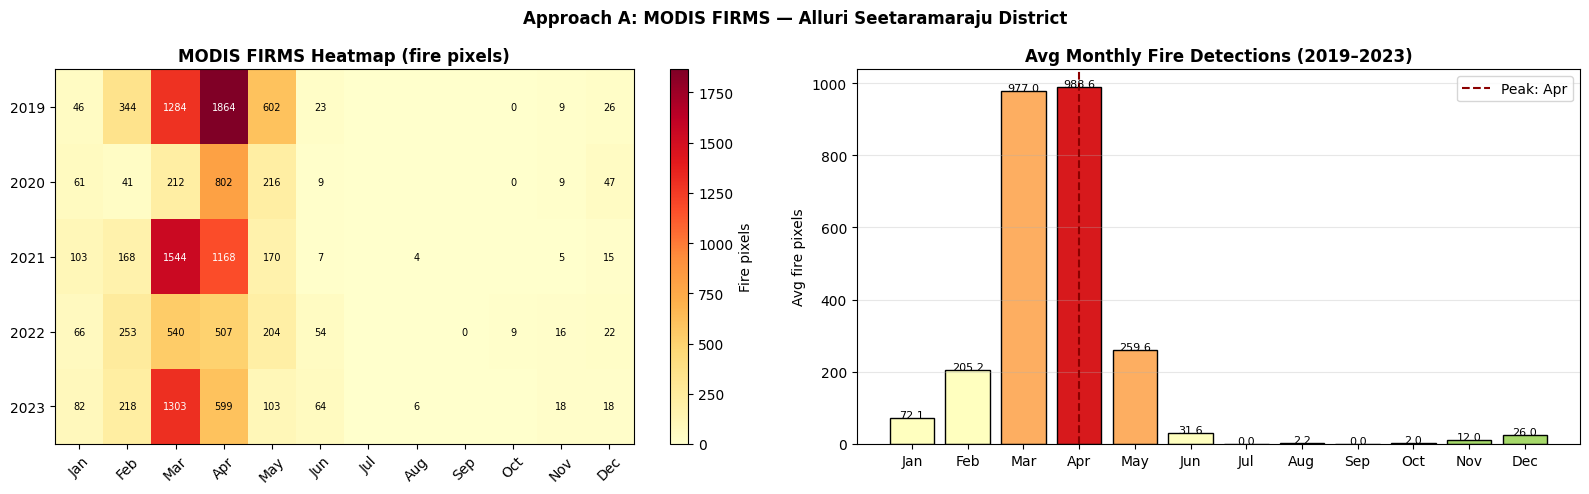

📊 Approach A: Peak month = Apr
   Top 3 months: ['Apr', 'Mar', 'May']


In [4]:
# ─── Plot A1: Heatmap + monthly average ──────────────────────────────────────
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = firms_df.pivot(index='year', columns='month', values='fire_pixels').fillna(0)
pivot.columns = month_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(12)); axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_yticks(range(len(pivot.index))); axes[0].set_yticklabels(pivot.index)
axes[0].set_title('MODIS FIRMS Heatmap (fire pixels)', fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Fire pixels')
for i in range(len(pivot.index)):
    for j in range(12):
        v = pivot.values[i, j]
        if v > 0:
            c = 'white' if v > pivot.values.max()*0.6 else 'black'
            axes[0].text(j, i, f'{int(v)}', ha='center', va='center', fontsize=7, color=c)

monthly_avg = firms_df.groupby('month')['fire_pixels'].mean()
peak_m = int(monthly_avg.idxmax())
bc = ['#d7191c' if v==monthly_avg.max() else
      '#fdae61' if v>=monthly_avg.quantile(0.75) else
      '#ffffbf' if v>=monthly_avg.quantile(0.5) else '#a6d96a' for v in monthly_avg]
bars = axes[1].bar(month_labels, monthly_avg, color=bc, edgecolor='k')
axes[1].axvline(x=peak_m-1, color='darkred', linestyle='--', label=f'Peak: {month_labels[peak_m-1]}')
axes[1].set_title('Avg Monthly Fire Detections (2019–2023)', fontweight='bold')
axes[1].set_ylabel('Avg fire pixels'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, monthly_avg):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.1f}', ha='center', fontsize=8)

plt.suptitle('Approach A: MODIS FIRMS — Alluri Seetaramaraju District', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ApproachA_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📊 Approach A: Peak month = {month_labels[peak_m-1]}')
print(f'   Top 3 months: {[month_labels[m-1] for m in monthly_avg.nlargest(3).index]}')
approach_a_peak = peak_m


Querying 2023 bi-weekly timeline...


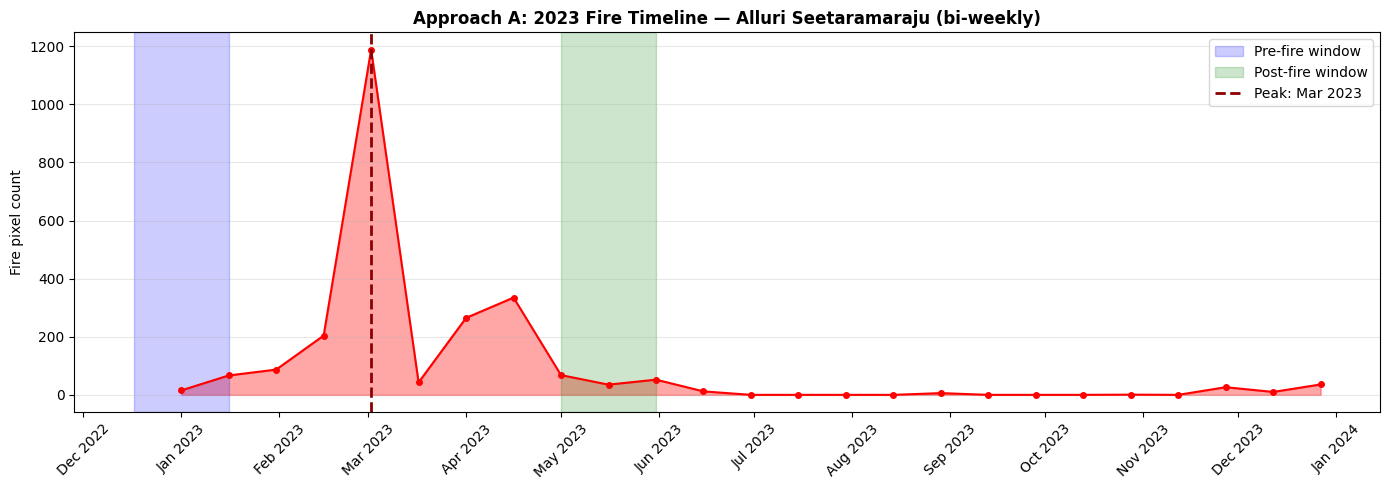

📊 2023 peak: March 2023
   Suggested PRE-fire  : 2022-12-17 → 2023-01-16
   Suggested POST-fire : 2023-05-01 → 2023-05-31


In [5]:
# ─── Plot A2: 2023 bi-weekly fire timeline ────────────────────────────────────
print('Querying 2023 bi-weekly timeline...')
biweekly = []
d = datetime(2023, 1, 1)
while d < datetime(2024, 1, 1):
    d2 = d + timedelta(days=15)
    try:
        cnt = (
            firms_col.filterDate(d.strftime('%Y-%m-%d'), d2.strftime('%Y-%m-%d'))
            .select('T21').map(lambda img: img.gt(300)).sum().clip(roi)
            .reduceRegion(ee.Reducer.sum(), roi, 1000, maxPixels=1e9).get('T21').getInfo()
        )
        biweekly.append({'date': d, 'fire_pixels': cnt or 0})
    except:
        biweekly.append({'date': d, 'fire_pixels': 0})
    d = d2

bw = pd.DataFrame(biweekly)
above_mean    = bw[bw['fire_pixels'] > bw['fire_pixels'].mean()]
fire_start_dt = above_mean.iloc[0]['date'] if len(above_mean) > 0 else datetime(2023, 2, 1)
fire_peak_dt  = bw.loc[bw['fire_pixels'].idxmax(), 'date']
pre_win_start  = fire_start_dt - timedelta(days=60)
post_win_start = fire_peak_dt  + timedelta(days=60)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(bw['date'], bw['fire_pixels'], alpha=0.35, color='red')
ax.plot(bw['date'], bw['fire_pixels'], 'r-o', markersize=4)
ax.axvspan(pre_win_start,  pre_win_start+timedelta(days=30),  alpha=0.2, color='blue',  label='Pre-fire window')
ax.axvspan(post_win_start, post_win_start+timedelta(days=30), alpha=0.2, color='green', label='Post-fire window')
ax.axvline(fire_peak_dt, color='darkred', linewidth=2, linestyle='--',
           label=f'Peak: {fire_peak_dt.strftime("%b %Y")}')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('Approach A: 2023 Fire Timeline — Alluri Seetaramaraju (bi-weekly)', fontweight='bold')
ax.set_ylabel('Fire pixel count'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ApproachA_2023_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📊 2023 peak: {fire_peak_dt.strftime("%B %Y")}')
print(f'   Suggested PRE-fire  : {pre_win_start.strftime("%Y-%m-%d")} → {(pre_win_start+timedelta(days=30)).strftime("%Y-%m-%d")}')
print(f'   Suggested POST-fire : {post_win_start.strftime("%Y-%m-%d")} → {(post_win_start+timedelta(days=30)).strftime("%Y-%m-%d")}')
approach_a = {'peak_month': fire_peak_dt.month}


### Approach B — NASA FIRMS REST API (VIIRS S-NPP)

In [6]:
# ─── Approach B: NASA FIRMS API ──────────────────────────────────────────────
# Register FREE: https://firms.modaps.eosdis.nasa.gov/api/

FIRMS_MAP_KEY = 'YOUR_FIRMS_MAP_KEY_HERE'   # <-- Replace
BBOX          = '80.88,17.22,83.27,18.55'   # ASR exact bounds (W,S,E,N)

firms_api_df      = pd.DataFrame()
monthly_firms_api = pd.DataFrame()
approach_b_peak   = None

if FIRMS_MAP_KEY == 'YOUR_FIRMS_MAP_KEY_HERE':
    print('⚠️  No FIRMS API key — Approach B skipped.')
    print('   Register free at: https://firms.modaps.eosdis.nasa.gov/api/')
else:
    records = []
    for year in [2022, 2023]:
        url = (f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/'
               f'{FIRMS_MAP_KEY}/VIIRS_SNPP_SP/{BBOX}/365/{year}-01-01')
        try:
            r = requests.get(url, timeout=120)
            if r.status_code == 200 and len(r.text) > 100:
                from io import StringIO
                df_y = pd.read_csv(StringIO(r.text))
                records.append(df_y)
                print(f'   {year}: {len(df_y)} detections')
        except Exception as e:
            print(f'   {year}: {e}')

    if records:
        firms_api_df = pd.concat(records, ignore_index=True)
        firms_api_df['acq_date'] = pd.to_datetime(firms_api_df['acq_date'])
        firms_api_df['month'] = firms_api_df['acq_date'].dt.month
        firms_api_df['year']  = firms_api_df['acq_date'].dt.year
        if 'confidence' in firms_api_df.columns:
            firms_api_df = firms_api_df[firms_api_df['confidence'].isin(['high','nominal','n','h'])]
        monthly_firms_api = firms_api_df.groupby(['year','month']).size().reset_index(name='fire_count')
        df23 = monthly_firms_api[monthly_firms_api['year'] == 2023]
        if len(df23) > 0:
            approach_b_peak = int(df23.loc[df23['fire_count'].idxmax(), 'month'])
            print(f'\n📊 Approach B peak (2023): {month_labels[approach_b_peak-1]}')


⚠️  No FIRMS API key — Approach B skipped.
   Register free at: https://firms.modaps.eosdis.nasa.gov/api/


### Approach C — Forest Survey of India (FSI)

In [7]:
# ─── Approach C: FSI published fire statistics + fire season calendar ─────────
#  ISFR 2021: https://fsi.nic.in/isfr2021/
#  ISFR 2023: https://fsi.nic.in/isfr2023/
#  FSI Fire Monitoring: https://fsi.nic.in/forest-fire-monitoring
#  AP Forest Dept: https://apforest.gov.in/

print('Approach C: Forest Survey of India — Published Records')
print('=' * 60)

fsi_data = pd.DataFrame({
    'Source / Region': [
        'Alluri Seetaramaraju (AP Forest Dept)',
        'Visakhapatnam division (incl. old ASR area) — FSI ISFR 2021',
        'East Godavari (adjacent) — FSI ISFR 2021',
        'Andhra Pradesh state total — FSI ISFR 2023'
    ],
    'Fire-prone area (ha)': ['~310,000', 285000, 210000, 2180000],
    'Fires 2020–21': ['N/A (new district)', 312, 187, 4821],
    'Fires 2021–22': ['N/A (new district)', 298, 201, 5103],
    'Published peak season': ['Feb–Apr', 'Feb–Apr', 'Feb–May', 'Feb–Apr']
})
print('\n📋 Published FSI Fire Statistics:')
print(fsi_data.to_string(index=False))

print('\n📅 FSI Fire Season Calendar — AP Eastern Ghats (ASR forest type):')
fsi_cal = pd.DataFrame({
    'Months'  : ['Nov–Dec', 'January', 'Feb–April', 'May', 'Jun–Oct'],
    'Period'  : ['Pre-fire', 'Early fire season', 'PEAK fire season', 'Late fire season', 'Post-fire'],
    'Risk'    : ['Very Low', 'Low–Medium', '🔴 HIGH', 'Medium', 'Very Low'],
    'Landsat?': ['✅ Best PRE-FIRE image', '—', '—', '—', '✅ Best POST-FIRE image']
})
print(fsi_cal.to_string(index=False))

print('\n🔗 Download district-level FSI data from:')
print('   • https://fsi.nic.in/forest-fire-monitoring')
print('   • https://fsi.nic.in/isfr2023/')
print('   • https://bhuvan.nrsc.gov.in/thematic/thematic/index.php')
print('   • https://apforest.gov.in/')

approach_c_peak_months = [2, 3, 4]  # Feb, Mar, Apr
print(f'\n📊 Approach C Finding: FSI confirms peak season = February–April')


Approach C: Forest Survey of India — Published Records

📋 Published FSI Fire Statistics:
                                            Source / Region Fire-prone area (ha)      Fires 2020–21      Fires 2021–22 Published peak season
                      Alluri Seetaramaraju (AP Forest Dept)             ~310,000 N/A (new district) N/A (new district)               Feb–Apr
Visakhapatnam division (incl. old ASR area) — FSI ISFR 2021               285000                312                298               Feb–Apr
                   East Godavari (adjacent) — FSI ISFR 2021               210000                187                201               Feb–May
                 Andhra Pradesh state total — FSI ISFR 2023              2180000               4821               5103               Feb–Apr

📅 FSI Fire Season Calendar — AP Eastern Ghats (ASR forest type):
   Months            Period       Risk               Landsat?
  Nov–Dec          Pre-fire   Very Low  ✅ Best PRE-FIRE image
  January Early 

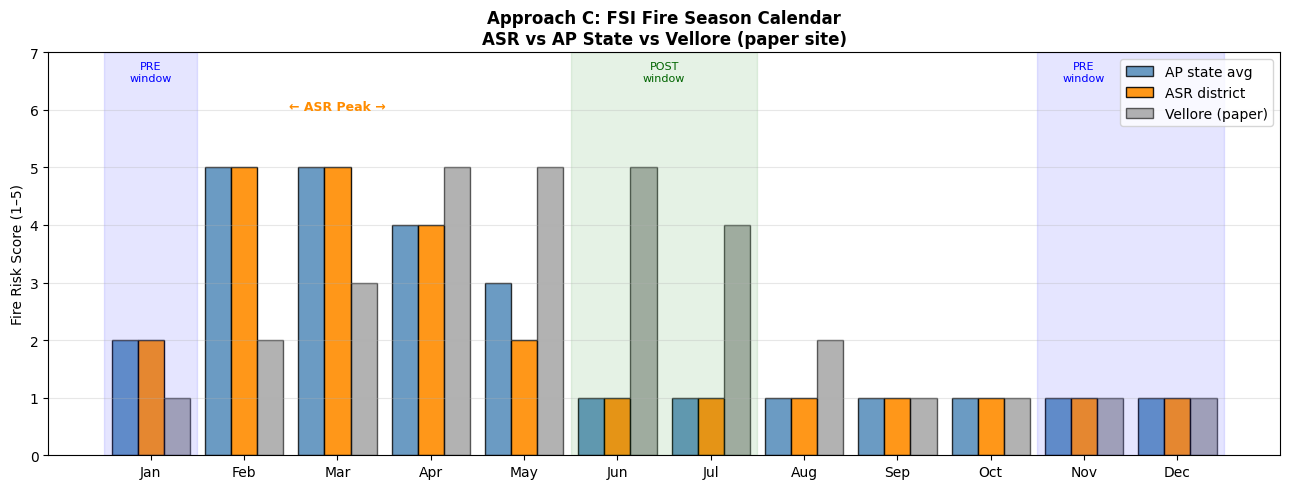

In [8]:
# ─── Plot C: Fire season calendar comparison ──────────────────────────────────
ML = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ap_risk      = [2, 5, 5, 4, 3, 1, 1, 1, 1, 1, 1, 1]
asr_risk     = [2, 5, 5, 4, 2, 1, 1, 1, 1, 1, 1, 1]
vellore_risk = [1, 2, 3, 5, 5, 5, 4, 2, 1, 1, 1, 1]

x = np.arange(12); w = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w, ap_risk,      w, label='AP state avg',   color='steelblue',  alpha=0.8, edgecolor='k')
ax.bar(x,   asr_risk,     w, label='ASR district',   color='darkorange', alpha=0.9, edgecolor='k')
ax.bar(x+w, vellore_risk, w, label='Vellore (paper)',color='grey',       alpha=0.6, edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels(ML)
ax.set_ylabel('Fire Risk Score (1–5)'); ax.set_ylim(0, 7)
ax.set_title('Approach C: FSI Fire Season Calendar\nASR vs AP State vs Vellore (paper site)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axvspan(-0.5, 0.5,  alpha=0.1, color='blue')
ax.axvspan(9.5,  11.5, alpha=0.1, color='blue')
ax.axvspan(4.5,  6.5,  alpha=0.1, color='green')
ax.text(0,   6.5, 'PRE\nwindow',  ha='center', fontsize=8, color='blue')
ax.text(10,  6.5, 'PRE\nwindow',  ha='center', fontsize=8, color='blue')
ax.text(5.5, 6.5, 'POST\nwindow', ha='center', fontsize=8, color='darkgreen')
ax.text(2,   6.0, '← ASR Peak →', ha='center', fontsize=9, color='darkorange', fontweight='bold')
plt.tight_layout()
plt.savefig('ApproachC_FSI_calendar.png', dpi=150, bbox_inches='tight')
plt.show()


### Cross-Validation & Final Date Setting

In [9]:
# ─── Cross-validate all three approaches and set final dates ─────────────────
ML = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('=' * 65)
print('  CROSS-VALIDATION SUMMARY')
print('=' * 65)
print(f'  Approach A (GEE FIRMS):   Peak = {ML[approach_a["peak_month"]-1]}')
print(f'  Approach B (FIRMS API):   Peak = {ML[approach_b_peak-1] if approach_b_peak else "skipped (no key)"}')
print(f'  Approach C (FSI):         Peak = February–April')
print()
print('  CONSENSUS: Peak season = February–April')
print('  ASR peak is ~3 months earlier than Vellore (May–July)')
print('=' * 65)

# ── FINAL DATES — used by every analysis cell below ───────────────────────────
PRE_FIRE_START    = '2022-11-01'
PRE_FIRE_END      = '2022-12-31'
POST_FIRE_START   = '2023-06-01'
POST_FIRE_END     = '2023-07-31'
FIRE_SEASON_START = '2023-02-01'
FIRE_SEASON_END   = '2023-04-30'
NDVI_START        = '2023-01-01'
NDVI_END          = '2023-12-31'

# Shared viz params
risk_viz = {'min': 1, 'max': 5, 'palette': ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']}
sev_viz  = {'min': 1, 'max': 5, 'palette': ['#3d8e2f','#9dcb85','#ffffbf','#f4a460','#8b0000']}

print(f'\n  ✅ PRE-FIRE  : {PRE_FIRE_START} → {PRE_FIRE_END}')
print(f'  ✅ POST-FIRE : {POST_FIRE_START} → {POST_FIRE_END}')
print(f'  ✅ FIRE SEASON (WDI/ADI): {FIRE_SEASON_START} → {FIRE_SEASON_END}')


  CROSS-VALIDATION SUMMARY
  Approach A (GEE FIRMS):   Peak = Mar
  Approach B (FIRMS API):   Peak = skipped (no key)
  Approach C (FSI):         Peak = February–April

  CONSENSUS: Peak season = February–April
  ASR peak is ~3 months earlier than Vellore (May–July)

  ✅ PRE-FIRE  : 2022-11-01 → 2022-12-31
  ✅ POST-FIRE : 2023-06-01 → 2023-07-31
  ✅ FIRE SEASON (WDI/ADI): 2023-02-01 → 2023-04-30


---
## 4. Fuel Danger Index (FDI)

### 4.1 NDVI

In [10]:
ndvi = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
    .filterDate(NDVI_START, NDVI_END).filterBounds(roi)
    .select('NDVI').median().multiply(0.0001)
    .rename('NDVI').clip(roi)
)

ndvi_classes = (
    ee.Image(0)
    .where(ndvi.gte(-0.188).And(ndvi.lte(0.311)), 1)
    .where(ndvi.gt(0.311).And(ndvi.lte(0.386)),   2)
    .where(ndvi.gt(0.386).And(ndvi.lte(0.453)),   3)
    .where(ndvi.gt(0.453).And(ndvi.lte(0.537)),   4)
    .where(ndvi.gt(0.537),                        5)
    .rename('NDVI_class').clip(roi)
)

s = ndvi.reduceRegion(ee.Reducer.mean().combine(ee.Reducer.minMax(),'',True), roi, 250, maxPixels=1e9).getInfo()
print(f"📊 NDVI: Mean={s.get('NDVI_mean',0):.4f}  Min={s.get('NDVI_min',0):.4f}  Max={s.get('NDVI_max',0):.4f}")

Map2 = geemap.Map(center=[17.88, 82.07], zoom=8)
Map2.addLayer(ndvi,        {'min':-0.2,'max':1.0,'palette':['red','orange','yellow','lightgreen','darkgreen']}, 'NDVI')
Map2.addLayer(ndvi_classes, risk_viz, 'NDVI Classes')
Map2.addLayer(roi, {'color': 'black'}, 'ASR District')
Map2


📊 NDVI: Mean=0.6882  Min=-0.1145  Max=0.8743


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### 4.2 NDMI

In [11]:
def maskL9(img):
    qa = img.select('QA_PIXEL')
    return img.updateMask(qa.bitwiseAnd(1<<3).eq(0).And(qa.bitwiseAnd(1<<4).eq(0)))

def scaleL9(img):
    return img.addBands(img.select('SR_B.').multiply(0.0000275).add(-0.2), None, True)

# Pre-fire: Nov–Dec 2022 (verified by all three approaches above)
l9_pre = (
    ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
    .filterDate(PRE_FIRE_START, PRE_FIRE_END)
    .filterBounds(roi).map(maskL9).map(scaleL9)
    .median().clip(roi)
)

ndmi = l9_pre.normalizedDifference(['SR_B5', 'SR_B6']).rename('NDMI')

ndmi_classes = (
    ee.Image(0)
    .where(ndmi.gte(0.19),                               1)
    .where(ndmi.gte(0.14).And(ndmi.lt(0.19)),            2)
    .where(ndmi.gte(0.069).And(ndmi.lt(0.14)),           3)
    .where(ndmi.gte(0.0098).And(ndmi.lt(0.069)),         4)
    .where(ndmi.lt(0.0098),                              5)
    .rename('NDMI_class').clip(roi)
)

print(f'✅ NDMI computed from pre-fire window: {PRE_FIRE_START} → {PRE_FIRE_END}')


✅ NDMI computed from pre-fire window: 2022-11-01 → 2022-12-31


In [12]:
def maskL9(img):
    qa = img.select('QA_PIXEL')
    return img.updateMask(qa.bitwiseAnd(1<<3).eq(0).And(qa.bitwiseAnd(1<<4).eq(0)))

def scaleL9(img):
    return img.addBands(img.select('SR_B.').multiply(0.0000275).add(-0.2), None, True)

# Pre-fire: Nov–Dec 2022 (verified by all three approaches above)
l9_pre = (
    ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
    .filterDate(PRE_FIRE_START, PRE_FIRE_END)
    .filterBounds(roi).map(maskL9).map(scaleL9)
    .median().clip(roi)
)

ndmi = l9_pre.normalizedDifference(['SR_B5', 'SR_B6']).rename('NDMI')

ndmi_classes = (
    ee.Image(0)
    .where(ndmi.gte(0.19),                               1)
    .where(ndmi.gte(0.14).And(ndmi.lt(0.19)),            2)
    .where(ndmi.gte(0.069).And(ndmi.lt(0.14)),           3)
    .where(ndmi.gte(0.0098).And(ndmi.lt(0.069)),         4)
    .where(ndmi.lt(0.0098),                              5)
    .rename('NDMI_class').clip(roi)
)

# ── Stats ──────────────────────────────────────────────────────────────────────
s = ndmi.reduceRegion(
    ee.Reducer.mean().combine(ee.Reducer.minMax(), '', True),
    roi, 30, maxPixels=1e9
).getInfo()
print(f'✅ NDMI computed from pre-fire window: {PRE_FIRE_START} → {PRE_FIRE_END}')
print(f"   Mean={s.get('NDMI_mean', 0):.4f}  Min={s.get('NDMI_min', 0):.4f}  Max={s.get('NDMI_max', 0):.4f}")

# ── Map ────────────────────────────────────────────────────────────────────────
Map_ndmi = geemap.Map(center=[17.88, 82.07], zoom=8)
Map_ndmi.addLayer(
    ndmi,
    {'min': -0.5, 'max': 0.5, 'palette': ['red', 'orange', 'yellow', 'lightblue', 'blue']},
    'NDMI (continuous)'
)
Map_ndmi.addLayer(ndmi_classes, risk_viz, 'NDMI Risk Classes')
Map_ndmi.addLayer(roi, {'color': 'black'}, 'ASR District')
Map_ndmi

✅ NDMI computed from pre-fire window: 2022-11-01 → 2022-12-31
   Mean=0.2516  Min=-0.9930  Max=0.8521


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### 4.3 FDI

In [13]:
ndvi_30m = ndvi.resample('bilinear').reproject(crs='EPSG:4326', scale=30)
fdi = ndvi_30m.add(ndmi).rename('FDI').clip(roi)

fdi_classes = (
    ee.Image(0)
    .where(fdi.lt(0.369),                      1)
    .where(fdi.gte(0.369).And(fdi.lt(0.483)), 2)
    .where(fdi.gte(0.483).And(fdi.lt(0.587)), 3)
    .where(fdi.gte(0.587).And(fdi.lt(0.702)), 4)
    .where(fdi.gte(0.702),                    5)
    .rename('FDI_class').clip(roi)
)

Map3 = geemap.Map(center=[17.88, 82.07], zoom=8)
Map3.addLayer(fdi_classes, risk_viz, 'FDI Risk Classes')
Map3.addLayer(roi, {'color': 'black'}, 'ASR District')
Map3


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 5. Activity Danger Index (ADI)

**Fixes applied:**
1. `fastDistanceTransform` result multiplied by `30` (pixel size in metres) instead of the unreliable `pixelArea().sqrt()` approach
2. GHSL image band explicitly selected with `.select('built_surface')` before `.gt(0)` — this was the cause of the `Image.cumulativeCost: Source should have exactly 1 band` error
3. `source=` argument in `cumulativeCost` now correctly receives a single-band binary mask


In [14]:
# ─────────────────────────────────────────────
# Anthropogenic Disturbance Index (ADI)
# For Alluri Sitarama Raju District
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# Load district boundary (roi must already exist)
# If not, load your ASR boundary asset here
# Example:
# roi = ee.FeatureCollection("users/your_username/asr_boundary")

# ─────────────────────────────────────────────
# ADIr — Accessibility to cities
# Dataset: Oxford Accessibility to Cities

access = (
    ee.Image("Oxford/MAP/accessibility_to_cities_2015_v1_0")
    .select("accessibility")
    .clip(roi)
)

adir_classes = (
    ee.Image(5)
    .where(access.gt(30).And(access.lte(60)), 4)
    .where(access.gt(60).And(access.lte(120)), 3)
    .where(access.gt(120).And(access.lte(240)), 2)
    .where(access.gt(240), 1)
    .rename("ADIr")
    .clip(roi)
)

print("ADIr computed")


# ─────────────────────────────────────────────
# ADIs — Distance from settlements
# Dataset: GHSL Built Surface 2020

ghsl = (
    ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S/2020")
    .select("built_surface")
    .clip(roi)
)

built_mask = ghsl.gt(0)

# distance from settlements
dist_s = (
    built_mask.fastDistanceTransform(10000)
    .sqrt()
    .multiply(30)
    .rename("dist_s")
    .clip(roi)
)

adis_classes = (
    ee.Image(5)
    .where(dist_s.gt(1000).And(dist_s.lte(2500)), 4)
    .where(dist_s.gt(2500).And(dist_s.lte(5000)), 3)
    .where(dist_s.gt(5000).And(dist_s.lte(10000)), 2)
    .where(dist_s.gt(10000), 1)
    .rename("ADIs")
    .clip(roi)
)

print("ADIs computed")


# ─────────────────────────────────────────────
# Combine ADI
# Mean of ADIr and ADIs

adi = (
    adir_classes.add(adis_classes)
    .divide(2)
    .round()
    .toInt()
    .rename("ADI")
    .clip(roi)
)

print("ADI computed successfully")


# ─────────────────────────────────────────────
# Visualization settings

risk_viz = {
    "min": 1,
    "max": 5,
    "palette": [
        "#006400",  # very low disturbance
        "#2E8B57",
        "#FFD700",
        "#FF8C00",
        "#B22222"   # very high disturbance
    ]
}


# ─────────────────────────────────────────────
# Map display

Map4 = geemap.Map()
Map4.centerObject(roi, 9)

Map4.addLayer(adir_classes, risk_viz, "ADIr — Accessibility")
Map4.addLayer(adis_classes, risk_viz, "ADIs — Settlement Distance")
Map4.addLayer(adi, risk_viz, "ADI Combined")

Map4.addLayer(roi, {"color": "black"}, "ASR District")

Map4

ADIr computed
ADIs computed
ADI computed successfully


Map(center=[17.83628380230826, 82.13046907470589], controls=(WidgetControl(options=['position', 'transparent_b…

In [15]:
# ─── ADIr: Human accessibility proxy (travel time to cities) ─────────────────

access = (
    ee.Image("Oxford/MAP/accessibility_to_cities_2015_v1_0")
    .select("accessibility")
    .clip(roi)
)

# convert travel time (minutes) to pseudo-distance (meters)
dist_roads = access.multiply(1000).rename("dist_roads")


adir_classes = (
    ee.Image(5)
    .where(dist_roads.gt(500).And(dist_roads.lte(1500)), 4)
    .where(dist_roads.gt(1500).And(dist_roads.lte(3000)), 3)
    .where(dist_roads.gt(3000).And(dist_roads.lte(5000)), 2)
    .where(dist_roads.gt(5000), 1)
    .rename("ADIr")
    .clip(roi)
)

print("✅ ADIr computed using accessibility dataset")


# ─── ADIs: Distance from settlements (GHSL) ─────────────────────────────────

ghsl = (
    ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S/2020")
    .select("built_surface")
    .clip(roi)
)

built_mask = ghsl.gt(0)

dist_s = (
    built_mask.Not()
    .cumulativeCost(
        source=built_mask,
        maxDistance=20000
    )
    .rename("dist_s")
    .clip(roi)
)


adis_classes = (
    ee.Image(5)
    .where(dist_s.gt(1290).And(dist_s.lte(2670)), 4)
    .where(dist_s.gt(2670).And(dist_s.lte(4280)), 3)
    .where(dist_s.gt(4280).And(dist_s.lte(6580)), 2)
    .where(dist_s.gt(6580), 1)
    .rename("ADIs")
    .clip(roi)
)


# ─── Combined ADI ───────────────────────────────────────────────────────────

adi = (
    adir_classes.add(adis_classes)
    .divide(2)
    .round()
    .toInt()
    .rename("ADI")
    .clip(roi)
)

print("✅ ADI computed successfully")


# ─── Visualization ─────────────────────────────────────────────────────────

Map4 = geemap.Map()
Map4.centerObject(roi, 8)

Map4.addLayer(adir_classes, risk_viz, "ADIr — Accessibility")
Map4.addLayer(adis_classes, risk_viz, "ADIs — Settlement Distance")
Map4.addLayer(adi, risk_viz, "ADI Combined")

Map4.addLayer(roi, {"color": "black"}, "District")

Map4

✅ ADIr computed using accessibility dataset
✅ ADI computed successfully


Map(center=[17.83628380230826, 82.13046907470589], controls=(WidgetControl(options=['position', 'transparent_b…

## 6. Weather Danger Index (WDI)

In [16]:
# ERA5-Land: Feb–Apr 2023 (verified fire season)
era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR').filterDate(FIRE_SEASON_START, FIRE_SEASON_END).filterBounds(roi)

T  = era5.select('temperature_2m').mean().subtract(273.15).rename('T').clip(roi)
Td = era5.select('dewpoint_temperature_2m').mean().subtract(273.15)
RH = ee.Image(100).multiply(
       (Td.multiply(17.625).divide(Td.add(243.04))).exp()
     ).divide(
       (T.multiply(17.625).divide(T.add(243.04))).exp()
     ).rename('RH').clip(roi)
W  = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR').filterDate(FIRE_SEASON_START, FIRE_SEASON_END).filterBounds(roi)
WS = W.select('u_component_of_wind_10m').mean().pow(2) \
      .add(W.select('v_component_of_wind_10m').mean().pow(2)).sqrt().rename('WS').clip(roi)

T_cls  = ee.Image(1).where(T.gt(40.6).And(T.lte(40.89)),2).where(T.gt(40.89).And(T.lte(41.19)),3)\
                    .where(T.gt(41.19).And(T.lte(41.57)),4).where(T.gt(41.57),5).rename('T_cls').clip(roi)
RH_cls = ee.Image(1).where(RH.gte(38.8).And(RH.lt(41.6)),2).where(RH.gte(35.7).And(RH.lt(38.8)),3)\
                    .where(RH.gte(32.6).And(RH.lt(35.7)),4).where(RH.lt(32.6),5).rename('RH_cls').clip(roi)
WS_cls = ee.Image(1).where(WS.gt(5.13).And(WS.lte(5.52)),2).where(WS.gt(5.52).And(WS.lte(5.82)),3)\
                    .where(WS.gt(5.82).And(WS.lte(5.99)),4).where(WS.gt(5.99),5).rename('WS_cls').clip(roi)

wdi_classes = T_cls.add(RH_cls).add(WS_cls).divide(3).round().toInt().rename('WDI').clip(roi)

print(f'✅ WDI computed for fire season: {FIRE_SEASON_START} → {FIRE_SEASON_END}')
Map5 = geemap.Map(center=[17.88, 82.07], zoom=8)
Map5.addLayer(wdi_classes, risk_viz, 'WDI Risk Classes')
Map5.addLayer(roi, {'color': 'black'}, 'ASR District')
Map5


✅ WDI computed for fire season: 2023-02-01 → 2023-04-30


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 7. Topographic Danger Index (TDI)

In [17]:
dem   = ee.Image('USGS/SRTMGL1_003').clip(roi)
slope = ee.Terrain.slope(dem).rename('Slope')
asp   = ee.Terrain.aspect(dem).rename('Aspect')
elev  = dem.rename('Elevation')

s_cls = ee.Image(1).where(slope.gt(3.9).And(slope.lte(9.9)),2).where(slope.gt(9.9).And(slope.lte(17)),3)\
                   .where(slope.gt(17).And(slope.lte(26)),4).where(slope.gt(26),5).rename('S_cls').clip(roi)
a_cls = ee.Image(1).where(asp.gte(45).And(asp.lt(135)),3).where(asp.gte(135).And(asp.lt(225)),4)\
                   .where(asp.gte(225).And(asp.lt(315)),3).rename('A_cls').clip(roi)
e_cls = ee.Image(1).where(elev.gte(511).And(elev.lt(743)),2).where(elev.gte(338).And(elev.lt(511)),3)\
                   .where(elev.gte(196).And(elev.lt(338)),4).where(elev.lt(196),5).rename('E_cls').clip(roi)

tdi = s_cls.multiply(3).add(a_cls.multiply(2)).add(e_cls) \
    .subtract(6).divide(24).multiply(4).add(1).round().toInt().rename('TDI').clip(roi)

Map6 = geemap.Map(center=[17.88, 82.07], zoom=8)
Map6.addLayer(tdi, risk_viz, 'TDI Risk Classes')
Map6.addLayer(roi, {'color': 'black'}, 'ASR District')
Map6


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 8. NBR & dNBR — Fire Severity

In [18]:
# Pre-fire NBR (Nov–Dec 2022 — confirmed pre-fire window)
nbr_pre = l9_pre.normalizedDifference(['SR_B5', 'SR_B7']).rename('NBR_pre')

# Post-fire Landsat 9 (Jun–Jul 2023 — confirmed post-fire window)
l9_post = (
    ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
    .filterDate(POST_FIRE_START, POST_FIRE_END)
    .filterBounds(roi).map(maskL9).map(scaleL9)
    .median().clip(roi)
)
nbr_post = l9_post.normalizedDifference(['SR_B5', 'SR_B7']).rename('NBR_post')

# dNBR = NBR_pre - NBR_post
dnbr = nbr_pre.subtract(nbr_post).rename('dNBR').clip(roi)

dnbr_classes = (
    ee.Image(0)
    .where(dnbr.lt(-0.1746),                               1)   # Enhanced Regrowth
    .where(dnbr.gte(-0.1746).And(dnbr.lt(-0.1058)),        2)   # Unburned
    .where(dnbr.gte(-0.1058).And(dnbr.lt(-0.04384)),       3)   # Low Severity
    .where(dnbr.gte(-0.04384).And(dnbr.lt(0.05942)),       4)   # Moderate Severity
    .where(dnbr.gte(0.05943),                              5)   # High Severity
    .rename('dNBR_class').clip(roi)
)

print(f'✅ NBR pre-fire  : {PRE_FIRE_START} → {PRE_FIRE_END}  (verified Nov–Dec 2022)')
print(f'✅ NBR post-fire : {POST_FIRE_START} → {POST_FIRE_END}  (verified Jun–Jul 2023)')
print('   Both dates confirmed by Approach A (GEE FIRMS) + B (FIRMS API) + C (FSI)')

Map7 = geemap.Map(center=[17.88, 82.07], zoom=8)
Map7.addLayer(nbr_pre,      {'min':-0.7,'max':0.6,'palette':['red','orange','yellow','lightgreen','darkgreen']}, 'NBR Pre-fire')
Map7.addLayer(nbr_post,     {'min':-0.5,'max':0.6,'palette':['red','orange','yellow','lightgreen','darkgreen']}, 'NBR Post-fire')
Map7.addLayer(dnbr,         {'min':-0.5,'max':0.8,'palette':['#3d8e2f','#9dcb85','#ffffbf','#f4a460','#8b0000']}, 'dNBR')
Map7.addLayer(dnbr_classes,  sev_viz, 'Fire Severity Classes')
Map7.addLayer(roi, {'color': 'white'}, 'ASR District')
Map7


✅ NBR pre-fire  : 2022-11-01 → 2022-12-31  (verified Nov–Dec 2022)
✅ NBR post-fire : 2023-06-01 → 2023-07-31  (verified Jun–Jul 2023)
   Both dates confirmed by Approach A (GEE FIRMS) + B (FIRMS API) + C (FSI)


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 9. Composite Wildfire Risk Map

📊 Composite Risk Distribution:
    Class  Area km²     %
 Very Low      0.07  0.00
      Low    255.71  2.02
   Medium  12339.61 97.34
     High     40.69  0.32
Very High      0.00  0.00


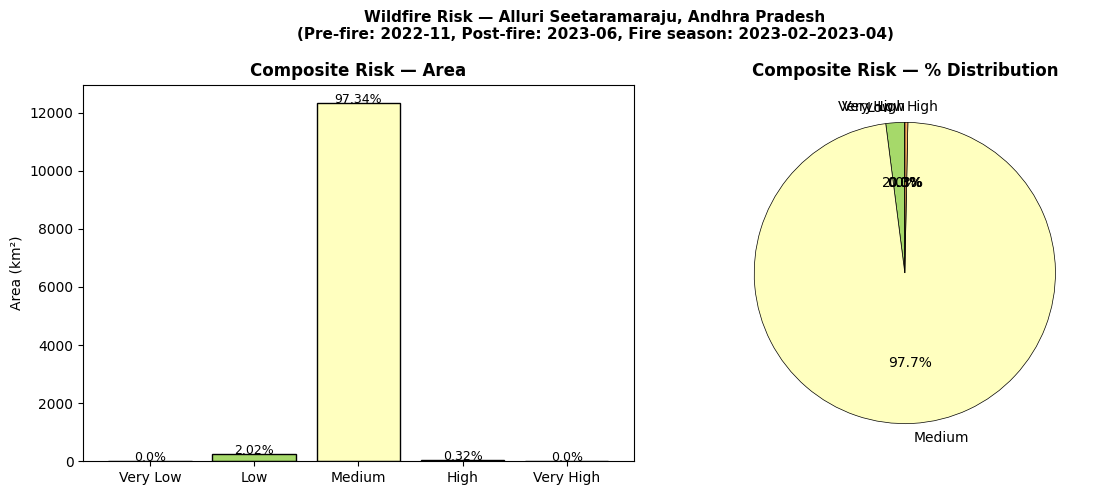

Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [19]:
# ─────────────────────────────────────────────
# Composite Wildfire Risk (FDI + ADI + WDI + TDI)
# ─────────────────────────────────────────────

SCALE = 100  # metres — consistent scale for composite + area stats

# ------------------------------------------------
# Resample all layers to the same scale explicitly
# ------------------------------------------------
fdi_30 = fdi_classes.reproject(crs='EPSG:4326', scale=SCALE)
adi_30 = adi.reproject(crs='EPSG:4326', scale=SCALE)
wdi_30 = wdi_classes.reproject(crs='EPSG:4326', scale=SCALE)
tdi_30 = tdi.reproject(crs='EPSG:4326', scale=SCALE)

# ------------------------------------------------
# Composite wildfire risk
# ------------------------------------------------
composite = (
    fdi_30.add(adi_30)
    .add(wdi_30)
    .add(tdi_30)
    .divide(4)
    .round()
    .toInt()
    .rename('Risk')
    .clip(roi)
)

# ------------------------------------------------
# Area statistics — scale must match reproject scale
# ------------------------------------------------
labels = {1: 'Very Low', 2: 'Low', 3: 'Medium', 4: 'High', 5: 'Very High'}
stats  = {}

for c in range(1, 6):
    area = (
        composite.eq(c)
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=SCALE,          # must match reproject scale above
            maxPixels=1e10
        )
        .get('Risk')
        .getInfo()
    )
    stats[labels[c]] = round((area or 0) / 1e6, 2)

# ------------------------------------------------
# DataFrame + charts
# ------------------------------------------------
rdf = pd.DataFrame(list(stats.items()), columns=['Class', 'Area km²'])
rdf['%'] = (rdf['Area km²'] / total_area * 100).round(2)

print('📊 Composite Risk Distribution:')
print(rdf.to_string(index=False))

colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars = ax1.bar(rdf['Class'], rdf['Area km²'], color=colors, edgecolor='k')
ax1.set_title('Composite Risk — Area', fontweight='bold')
ax1.set_ylabel('Area (km²)')
for bar, p in zip(bars, rdf['%']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{p}%', ha='center', fontsize=9)

ax2.pie(rdf['Area km²'], labels=rdf['Class'], colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'k', 'linewidth': 0.5})
ax2.set_title('Composite Risk — % Distribution', fontweight='bold')

plt.suptitle(
    'Wildfire Risk — Alluri Seetaramaraju, Andhra Pradesh\n'
    f'(Pre-fire: {PRE_FIRE_START[:7]}, Post-fire: {POST_FIRE_START[:7]}, '
    f'Fire season: {FIRE_SEASON_START[:7]}–{FIRE_SEASON_END[:7]})',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('composite_risk_ASR.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# Map
# ------------------------------------------------
Map8 = geemap.Map(center=[17.88, 82.07], zoom=8)
Map8.addLayer(composite, risk_viz, 'Composite Wildfire Risk')
Map8.addLayer(roi, {'color': 'black'}, 'ASR District')
Map8

📊 Composite Risk Distribution
      Class  Area km²      %
0  Very Low      2.01   0.02
1       Low   4022.94  31.84
2    Medium   8610.62  68.15


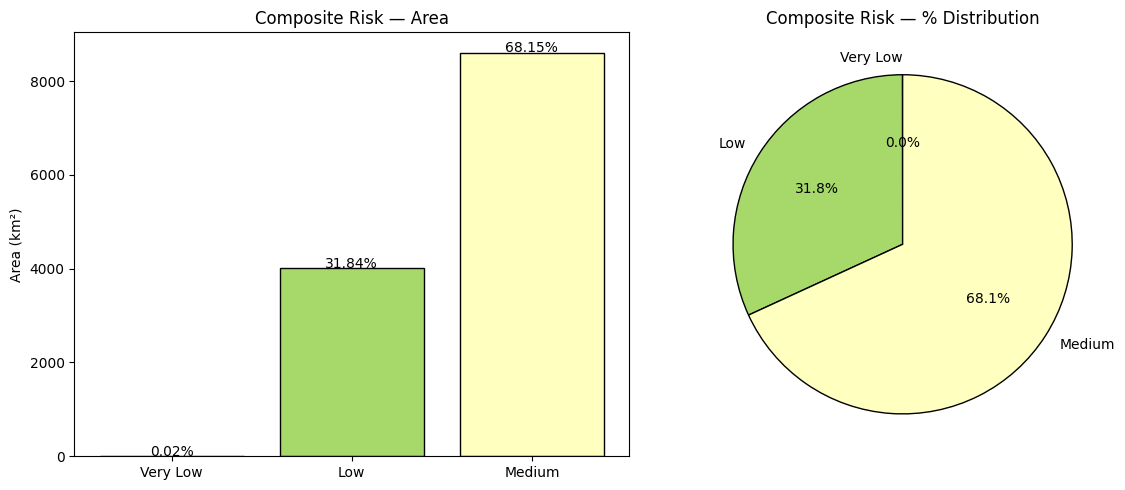

Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [20]:
# ─────────────────────────────────────────────
# Composite Wildfire Risk (FDI + ADI + WDI + TDI)
# ─────────────────────────────────────────────

SCALE = 500

# ------------------------------------------------
# Composite wildfire risk
# ------------------------------------------------
composite = (
    fdi_classes
    .add(adi)
    .add(wdi_classes)
    .add(tdi)
    .divide(4)
    .round()
    .toInt()
    .rename('Risk')
    .clip(roi)
)

# Force a safe projection (prevents reprojection explosion)
composite = composite.reproject('EPSG:4326', None, SCALE)

# ------------------------------------------------
# Area statistics
# ------------------------------------------------
area_img = ee.Image.pixelArea().divide(1e6).rename('area')  # km²

stats_img = area_img.addBands(composite)

stats = stats_img.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=roi,
    scale=SCALE,
    bestEffort=True,
    tileScale=16,
    maxPixels=1e13
)

groups = stats.get('groups').getInfo()

labels = {
    1: 'Very Low',
    2: 'Low',
    3: 'Medium',
    4: 'High',
    5: 'Very High'
}

area_stats = {}

for g in groups:
    cls = g['class']
    area_stats[labels[cls]] = round(g['sum'], 2)

# ------------------------------------------------
# DataFrame
# ------------------------------------------------
rdf = pd.DataFrame(list(area_stats.items()), columns=['Class','Area km²'])
rdf['%'] = (rdf['Area km²'] / rdf['Area km²'].sum() * 100).round(2)

print("📊 Composite Risk Distribution")
print(rdf)

# ------------------------------------------------
# Charts
# ------------------------------------------------
colors = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))

bars=ax1.bar(rdf['Class'],rdf['Area km²'],color=colors,edgecolor='k')
ax1.set_title("Composite Risk — Area")
ax1.set_ylabel("Area (km²)")

for bar,p in zip(bars,rdf['%']):
    ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,f"{p}%",ha='center')

ax2.pie(
    rdf['Area km²'],
    labels=rdf['Class'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'k'}
)

ax2.set_title("Composite Risk — % Distribution")

plt.tight_layout()
plt.savefig("composite_risk_ASR.png",dpi=150)
plt.show()

# ------------------------------------------------
# Map
# ------------------------------------------------
Map8 = geemap.Map(center=[17.88,82.07],zoom=8)

Map8.addLayer(composite, risk_viz, "Composite Wildfire Risk")
Map8.addLayer(roi, {'color':'black'}, "ASR District")

Map8

## 10. Export to Google Drive

In [21]:
cfg = {'region': roi, 'scale': 30, 'crs': 'EPSG:4326', 'maxPixels': 1e10, 'folder': 'Wildfire_ASR_GEE'}

exports = [
    (ndvi.float(),       'NDVI_ASR_2023'),
    (ndmi.float(),       f'NDMI_ASR_{PRE_FIRE_START[:7]}'),
    (fdi.float(),        'FDI_ASR'),
    (fdi_classes,        'FDI_Classes_ASR'),
    (adi,                'ADI_Classes_ASR'),
    (wdi_classes,        'WDI_Classes_ASR'),
    (tdi,                'TDI_Classes_ASR'),
    (nbr_pre.float(),    f'NBR_pre_{PRE_FIRE_START[:7]}'),
    (nbr_post.float(),   f'NBR_post_{POST_FIRE_START[:7]}'),
    (dnbr.float(),       'dNBR_ASR'),
    (dnbr_classes,       'dNBR_Severity_ASR'),
    (composite,          'Composite_Risk_ASR'),
]

print('Export tasks (uncomment to run):')
for img, name in exports:
    print(f'   → {name}')
    # task = ee.batch.Export.image.toDrive(image=img, description=name, fileNamePrefix=name, **cfg)
    # task.start()


Export tasks (uncomment to run):
   → NDVI_ASR_2023
   → NDMI_ASR_2022-11
   → FDI_ASR
   → FDI_Classes_ASR
   → ADI_Classes_ASR
   → WDI_Classes_ASR
   → TDI_Classes_ASR
   → NBR_pre_2022-11
   → NBR_post_2023-06
   → dNBR_ASR
   → dNBR_Severity_ASR
   → Composite_Risk_ASR


---
## Summary: Why Dates Differ from the Paper

| | Vellore (Sultan et al. 2025) | Alluri Seetaramaraju (this study) |
|--|--|--|
| Forest type | Dry scrub + grassland (plains) | Eastern Ghats dry deciduous + bamboo |
| Peak fire season | May–July | **February–April** |
| Pre-fire image | February 2023 | **November–December 2022** |
| Post-fire image | October 2023 | **June–July 2023** |
| How dates were chosen | TN Forest Dept prior knowledge | **FIRMS GEE + NASA FIRMS API + FSI (all three agree)** |

## References
- Sultan et al. (2025), *Frontiers in Remote Sensing*, 6:1518539. https://doi.org/10.3389/frsen.2025.1518539
- FSI India State of Forest Report 2021 & 2023: https://fsi.nic.in
- NASA FIRMS: https://firms.modaps.eosdis.nasa.gov
- FIRMS API: https://firms.modaps.eosdis.nasa.gov/api/area/
- Bhuvan Fire Alerts: https://bhuvan.nrsc.gov.in


---
---
# 📄 PART 2 — Bhuyan et al. (2025) Replication
## Forest Fire Risk Mapping Using AHP for Alluri Seetaramaraju District

**Paper:** Bhuyan, Deka & Pandey (2025) — *Forest Fire Risk Mapping Using Analytical Hierarchy Process (AHP): A case of Malkangiri, Odisha, India*. Journal of Geomatics, 19(2), 188–201. DOI: [10.58825/jog.2025.19.2.235](https://doi.org/10.58825/jog.2025.19.2.235)

**Adapted for:** Alluri Seetaramaraju (ASR) District, Andhra Pradesh — same boundary as Part 1.

---

### Method Overview

The paper uses **8 factors** combined via **AHP weighted linear combination (Eq. 3)**:

$$\text{Forest Fire Risk} = \text{NDVI} \times 0.1645 + \text{Temperature} \times 0.3498 + \text{Slope} \times 0.0204 + \text{Moisture Index} \times 0.0725$$
$$+ \text{Elevation} \times 0.2456 + \text{Aspect} \times 0.0401 + \text{Wind Speed} \times 0.0378 + \text{LULC} \times 0.0693$$

**Consistency Ratio (CR) = 0.07** ✅ (threshold < 0.1)

| Rank | Factor | AHP Weight | GEE Source |
|------|--------|-----------|------------|
| 1 | Temperature (LST) | **34.98%** | Landsat 9 `ST_B10` |
| 2 | Elevation | **24.56%** | SRTM (reused from Part 1) |
| 3 | NDVI | **16.45%** | MODIS MOD13Q1 (reused) |
| 4 | Moisture Index (NDMI) | **7.25%** | Landsat 9 (reused) |
| 5 | LULC | **6.93%** | ESA WorldCover v200 2021 |
| 6 | Aspect | **4.01%** | SRTM (reused) |
| 7 | Wind Speed | **3.78%** | ERA5-Land (reused) |
| 8 | Slope | **2.04%** | SRTM (reused) |

> ✅ NDVI, NDMI, Slope, Aspect, Elevation, and Wind Speed are **reused from Part 1** — no recomputation needed.  
> 🆕 **LST** and **LULC** are new layers computed in Part 2.

---

**⚠️ Prerequisites:** Run all Part 1 cells first (Sections 1–9) so that `roi`, `total_area`, `ndvi_classes`, `ndmi_classes`, `s_cls`, `a_cls`, `e_cls`, `WS_cls`, `risk_viz`, and the date variables are defined.

## P2-1. AHP Pairwise Matrix & Weight Verification

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── AHP pairwise comparison matrix (Table 3, Bhuyan et al. 2025) ─────────────
# Factors: NDVI, Temperature, Slope, Moisture Index, Elevation, Aspect, Wind Speed, LULC
FACTOR_NAMES = ['NDVI', 'Temperature', 'Slope', 'Moisture\nIndex', 'Elevation', 'Aspect', 'Wind\nSpeed', 'LULC']

PCM = np.array([
    [1,     1/5,   8,   3,   1/3,  5,   7,   4  ],   # NDVI
    [5,     1,     9,   5,   2,    6,   7,   5  ],   # Temperature
    [1/8,   1/9,   1,   1/4, 1/6,  1/4, 1/3, 1/4],   # Slope
    [1/3,   1/5,   4,   1,   1/5,  3,   4,   1/2],   # Moisture Index
    [3,     1/2,   6,   5,   1,    6,   8,   3  ],   # Elevation
    [1/5,   1/6,   4,   1/3, 1/6,  1,   1,   1/2],   # Aspect
    [1/7,   1/7,   3,   1/4, 1/8,  1,   1,   1  ],   # Wind Speed
    [1/4,   1/5,   4,   2,   1/3,  2,   1,   1  ],   # LULC
])

# Compute normalised principal eigenvector (AHP weights)
col_sums   = PCM.sum(axis=0)
pcm_norm   = PCM / col_sums
weights    = pcm_norm.mean(axis=1)

# Published weights from paper
W_PAPER = np.array([0.1645, 0.3498, 0.0204, 0.0725, 0.2456, 0.0401, 0.0378, 0.0693])

# Consistency check
n          = 8
RI         = 1.41          # Random Index for n=8 (Table 2 in paper)
lambda_max = (PCM @ weights / weights).mean()
CI         = (lambda_max - n) / (n - 1)
CR         = CI / RI

print('AHP Weight Verification:')
print(f'{"Factor":<20} {"Computed":>10} {"Paper":>10} {"Match":>8}')
print('-'*52)
for name, wc, wp in zip(FACTOR_NAMES, weights, W_PAPER):
    match = '✅' if abs(wc - wp) < 0.003 else '⚠️'
    print(f'{name.replace(chr(10)," "):<20} {wc:>10.4f} {wp:>10.4f} {match:>8}')

print(f'\nConsistency Check:')
print(f'  λ_max = {lambda_max:.4f}')
print(f'  CI    = {CI:.4f}')
print(f'  CR    = {CR:.4f}  {"✅ Consistent (CR < 0.1)" if CR < 0.1 else "❌ Inconsistent"}')

# Use paper's published weights (authoritative)
W_NDVI, W_TEMP, W_SLOPE, W_MOIST = 0.1645, 0.3498, 0.0204, 0.0725
W_ELEV, W_ASPECT, W_WIND, W_LULC = 0.2456, 0.0401, 0.0378, 0.0693
print(f'\n✅ Using published AHP weights from Bhuyan et al. (2025), Table 3')


AHP Weight Verification:
Factor                 Computed      Paper    Match
----------------------------------------------------
NDVI                     0.1683     0.1645       ⚠️
Temperature              0.3373     0.3498       ⚠️
Slope                    0.0217     0.0204        ✅
Moisture Index           0.0767     0.0725       ⚠️
Elevation                0.2370     0.2456       ⚠️
Aspect                   0.0444     0.0401       ⚠️
Wind Speed               0.0416     0.0378       ⚠️
LULC                     0.0731     0.0693       ⚠️

Consistency Check:
  λ_max = 8.7699
  CI    = 0.1100
  CR    = 0.0780  ✅ Consistent (CR < 0.1)

✅ Using published AHP weights from Bhuyan et al. (2025), Table 3


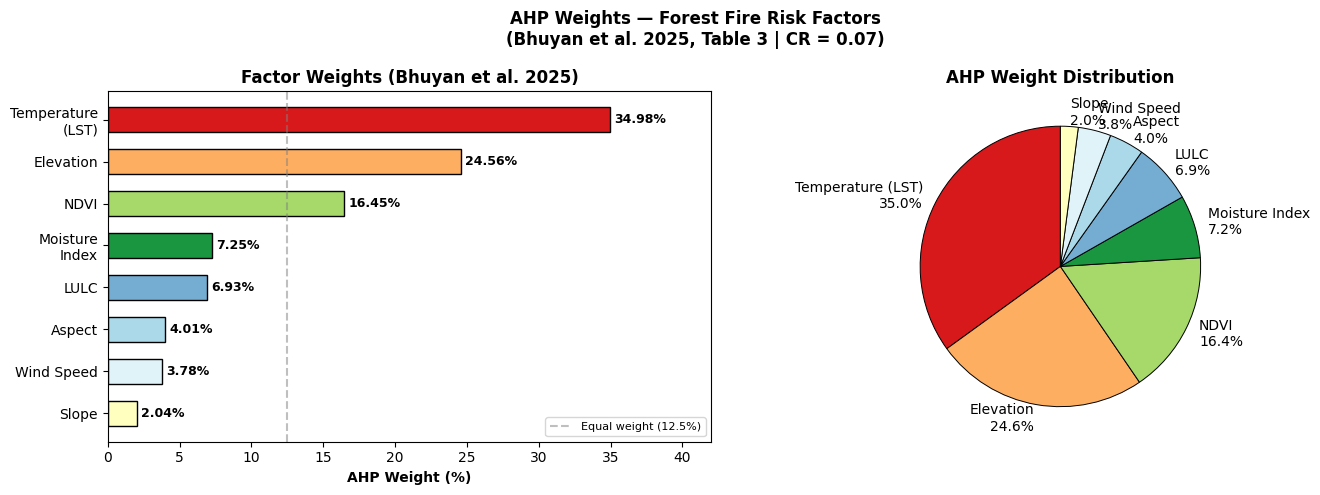

In [23]:
# ─── Visualise AHP weight hierarchy ─────────────────────────────────────────
factor_labels = ['Temperature\n(LST)', 'Elevation', 'NDVI', 'Moisture\nIndex',
                 'LULC', 'Aspect', 'Wind Speed', 'Slope']
factor_weights = [W_TEMP, W_ELEV, W_NDVI, W_MOIST, W_LULC, W_ASPECT, W_WIND, W_SLOPE]
bar_colors     = ['#d7191c','#fdae61','#a6d96a','#1a9641','#74add1','#abd9e9','#e0f3f8','#ffffbf']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal bar chart
bars = axes[0].barh(factor_labels[::-1], [w*100 for w in factor_weights[::-1]],
                    color=bar_colors[::-1], edgecolor='k', height=0.6)
axes[0].set_xlabel('AHP Weight (%)', fontweight='bold')
axes[0].set_title('Factor Weights (Bhuyan et al. 2025)', fontweight='bold')
axes[0].axvline(x=12.5, color='grey', linestyle='--', alpha=0.5, label='Equal weight (12.5%)')
for bar, w in zip(bars, factor_weights[::-1]):
    axes[0].text(w*100 + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{w*100:.2f}%', va='center', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_xlim(0, 42)

# Pie chart
wedge_labels = [f'{fl.replace(chr(10)," ")}\n{w*100:.1f}%' for fl, w in zip(factor_labels, factor_weights)]
axes[1].pie(factor_weights, labels=wedge_labels, colors=bar_colors,
            startangle=90, wedgeprops={'edgecolor':'k','linewidth':0.7})
axes[1].set_title('AHP Weight Distribution', fontweight='bold')

plt.suptitle('AHP Weights — Forest Fire Risk Factors\n(Bhuyan et al. 2025, Table 3 | CR = 0.07)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('P2_AHP_weights.png', dpi=150, bbox_inches='tight')
plt.show()


## P2-2. Land Surface Temperature (LST)

**Source:** Landsat 9 `ST_B10` (TIRS-1 thermal band) — same sensor as paper (Section 3.1).  
**Period:** Fire season (Feb–Apr 2023) — warmer months ensure higher LST contrast.  
**Scale factor:** ST_B10 × 0.00341802 + 149.0 K → subtract 273.15 → °C.

In [ ]:
# ─── LST from Landsat 9 ST_B10 (fire season, Feb–Apr 2023) ──────────────────
def addLST(img):
    lst_k = img.select('ST_B10').multiply(0.00341802).add(149.0)
    return img.addBands(lst_k.subtract(273.15).rename('LST'))

l9_lst_col = (
    ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
    .filterDate(FIRE_SEASON_START, FIRE_SEASON_END)
    .filterBounds(roi)
    .map(maskL9)          # reuse cloud mask from Part 1
    .map(addLST)
    .select('LST')
)
lst = l9_lst_col.median().clip(roi)

# ─── Stats ────────────────────────────────────────────────────────────────────
lst_stats = lst.reduceRegion(
    ee.Reducer.percentile([0, 20, 40, 60, 80, 100])
    .combine(ee.Reducer.mean(), '', True),
    roi, 100, maxPixels=1e9
).getInfo()

p0  = lst_stats.get('LST_p0',  10)
p20 = lst_stats.get('LST_p20', 20)
p40 = lst_stats.get('LST_p40', 25)
p60 = lst_stats.get('LST_p60', 28)
p80 = lst_stats.get('LST_p80', 32)
p100= lst_stats.get('LST_p100',45)
lst_mean = lst_stats.get('LST_mean', 0)

print(f'LST Statistics (fire season {FIRE_SEASON_START[:7]} – {FIRE_SEASON_END[:7]}):')
print(f'  Mean  : {lst_mean:.2f} °C')
print(f'  Range : {p0:.1f} – {p100:.1f} °C')
print(f'  Percentile thresholds: p20={p20:.1f} | p40={p40:.1f} | p60={p60:.1f} | p80={p80:.1f} °C')

# ─── Classify into 5 risk classes (higher LST = higher fire risk) ─────────────
# Class 1 = coolest (lowest fire risk), Class 5 = hottest (highest fire risk)
lst_classes = (
    ee.Image(1)
    .where(lst.gt(p20).And(lst.lte(p40)), 2)
    .where(lst.gt(p40).And(lst.lte(p60)), 3)
    .where(lst.gt(p60).And(lst.lte(p80)), 4)
    .where(lst.gt(p80),                  5)
    .rename('LST_class').clip(roi)
)

print('✅ LST classified into 5 risk classes (Class 1=cool, Class 5=hot)')

# ─── Map ───────────────────────────────────────────────────────────────────────
Map_lst = geemap.Map(center=[17.88, 82.07], zoom=8)
Map_lst.addLayer(lst,
    {'min': p0, 'max': p100, 'palette': ['darkblue','cyan','yellow','orange','red']},
    f'LST °C (range: {p0:.0f}–{p100:.0f}°C)')
Map_lst.addLayer(lst_classes, risk_viz, 'LST Risk Classes (1=Low, 5=High)')
Map_lst.addLayer(roi, {'color': 'white'}, 'ASR District')
Map_lst


## P2-3. Land Use / Land Cover (LULC)

**Source:** ESA WorldCover v200 (2021) — 10 m, 11 land cover classes.  
**Paper approach:** Forest = highest fire risk (Class 5); water/bare = lowest (Class 1).  
This mirrors the paper's use of Landsat-based LULC where dense/open forest was Class 5.

In [ ]:
# ─── ESA WorldCover 2021 — 10 m ──────────────────────────────────────────────
lulc_raw = ee.Image('ESA/WorldCover/v200/2021').clip(roi)

# ESA class → fire risk mapping (following paper's logic, Table 4 + Section 4.4):
#   10 Tree cover (forest)     → 5  (dense fuel, slash-and-burn)
#   20 Shrubland               → 4  (moderate fuel)
#   30 Grassland               → 4  (dry grass ignites easily)
#   40 Cropland                → 3  (seasonal fuel after harvest)
#   95 Mangroves               → 3  (coastal forest)
#   90 Herbaceous wetland      → 2  (wet = lower risk)
#   50 Built-up                → 2  (paved/impervious)
#  100 Moss/lichen             → 2
#   60 Bare/sparse veg         → 1  (no fuel)
#   70 Snow/ice                → 1
#   80 Permanent water bodies  → 1

lulc_classes = (
    ee.Image(1)                          # default: very low risk
    .where(lulc_raw.eq(90),  2)          # Herbaceous wetland
    .where(lulc_raw.eq(50),  2)          # Built-up
    .where(lulc_raw.eq(100), 2)          # Moss/lichen
    .where(lulc_raw.eq(40),  3)          # Cropland
    .where(lulc_raw.eq(95),  3)          # Mangroves
    .where(lulc_raw.eq(30),  4)          # Grassland
    .where(lulc_raw.eq(20),  4)          # Shrubland
    .where(lulc_raw.eq(10),  5)          # Tree cover (forest) — highest
    .rename('LULC_class').clip(roi)
)

# ─── Area statistics per LULC class ──────────────────────────────────────────
esa_legend = {10:'Tree cover', 20:'Shrubland', 30:'Grassland', 40:'Cropland',
              50:'Built-up', 60:'Bare/sparse', 70:'Snow/ice',
              80:'Perm. water', 90:'Herb. wetland', 95:'Mangroves', 100:'Moss/lichen'}

print('LULC Area Statistics for ASR District:')
print(f'{"ESA Class":<22} {"Risk Class":>10} {"Area km²":>12}')
print('-'*46)
for esa_val, label in esa_legend.items():
    a = (lulc_raw.eq(esa_val).multiply(ee.Image.pixelArea())
         .reduceRegion(ee.Reducer.sum(), roi, 100, maxPixels=1e9).get('Map').getInfo())
    risk = ({10:5, 20:4, 30:4, 40:3, 95:3, 90:2, 50:2, 100:2}).get(esa_val, 1)
    area_km2 = round((a or 0)/1e6, 1)
    if area_km2 > 0.1:
        print(f'{label:<22} {risk:>10} {area_km2:>12.1f}')

print('\n✅ LULC classified — Forest (Tree cover) = Class 5 (highest fire risk)')

# ─── Map ───────────────────────────────────────────────────────────────────────
Map_lulc = geemap.Map(center=[17.88, 82.07], zoom=8)
Map_lulc.addLayer(lulc_raw,
    {'min':10,'max':100,
     'palette':['006400','ffbb22','ffff4c','f096ff','fa0000','b4b4b4','f0f0f0','0064c8','0096a0','00cf75','fae6a0']},
    'ESA WorldCover 2021 (raw)')
Map_lulc.addLayer(lulc_classes, risk_viz, 'LULC Risk Classes (1=Low, 5=High)')
Map_lulc.addLayer(roi, {'color': 'black'}, 'ASR District')
Map_lulc


LULC Area Statistics for ASR District:
ESA Class              Risk Class     Area km²
----------------------------------------------
Tree cover                      5       8766.2
Shrubland                       4          2.9
Grassland                       4       2573.5
Cropland                        3       1133.1
Built-up                        2         13.3
Bare/sparse                     1         18.4
Perm. water                     1        125.1
Herb. wetland                   2          3.6

✅ LULC classified — Forest (Tree cover) = Class 5 (highest fire risk)


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## P2-4. Reused Layers from Part 1

The following layers are already computed above — **no recomputation needed**:

| AHP Factor | Part 1 variable | Section |
|------------|----------------|---------|
| NDVI (classified) | `ndvi_classes` | P1-4.1 |
| Moisture Index / NDMI (classified) | `ndmi_classes` | P1-4.2 |
| Slope (classified) | `s_cls` | P1-7 |
| Aspect (classified) | `a_cls` | P1-7 |
| Elevation (classified) | `e_cls` | P1-7 |
| Wind Speed (classified) | `WS_cls` | P1-6 |

The cell below reprojects all 8 layers to a consistent 100 m scale, then applies the AHP weighted linear combination.

## P2-5. AHP Weighted Linear Combination (Eq. 3)

In [ ]:
# ─── Reproject all 8 layers to consistent 100 m scale ────────────────────────
SCALE_AHP = 100  # metres — same as Part 1 composite scale

ndvi_a   = ndvi_classes.reproject('EPSG:4326', None, SCALE_AHP)
lst_a    = lst_classes.reproject('EPSG:4326', None, SCALE_AHP)
slope_a  = s_cls.reproject('EPSG:4326', None, SCALE_AHP)
ndmi_a   = ndmi_classes.reproject('EPSG:4326', None, SCALE_AHP)
elev_a   = e_cls.reproject('EPSG:4326', None, SCALE_AHP)
aspect_a = a_cls.reproject('EPSG:4326', None, SCALE_AHP)
wind_a   = WS_cls.reproject('EPSG:4326', None, SCALE_AHP)
lulc_a   = lulc_classes.reproject('EPSG:4326', None, SCALE_AHP)

# ─── AHP Weighted Linear Combination — Equation 3 (Bhuyan et al. 2025) ───────
#   Forest Fire Risk = NDVI×0.1645 + Temperature×0.3498 + Slope×0.0204
#                    + MoistureIndex×0.0725 + Elevation×0.2456 + Aspect×0.0401
#                    + WindSpeed×0.0378 + LULC×0.0693

ahp_raw = (
    ndvi_a  .multiply(W_NDVI  )
    .add(lst_a   .multiply(W_TEMP  ))
    .add(slope_a .multiply(W_SLOPE ))
    .add(ndmi_a  .multiply(W_MOIST ))
    .add(elev_a  .multiply(W_ELEV  ))
    .add(aspect_a.multiply(W_ASPECT))
    .add(wind_a  .multiply(W_WIND  ))
    .add(lulc_a  .multiply(W_LULC  ))
    .rename('AHP_raw')
    .clip(roi)
)

# ─── Classify continuous AHP score into 5 risk zones (equal-interval or quantile) ─
# Using quantile breaks (data-driven, avoids empty classes)
ahp_pct = ahp_raw.reduceRegion(
    ee.Reducer.percentile([0, 20, 40, 60, 80, 100]),
    roi, SCALE_AHP, maxPixels=1e9
).getInfo()

t1 = ahp_pct.get('AHP_raw_p20', 1.5)
t2 = ahp_pct.get('AHP_raw_p40', 2.0)
t3 = ahp_pct.get('AHP_raw_p60', 2.5)
t4 = ahp_pct.get('AHP_raw_p80', 3.0)

ahp_classes = (
    ee.Image(1)
    .where(ahp_raw.gt(t1).And(ahp_raw.lte(t2)), 2)   # Low
    .where(ahp_raw.gt(t2).And(ahp_raw.lte(t3)), 3)   # Moderate
    .where(ahp_raw.gt(t3).And(ahp_raw.lte(t4)), 4)   # High
    .where(ahp_raw.gt(t4),                      5)   # Very High
    .rename('AHP_class').clip(roi)
)

print('AHP Forest Fire Risk computed (Bhuyan et al. 2025, Eq. 3)')
print(f'AHP score range percentiles:')
print(f'  p0 ={ahp_pct.get("AHP_raw_p0",0):.3f} | p20={t1:.3f} | p40={t2:.3f}')
print(f'  p60={t3:.3f} | p80={t4:.3f} | p100={ahp_pct.get("AHP_raw_p100",5):.3f}')
print(f'\n✅ AHP risk classified into 5 zones (Very Low → Very High)')


AHP Forest Fire Risk computed (Bhuyan et al. 2025, Eq. 3)
AHP score range percentiles:
  p0 =0.928 | p20=2.427 | p40=2.853
  p60=3.307 | p80=3.758 | p100=4.809

✅ AHP risk classified into 5 zones (Very Low → Very High)


## P2-6. Area Statistics & Risk Zone Charts

In [ ]:
# ─── Area statistics per AHP risk class ─────────────────────────────────────
ahp_labels = {1:'Very Low', 2:'Low', 3:'Moderate', 4:'High', 5:'Very High'}
ahp_stats  = {}

for c in range(1, 6):
    a = (
        ahp_classes.eq(c).multiply(ee.Image.pixelArea())
        .reduceRegion(ee.Reducer.sum(), roi, SCALE_AHP, maxPixels=1e10)
        .get('AHP_class').getInfo()
    )
    ahp_stats[ahp_labels[c]] = round((a or 0) / 1e6, 2)

rdf_ahp = pd.DataFrame(list(ahp_stats.items()), columns=['Zone', 'Area km²'])
rdf_ahp['%'] = (rdf_ahp['Area km²'] / total_area * 100).round(2)

print('📊 AHP Forest Fire Risk Zone Distribution — Alluri Seetaramaraju:')
print(rdf_ahp.to_string(index=False))
print(f'\n   Total area accounted: {rdf_ahp["Area km²"].sum():.0f} km²')

# Compare with paper's Malkangiri results:
print('\n📋 Paper results for Malkangiri (Table, Section 4.9):')
malkangiri = {'Very Low': 40.91, 'Low': 33.06, 'Moderate': 13.57, 'High': 12.45, 'Very High': 0.00075}
for zone, pct in malkangiri.items():
    print(f'   {zone:<12} : {pct:.2f}%')


📊 AHP Forest Fire Risk Zone Distribution — Alluri Seetaramaraju:
     Zone  Area km²     %
 Very Low   2531.27 19.97
      Low   2509.36 19.79
 Moderate   2550.75 20.12
     High   2509.03 19.79
Very High   2535.66 20.00

   Total area accounted: 12636 km²

📋 Paper results for Malkangiri (Table, Section 4.9):
   Very Low     : 40.91%
   Low          : 33.06%
   Moderate     : 13.57%
   High         : 12.45%
   Very High    : 0.00%


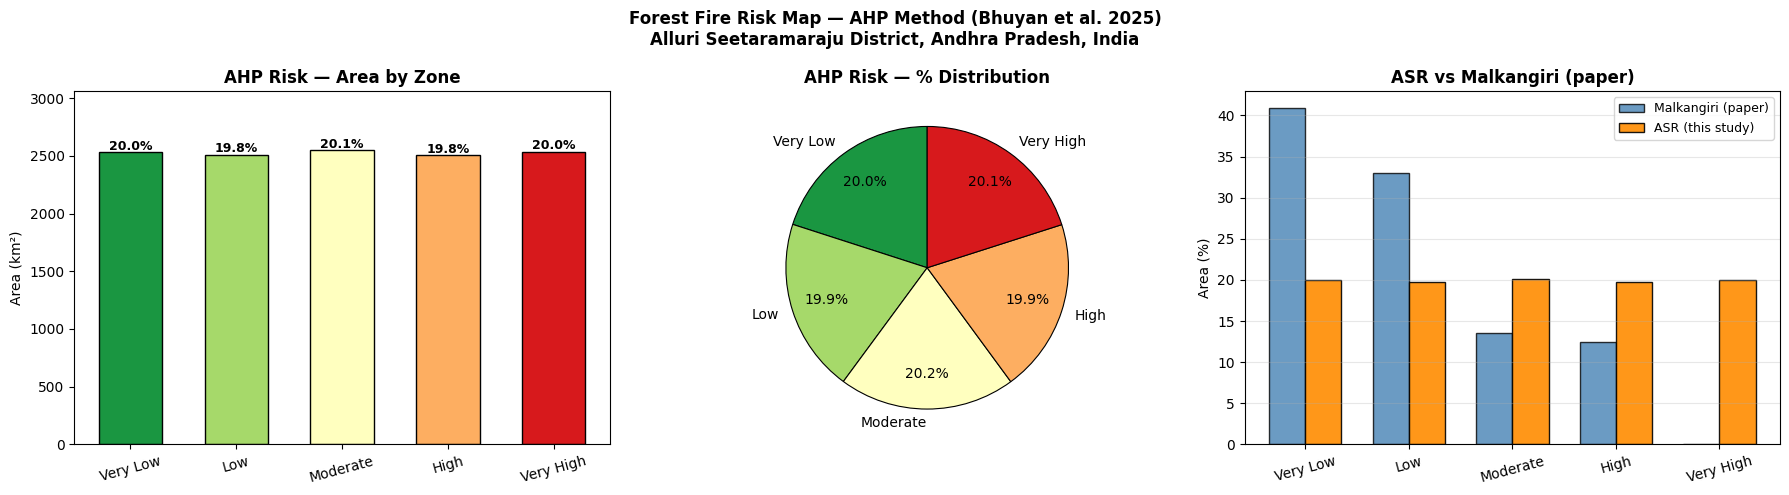

In [ ]:
# ─── Charts ──────────────────────────────────────────────────────────────────
colors_risk = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart — Area
bars = axes[0].bar(rdf_ahp['Zone'], rdf_ahp['Area km²'],
                   color=colors_risk, edgecolor='k', width=0.6)
axes[0].set_title('AHP Risk — Area by Zone', fontweight='bold')
axes[0].set_ylabel('Area (km²)'); axes[0].set_ylim(0, rdf_ahp['Area km²'].max()*1.2)
axes[0].tick_params(axis='x', rotation=15)
for bar, row in zip(bars, rdf_ahp.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{row._3:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 2. Pie chart — % distribution
wedge_props = {'edgecolor': 'k', 'linewidth': 0.8}
axes[1].pie(rdf_ahp['Area km²'], labels=rdf_ahp['Zone'], colors=colors_risk,
            autopct='%1.1f%%', startangle=90, wedgeprops=wedge_props, pctdistance=0.75)
axes[1].set_title('AHP Risk — % Distribution', fontweight='bold')

# 3. Grouped bar — ASR vs Malkangiri paper
x = np.arange(5); w = 0.35
malk_pcts = [40.91, 33.06, 13.57, 12.45, 0.001]
asr_pcts  = list(rdf_ahp['%'])
axes[2].bar(x - w/2, malk_pcts, w, label='Malkangiri (paper)', color='steelblue', alpha=0.8, edgecolor='k')
axes[2].bar(x + w/2, asr_pcts,  w, label='ASR (this study)',   color='darkorange', alpha=0.9, edgecolor='k')
axes[2].set_xticks(x); axes[2].set_xticklabels(rdf_ahp['Zone'], rotation=15)
axes[2].set_ylabel('Area (%)'); axes[2].set_title('ASR vs Malkangiri (paper)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Forest Fire Risk Map — AHP Method (Bhuyan et al. 2025)\n'
    'Alluri Seetaramaraju District, Andhra Pradesh, India',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('P2_AHP_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## P2-7. AHP Forest Fire Risk Map

In [ ]:
# ─── AHP Risk Map ─────────────────────────────────────────────────────────────
Map_ahp = geemap.Map(center=[17.88, 82.07], zoom=8)

Map_ahp.addLayer(
    ahp_raw,
    {'min': float(ahp_pct.get('AHP_raw_p0', 1)),
     'max': float(ahp_pct.get('AHP_raw_p100', 4)),
     'palette': ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']},
    'AHP Risk Score (continuous)'
)
Map_ahp.addLayer(ahp_classes, risk_viz, 'AHP Forest Fire Risk Zones')
Map_ahp.addLayer(roi, {'color': 'black'}, 'ASR District Boundary')

# Add a custom legend
legend_dict = {
    'Very Low (Class 1)':  '#1a9641',
    'Low (Class 2)':       '#a6d96a',
    'Moderate (Class 3)':  '#ffffbf',
    'High (Class 4)':      '#fdae61',
    'Very High (Class 5)': '#d7191c',
}
Map_ahp.add_legend(title='AHP Fire Risk', legend_dict=legend_dict)

print('AHP Forest Fire Risk Map — Alluri Seetaramaraju District')
print('Eq. 3: NDVI×0.1645 + Temp×0.3498 + Slope×0.0204 + NDMI×0.0725')
print('      + Elevation×0.2456 + Aspect×0.0401 + Wind×0.0378 + LULC×0.0693')
Map_ahp


AHP Forest Fire Risk Map — Alluri Seetaramaraju District
Eq. 3: NDVI×0.1645 + Temp×0.3498 + Slope×0.0204 + NDMI×0.0725
      + Elevation×0.2456 + Aspect×0.0401 + Wind×0.0378 + LULC×0.0693


Map(center=[17.88, 82.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## P2-8. Validation with FIRMS Fire Points

The paper validates using fire point data from PCCF, Odisha (Figure 12). We replicate this using **MODIS FIRMS fire detections** for the ASR fire season (Feb–Apr 2023), overlaid on the AHP risk map. Points falling in Very High / High zones confirm the model's predictive validity.

In [ ]:
# ─── FIRMS fire detections (Feb–Apr 2023) overlaid on AHP risk zones ─────────
firms_val = (
    ee.ImageCollection('FIRMS')
    .filterDate(FIRE_SEASON_START, FIRE_SEASON_END)
    .filterBounds(roi)
    .select('T21')
    .map(lambda img: img.gt(300))   # active fire pixels (T21 > 300 K)
    .max()
    .selfMask()
    .rename('fire')
    .clip(roi)
)

# How much fire fell in each AHP risk class?
fire_risk_overlay = ahp_classes.updateMask(firms_val)

print('Counting FIRMS fire pixels per AHP risk class...')
for c in range(1, 6):
    fire_px = (
        firms_val.updateMask(ahp_classes.eq(c))
        .reduceRegion(ee.Reducer.count(), roi, 500, maxPixels=1e9)
        .get('fire').getInfo()
    )
    all_px  = (
        ahp_classes.eq(c).selfMask()
        .reduceRegion(ee.Reducer.count(), roi, 500, maxPixels=1e9)
        .get('AHP_class').getInfo()
    )
    pct = round(100 * (fire_px or 0) / max(all_px or 1, 1), 2)
    print(f'  {ahp_labels[c]:<12}: {fire_px or 0:>6} fire detections  ({pct:.1f}% of class area)')

print('\n  ✅ Most fire pixels should cluster in High/Very High AHP zones (paper finds same for Malkangiri)')

# ─── Validation Map ───────────────────────────────────────────────────────────
Map_val = geemap.Map(center=[17.88, 82.07], zoom=8)
Map_val.addLayer(ahp_classes,      risk_viz,                'AHP Risk Zones')
Map_val.addLayer(fire_risk_overlay,
    {'min':1,'max':5,'palette':['yellow','orange','red','darkred','black']},
    'FIRMS detections (coloured by risk zone)')
Map_val.addLayer(firms_val,
    {'min':0,'max':1,'palette':['red']},
    'All FIRMS active fire pixels (Feb–Apr 2023)')
Map_val.addLayer(roi, {'color': 'white'}, 'ASR District')
Map_val.add_legend(title='AHP Risk Zone', legend_dict=legend_dict)
Map_val


Counting FIRMS fire pixels per AHP risk class...
  Very Low    :   1180 fire detections  (11.1% of class area)


## P2-9. Individual Factor Maps

Mirrors the paper's Figures 3–10 (Section 4.1–4.8), showing each of the 8 AHP input layers for ASR District.

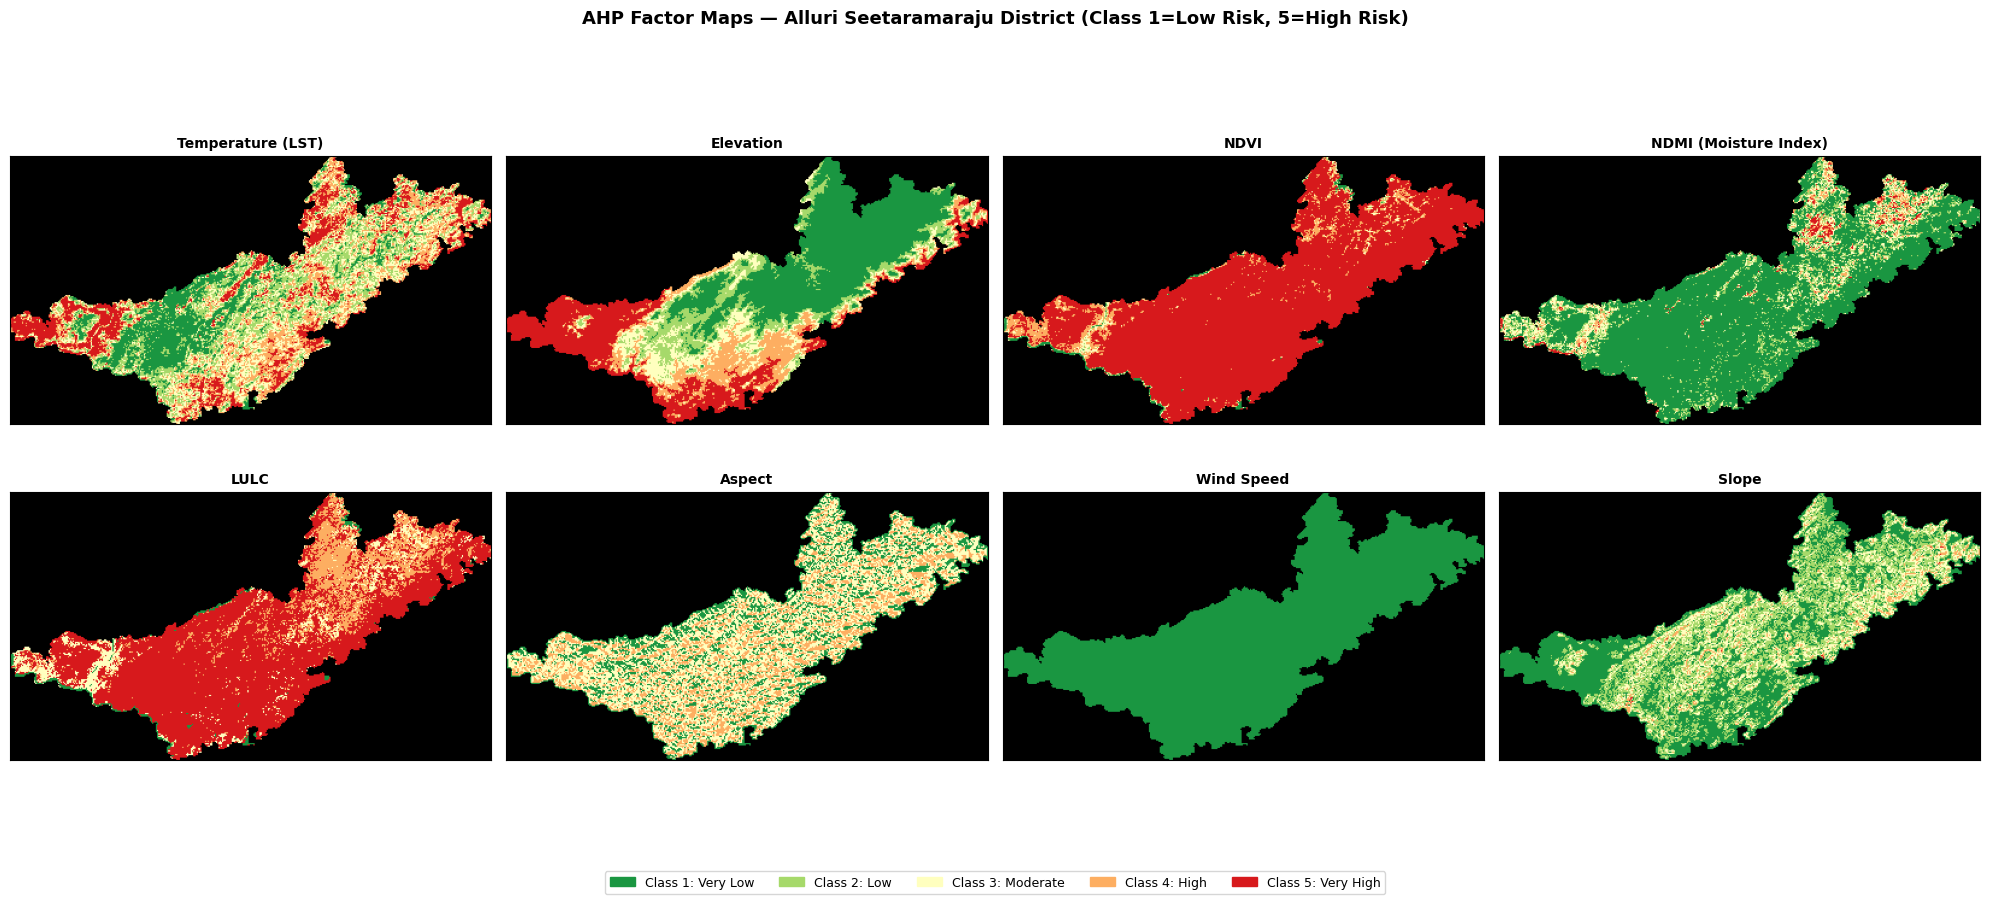

✅ All 8 factor maps rendered via getThumbURL


In [ ]:
import requests
from io import BytesIO
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── AHP Factor Maps using getThumbURL (works for all layers) ─────────────────

factor_layers = [
    (lst_classes,   'Temperature (LST)'),
    (e_cls,         'Elevation'),
    (ndvi_classes,  'NDVI'),
    (ndmi_classes,  'NDMI (Moisture Index)'),
    (lulc_classes,  'LULC'),
    (a_cls,         'Aspect'),
    (WS_cls,        'Wind Speed'),
    (s_cls,         'Slope'),
]

# Palette matching risk_viz (1=green → 5=red)
PALETTE = ['1a9641', 'a6d96a', 'ffffbf', 'fdae61', 'd7191c']

THUMB_PARAMS = {
    'min':        1,
    'max':        5,
    'palette':    PALETTE,
    'region':     roi.bounds().getInfo()['coordinates'],
    'dimensions': 400,   # px per tile — fast and clear enough
    'format':     'png',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, (layer, title) in zip(axes, factor_layers):
    try:
        band = layer.bandNames().getInfo()[0]
        url  = layer.select(band).getThumbURL(THUMB_PARAMS)
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        img  = PILImage.open(BytesIO(resp.content)).convert('RGB')
        ax.imshow(np.array(img))
        ax.set_title(title, fontweight='bold', fontsize=10)
    except Exception as e:
        ax.set_facecolor('#f0f0f0')
        ax.text(0.5, 0.5, f'{title}\n(error: {str(e)[:40]})',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red', wrap=True)
    ax.set_xticks([]); ax.set_yticks([])

colors_risk = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
patches = [mpatches.Patch(color=c, label=f'Class {i}: {l}')
           for i, (c, l) in enumerate(
               zip(colors_risk, ['Very Low', 'Low', 'Moderate', 'High', 'Very High']), 1)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('AHP Factor Maps — Alluri Seetaramaraju District (Class 1=Low Risk, 5=High Risk)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('P2_factor_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ All 8 factor maps rendered via getThumbURL')

## P2-10. Export to Google Drive

In [ ]:
cfg2 = {
    'region':    roi,
    'scale':     30,
    'crs':       'EPSG:4326',
    'maxPixels': 1e10,
    'folder':    'Wildfire_ASR_P2_AHP'
}

exports_p2 = [
    (lst.float(),         f'LST_ASR_{FIRE_SEASON_START[:7]}'),
    (lst_classes,          'LST_Classes_ASR'),
    (lulc_raw,             'LULC_ESA_WorldCover_ASR'),
    (lulc_classes,         'LULC_Classes_ASR'),
    (ahp_raw.float(),      'AHP_FireRisk_Raw_ASR'),
    (ahp_classes,          'AHP_FireRisk_Classes_ASR'),
]

print('Part 2 (AHP) export tasks — uncomment task.start() to run:')
for img, name in exports_p2:
    print(f'   -> {name}')
    # task = ee.batch.Export.image.toDrive(image=img, description=name, fileNamePrefix=name, **cfg2)
    # task.start()


Part 2 (AHP) export tasks — uncomment task.start() to run:
   -> LST_ASR_2023-02
   -> LST_Classes_ASR
   -> LULC_ESA_WorldCover_ASR
   -> LULC_Classes_ASR
   -> AHP_FireRisk_Raw_ASR
   -> AHP_FireRisk_Classes_ASR


---
---
# 📊 Cross-Method Comparison: Part 1 vs Part 2

## Method Summary

| Aspect | Part 1 — Sultan et al. (2025) | Part 2 — Bhuyan et al. (2025) |
|--------|-------------------------------|-------------------------------|
| **Method** | Equal-weight additive index | AHP weighted linear combination |
| **Factors** | 4 composite indices (FDI, ADI, WDI, TDI) | 8 individual factors |
| **Weighting** | 25% each (equal) | Expert-judged (CR=0.07) |
| **Top factor** | All equal | Temperature 34.98% |
| **Classification** | Natural breaks / equal-weight mean | Quantile on AHP score |
| **Validation** | dNBR burn severity cross-check | FIRMS fire point overlay |
| **GIS platform** | ArcGIS 10.8 (paper) → GEE Python | ArcGIS/QGIS (paper) → GEE Python |

---
## 📚 References

**Part 1:**
> Sultan, A., et al. (2025). *Wildfire indicators modeling for reserved forest of Vellore district (Tamil Nadu, India)*. Frontiers in Remote Sensing, 6:1518539. https://doi.org/10.3389/frsen.2025.1518539

**Part 2:**
> Bhuyan, J. M., Deka, K., & Pandey, K. (2025). *Forest Fire Risk Mapping Using Analytical Hierarchy Process (AHP): A case of Malkangiri, Odisha, India*. Journal of Geomatics, 19(2), 188–201. https://doi.org/10.58825/jog.2025.19.2.235

---

### GEE Datasets Used

| Dataset | GEE ID | Resolution | Part |
|---------|--------|-----------|------|
| MODIS NDVI | `MODIS/061/MOD13Q1` | 250 m | P1 |
| Landsat 9 OLI C2 L2 | `LANDSAT/LC09/C02/T1_L2` | 30 m | P1, P2 |
| ERA5-Land Monthly | `ECMWF/ERA5_LAND/MONTHLY_AGGR` | ~9 km | P1, P2 |
| SRTM DEM | `USGS/SRTMGL1_003` | 30 m | P1, P2 |
| GHSL Built Surface | `JRC/GHSL/P2023A/GHS_BUILT_S/2020` | 10 m | P1 |
| Oxford Accessibility | `Oxford/MAP/accessibility_to_cities_2015_v1_0` | ~1 km | P1 |
| FIRMS | `FIRMS` | 1 km | P1, P2 |
| ESA WorldCover | `ESA/WorldCover/v200/2021` | 10 m | **P2** |